In [9]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Conv1D, Dense, LayerNormalization, Dropout, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ======= USER CHOICE ======= #
data_size = 5000  # Set as desired: None for all rows, or an integer
# =========================== #

# 1. Load and filter dataset
df = pd.read_excel('/kaggle/input/filtered-excel-file1/filtered_excel_file.xlsx')
if data_size is not None and data_size <= len(df):
    df = df.iloc[:data_size]

# Ensure all sentences and tags are strings, fill missing with ''
sentences = df['Ar'].fillna('').astype(str).values
tags_seq = df['POS-tag'].fillna('').astype(str).values

# Tokenize characters for encoder
char_tokenizer = Tokenizer(char_level=True)
char_tokenizer.fit_on_texts(sentences)
X = pad_sequences(char_tokenizer.texts_to_sequences(sentences), padding='post')

# Tokenize POS tags for decoder output (tag per word)
tag_tokenizer = Tokenizer()
tag_tokenizer.fit_on_texts([tag for tag in tags_seq])
y = [tag_tokenizer.texts_to_sequences(tag.split()) for tag in tags_seq]
y = pad_sequences(y, padding='post')

# Model params
vocab_size = len(char_tokenizer.word_index) + 1
tag_count = len(tag_tokenizer.word_index) + 1
max_len = X.shape[1]
max_tags = y.shape[1]

# 2. Encoder: Transformer block
class SimpleTransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, num_heads, embed_dim, ff_dim):
        super().__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([Dense(ff_dim, activation='relu'), Dense(embed_dim)])
        self.layernorm1 = LayerNormalization()
        self.layernorm2 = LayerNormalization()
        self.dropout1 = Dropout(0.1)
        self.dropout2 = Dropout(0.1)

    def call(self, inputs):
        attn_output = self.att(inputs, inputs)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        out2 = self.layernorm2(out1 + ffn_output)
        return self.dropout2(out2)

# 3. Custom CNN-SDE decoder block (fixed for Keras)
class CNNSDEPoss(tf.keras.layers.Layer):
    def __init__(self, filters, kernel_size):
        super().__init__()
        self.conv = Conv1D(filters, kernel_size, padding='same', activation='relu')
        self.dropout = Dropout(0.2)  # fixed: create once here!

    def call(self, inputs):
        x = self.dropout(inputs)
        return self.conv(x)

# Build model
inputs = Input(shape=(max_len,), name='input')
emb = Embedding(vocab_size, 64)(inputs)
encoder = SimpleTransformerEncoder(num_heads=2, embed_dim=64, ff_dim=128)(emb)
decoder_cnn = CNNSDEPoss(filters=64, kernel_size=3)(encoder)
flat = Flatten()(decoder_cnn)
dense = Dense(max_tags * tag_count, activation='softmax')(flat)
outputs = tf.keras.layers.Reshape((max_tags, tag_count))(dense)

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Prepare targets for training
y_targets = np.expand_dims(y, -1) # (batch, seq_len, 1)

# Train
model.fit(X, y_targets, batch_size=32, epochs=10, validation_split=0.1)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 93)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 93, 64)         │         8,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_transformer_encoder_1    │ (None, 93, 64)         │        50,048 │
│ (SimpleTransformerEncoder)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnnsde_poss_1 (CNNSDEPoss)      │ (None, 93, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5952)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 255)            │     1,518,015 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 15, 17)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,588,543 (6.06 MB)

 Trainable params: 1,588,543 (6.06 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 65ms/step - accuracy: 0.5068 - loss: 1.1044 - val_accuracy: 0.5029 - val_loss: 0.8572
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.4896 - loss: 0.7884 - val_accuracy: 0.4731 - val_loss: 0.7656
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.4928 - loss: 0.5543 - val_accuracy: 0.4581 - val_loss: 0.7785
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.4722 - loss: 0.3826 - val_accuracy: 0.4556 - val_loss: 0.8326
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.4649 - loss: 0.2676 - val_accuracy: 0.4460 - val_loss: 0.9493
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.4722 - loss: 0.2027 - val_accuracy: 0.4606 - val_loss: 0.9711
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.4720 - loss: 0.1604 - val_accuracy: 0.4691 - val_loss: 1.0842
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.4709 - loss: 0.1268 - val_acc

2025-10-14 12:37:39.722395: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760445459.921325      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760445459.977465      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Preprocessed data saved to pickle file.
Label distribution: {0: 1943891, 1: 249351, 2: 144994, 3: 140829, 4: 110136, 5: 90020, 6: 84529, 7: 51999, 8: 51070, 9: 45749, 10: 29415, 11: 25084, 12: 22185, 13: 3682, 14: 3604, 15: 3275, 16: 177, 17: 10}
Train: (160002, 122) (160002, 15, 1)
Val:   (19998, 122) (19998, 15, 1)
Test:  (20000, 122) (20000, 15, 1)


I0000 00:00:1760445533.902857      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 122)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 122, 128)       │        31,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stacked_transformer_encoder     │ (None, 122, 128)       │     2,375,936 │
│ (StackedTransformerEncoder)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deep_cnnsde_poss                │ (None, 122, 128)       │       295,680 │
│ (DeepCNNSDEPoss)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15616)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 270)            │     4,216,590 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 15, 18)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

5001/5001 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4739 - loss: 0.9293

W0000 00:00:1760445729.679449      99 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1760445737.355798      97 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


5001/5001 ━━━━━━━━━━━━━━━━━━━━ 203s 34ms/step - accuracy: 0.4739 - loss: 0.9292 - val_accuracy: 0.4492 - val_loss: 0.6290
Epoch 2/100
5001/5001 ━━━━━━━━━━━━━━━━━━━━ 155s 31ms/step - accuracy: 0.4505 - loss: 0.6132 - val_accuracy: 0.4476 - val_loss: 0.5049
Epoch 3/100
5001/5001 ━━━━━━━━━━━━━━━━━━━━ 155s 31ms/step - accuracy: 0.4483 - loss: 0.5071 - val_accuracy: 0.4356 - val_loss: 0.4600
Epoch 4/100
5001/5001 ━━━━━━━━━━━━━━━━━━━━ 156s 31ms/step - accuracy: 0.4451 - loss: 0.4523 - val_accuracy: 0.4453 - val_loss: 0.4216
Epoch 5/100
5001/5001 ━━━━━━━━━━━━━━━━━━━━ 155s 31ms/step - accuracy: 0.4439 - loss: 0.4145 - val_accuracy: 0.4413 - val_loss: 0.4029
Epoch 6/100
5001/5001 ━━━━━━━━━━━━━━━━━━━━ 154s 31ms/step - accuracy: 0.4434 - loss: 0.3847 - val_accuracy: 0.4405 - val_loss: 0.3907
Epoch 7/100
5001/5001 ━━━━━━━━━━━━━━━━━━━━ 155s 31ms/step - accuracy: 0.4427 - loss: 0.3640 - val_accuracy: 0.4341 - val_loss: 0.3960
Epoch 8/100
5001/5001 ━━━━━━━━━━━━━━━━━━━━ 155s 31ms/step - accuracy: 0.44

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

                   precision    recall  f1-score   support

            [PAD]       0.00      0.00      0.00         0
        adjective       0.60      0.46      0.52      8356
       adposition       0.61      0.62      0.61     10966
           adverb       0.72      0.74      0.73      2102
    auxiliaryverb       0.73      0.72      0.73      2518
 coordinatingconj       0.69      0.71      0.70      4986
       determiner       0.74      0.72      0.73      5178
         foreignw       0.69      0.53      0.60     14162
     interjection       0.91      0.47      0.62       347
             noun       0.64      0.71      0.67     24686
          numeral       0.49      0.18      0.26       324
         particle       0.80      0.82      0.81      4591
          pronoun       0.67      0.64      0.66      8916
        propenoun       1.00      0.15      0.27        13
      punctuation       0.71      0.33      0.45       377
subordinatingconj       0.74      0.75      0.75      2

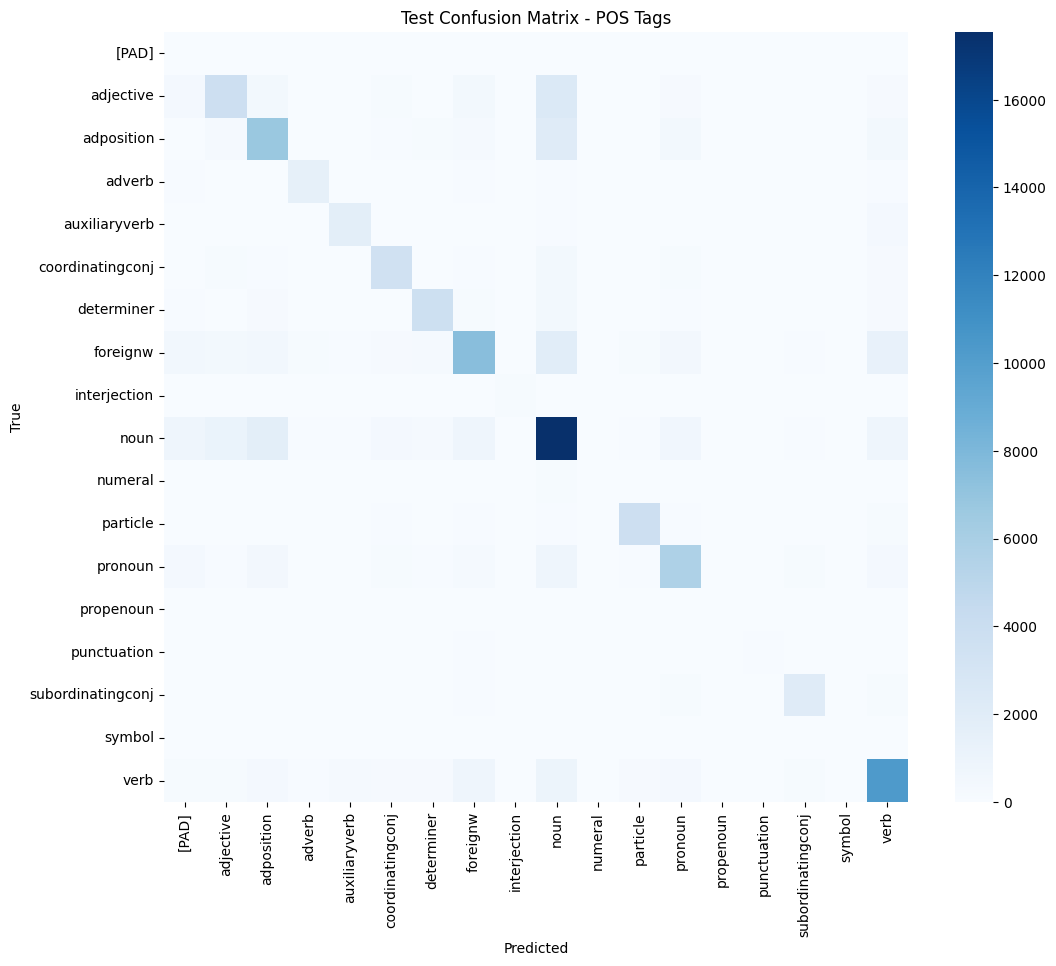

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

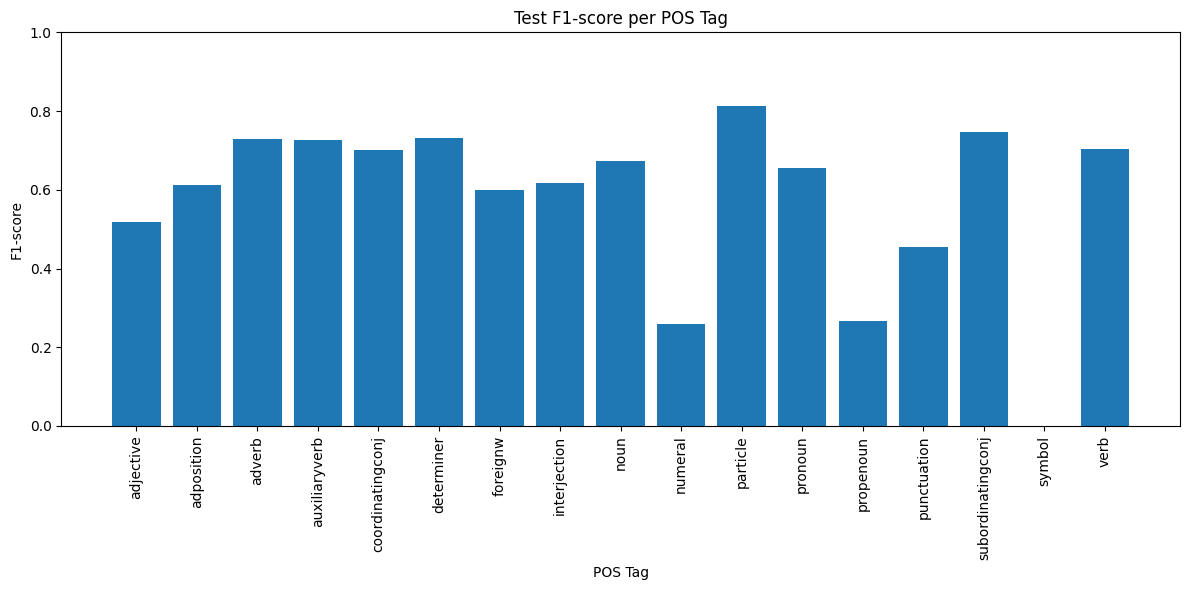

Test Sequence-level accuracy: 0.34075


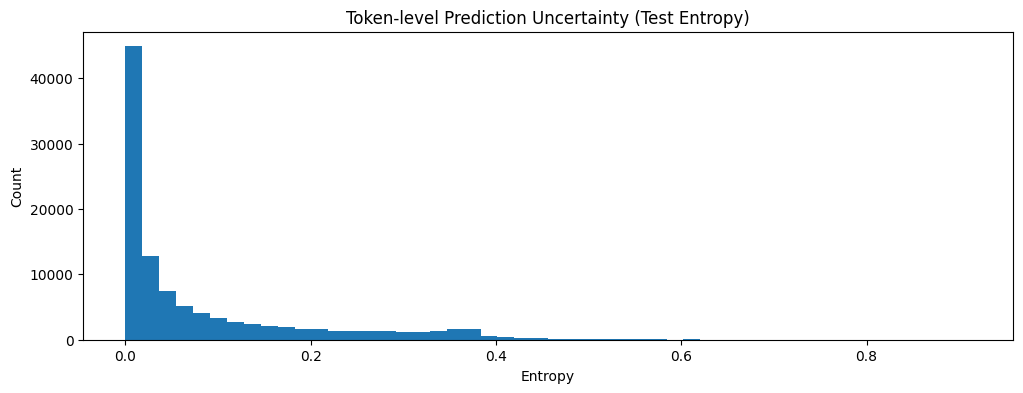

BLEU score (corpus-level): 40.33

Sample 1:
Words:  ['و', 'ل', 'ك', 'ن', ' ', 'ه', 'ذ', 'ه', ' ', 'ا', 'ل', 'م', 'ح', 'ك', 'م', 'ة', ' ', 'ي', 'ج', 'ب', ' ', 'أ', 'ن', ' ', 'ت', 'ُ', 'ف', 'س', 'ّ', 'ر', ' ', 'و', 'ِ', 'ف', 'ق', 'ا', 'ً', ' ', 'ل', 'ل', 'ق', 'ا', 'ن', 'و', 'ن']
Gold tags:   ['auxiliaryverb', 'adjective']
Predicted:   ['auxiliaryverb', 'adjective']
----------------------------------------

Sample 2:
Words:  ['ع', 'ن', 'د', 'ئ', 'ذ', ' ', 'س', 'ي', 'ذ', 'ه', 'ب', ' ', 'ك', 'ل', ' ', 'م', 'ن', 'ا', ' ', 'ف', 'ي', ' ', 'ح', 'ا', 'ل', ' ', 'س', 'ب', 'ي', 'ل', 'ه']
Gold tags:   ['adposition', 'noun', 'adjective', 'foreignw']
Predicted:   ['adposition', 'noun', 'adjective', 'foreignw']
----------------------------------------

Sample 3:
Words:  ['ه', 'ذ', 'ا', ' ', 'ج', 'م', 'ي', 'ل']
Gold tags:   ['adposition', 'adjective', 'subordinatingconj', 'verb', 'noun', 'pronoun', 'adposition', 'determiner', 'noun', 'particle', 'pronoun']
Predicted:   ['adposition', 'adjective', 'subor

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import pickle
from tensorflow.keras.layers import Input, Embedding, Conv1D, Dense, LayerNormalization, Dropout, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

# ========= USER CONFIG ========= #
data_size = 200000  # Or None for all available
max_epochs = 100
batch_size = 32
random_state = 42
excel_path = "/kaggle/input/filtered-excel-file1/filtered_excel_file.xlsx"       # Your Excel data file
pkl_path = "/kaggle/working/preprocessed_pos_data.pkl"                          # Separate pkl cache file
# =============================== #

# ========== DATA PREPROCESS (CACHED) ========== #
if os.path.exists(pkl_path):
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    X = data["X"]
    y = data["y"]
    sentences = data["sentences"]
    tag_tokenizer = data["tag_tokenizer"]
    char_tokenizer = data["char_tokenizer"]
    print("Preprocessed data loaded from pickle file.")
else:
    df = pd.read_excel(excel_path)
    if data_size is not None and data_size <= len(df):
        df = df.iloc[:data_size]
    sentences = df['Ar'].fillna('').astype(str).values
    tags_seq = df['POS-tag'].fillna('').astype(str).values

    char_tokenizer = Tokenizer(char_level=True)
    char_tokenizer.fit_on_texts(sentences)
    X = pad_sequences(char_tokenizer.texts_to_sequences(sentences), padding='post')

    tag_tokenizer = Tokenizer()
    tag_tokenizer.fit_on_texts([tag for tag in tags_seq])
    y = [tag_tokenizer.texts_to_sequences(tag.split()) for tag in tags_seq]
    y = pad_sequences(y, padding='post')

    with open(pkl_path, "wb") as f:
        pickle.dump({
            "X": X, "y": y,
            "sentences": sentences,
            "tag_tokenizer": tag_tokenizer, "char_tokenizer": char_tokenizer
        }, f)
    print("Preprocessed data saved to pickle file.")

unique, counts = np.unique(y, return_counts=True)
print("Label distribution:", dict(zip(unique, counts)))

vocab_size = len(char_tokenizer.word_index) + 1
tag_count = len(tag_tokenizer.word_index) + 1
max_len = X.shape[1]
max_tags = y.shape[1]

# ========== DATA SPLIT ========== #
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.1, random_state=random_state)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.1111, random_state=random_state)
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

# ========== MODEL BLOCKS ========== #
class SimpleTransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, num_heads, embed_dim, ff_dim):
        super().__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([Dense(ff_dim, activation='relu'), Dense(embed_dim)])
        self.layernorm1 = LayerNormalization()
        self.layernorm2 = LayerNormalization()
        self.dropout1 = Dropout(0.15)
        self.dropout2 = Dropout(0.15)
    def call(self, inputs):
        attn_output = self.att(inputs, inputs)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        out2 = self.layernorm2(out1 + ffn_output)
        return self.dropout2(out2)

class StackedTransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, num_layers=4, num_heads=8, embed_dim=128, ff_dim=256, dropout=0.18):
        super().__init__()
        self.encoders = [
            SimpleTransformerEncoder(num_heads=num_heads, embed_dim=embed_dim, ff_dim=ff_dim)
            for _ in range(num_layers)
        ]
        self.norm = LayerNormalization()
        self.dropout = Dropout(dropout)
    def call(self, inputs):
        x = inputs
        for encoder in self.encoders:
            x = encoder(x)
        x = self.norm(x)
        return self.dropout(x)

class DeepCNNSDEPoss(tf.keras.layers.Layer):
    def __init__(self, filters=128, kernel_size=7, layers=2):
        super().__init__()
        self.cnns = [Conv1D(filters, kernel_size, padding='same', activation='relu') for _ in range(layers)]
        self.dropouts = [Dropout(0.2+(i*0.07)) for i in range(layers)]
        self.drifts = [Dense(filters) for _ in range(layers)]
        self.diffusions = [Dense(filters) for _ in range(layers)]
    def call(self, inputs, training=None):
        x = inputs
        dt = 1.0
        for cnn, drift, diffu, drop in zip(self.cnns, self.drifts, self.diffusions, self.dropouts):
            x = drop(x, training=training)
            x = cnn(x)
            batch_size = tf.shape(x)[0]
            seq_len = tf.shape(x)[1]
            c_dim = tf.shape(x)[2]
            noise = tf.random.normal((batch_size, seq_len, c_dim), mean=0., stddev=1.)
            x = x + drift(x)*dt + diffu(x)*noise*tf.sqrt(dt)
        return x

inputs = Input(shape=(max_len,), name='input')
emb = Embedding(vocab_size, 128)(inputs)
encoder = StackedTransformerEncoder(num_layers=4, num_heads=8, embed_dim=128, ff_dim=256, dropout=0.18)(emb)
decoder_cnn = DeepCNNSDEPoss(filters=128, kernel_size=7, layers=2)(encoder)
flat = Flatten()(decoder_cnn)
dense = Dense(max_tags * tag_count, activation='softmax')(flat)
outputs = tf.keras.layers.Reshape((max_tags, tag_count))(dense)

from tensorflow.keras.optimizers import Adam
model = Model(inputs, outputs)
model.compile(optimizer=Adam(learning_rate=1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

y_train_targets = np.expand_dims(y_train, -1)
y_val_targets = np.expand_dims(y_val, -1)

early = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('/kaggle/working/best_model.keras', monitor='val_loss', save_best_only=True)

history = model.fit(
    X_train, y_train_targets,
    batch_size=batch_size,
    epochs=max_epochs,
    validation_data=(X_val, y_val_targets),
    callbacks=[early, checkpoint]
)

# ========== EVALUATION & VISUALIZATION ========== #
y_probs = model.predict(X_test)
y_pred = np.argmax(y_probs, axis=-1)
y_true = y_test

# Fix possible shape mismatch for mask logic
y_true = np.squeeze(y_true)
y_pred = np.squeeze(y_pred)

mask = (y_true != 0)
y_true_flat = y_true[mask]
y_pred_flat = y_pred[mask]

idx2tag = {v: k for k, v in tag_tokenizer.word_index.items()}
idx2tag[0] = '[PAD]'
y_true_tags = [idx2tag[idx] for idx in y_true_flat]
y_pred_tags = [idx2tag[idx] for idx in y_pred_flat]

print("\nTest Classification Report:")
with open('/kaggle/working/test_classification_report.txt', 'w', encoding='utf-8') as f:
    f.write(classification_report(y_true_tags, y_pred_tags))
print(classification_report(y_true_tags, y_pred_tags))

labels = np.unique(y_true_tags + y_pred_tags)
cm = confusion_matrix(y_true_tags, y_pred_tags, labels=labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix - POS Tags")
plt.savefig('/kaggle/working/Test_Confusion_Matrix.png')
plt.show()

report = classification_report(y_true_tags, y_pred_tags, output_dict=True)
f1s = [report[tag]['f1-score'] for tag in labels if tag != '[PAD]']
plt.figure(figsize=(12, 6))
plt.bar(labels[1:], f1s)
plt.title("Test F1-score per POS Tag")
plt.xlabel("POS Tag")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=90)  # <-- This rotates the labels vertically
plt.tight_layout()       # <-- This helps reduce any crowding
plt.savefig('/kaggle/working/Test_F1-score.png')
plt.show()

sequence_correct = (y_true == y_pred).all(axis=1)
print("Test Sequence-level accuracy:", sequence_correct.mean())

def compute_entropy(prob_vec):
    prob_vec = np.clip(prob_vec, 1e-12, 1 - 1e-12)
    return -np.sum(prob_vec * np.log(prob_vec), axis=-1)
entropies = compute_entropy(y_probs)
plt.figure(figsize=(12, 4))
plt.hist(entropies[mask], bins=50)
plt.title("Token-level Prediction Uncertainty (Test Entropy)")
plt.xlabel("Entropy")
plt.ylabel("Count")
plt.savefig('/kaggle/working/Test_Token-level_Prediction_Uncertainty.png')
plt.show()

# --- BLEU Evaluation ---
bleu_hyps, bleu_refs = [], []
for i in range(y_true.shape[0]):
    ref_seq = [idx2tag[tag] for tag in y_true[i] if tag != 0]
    hyp_seq = [idx2tag[tag] for tag in y_pred[i] if tag != 0]
    if ref_seq and hyp_seq:
        bleu_refs.append([ref_seq])
        bleu_hyps.append(hyp_seq)
bleu = corpus_bleu(bleu_refs, bleu_hyps, smoothing_function=SmoothingFunction().method4)
print(f"BLEU score (corpus-level): {bleu*100:.2f}")

# --- Sample Print ---
n_samples = 5
for i in range(n_samples):
    idx = np.random.randint(len(X_test))
    words = [w for w in sentences[idx]]
    true_seq = [idx2tag[tag] for tag in y_true[idx] if tag != 0]
    pred_seq = [idx2tag[tag] for tag in y_pred[idx] if tag != 0]
    print(f"\nSample {i+1}:")
    print("Words: ", words)
    print("Gold tags:  ", true_seq)
    print("Predicted:  ", pred_seq)
    print("-" * 40)


In [16]:
import os

folder = '/kaggle/working'
for filename in os.listdir(folder):
    file_path = os.path.join(folder, filename)
    try:
        if os.path.isfile(file_path) or os.path.islink(file_path):
            os.remove(file_path)
        elif os.path.isdir(file_path):
            import shutil
            shutil.rmtree(file_path)
    except Exception as e:
        print(f'Failed to delete {file_path}. Reason: {e}')


In [13]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import pickle
from tensorflow.keras.layers import Input, Embedding, Conv1D, Dense, LayerNormalization, Dropout, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

# ========= USER CONFIG ========= #
data_size = 200000  # Or None for all available
max_epochs = 30
batch_size = 64
random_state = 42
excel_path = "/kaggle/input/filtered-excel-file1/filtered_excel_file.xlsx"
pkl_path = "/kaggle/working/preprocessed_pos_data.pkl"
# =============================== #

# ========== DATA PREPROCESS (CACHED) ========== #
if os.path.exists(pkl_path):
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    X = data["X"]
    y = data["y"]
    sentences = data["sentences"]
    tag_tokenizer = data["tag_tokenizer"]
    char_tokenizer = data["char_tokenizer"]
    print("Preprocessed data loaded from pickle file.")
else:
    df = pd.read_excel(excel_path)
    if data_size is not None and data_size <= len(df):
        df = df.iloc[:data_size]
    sentences = df['Ar'].fillna('').astype(str).values
    tags_seq = df['POS-tag'].fillna('').astype(str).values

    char_tokenizer = Tokenizer(char_level=True)
    char_tokenizer.fit_on_texts(sentences)
    X = pad_sequences(char_tokenizer.texts_to_sequences(sentences), padding='post')

    tag_tokenizer = Tokenizer()
    tag_tokenizer.fit_on_texts([tag for tag in tags_seq])
    y = [tag_tokenizer.texts_to_sequences(tag.split()) for tag in tags_seq]
    y = pad_sequences(y, padding='post')

    with open(pkl_path, "wb") as f:
        pickle.dump({
            "X": X, "y": y,
            "sentences": sentences,
            "tag_tokenizer": tag_tokenizer, "char_tokenizer": char_tokenizer
        }, f)
    print("Preprocessed data saved to pickle file.")

unique, counts = np.unique(y, return_counts=True)
print("Label distribution:", dict(zip(unique, counts)))

vocab_size = len(char_tokenizer.word_index) + 1
tag_count = len(tag_tokenizer.word_index) + 1
max_len = X.shape[1]
max_tags = y.shape[1]

# ========== DATA SPLIT ========== #
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.1, random_state=random_state)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.1111, random_state=random_state)
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

# ========== MODEL BLOCKS ========== #
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.optimizers import Adam

class SimpleTransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, num_heads, embed_dim, ff_dim):
        super().__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([Dense(ff_dim, activation='relu'), Dense(embed_dim)])
        self.layernorm1 = LayerNormalization()
        self.layernorm2 = LayerNormalization()
        self.dropout1 = Dropout(0.2)
        self.dropout2 = Dropout(0.2)
    def call(self, inputs):
        attn_output = self.att(inputs, inputs)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        out2 = self.layernorm2(out1 + ffn_output)
        return self.dropout2(out2)

class StackedTransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, num_layers=4, num_heads=8, embed_dim=256, ff_dim=512, dropout=0.2):
        super().__init__()
        self.encoders = [
            SimpleTransformerEncoder(num_heads=num_heads, embed_dim=embed_dim, ff_dim=ff_dim)
            for _ in range(num_layers)
        ]
        self.norm = LayerNormalization()
        self.dropout = Dropout(dropout)
    def call(self, inputs):
        x = inputs
        for encoder in self.encoders:
            x = encoder(x)
        x = self.norm(x)
        return self.dropout(x)

class DeepCNNSDEPoss(tf.keras.layers.Layer):
    def __init__(self, filters=128, kernel_size=5, layers=2):
        super().__init__()
        self.cnns = [Conv1D(filters, kernel_size, padding='same', activation='relu') for _ in range(layers)]
        self.dropouts = [Dropout(0.25+(i*0.05)) for i in range(layers)]
        self.drifts = [Dense(filters) for _ in range(layers)]
        self.diffusions = [Dense(filters) for _ in range(layers)]
    def call(self, inputs, training=None):
        x = inputs
        dt = 1.0
        for cnn, drift, diffu, drop in zip(self.cnns, self.drifts, self.diffusions, self.dropouts):
            x = drop(x, training=training)
            x = cnn(x)
            batch_size = tf.shape(x)[0]
            seq_len = tf.shape(x)[1]
            c_dim = tf.shape(x)[2]
            noise = tf.random.normal((batch_size, seq_len, c_dim), mean=0., stddev=1.)
            x = x + drift(x)*dt + diffu(x)*noise*tf.sqrt(dt)
        return x

inputs = Input(shape=(max_len,), name='input')
emb = Embedding(vocab_size, 256, mask_zero=True)(inputs)
encoder = StackedTransformerEncoder(num_layers=4, num_heads=8, embed_dim=256, ff_dim=512, dropout=0.2)(emb)
decoder_cnn = DeepCNNSDEPoss(filters=128, kernel_size=5, layers=2)(encoder)
flat = Flatten()(decoder_cnn)
drop = Dropout(0.3)(flat)
dense = Dense(max_tags * tag_count, activation='softmax')(drop)
outputs = tf.keras.layers.Reshape((max_tags, tag_count))(dense)

lr_schedule = ExponentialDecay(initial_learning_rate=1e-3, decay_steps=1000, decay_rate=0.85)
model = Model(inputs, outputs)
model.compile(optimizer=Adam(lr_schedule), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

y_train_targets = np.expand_dims(y_train, -1)
y_val_targets = np.expand_dims(y_val, -1)

early = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('/kaggle/working/best_model.keras', monitor='val_loss', save_best_only=True)
history = model.fit(
    X_train, y_train_targets,
    batch_size=batch_size,
    epochs=max_epochs,
    validation_data=(X_val, y_val_targets),
    callbacks=[early, checkpoint]
)

# ========== EVALUATION & VISUALIZATION ========== #
y_probs = model.predict(X_test)
y_pred = np.argmax(y_probs, axis=-1)
y_true = y_test

y_true = np.squeeze(y_true)
y_pred = np.squeeze(y_pred)

mask = (y_true != 0)
y_true_flat = y_true[mask]
y_pred_flat = y_pred[mask]

idx2tag = {v: k for k, v in tag_tokenizer.word_index.items()}
idx2tag[0] = '[PAD]'
y_true_tags = [idx2tag[idx] for idx in y_true_flat]
y_pred_tags = [idx2tag[idx] for idx in y_pred_flat]

print("\nTest Classification Report:")
with open('/kaggle/working/test_classification_report.txt', 'w', encoding='utf-8') as f:
    f.write(classification_report(y_true_tags, y_pred_tags, zero_division=0))
print(classification_report(y_true_tags, y_pred_tags, zero_division=0))

labels = np.unique(y_true_tags + y_pred_tags)
cm = confusion_matrix(y_true_tags, y_pred_tags, labels=labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap='Blues', annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix - POS Tags")
plt.savefig('/kaggle/working/Test_Confusion_Matrix.png')
plt.show()

report = classification_report(y_true_tags, y_pred_tags, output_dict=True, zero_division=0)
f1s = [report[tag]['f1-score'] for tag in labels if tag != '[PAD]']

plt.figure(figsize=(12, 6))
plt.bar(labels[1:], f1s)
plt.title("Test F1-score per POS Tag")
plt.xlabel("POS Tag")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=90)  # <-- This rotates the labels vertically
plt.tight_layout()       # <-- This helps reduce any crowding
plt.savefig('/kaggle/working/Test_F1-score.png')
plt.show()


sequence_correct = (y_true == y_pred).all(axis=1)
print("Test Sequence-level accuracy:", sequence_correct.mean())

def compute_entropy(prob_vec):
    prob_vec = np.clip(prob_vec, 1e-12, 1 - 1e-12)
    return -np.sum(prob_vec * np.log(prob_vec), axis=-1)
entropies = compute_entropy(y_probs)
plt.figure(figsize=(12, 4))
plt.hist(entropies[mask], bins=50)
plt.title("Token-level Prediction Uncertainty (Test Entropy)")
plt.xlabel("Entropy")
plt.ylabel("Count")
plt.savefig('/kaggle/working/Test_Token-level_Prediction_Uncertainty.png')
plt.show()

# --- BLEU Evaluation ---
bleu_hyps, bleu_refs = [], []
for i in range(y_true.shape[0]):
    ref_seq = [idx2tag[tag] for tag in y_true[i] if tag != 0]
    hyp_seq = [idx2tag[tag] for tag in y_pred[i] if tag != 0]
    if ref_seq and hyp_seq:
        bleu_refs.append([ref_seq])
        bleu_hyps.append(hyp_seq)
bleu = corpus_bleu(bleu_refs, bleu_hyps, smoothing_function=SmoothingFunction().method4)
print(f"BLEU score (corpus-level): {bleu*100:.2f}")

# --- Sample Print ---
n_samples = 5
for i in range(n_samples):
    idx = np.random.randint(len(X_test))
    words = [w for w in sentences[idx]]
    true_seq = [idx2tag[tag] for tag in y_true[idx] if tag != 0]
    pred_seq = [idx2tag[tag] for tag in y_pred[idx] if tag != 0]
    print(f"\nSample {i+1}:")
    print("Words: ", words)
    print("Gold tags:  ", true_seq)
    print("Predicted:  ", pred_seq)
    print("-" * 40)


Preprocessed data saved to pickle file.
Label distribution: {0: 1943891, 1: 249351, 2: 144994, 3: 140829, 4: 110136, 5: 90020, 6: 84529, 7: 51999, 8: 51070, 9: 45749, 10: 29415, 11: 25084, 12: 22185, 13: 3682, 14: 3604, 15: 3275, 16: 177, 17: 10}
Train: (160002, 122) (160002, 15, 1)
Val:   (19998, 122) (19998, 15, 1)
Test:  (20000, 122) (20000, 15, 1)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'stacked_transformer_encoder_2' (of type StackedTransformerEncoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 122)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 122, 256)       │        63,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stacked_transformer_encoder_2   │ (None, 122, 256)       │     9,470,464 │
│ (StackedTransformerEncoder)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deep_cnnsde_poss_2              │ (None, 122, 128)       │       312,064 │
│ (DeepCNNSDEPoss)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 15616)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 15616)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 270)            │     4,216,590 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 15, 18)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,062,350 (53.64 MB)

...

W0000 00:00:1760439521.037459     107 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


2501/2501 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.5612 - loss: 1.2507

W0000 00:00:1760439531.639606     110 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1760439544.494742     110 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
E0000 00:00:1760439544.912050     110 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1760439545.153230     110 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2501/2501 ━━━━━━━━━━━━━━━━━━━━ 351s 129ms/step - accuracy: 0.5612 - loss: 1.2506 - val_accuracy: 0.5680 - val_loss: 1.1700
Epoch 2/30
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 305s 122ms/step - accuracy: 0.5666 - loss: 1.1696 - val_accuracy: 0.5674 - val_loss: 1.1679
Epoch 3/30
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 305s 122ms/step - accuracy: 0.5680 - loss: 1.1662 - val_accuracy: 0.5323 - val_loss: 1.1691
Epoch 4/30
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 306s 122ms/step - accuracy: 0.5660 - loss: 1.1654 - val_accuracy: 0.5673 - val_loss: 1.1678
Epoch 5/30
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 305s 122ms/step - accuracy: 0.5683 - loss: 1.1654 - val_accuracy: 0.5673 - val_loss: 1.1661
Epoch 6/30
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 305s 122ms/step - accuracy: 0.5679 - loss: 1.1643 - val_accuracy: 0.5673 - val_loss: 1.1658
Epoch 7/30
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 306s 122ms/step - accuracy: 0.5674 - loss: 1.1651 - val_accuracy: 0.5673 - val_loss: 1.1656
Epoch 8/30
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 306s 122ms/step - accuracy: 0.5

KeyboardInterrupt: 

In [3]:
import pandas as pd

# Load your dataset (edit the path if necessary)
df = pd.read_excel('/kaggle/input/filtered-excel-file1/filtered_excel_file.xlsx')

# Maximum character length of Arabic sentences
max_arabic_len = max(df['Ar'].astype(str).apply(len))
print("Maximum Arabic sentence length (characters):", max_arabic_len)

# Compute the maximum word count in 'Ar' sentences
max_word_len = max(df['Ar'].astype(str).apply(lambda x: len(x.split())))
print("Maximum Arabic sentence length (words):", max_word_len)

# Maximum POS tag sequence length (split on whitespace)
max_pos_len = max(df['POS-tag'].astype(str).apply(lambda x: len(x.split())))
print("Maximum POS tag sequence length:", max_pos_len)


Maximum Arabic sentence length (characters): 191
Maximum Arabic sentence length (words): 15
Maximum POS tag sequence length: 15


In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import pickle
from tensorflow.keras.layers import Input, Embedding, Conv1D, Dense, LayerNormalization, Dropout, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

# ========= USER CONFIG ========= #
data_size = 200000  # Or None for all available
max_epochs = 100
batch_size = 32
random_state = 42
excel_path = "/kaggle/input/filtered-excel-file1/filtered_excel_file.xlsx"
pkl_path = "/kaggle/working/preprocessed_pos_data.pkl"
# =============================== #

# ========== DATA PREPROCESS (CACHED) ========== #
if os.path.exists(pkl_path):
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    X = data["X"]
    y = data["y"]
    sentences = data["sentences"]
    tag_tokenizer = data["tag_tokenizer"]
    char_tokenizer = data["char_tokenizer"]
    print("Preprocessed data loaded from pickle file.")
else:
    df = pd.read_excel(excel_path)
    if data_size is not None and data_size <= len(df):
        df = df.iloc[:data_size]
    sentences = df['Ar'].fillna('').astype(str).values
    tags_seq = df['POS-tag'].fillna('').astype(str).values

    char_tokenizer = Tokenizer(char_level=True)
    char_tokenizer.fit_on_texts(sentences)
    X = pad_sequences(char_tokenizer.texts_to_sequences(sentences), padding='post')

    tag_tokenizer = Tokenizer()
    tag_tokenizer.fit_on_texts([tag for tag in tags_seq])
    y = [tag_tokenizer.texts_to_sequences(tag.split()) for tag in tags_seq]
    y = pad_sequences(y, padding='post')

    with open(pkl_path, "wb") as f:
        pickle.dump({
            "X": X, "y": y,
            "sentences": sentences,
            "tag_tokenizer": tag_tokenizer, "char_tokenizer": char_tokenizer
        }, f)
    print("Preprocessed data saved to pickle file.")

unique, counts = np.unique(y, return_counts=True)
print("Label distribution:", dict(zip(unique, counts)))

vocab_size = len(char_tokenizer.word_index) + 1
tag_count = len(tag_tokenizer.word_index) + 1
max_len = X.shape[1]
max_tags = y.shape[1]

# ========== DATA SPLIT ========== #
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.1, random_state=random_state)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.1111, random_state=random_state)
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

# ========== MODEL BLOCKS ========== #
class SimpleTransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, num_heads, embed_dim, ff_dim):
        super().__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([Dense(ff_dim, activation='relu'), Dense(embed_dim)])
        self.layernorm1 = LayerNormalization()
        self.layernorm2 = LayerNormalization()
        self.dropout1 = Dropout(0.15)
        self.dropout2 = Dropout(0.15)
    def call(self, inputs):
        attn_output = self.att(inputs, inputs)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        out2 = self.layernorm2(out1 + ffn_output)
        return self.dropout2(out2)

class StackedTransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, num_layers=4, num_heads=8, embed_dim=128, ff_dim=256, dropout=0.18):
        super().__init__()
        self.encoders = [
            SimpleTransformerEncoder(num_heads=num_heads, embed_dim=embed_dim, ff_dim=ff_dim)
            for _ in range(num_layers)
        ]
        self.norm = LayerNormalization()
        self.dropout = Dropout(dropout)
    def call(self, inputs):
        x = inputs
        for encoder in self.encoders:
            x = encoder(x)
        x = self.norm(x)
        return self.dropout(x)

class DeepCNNSDEPoss(tf.keras.layers.Layer):
    def __init__(self, filters=128, kernel_size=7, layers=2):
        super().__init__()
        self.cnns = [Conv1D(filters, kernel_size, padding='same', activation='relu') for _ in range(layers)]
        self.dropouts = [Dropout(0.2+(i*0.07)) for i in range(layers)]
        self.drifts = [Dense(filters) for _ in range(layers)]
        self.diffusions = [Dense(filters) for _ in range(layers)]
    def call(self, inputs, training=None):
        x = inputs
        dt = 1.0
        for cnn, drift, diffu, drop in zip(self.cnns, self.drifts, self.diffusions, self.dropouts):
            x = drop(x, training=training)
            x = cnn(x)
            batch_size = tf.shape(x)[0]
            seq_len = tf.shape(x)[1]
            c_dim = tf.shape(x)[2]
            noise = tf.random.normal((batch_size, seq_len, c_dim), mean=0., stddev=1.)
            x = x + drift(x)*dt + diffu(x)*noise*tf.sqrt(dt)
        return x

inputs = Input(shape=(max_len,), name='input')
emb = Embedding(vocab_size, 128)(inputs)
encoder = StackedTransformerEncoder(num_layers=4, num_heads=8, embed_dim=128, ff_dim=256, dropout=0.18)(emb)
decoder_cnn = DeepCNNSDEPoss(filters=128, kernel_size=7, layers=2)(encoder)
flat = Flatten()(decoder_cnn)
dense = Dense(max_tags * tag_count, activation='softmax')(flat)
outputs = tf.keras.layers.Reshape((max_tags, tag_count))(dense)

from tensorflow.keras.optimizers import Adam
model = Model(inputs, outputs)
model.compile(optimizer=Adam(learning_rate=1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

y_train_targets = np.expand_dims(y_train, -1)
y_val_targets = np.expand_dims(y_val, -1)

early = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('/kaggle/working/best_model.keras', monitor='val_loss', save_best_only=True)

history = model.fit(
    X_train, y_train_targets,
    batch_size=batch_size,
    epochs=max_epochs,
    validation_data=(X_val, y_val_targets),
    callbacks=[early, checkpoint]
)

# ========== EVALUATION & VISUALIZATION ========== #
y_probs = model.predict(X_test)
y_pred = np.argmax(y_probs, axis=-1)
y_true = y_test

# Fix possible shape mismatch for mask logic
y_true = np.squeeze(y_true)
y_pred = np.squeeze(y_pred)

mask = (y_true != 0)
y_true_flat = y_true[mask]
y_pred_flat = y_pred[mask]

idx2tag = {v: k for k, v in tag_tokenizer.word_index.items()}
idx2tag[0] = '[PAD]'
y_true_tags = [idx2tag[idx] for idx in y_true_flat]
y_pred_tags = [idx2tag[idx] for idx in y_pred_flat]

print("\nTest Classification Report:")
with open('/kaggle/working/test_classification_report.txt', 'w', encoding='utf-8') as f:
    f.write(classification_report(y_true_tags, y_pred_tags))
print(classification_report(y_true_tags, y_pred_tags))

labels = np.unique(y_true_tags + y_pred_tags)
cm = confusion_matrix(y_true_tags, y_pred_tags, labels=labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix - POS Tags")
plt.savefig('/kaggle/working/Test_Confusion_Matrix.png')
plt.close()  # <--- CRITICAL

report = classification_report(y_true_tags, y_pred_tags, output_dict=True)
f1s = [report[tag]['f1-score'] for tag in labels if tag != '[PAD]']
plt.figure(figsize=(12, 6))
plt.bar(labels[1:], f1s)
plt.title("Test F1-score per POS Tag")
plt.xlabel("POS Tag")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('/kaggle/working/Test_F1-score.png')
plt.close()  # <--- CRITICAL

sequence_correct = (y_true == y_pred).all(axis=1)
print("Test Sequence-level accuracy:", sequence_correct.mean())

def compute_entropy(prob_vec):
    prob_vec = np.clip(prob_vec, 1e-12, 1 - 1e-12)
    return -np.sum(prob_vec * np.log(prob_vec), axis=-1)
entropies = compute_entropy(y_probs)
plt.figure(figsize=(12, 4))
plt.hist(entropies[mask], bins=50)
plt.title("Token-level Prediction Uncertainty (Test Entropy)")
plt.xlabel("Entropy")
plt.ylabel("Count")
plt.savefig('/kaggle/working/Test_Token-level_Prediction_Uncertainty.png')
plt.close()  # <--- CRITICAL

# --- BLEU Evaluation ---
bleu_hyps, bleu_refs = [], []
for i in range(y_true.shape[0]):
    ref_seq = [idx2tag[tag] for tag in y_true[i] if tag != 0]
    hyp_seq = [idx2tag[tag] for tag in y_pred[i] if tag != 0]
    if ref_seq and hyp_seq:
        bleu_refs.append([ref_seq])
        bleu_hyps.append(hyp_seq)
bleu = corpus_bleu(bleu_refs, bleu_hyps, smoothing_function=SmoothingFunction().method4)
print(f"BLEU score (corpus-level): {bleu*100:.2f}")

# --- Sample Print ---
n_samples = 5
for i in range(n_samples):
    idx = np.random.randint(len(X_test))
    words = [w for w in sentences[idx]]
    true_seq = [idx2tag[tag] for tag in y_true[idx] if tag != 0]
    pred_seq = [idx2tag[tag] for tag in y_pred[idx] if tag != 0]
    print(f"\nSample {i+1}:")
    print("Words: ", words)
    print("Gold tags:  ", true_seq)
    print("Predicted:  ", pred_seq)
    print("-" * 40)


2025-10-14 15:03:04.320892: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760454184.497022      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760454184.557523      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Preprocessed data saved to pickle file.
Label distribution: {0: 1943891, 1: 249351, 2: 144994, 3: 140829, 4: 110136, 5: 90020, 6: 84529, 7: 51999, 8: 51070, 9: 45749, 10: 29415, 11: 25084, 12: 22185, 13: 3682, 14: 3604, 15: 3275, 16: 177, 17: 10}
Train: (160002, 122) (160002, 15, 1)
Val:   (19998, 122) (19998, 15, 1)
Test:  (20000, 122) (20000, 15, 1)


I0000 00:00:1760454254.397608      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 122)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 122, 128)       │        31,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stacked_transformer_encoder     │ (None, 122, 128)       │     2,375,936 │
│ (StackedTransformerEncoder)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deep_cnnsde_poss                │ (None, 122, 128)       │       295,680 │
│ (DeepCNNSDEPoss)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15616)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 270)            │     4,216,590 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 15, 18)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

5001/5001 ━━━━━━━━━━━━━━━━━━━━ 197s 34ms/step - accuracy: 0.4721 - loss: 0.9403 - val_accuracy: 0.4528 - val_loss: 0.6435
Epoch 2/100
5001/5001 ━━━━━━━━━━━━━━━━━━━━ 153s 31ms/step - accuracy: 0.4511 - loss: 0.6197 - val_accuracy: 0.4391 - val_loss: 0.5158
Epoch 3/100
5001/5001 ━━━━━━━━━━━━━━━━━━━━ 152s 30ms/step - accuracy: 0.4472 - loss: 0.5090 - val_accuracy: 0.4404 - val_loss: 0.4599
Epoch 4/100
5001/5001 ━━━━━━━━━━━━━━━━━━━━ 152s 30ms/step - accuracy: 0.4449 - loss: 0.4524 - val_accuracy: 0.4378 - val_loss: 0.4240
Epoch 5/100
5001/5001 ━━━━━━━━━━━━━━━━━━━━ 154s 31ms/step - accuracy: 0.4432 - loss: 0.4139 - val_accuracy: 0.4426 - val_loss: 0.4091
Epoch 6/100
5001/5001 ━━━━━━━━━━━━━━━━━━━━ 154s 31ms/step - accuracy: 0.4435 - loss: 0.3868 - val_accuracy: 0.4364 - val_loss: 0.3993
Epoch 7/100
5001/5001 ━━━━━━━━━━━━━━━━━━━━ 152s 30ms/step - accuracy: 0.4428 - loss: 0.3630 - val_accuracy: 0.4392 - val_loss: 0.3880
Epoch 8/100
5001/5001 ━━━━━━━━━━━━━━━━━━━━ 151s 30ms/step - accuracy: 0.44

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

                   precision    recall  f1-score   support

            [PAD]       0.00      0.00      0.00         0
        adjective       0.61      0.45      0.52      8356
       adposition       0.62      0.61      0.61     10966
           adverb       0.72      0.75      0.74      2102
    auxiliaryverb       0.70      0.73      0.72      2518
 coordinatingconj       0.74      0.68      0.71      4986
       determiner       0.74      0.70      0.72      5178
         foreignw       0.68      0.54      0.60     14162
     interjection       0.81      0.51      0.63       347
             noun       0.64      0.71      0.67     24686
          numeral       0.59      0.16      0.25       324
         particle       0.83      0.82      0.82      4591
          pronoun       0.67      0.65      0.66      8916
        propenoun       0.00      0.00      0.00        13
      punctuation       0.67      0.37      0.47       377
subordinatingconj       0.71      0.77      0.74      2

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

Test Sequence-level accuracy: 0.3423
BLEU score (corpus-level): 40.36

Sample 1:
Words:  ['-', 'أ', 'ج', 'ل', '،', ' ', 'ط', 'ب', 'ع', 'ا', 'ً', ' ', '.']
Gold tags:   ['coordinatingconj', 'subordinatingconj', 'pronoun', 'auxiliaryverb', 'verb', 'coordinatingconj', 'verb', 'noun']
Predicted:   ['coordinatingconj', 'subordinatingconj', 'pronoun', 'verb', 'coordinatingconj', 'coordinatingconj', 'noun', 'noun']
----------------------------------------

Sample 2:
Words:  ['ر', 'و', 'س', '؟']
Gold tags:   ['determiner', 'noun', 'auxiliaryverb']
Predicted:   ['determiner', 'noun', 'noun']
----------------------------------------

Sample 3:
Words:  ['-', 'ي', 'ج', 'ب', ' ', 'أ', 'ن', ' ', 'ن', 'ت', 'ص', 'ل', ' ', 'ب', 'ا', 'ل', 'إ', 'س', 'ع', 'ا', 'ف', ' ', 'ا', 'ل', 'أ', 'ن']
Gold tags:   ['noun', 'foreignw']
Predicted:   ['noun', 'verb']
----------------------------------------

Sample 4:
Words:  ['ا', 'ل', 'ل', 'ه', '،', ' ', 'ي', 'م', 'ز', 'ح', ' ', 'ا', 'ل', 'ي', 'و', 'م', '.']
Gold tags

In [3]:
from datasets import load_dataset

# Load your dataset
dataset = load_dataset("QCRI/arabic_pos_dialect")

# Get the train split
train_data = dataset["train"]

# Print the columns/features
print(train_data.column_names)


ValueError: Config name is missing.
Please pick one among the available configs: ['egy', 'glf', 'lev', 'mgr']
Example of usage:
	`load_dataset('QCRI/arabic_pos_dialect', 'egy')`

In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import pickle
from tensorflow.keras.layers import Input, Embedding, Conv1D, Dense, LayerNormalization, Dropout, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

# ========= USER CONFIG ========= #
data_size = 100000  # Or None for all available
max_epochs = 100
batch_size = 64
random_state = 42
excel_path = "/kaggle/input/filtered-excel-file1/filtered_excel_file.xlsx"
pkl_path = "/kaggle/working/preprocessed_pos_data1.pkl"
# =============================== #

# ========== DATA PREPROCESS (CACHED) ========== #
if os.path.exists(pkl_path):
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    X = data["X"]
    y = data["y"]
    sentences = data["sentences"]
    tag_tokenizer = data["tag_tokenizer"]
    char_tokenizer = data["char_tokenizer"]
    print("Preprocessed data loaded from pickle file.")
else:
    df = pd.read_excel(excel_path)
    if data_size is not None and data_size <= len(df):
        df = df.iloc[:data_size]
    sentences = df['Ar'].fillna('').astype(str).values
    tags_seq = df['POS-tag'].fillna('').astype(str).values

    char_tokenizer = Tokenizer(char_level=True)
    char_tokenizer.fit_on_texts(sentences)
    X = pad_sequences(char_tokenizer.texts_to_sequences(sentences), padding='post')

    tag_tokenizer = Tokenizer()
    tag_tokenizer.fit_on_texts([tag for tag in tags_seq])
    y = [tag_tokenizer.texts_to_sequences(tag.split()) for tag in tags_seq]
    y = pad_sequences(y, padding='post')

    with open(pkl_path, "wb") as f:
        pickle.dump({
            "X": X, "y": y,
            "sentences": sentences,
            "tag_tokenizer": tag_tokenizer, "char_tokenizer": char_tokenizer
        }, f)
    print("Preprocessed data saved to pickle file.")

unique, counts = np.unique(y, return_counts=True)
print("Label distribution:", dict(zip(unique, counts)))

vocab_size = len(char_tokenizer.word_index) + 1
tag_count = len(tag_tokenizer.word_index) + 1
max_len = X.shape[1]
max_tags = y.shape[1]

# ========== DATA SPLIT ========== #
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.1, random_state=random_state)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.1111, random_state=random_state)
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

# ========== MODEL BLOCKS ========== #
class SimpleTransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, num_heads, embed_dim, ff_dim):
        super().__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([Dense(ff_dim, activation='relu'), Dense(embed_dim)])
        self.layernorm1 = LayerNormalization()
        self.layernorm2 = LayerNormalization()
        self.dropout1 = Dropout(0.15)
        self.dropout2 = Dropout(0.15)
    def call(self, inputs):
        attn_output = self.att(inputs, inputs)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        out2 = self.layernorm2(out1 + ffn_output)
        return self.dropout2(out2)

class StackedTransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, num_layers=4, num_heads=8, embed_dim=128, ff_dim=256, dropout=0.18):
        super().__init__()
        self.encoders = [
            SimpleTransformerEncoder(num_heads=num_heads, embed_dim=embed_dim, ff_dim=ff_dim)
            for _ in range(num_layers)
        ]
        self.norm = LayerNormalization()
        self.dropout = Dropout(dropout)
    def call(self, inputs):
        x = inputs
        for encoder in self.encoders:
            x = encoder(x)
        x = self.norm(x)
        return self.dropout(x)

class DeepCNNSDEPoss(tf.keras.layers.Layer):
    def __init__(self, filters=128, kernel_size=7, layers=2):
        super().__init__()
        self.cnns = [Conv1D(filters, kernel_size, padding='same', activation='relu') for _ in range(layers)]
        self.dropouts = [Dropout(0.2+(i*0.07)) for i in range(layers)]
        self.drifts = [Dense(filters) for _ in range(layers)]
        self.diffusions = [Dense(filters) for _ in range(layers)]
    def call(self, inputs, training=None):
        x = inputs
        dt = 1.0
        for cnn, drift, diffu, drop in zip(self.cnns, self.drifts, self.diffusions, self.dropouts):
            x = drop(x, training=training)
            x = cnn(x)
            batch_size = tf.shape(x)[0]
            seq_len = tf.shape(x)[1]
            c_dim = tf.shape(x)[2]
            noise = tf.random.normal((batch_size, seq_len, c_dim), mean=0., stddev=1.)
            x = x + drift(x)*dt + diffu(x)*noise*tf.sqrt(dt)
        return x

inputs = Input(shape=(max_len,), name='input')
emb = Embedding(vocab_size, 128)(inputs)
encoder = StackedTransformerEncoder(num_layers=4, num_heads=8, embed_dim=128, ff_dim=256, dropout=0.18)(emb)
decoder_cnn = DeepCNNSDEPoss(filters=128, kernel_size=7, layers=2)(encoder)
flat = Flatten()(decoder_cnn)
dense = Dense(max_tags * tag_count, activation='softmax')(flat)
outputs = tf.keras.layers.Reshape((max_tags, tag_count))(dense)

from tensorflow.keras.optimizers import Adam
model = Model(inputs, outputs)
model.compile(optimizer=Adam(learning_rate=1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

y_train_targets = np.expand_dims(y_train, -1)
y_val_targets = np.expand_dims(y_val, -1)

early = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('/kaggle/working/best_model1.keras', monitor='val_loss', save_best_only=True)

history = model.fit(
    X_train, y_train_targets,
    batch_size=batch_size,
    epochs=max_epochs,
    validation_data=(X_val, y_val_targets),
    callbacks=[early, checkpoint]
)

# ========== EVALUATION & VISUALIZATION ========== #
y_probs = model.predict(X_test)
y_pred = np.argmax(y_probs, axis=-1)
y_true = y_test

# Fix possible shape mismatch for mask logic
y_true = np.squeeze(y_true)
y_pred = np.squeeze(y_pred)

mask = (y_true != 0)
y_true_flat = y_true[mask]
y_pred_flat = y_pred[mask]

idx2tag = {v: k for k, v in tag_tokenizer.word_index.items()}
idx2tag[0] = '[PAD]'
y_true_tags = [idx2tag[idx] for idx in y_true_flat]
y_pred_tags = [idx2tag[idx] for idx in y_pred_flat]

print("\nTest Classification Report:")
with open('/kaggle/working/test_classification_report.txt', 'w', encoding='utf-8') as f:
    f.write(classification_report(y_true_tags, y_pred_tags))
print(classification_report(y_true_tags, y_pred_tags))

labels = np.unique(y_true_tags + y_pred_tags)
cm = confusion_matrix(y_true_tags, y_pred_tags, labels=labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix - POS Tags")
plt.savefig('/kaggle/working/Test_Confusion_Matrix.png')
plt.close()  # <--- CRITICAL

report = classification_report(y_true_tags, y_pred_tags, output_dict=True)
f1s = [report[tag]['f1-score'] for tag in labels if tag != '[PAD]']
plt.figure(figsize=(12, 6))
plt.bar(labels[1:], f1s)
plt.title("Test F1-score per POS Tag")
plt.xlabel("POS Tag")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('/kaggle/working/Test_F1-score.png')
plt.close()  # <--- CRITICAL

sequence_correct = (y_true == y_pred).all(axis=1)
print("Test Sequence-level accuracy:", sequence_correct.mean())

def compute_entropy(prob_vec):
    prob_vec = np.clip(prob_vec, 1e-12, 1 - 1e-12)
    return -np.sum(prob_vec * np.log(prob_vec), axis=-1)
entropies = compute_entropy(y_probs)
plt.figure(figsize=(12, 4))
plt.hist(entropies[mask], bins=50)
plt.title("Token-level Prediction Uncertainty (Test Entropy)")
plt.xlabel("Entropy")
plt.ylabel("Count")
plt.savefig('/kaggle/working/Test_Token-level_Prediction_Uncertainty.png')
plt.close()  # <--- CRITICAL

# --- BLEU Evaluation ---
bleu_hyps, bleu_refs = [], []
for i in range(y_true.shape[0]):
    ref_seq = [idx2tag[tag] for tag in y_true[i] if tag != 0]
    hyp_seq = [idx2tag[tag] for tag in y_pred[i] if tag != 0]
    if ref_seq and hyp_seq:
        bleu_refs.append([ref_seq])
        bleu_hyps.append(hyp_seq)
bleu = corpus_bleu(bleu_refs, bleu_hyps, smoothing_function=SmoothingFunction().method4)
print(f"BLEU score (corpus-level): {bleu*100:.2f}")

# --- Sample Print ---
n_samples = 5
for i in range(n_samples):
    idx = np.random.randint(len(X_test))
    words = [w for w in sentences[idx]]
    true_seq = [idx2tag[tag] for tag in y_true[idx] if tag != 0]
    pred_seq = [idx2tag[tag] for tag in y_pred[idx] if tag != 0]
    print(f"\nSample {i+1}:")
    print("Words: ", words)
    print("Gold tags:  ", true_seq)
    print("Predicted:  ", pred_seq)
    print("-" * 40)


Preprocessed data saved to pickle file.
Label distribution: {0: 972129, 1: 124623, 2: 72485, 3: 70229, 4: 55035, 5: 45157, 6: 42297, 7: 25994, 8: 25565, 9: 22926, 10: 14627, 11: 12590, 12: 11012, 13: 1821, 14: 1781, 15: 1632, 16: 90, 17: 7}
Train: (80001, 122) (80001, 15, 1)
Val:   (9999, 122) (9999, 15, 1)
Test:  (10000, 122) (10000, 15, 1)


Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 122)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 122, 128)       │        26,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stacked_transformer_encoder_2   │ (None, 122, 128)       │     2,375,936 │
│ (StackedTransformerEncoder)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deep_cnnsde_poss_2              │ (None, 122, 128)       │       295,680 │
│ (DeepCNNSDEPoss)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 15616)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 270)            │     4,216,590 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 15, 18)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,914,574 (26.38 MB)

 Trainable params: 6,914,574 (26.38 MB)

...

1251/1251 ━━━━━━━━━━━━━━━━━━━━ 104s 61ms/step - accuracy: 0.4814 - loss: 1.0780 - val_accuracy: 0.4607 - val_loss: 0.8598
Epoch 2/100
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 62s 49ms/step - accuracy: 0.4641 - loss: 0.8162 - val_accuracy: 0.4499 - val_loss: 0.7376
Epoch 3/100
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 62s 49ms/step - accuracy: 0.4542 - loss: 0.7066 - val_accuracy: 0.4454 - val_loss: 0.6300
Epoch 4/100
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 62s 49ms/step - accuracy: 0.4525 - loss: 0.6218 - val_accuracy: 0.4390 - val_loss: 0.5831
Epoch 5/100
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 61s 49ms/step - accuracy: 0.4498 - loss: 0.5644 - val_accuracy: 0.4218 - val_loss: 0.6169
Epoch 6/100
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 62s 49ms/step - accuracy: 0.4440 - loss: 0.5307 - val_accuracy: 0.4542 - val_loss: 0.5180
Epoch 7/100
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 62s 49ms/step - accuracy: 0.4483 - loss: 0.4898 - val_accuracy: 0.4484 - val_loss: 0.4893
Epoch 8/100
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 61s 49ms/step - accuracy: 0.4468 - lo

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

                   precision    recall  f1-score   support

            [PAD]       0.00      0.00      0.00         0
        adjective       0.47      0.44      0.46      4380
       adposition       0.57      0.58      0.57      5587
           adverb       0.71      0.67      0.69      1101
    auxiliaryverb       0.67      0.64      0.65      1278
 coordinatingconj       0.70      0.65      0.68      2667
       determiner       0.66      0.68      0.67      2607
         foreignw       0.57      0.55      0.56      7045
     interjection       0.82      0.43      0.56       173
             noun       0.63      0.61      0.62     12746
          numeral       0.51      0.14      0.22       187
         particle       0.82      0.79      0.80      2314
          pronoun       0.64      0.60      0.62      4523
        propenoun       0.00      0.00      0.00         6
      punctuation       0.52      0.28      0.37       157
subordinatingconj       0.68      0.72      0.70      1

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

Test Sequence-level accuracy: 0.2893
BLEU score (corpus-level): 34.08

Sample 1:
Words:  ['س', 'ا', 'ع', 'د', ' ', '(', 'ب', 'ي', 'ت', 'ر', ')', '،', ' ', 'و', 'أ', 'ن', 'ا', ' ', 'س', 'أ', 'ك', 'ل', 'ب', 'ش', ' ', 'ا', 'ل', 'و', 'ا', 'ق', 'ع', ' ', 'ع', 'ل', 'ى', ' ', 'ا', 'ل', 'أ', 'ر', 'ض']
Gold tags:   ['determiner', 'verb', 'noun']
Predicted:   ['determiner', 'verb', 'noun']
----------------------------------------

Sample 2:
Words:  ['-', ' ', 'أ', 'ل', 'م', 'ا', 'ن', 'ي', 'ا', ' ', 'ن', 'ح', 'و', ' ', 'ا', 'ل', 'ش', 'ر', 'ق', '؟']
Gold tags:   ['foreignw', 'particle', 'verb', 'subordinatingconj', 'foreignw']
Predicted:   ['foreignw', 'particle', 'verb', 'subordinatingconj', 'foreignw']
----------------------------------------

Sample 3:
Words:  ['ح', 'ف', 'ن', 'ة', ' ', 'م', 'ن', ' ', 'ا', 'ل', 'ه', 'ر', 'ا', 'ء', ' ', '.']
Gold tags:   ['verb', 'particle', 'verb', 'noun']
Predicted:   ['verb', 'particle', 'verb', 'verb']
----------------------------------------

Sample 4:
Words

In [7]:
from datasets import load_dataset

# Load Egyptian Arabic POS dataset
dataset = load_dataset("QCRI/arabic_pos_dialect", "egy")

# Print the feature columns
print(dataset["train"].column_names)

print(dataset["train"]["fold"][:2])
print(dataset["train"]["subfold"][:2])
print(dataset["train"]["segments"][:2])
print(dataset["train"]["pos_tags"][:2])



['fold', 'subfold', 'words', 'segments', 'pos_tags']
[4, 4]
['A', 'A']
[['ليه', 'لما', 'تحب', 'حد', 'من', 'قلب+ك', 'يطلع', 'واطى', 'ليه', 'لما', 'تلعب', 'على', 'واحد', 'يطلع', 'ب+يحب+ك', 'ليه', 'اللى', 'ه+يموت', 'علي+ك', 'انت', 'مش', 'طايق+ه', 'و+اللى', 'ه+تموت', 'علي+ه', 'مش', 'طايق+ك', 'عجب+ت', 'ل+ك', 'يا', 'زمن', 'EOS'], ['عارف', 'ب+يقو+ل+ك', 'ايه', '"', 'إذا', 'أخطأ+ت', 'ف+أحسن', '"', '.', '.', 'يعني', 'م+تعند+ش', '.', '.', 'و', 'م+تسأل+ش', 'مين', 'اللي', 'ب+يقو+ل+ك', '.', 'EOS']]
[['PART', 'PART', 'V', 'NOUN', 'PREP', 'NOUN+PRON', 'V', 'ADJ', 'PART', 'PART', 'V', 'PREP', 'NOUN', 'V', 'PROG_PART+V+PRON', 'PART', 'PART', 'FUT_PART+V', 'PREP+PRON', 'PRON', 'PART', 'ADJ+PRON', 'CONJ+PART', 'FUT_PART+V', 'PREP+PRON', 'PART', 'ADJ+PRON', 'V+PRON', 'PREP+PRON', 'PART', 'NOUN', 'EOS'], ['ADJ', 'PROG_PART+V+PREP+PRON', 'PART', 'PUNC', 'PART', 'V+PRON', 'CONJ+V', 'PUNC', 'PUNC', 'PUNC', 'V', 'PART+V+NEG_PART', 'PUNC', 'PUNC', 'CONJ', 'PART+V+NEG_PART', 'PART', 'PART', 'PROG_PART+V+PREP+PRON

In [8]:
from datasets import load_dataset
import pandas as pd

# Step 1: Load the dataset (example with Egyptian dialect)
dataset = load_dataset("QCRI/arabic_pos_dialect", "egy")

# Step 2: Define mapping table
mapping = [
    {"Tag": "ADV", "Purpose": "MSA", "Description": "Adverb"},
    {"Tag": "ADJ", "Purpose": "MSA", "Description": "Adjective"},
    {"Tag": "CONJ", "Purpose": "MSA", "Description": "Conjunction"},
    {"Tag": "DET", "Purpose": "MSA", "Description": "Determiner"},
    {"Tag": "NOUN", "Purpose": "MSA", "Description": "Noun"},
    {"Tag": "NSUFF", "Purpose": "MSA", "Description": "Noun suffix"},
    {"Tag": "NUM", "Purpose": "MSA", "Description": "Number"},
    {"Tag": "PART", "Purpose": "MSA", "Description": "Particle"},
    {"Tag": "PREP", "Purpose": "MSA", "Description": "Preposition"},
    {"Tag": "PRON", "Purpose": "MSA", "Description": "Pronoun"},
    {"Tag": "PUNC", "Purpose": "MSA", "Description": "Punctuation"},
    {"Tag": "V", "Purpose": "MSA", "Description": "Verb"},
    {"Tag": "ABBREV", "Purpose": "MSA", "Description": "Abbreviation"},
    {"Tag": "CASE", "Purpose": "MSA", "Description": "Alef of tanween fatha"},
    {"Tag": "JUS", "Purpose": "MSA", "Description": "Jussification attached to verbs"},
    {"Tag": "VSUFF", "Purpose": "MSA", "Description": "Verb Suffix"},
    {"Tag": "FOREIGN", "Purpose": "MSA", "Description": "Non-Arabic as well as non-MSA words"},
    {"Tag": "FUR_PART", "Purpose": "MSA", "Description": "Future particle 's' prefix and 'swf'"},
    {"Tag": "PROG_PART", "Purpose": "Dialect", "Description": "Progressive particle"},
    {"Tag": "NEG_PART", "Purpose": "Dialect", "Description": "Negation particle"},
    {"Tag": "HASH", "Purpose": "Tweet", "Description": "Hashtag"},
    {"Tag": "EMOT", "Purpose": "Tweet", "Description": "Emoticon/Emoji"},
    {"Tag": "MENTION", "Purpose": "Tweet", "Description": "Mention"},
    {"Tag": "URL", "Purpose": "Tweet", "Description": "URL"},
]

# Step 3: Create a dictionary and pandas DataFrame for mapping
tag_to_desc = {row["Tag"]: row["Description"] for row in mapping}
table_df = pd.DataFrame(mapping)

# Step 4: Convert a row of POS tags to description
# Example: first sentence in 'train' split
tags_sequence = dataset["train"][0]["pos_tags"]
descriptions_sequence = [tag_to_desc.get(tag, "Unknown") for tag in tags_sequence]

print("Tags:", tags_sequence)
print("Descriptions:", descriptions_sequence)

# Step 5: View the mapping table as a DataFrame
print(table_df) # If you want to display the full table

# Optional: Convert POS tags for all sentences
all_descriptions = [
    [tag_to_desc.get(tag, "Unknown") for tag in tag_seq]
    for tag_seq in dataset["train"]["pos_tags"]
]

print("First sentence POS descriptions:", all_descriptions[0])


Tags: ['PART', 'PART', 'V', 'NOUN', 'PREP', 'NOUN+PRON', 'V', 'ADJ', 'PART', 'PART', 'V', 'PREP', 'NOUN', 'V', 'PROG_PART+V+PRON', 'PART', 'PART', 'FUT_PART+V', 'PREP+PRON', 'PRON', 'PART', 'ADJ+PRON', 'CONJ+PART', 'FUT_PART+V', 'PREP+PRON', 'PART', 'ADJ+PRON', 'V+PRON', 'PREP+PRON', 'PART', 'NOUN', 'EOS']
Descriptions: ['Particle', 'Particle', 'Verb', 'Noun', 'Preposition', 'Unknown', 'Verb', 'Adjective', 'Particle', 'Particle', 'Verb', 'Preposition', 'Noun', 'Verb', 'Unknown', 'Particle', 'Particle', 'Unknown', 'Unknown', 'Pronoun', 'Particle', 'Unknown', 'Unknown', 'Unknown', 'Unknown', 'Particle', 'Unknown', 'Unknown', 'Unknown', 'Particle', 'Noun', 'Unknown']
          Tag  Purpose                           Description
0         ADV      MSA                                Adverb
1         ADJ      MSA                             Adjective
2        CONJ      MSA                           Conjunction
3         DET      MSA                            Determiner
4        NOUN      MSA

In [9]:
from datasets import load_dataset
import pandas as pd

# Load dataset (Egyptian dialect for example)
dataset = load_dataset("QCRI/arabic_pos_dialect", "egy")

# Original mapping table with coverage expanded
mapping = [
    {"Tag": "ADV", "Purpose": "MSA", "Description": "Adverb"},
    {"Tag": "ADJ", "Purpose": "MSA", "Description": "Adjective"},
    {"Tag": "CONJ", "Purpose": "MSA", "Description": "Conjunction"},
    {"Tag": "DET", "Purpose": "MSA", "Description": "Determiner"},
    {"Tag": "NOUN", "Purpose": "MSA", "Description": "Noun"},
    {"Tag": "NSUFF", "Purpose": "MSA", "Description": "Noun suffix"},
    {"Tag": "NUM", "Purpose": "MSA", "Description": "Number"},
    {"Tag": "PART", "Purpose": "MSA", "Description": "Particle"},
    {"Tag": "PREP", "Purpose": "MSA", "Description": "Preposition"},
    {"Tag": "PRON", "Purpose": "MSA", "Description": "Pronoun"},
    {"Tag": "PUNC", "Purpose": "MSA", "Description": "Punctuation"},
    {"Tag": "V", "Purpose": "MSA", "Description": "Verb"},
    {"Tag": "ABBREV", "Purpose": "MSA", "Description": "Abbreviation"},
    {"Tag": "CASE", "Purpose": "MSA", "Description": "Alef of tanween fatha"},
    {"Tag": "JUS", "Purpose": "MSA", "Description": "Jussification attached to verbs"},
    {"Tag": "VSUFF", "Purpose": "MSA", "Description": "Verb Suffix"},
    {"Tag": "FOREIGN", "Purpose": "MSA", "Description": "Non-Arabic as well as non-MSA words"},
    {"Tag": "FUR_PART", "Purpose": "MSA", "Description": "Future particle 's' prefix and 'swf'"},
    {"Tag": "PROG_PART", "Purpose": "Dialect", "Description": "Progressive particle"},
    {"Tag": "NEG_PART", "Purpose": "Dialect", "Description": "Negation particle"},
    {"Tag": "HASH", "Purpose": "Tweet", "Description": "Hashtag"},
    {"Tag": "EMOT", "Purpose": "Tweet", "Description": "Emoticon/Emoji"},
    {"Tag": "MENTION", "Purpose": "Tweet", "Description": "Mention"},
    {"Tag": "URL", "Purpose": "Tweet", "Description": "URL"},
    # Additional tags found in Egyptian split
    {"Tag": "AUX", "Purpose": "MSA/Dialect", "Description": "Auxiliary verb"},
    {"Tag": "INTJ", "Purpose": "MSA/Dialect", "Description": "Interjection"},
    {"Tag": "RB", "Purpose": "Dialect", "Description": "Adverb (dialect)"},
    {"Tag": "PRT", "Purpose": "Dialect", "Description": "Particle (dialect)"},
    {"Tag": "SYM", "Purpose": "Generic", "Description": "Symbol"},
    {"Tag": "X", "Purpose": "Generic", "Description": "Other/unspecified"},
    # Add more tags here as needed (based on unknown-tag output below)
]

# Create mapping dictionary and DataFrame
tag_to_desc = {row["Tag"]: row["Description"] for row in mapping}
table_df = pd.DataFrame(mapping)

# Collect all unique POS tags
all_tags = set(tag for tag_seq in dataset["train"]["pos_tags"] for tag in tag_seq)
unknown_tags = [tag for tag in all_tags if tag not in tag_to_desc]
print("Unknown tags (add these to mapping if necessary):", unknown_tags)

# Convert POS tag sequences to descriptions, now with (almost) full coverage
all_descriptions = [
    [tag_to_desc.get(tag, "Unknown") for tag in tag_seq]
    for tag_seq in dataset["train"]["pos_tags"]
]

# Example: print descriptions for the first sentence
print("Tags:", dataset["train"][0]["pos_tags"])
print("Descriptions:", all_descriptions[0])

# Optional: view the mapping table
print(table_df)


Unknown tags (add these to mapping if necessary): ['PART+PART', 'PROG_PART+V', 'PART+PROG_PART+V+NEG_PART', 'CONJ+PREP', 'CONJ+PART+PREP+PRON+NEG_PART', 'CONJ+PART', 'CONJ+DET+ADJ', 'CONJ+PART+V', 'PART+V+PRON+NEG_PART', 'V+PRON+PRON+NEG_PART', 'CONJ+PRON', 'CONJ+ADV+NSUFF', 'PART+NOUN', 'DET+ADJ', 'PREP+NOUN+PRON', 'PROG_PART+V+PRON', 'CONJ+ADV', 'V+NOUN', 'DET+NOUN+NSUFF', 'CONJ+PROG_PART+V+PRON+PRON', 'PRON+NOUN', 'PART+V', 'PART+PREP+PRON+NEG_PART', 'PREP+DET+NOUN+NSUFF+PART', 'PREP+PART', 'CONJ+ADJ+NSUFF+PRON', 'CONJ+PREP+PART', 'CONJ+NOUN+NSUFF', 'PREP+PRON', 'CONJ+PROG_PART+V+PRON', 'PREP+PART+PRON', 'NUM+NSUFF', 'CONJ+FUT_PART+V', 'PART+NSUFF', 'CONJ+PART+PREP', 'ADJ+PRON', 'PREP+DET', 'PART+PREP+NEG_PART', 'ADJ+PREP+PRON', 'ADJ+NSUFF+PRON', 'CONJ+PART+PREP+NEG_PART', 'PART+V+PREP+PRON+NEG_PART', 'PART+PRON', 'CONJ+ADJ', 'PART+DET', 'CONJ+PROG_PART+V', 'PROG_PART+V+PREP+PRON', 'PROG_PART+V+PRON+PRON', 'PART+PROG_PART+V+PREP+PRON+NEG_PART', 'CONJ+DET+NOUN', 'NOUN+PRON+PRON', 'CO

In [12]:
from datasets import load_dataset
import pandas as pd

# Load the dataset (choose the dialect: 'egy', 'glf', 'lev', 'mgr')
dataset = load_dataset("QCRI/arabic_pos_dialect", "egy")

# Comprehensive tag mapping table
mapping = [
    {"Tag": "ADV", "Purpose": "MSA", "Description": "Adverb"},
    {"Tag": "ADJ", "Purpose": "MSA", "Description": "Adjective"},
    {"Tag": "CONJ", "Purpose": "MSA", "Description": "Conjunction"},
    {"Tag": "DET", "Purpose": "MSA", "Description": "Determiner"},
    {"Tag": "NOUN", "Purpose": "MSA", "Description": "Noun"},
    {"Tag": "NSUFF", "Purpose": "MSA", "Description": "Noun suffix"},
    {"Tag": "NUM", "Purpose": "MSA", "Description": "Number"},
    {"Tag": "PART", "Purpose": "MSA", "Description": "Particle"},
    {"Tag": "PREP", "Purpose": "MSA", "Description": "Preposition"},
    {"Tag": "PRON", "Purpose": "MSA", "Description": "Pronoun"},
    {"Tag": "PUNC", "Purpose": "MSA", "Description": "Punctuation"},
    {"Tag": "V", "Purpose": "MSA", "Description": "Verb"},
    {"Tag": "ABBREV", "Purpose": "MSA", "Description": "Abbreviation"},
    {"Tag": "CASE", "Purpose": "MSA", "Description": "Alef of tanween fatha"},
    {"Tag": "JUS", "Purpose": "MSA", "Description": "Jussification attached to verbs"},
    {"Tag": "VSUFF", "Purpose": "MSA", "Description": "Verb Suffix"},
    {"Tag": "FOREIGN", "Purpose": "MSA", "Description": "Non-Arabic as well as non-MSA words"},
    {"Tag": "FUR_PART", "Purpose": "MSA", "Description": "Future particle 's' prefix and 'swf'"},
    {"Tag": "FUT_PART", "Purpose": "MSA", "Description": "Future particle 's' prefix and 'swf'"},
    {"Tag": "PROG_PART", "Purpose": "Dialect", "Description": "Progressive particle"},
    {"Tag": "NEG_PART", "Purpose": "Dialect", "Description": "Negation particle"},
    {"Tag": "HASH", "Purpose": "Tweet", "Description": "Hashtag"},
    {"Tag": "EMOT", "Purpose": "Tweet", "Description": "Emoticon/Emoji"},
    {"Tag": "MENTION", "Purpose": "Tweet", "Description": "Mention"},
    {"Tag": "URL", "Purpose": "Tweet", "Description": "URL"},
    {"Tag": "AUX", "Purpose": "MSA/Dialect", "Description": "Auxiliary verb"},
    {"Tag": "INTJ", "Purpose": "MSA/Dialect", "Description": "Interjection"},
    {"Tag": "RB", "Purpose": "Dialect", "Description": "Adverb (dialect)"},
    {"Tag": "PRT", "Purpose": "Dialect", "Description": "Particle (dialect)"},
    {"Tag": "SYM", "Purpose": "Generic", "Description": "Symbol"},
    {"Tag": "X", "Purpose": "Generic", "Description": "Other/unspecified"},
    {"Tag": "EOS", "Purpose": "Special", "Description": "End of sentence"},
]

# Create mapping dictionary and DataFrame
tag_to_desc = {row["Tag"]: row["Description"] for row in mapping}
table_df = pd.DataFrame(mapping)

def describe_tag(tag_seq):
    """
    Handles compound tags separated by '+', e.g. NOUN+PRON.
    Returns the description for each part joined with '+'.
    """
    parts = tag_seq.split('+')
    return '+'.join([tag_to_desc.get(tag.strip(), "Unknown") for tag in parts])

# Convert POS tag sequences to descriptions with full coverage
all_descriptions = [
    [describe_tag(tag) for tag in tag_seq]
    for tag_seq in dataset["train"]["pos_tags"]
]

# Example: Show first sentence's POS tags and mapped descriptions
print("Tags:", dataset["train"][0]["pos_tags"])
print("Descriptions:", all_descriptions[0])

# Optional: Show the full tag table
print(table_df)


Tags: ['PART', 'PART', 'V', 'NOUN', 'PREP', 'NOUN+PRON', 'V', 'ADJ', 'PART', 'PART', 'V', 'PREP', 'NOUN', 'V', 'PROG_PART+V+PRON', 'PART', 'PART', 'FUT_PART+V', 'PREP+PRON', 'PRON', 'PART', 'ADJ+PRON', 'CONJ+PART', 'FUT_PART+V', 'PREP+PRON', 'PART', 'ADJ+PRON', 'V+PRON', 'PREP+PRON', 'PART', 'NOUN', 'EOS']
Descriptions: ['Particle', 'Particle', 'Verb', 'Noun', 'Preposition', 'Noun+Pronoun', 'Verb', 'Adjective', 'Particle', 'Particle', 'Verb', 'Preposition', 'Noun', 'Verb', 'Progressive particle+Verb+Pronoun', 'Particle', 'Particle', "Future particle 's' prefix and 'swf'+Verb", 'Preposition+Pronoun', 'Pronoun', 'Particle', 'Adjective+Pronoun', 'Conjunction+Particle', "Future particle 's' prefix and 'swf'+Verb", 'Preposition+Pronoun', 'Particle', 'Adjective+Pronoun', 'Verb+Pronoun', 'Preposition+Pronoun', 'Particle', 'Noun', 'End of sentence']
          Tag      Purpose                           Description
0         ADV          MSA                                Adverb
1         ADJ   

In [13]:
from datasets import load_dataset, concatenate_datasets
import pandas as pd

# Load the three dialect datasets
egy = load_dataset("QCRI/arabic_pos_dialect", "egy")
glf = load_dataset("QCRI/arabic_pos_dialect", "glf")
lev = load_dataset("QCRI/arabic_pos_dialect", "lev")

# Optionally, add a dialect label to each (recommended for analysis)
def add_dialect_column(ds, label):
    ds = ds.add_column("dialect", [label] * len(ds))
    return ds

egy_train = add_dialect_column(egy["train"], "egy")
glf_train = add_dialect_column(glf["train"], "glf")
lev_train = add_dialect_column(lev["train"], "lev")

# Concatenate train splits
combined_train = concatenate_datasets([egy_train, glf_train, lev_train])

# Comprehensive tag mapping table
mapping = [
    {"Tag": "ADV", "Purpose": "MSA", "Description": "Adverb"},
    {"Tag": "ADJ", "Purpose": "MSA", "Description": "Adjective"},
    {"Tag": "CONJ", "Purpose": "MSA", "Description": "Conjunction"},
    {"Tag": "DET", "Purpose": "MSA", "Description": "Determiner"},
    {"Tag": "NOUN", "Purpose": "MSA", "Description": "Noun"},
    {"Tag": "NSUFF", "Purpose": "MSA", "Description": "Noun suffix"},
    {"Tag": "NUM", "Purpose": "MSA", "Description": "Number"},
    {"Tag": "PART", "Purpose": "MSA", "Description": "Particle"},
    {"Tag": "PREP", "Purpose": "MSA", "Description": "Preposition"},
    {"Tag": "PRON", "Purpose": "MSA", "Description": "Pronoun"},
    {"Tag": "PUNC", "Purpose": "MSA", "Description": "Punctuation"},
    {"Tag": "V", "Purpose": "MSA", "Description": "Verb"},
    {"Tag": "ABBREV", "Purpose": "MSA", "Description": "Abbreviation"},
    {"Tag": "CASE", "Purpose": "MSA", "Description": "Alef of tanween fatha"},
    {"Tag": "JUS", "Purpose": "MSA", "Description": "Jussification attached to verbs"},
    {"Tag": "VSUFF", "Purpose": "MSA", "Description": "Verb Suffix"},
    {"Tag": "FOREIGN", "Purpose": "MSA", "Description": "Non-Arabic/non-MSA word"},
    {"Tag": "FUR_PART", "Purpose": "MSA", "Description": "Future particle 's'/swf"},
    {"Tag": "FUT_PART", "Purpose": "MSA", "Description": "Future particle 's'/swf"},
    {"Tag": "PROG_PART", "Purpose": "Dialect", "Description": "Progressive particle"},
    {"Tag": "NEG_PART", "Purpose": "Dialect", "Description": "Negation particle"},
    {"Tag": "HASH", "Purpose": "Tweet", "Description": "Hashtag"},
    {"Tag": "EMOT", "Purpose": "Tweet", "Description": "Emoticon/Emoji"},
    {"Tag": "MENTION", "Purpose": "Tweet", "Description": "Mention"},
    {"Tag": "URL", "Purpose": "Tweet", "Description": "URL"},
    {"Tag": "AUX", "Purpose": "MSA/Dialect", "Description": "Auxiliary verb"},
    {"Tag": "INTJ", "Purpose": "MSA/Dialect", "Description": "Interjection"},
    {"Tag": "RB", "Purpose": "Dialect", "Description": "Adverb (dialect)"},
    {"Tag": "PRT", "Purpose": "Dialect", "Description": "Particle (dialect)"},
    {"Tag": "SYM", "Purpose": "Generic", "Description": "Symbol"},
    {"Tag": "X", "Purpose": "Generic", "Description": "Other/unspecified"},
    {"Tag": "EOS", "Purpose": "Special", "Description": "End of sentence"},
]

tag_to_desc = {row["Tag"]: row["Description"] for row in mapping}
table_df = pd.DataFrame(mapping)

def describe_tag(tag_seq):
    parts = tag_seq.split('+')
    return '+'.join([tag_to_desc.get(tag.strip(), "Unknown") for tag in parts])

# Convert POS tag sequences to descriptions for the combined dataset
all_descriptions = [
    [describe_tag(tag) for tag in tag_seq]
    for tag_seq in combined_train["pos_tags"]
]

# Example: Show POS tags and descriptions for the first combined sentence
print("Tags:", combined_train[0]["pos_tags"])
print("Descriptions:", all_descriptions[0])
print("Dialect:", combined_train[0]["dialect"])

# Optional: Show the full tag mapping table
print(table_df)


glf/train-00000-of-00001.parquet:   0%|          | 0.00/89.2k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/350 [00:00<?, ? examples/s]

lev/train-00000-of-00001.parquet:   0%|          | 0.00/97.1k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/350 [00:00<?, ? examples/s]

Tags: ['PART', 'PART', 'V', 'NOUN', 'PREP', 'NOUN+PRON', 'V', 'ADJ', 'PART', 'PART', 'V', 'PREP', 'NOUN', 'V', 'PROG_PART+V+PRON', 'PART', 'PART', 'FUT_PART+V', 'PREP+PRON', 'PRON', 'PART', 'ADJ+PRON', 'CONJ+PART', 'FUT_PART+V', 'PREP+PRON', 'PART', 'ADJ+PRON', 'V+PRON', 'PREP+PRON', 'PART', 'NOUN', 'EOS']
Descriptions: ['Particle', 'Particle', 'Verb', 'Noun', 'Preposition', 'Noun+Pronoun', 'Verb', 'Adjective', 'Particle', 'Particle', 'Verb', 'Preposition', 'Noun', 'Verb', 'Progressive particle+Verb+Pronoun', 'Particle', 'Particle', "Future particle 's'/swf+Verb", 'Preposition+Pronoun', 'Pronoun', 'Particle', 'Adjective+Pronoun', 'Conjunction+Particle', "Future particle 's'/swf+Verb", 'Preposition+Pronoun', 'Particle', 'Adjective+Pronoun', 'Verb+Pronoun', 'Preposition+Pronoun', 'Particle', 'Noun', 'End of sentence']
Dialect: egy
          Tag      Purpose                      Description
0         ADV          MSA                           Adverb
1         ADJ          MSA             

In [15]:
!pip install datasets openpyxl

from datasets import load_dataset, concatenate_datasets
import pandas as pd

# Load each dialect dataset
egy = load_dataset("QCRI/arabic_pos_dialect", "egy")
glf = load_dataset("QCRI/arabic_pos_dialect", "glf")
lev = load_dataset("QCRI/arabic_pos_dialect", "lev")

def add_dialect_column(ds, label):
    ds = ds.add_column("dialect", [label] * len(ds))
    return ds

egy_train = add_dialect_column(egy["train"], "egy")
glf_train = add_dialect_column(glf["train"], "glf")
lev_train = add_dialect_column(lev["train"], "lev")

# Concatenate all splits together
combined_train = concatenate_datasets([egy_train, glf_train, lev_train])

# Tag description mapping
mapping = [
    {"Tag": "ADV", "Description": "Adverb"}, {"Tag": "ADJ", "Description": "Adjective"},
    {"Tag": "CONJ", "Description": "Conjunction"}, {"Tag": "DET", "Description": "Determiner"},
    {"Tag": "NOUN", "Description": "Noun"}, {"Tag": "NSUFF", "Description": "Noun suffix"},
    {"Tag": "NUM", "Description": "Number"}, {"Tag": "PART", "Description": "Particle"},
    {"Tag": "PREP", "Description": "Preposition"}, {"Tag": "PRON", "Description": "Pronoun"},
    {"Tag": "PUNC", "Description": "Punctuation"}, {"Tag": "V", "Description": "Verb"},
    {"Tag": "ABBREV", "Description": "Abbreviation"}, {"Tag": "CASE", "Description": "Alef of tanween fatha"},
    {"Tag": "JUS", "Description": "Jussification attached to verbs"}, {"Tag": "VSUFF", "Description": "Verb Suffix"},
    {"Tag": "FOREIGN", "Description": "Non-Arabic/non-MSA word"}, {"Tag": "FUR_PART", "Description": "Future particle 's'/swf"},
    {"Tag": "FUT_PART", "Description": "Future particle 's'/swf"}, {"Tag": "PROG_PART", "Description": "Progressive particle"},
    {"Tag": "NEG_PART", "Description": "Negation particle"}, {"Tag": "HASH", "Description": "Hashtag"},
    {"Tag": "EMOT", "Description": "Emoticon/Emoji"}, {"Tag": "MENTION", "Description": "Mention"},
    {"Tag": "URL", "Description": "URL"}, {"Tag": "AUX", "Description": "Auxiliary verb"},
    {"Tag": "INTJ", "Description": "Interjection"}, {"Tag": "RB", "Description": "Adverb (dialect)"},
    {"Tag": "PRT", "Description": "Particle (dialect)"}, {"Tag": "SYM", "Description": "Symbol"},
    {"Tag": "X", "Description": "Other/unspecified"}, {"Tag": "EOS", "Description": "End of sentence"},
]

tag_to_desc = {row["Tag"]: row["Description"] for row in mapping}

def describe_tag(tag_seq):
    parts = tag_seq.split('+')
    return '+'.join([tag_to_desc.get(tag.strip(), "Unknown") for tag in parts])

# Apply tag description mapping
tags_desc = [
    [describe_tag(tag) for tag in tags] for tags in combined_train["pos_tags"]
]

# Build final DataFrame
all_df = pd.DataFrame({
    "fold": combined_train["fold"],
    "subfold": combined_train["subfold"],
    "words": combined_train["words"],
    "segments": combined_train["segments"],
    "pos_tags": combined_train["pos_tags"],      # Original tags
    "tag_descriptions": tags_desc,               # Human-readable tags
    "dialect": combined_train["dialect"],        # Source dialect
})

# Export to Excel
all_df.to_excel("/kaggle/working/all_dialects_pos_dataset_preprocessed.xlsx", index=False)
print("Excel file saved to /kaggle/working/all_dialects_pos_dataset_preprocessed.xlsx")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 43.4 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 19.0.1
    Uninstalling pyarrow-19.0.1:
      Successfully uninstalled pyarrow-19.0.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
pylibcudf-cu12 25.2.2 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
cudf-cu12 25.2.2 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
bigframes 2.12.0 requires google-cloud-bigquery[bqstorage,pandas]>=3.31.0, but you have google-cloud-bigquery 3.25.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.1.

In [17]:
!pip install conllu pandas openpyxl

import pandas as pd
import requests
from conllu import parse

# Download Arabic PADT train + dev + test splits (CONLL-U files)
urls = [
    "https://raw.githubusercontent.com/UniversalDependencies/UD_Arabic-PADT/master/ar_padt-ud-train.conllu",
    "https://raw.githubusercontent.com/UniversalDependencies/UD_Arabic-PADT/master/ar_padt-ud-dev.conllu",
    "https://raw.githubusercontent.com/UniversalDependencies/UD_Arabic-PADT/master/ar_padt-ud-test.conllu"
]

conllu_text = ""
for url in urls:
    response = requests.get(url)
    response.raise_for_status()
    conllu_text += response.text + "\n"

# Parse CONLL-U data
sentences = parse(conllu_text)

rows = []
for sent in sentences:
    sent_text = sent.metadata.get("text", None)
    sent_id = sent.metadata.get("sent_id", None)
    for token in sent:
        if token["id"] is None or isinstance(token["id"], tuple):
            continue  # skip empty or multi-word tokens
        rows.append({
            "sentence_id": sent_id,
            "sentence_text": sent_text,
            "word": token["form"],
            "lemma": token["lemma"],
            "upos": token["upostag"],
            "xpos": token["xpostag"],
            "feats": token["feats"],
            "head": token["head"],
            "deprel": token["deprel"]
        })

df = pd.DataFrame(rows)

# Human-readable UPOS mapping
upos_mapping = {
    "ADJ": "Adjective", "ADP": "Adposition", "ADV": "Adverb", "AUX": "Auxiliary",
    "CCONJ": "Coordinating conjunction", "DET": "Determiner", "INTJ": "Interjection",
    "NOUN": "Noun", "NUM": "Numeral", "PART": "Particle", "PRON": "Pronoun",
    "PROPN": "Proper noun", "PUNCT": "Punctuation", "SCONJ": "Subordinating conjunction",
    "SYM": "Symbol", "VERB": "Verb", "X": "Other/unspecified"
}
df["upos_description"] = df["upos"].map(upos_mapping)

df.to_excel("/kaggle/working/ar_padt_pos_preprocessed.xlsx", index=False)
print("Excel file saved to /kaggle/working/ar_padt_pos_preprocessed.xlsx")


Excel file saved to /kaggle/working/ar_padt_pos_preprocessed.xlsx


In [22]:


from datasets import load_dataset
import pandas as pd

# Load Universal Dependencies Arabic PUD
ds = load_dataset("universal_dependencies", "ar_pud")

# Extract sentences and POS tags for train split
rows = []
for sample in ds["train"]:
    words = [token["form"] for token in sample["tokens"]]
    pos_tags = [token["upos"] for token in sample["tokens"]]
    rows.append({
        "sentence": " ".join(words),
        "pos_tags": pos_tags
    })

df = pd.DataFrame(rows)
df.to_excel("/kaggle/working/ar_pud_sentences_pos.xlsx", index=False)
print("Excel file saved to /kaggle/working/ar_pud_sentences_pos.xlsx")


RuntimeError: Dataset scripts are no longer supported, but found universal_dependencies.py

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import pickle
from tensorflow.keras.layers import Input, Embedding, Conv1D, Dense, LayerNormalization, Dropout, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

# ========= USER CONFIG ========= #
data_size = None  # Use all PADT data; set to int if you want a subset
max_epochs = 100
batch_size = 32
random_state = 42

# Excel you generated from PADT (with columns: train_sentence, train_pos_seq, dev_sentence, dev_pos_seq, test_sentence, test_pos_seq)
excel_path = "/kaggle/input/fulltag/padt_pos_4cols_fulltags.xlsx"

# Cache file for preprocessed tensors
pkl_path = "/kaggle/working/preprocessed_pos_data_padt.pkl"
# =============================== #

# ========== DATA PREPROCESS (CACHED) ========== #
if os.path.exists(pkl_path):
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    X = data["X"]
    y = data["y"]
    sentences = data["sentences"]
    tag_tokenizer = data["tag_tokenizer"]
    char_tokenizer = data["char_tokenizer"]
    print("Preprocessed PADT data loaded from pickle file.")
else:
    # 1) Read PADT Excel
    df = pd.read_excel(excel_path)

    # Columns we created earlier
    sent_cols = ["train_sentence", "dev_sentence", "test_sentence"]
    pos_cols  = ["train_pos_seq",  "dev_pos_seq",  "test_pos_seq"]

    all_sentences = []
    all_tags_seq  = []

    for s_col, p_col in zip(sent_cols, pos_cols):
        s = df[s_col].fillna("").astype(str).values
        p = df[p_col].fillna("").astype(str).values
        for sent, tags in zip(s, p):
            if sent.strip() == "" or tags.strip() == "":
                continue
            all_sentences.append(sent)
            all_tags_seq.append(tags)

    sentences = np.array(all_sentences)
    tags_seq  = np.array(all_tags_seq)

    if data_size is not None and data_size <= len(sentences):
        sentences = sentences[:data_size]
        tags_seq  = tags_seq[:data_size]

    print("Total sentences after filtering:", len(sentences))

    # 2) Character-level tokenizer on sentences
    char_tokenizer = Tokenizer(char_level=True)
    char_tokenizer.fit_on_texts(sentences)
    X = pad_sequences(char_tokenizer.texts_to_sequences(sentences), padding='post')

    # 3) Tag tokenizer on full-word tags (e.g., "noun verb determiner")
    tag_tokenizer = Tokenizer()
    tag_tokenizer.fit_on_texts(tags_seq)  # each element is a string of tags separated by spaces
    y_seqs = tag_tokenizer.texts_to_sequences(tags_seq)
    y = pad_sequences(y_seqs, padding='post')

    with open(pkl_path, "wb") as f:
        pickle.dump({
            "X": X,
            "y": y,
            "sentences": sentences,
            "tag_tokenizer": tag_tokenizer,
            "char_tokenizer": char_tokenizer
        }, f)
    print("Preprocessed PADT data saved to pickle file.")

# Inspect label distribution
unique, counts = np.unique(y, return_counts=True)
print("Label distribution:", dict(zip(unique, counts)))

vocab_size = len(char_tokenizer.word_index) + 1
tag_count = len(tag_tokenizer.word_index) + 1
max_len = X.shape[1]
max_tags = y.shape[1]

print("vocab_size:", vocab_size)
print("tag_count :", tag_count)
print("max_len   :", max_len)
print("max_tags  :", max_tags)

# ========== DATA SPLIT ========== #
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.1, random_state=random_state
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.1111, random_state=random_state
)
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

# ========== MODEL BLOCKS ========== #
class SimpleTransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, num_heads, embed_dim, ff_dim):
        super().__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation='relu'),
            Dense(embed_dim)
        ])
        self.layernorm1 = LayerNormalization()
        self.layernorm2 = LayerNormalization()
        self.dropout1 = Dropout(0.15)
        self.dropout2 = Dropout(0.15)

    def call(self, inputs):
        attn_output = self.att(inputs, inputs)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        out2 = self.layernorm2(out1 + ffn_output)
        return self.dropout2(out2)

class StackedTransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, num_layers=4, num_heads=8, embed_dim=128, ff_dim=256, dropout=0.18):
        super().__init__()
        self.encoders = [
            SimpleTransformerEncoder(num_heads=num_heads, embed_dim=embed_dim, ff_dim=ff_dim)
            for _ in range(num_layers)
        ]
        self.norm = LayerNormalization()
        self.dropout = Dropout(dropout)

    def call(self, inputs):
        x = inputs
        for encoder in self.encoders:
            x = encoder(x)
        x = self.norm(x)
        return self.dropout(x)

class DeepCNNSDEPoss(tf.keras.layers.Layer):
    def __init__(self, filters=128, kernel_size=7, layers=2):
        super().__init__()
        self.cnns = [Conv1D(filters, kernel_size, padding='same', activation='relu') for _ in range(layers)]
        self.dropouts = [Dropout(0.2 + (i * 0.07)) for i in range(layers)]
        self.drifts = [Dense(filters) for _ in range(layers)]
        self.diffusions = [Dense(filters) for _ in range(layers)]

    def call(self, inputs, training=None):
        x = inputs
        dt = 1.0
        for cnn, drift, diffu, drop in zip(self.cnns, self.drifts, self.diffusions, self.dropouts):
            x = drop(x, training=training)
            x = cnn(x)
            batch_size = tf.shape(x)[0]
            seq_len = tf.shape(x)[1]
            c_dim = tf.shape(x)[2]
            noise = tf.random.normal((batch_size, seq_len, c_dim), mean=0., stddev=1.)
            x = x + drift(x) * dt + diffu(x) * noise * tf.sqrt(dt)
        return x

# ========== MODEL DEFINITION ========== #
inputs = Input(shape=(max_len,), name='input')
emb = Embedding(vocab_size, 128)(inputs)
encoder = StackedTransformerEncoder(
    num_layers=4, num_heads=8, embed_dim=128, ff_dim=256, dropout=0.18
)(emb)
decoder_cnn = DeepCNNSDEPoss(filters=128, kernel_size=7, layers=2)(encoder)
flat = Flatten()(decoder_cnn)
dense = Dense(max_tags * tag_count, activation='softmax')(flat)
outputs = tf.keras.layers.Reshape((max_tags, tag_count))(dense)

from tensorflow.keras.optimizers import Adam
model = Model(inputs, outputs)
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

# Targets need last dimension for sparse_categorical_crossentropy
y_train_targets = np.expand_dims(y_train, -1)
y_val_targets = np.expand_dims(y_val, -1)

early = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('/kaggle/working/best_model.keras', monitor='val_loss', save_best_only=True)

history = model.fit(
    X_train, y_train_targets,
    batch_size=batch_size,
    epochs=max_epochs,
    validation_data=(X_val, y_val_targets),
    callbacks=[early, checkpoint]
)

# ========== EVALUATION & VISUALIZATION ========== #
y_probs = model.predict(X_test)
y_pred = np.argmax(y_probs, axis=-1)
y_true = y_test

# Fix possible shape mismatch for mask logic
y_true = np.squeeze(y_true)
y_pred = np.squeeze(y_pred)

mask = (y_true != 0)
y_true_flat = y_true[mask]
y_pred_flat = y_pred[mask]

idx2tag = {v: k for k, v in tag_tokenizer.word_index.items()}
idx2tag[0] = '[PAD]'
y_true_tags = [idx2tag[idx] for idx in y_true_flat]
y_pred_tags = [idx2tag[idx] for idx in y_pred_flat]

print("\nTest Classification Report:")
with open('/kaggle/working/test_classification_report.txt', 'w', encoding='utf-8') as f:
    f.write(classification_report(y_true_tags, y_pred_tags))
print(classification_report(y_true_tags, y_pred_tags))

labels = np.unique(y_true_tags + y_pred_tags)
cm = confusion_matrix(y_true_tags, y_pred_tags, labels=labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix - POS Tags")
plt.savefig('/kaggle/working/Test_Confusion_Matrix.png')
plt.show()

report = classification_report(y_true_tags, y_pred_tags, output_dict=True)
f1s = [report[tag]['f1-score'] for tag in labels if tag != '[PAD]']
plt.figure(figsize=(12, 6))
plt.bar(labels[1:], f1s)
plt.title("Test F1-score per POS Tag")
plt.xlabel("POS Tag")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('/kaggle/working/Test_F1-score.png')
plt.show()

sequence_correct = (y_true == y_pred).all(axis=1)
print("Test Sequence-level accuracy:", sequence_correct.mean())

def compute_entropy(prob_vec):
    prob_vec = np.clip(prob_vec, 1e-12, 1 - 1e-12)
    return -np.sum(prob_vec * np.log(prob_vec), axis=-1)

entropies = compute_entropy(y_probs)
plt.figure(figsize=(12, 4))
plt.hist(entropies[mask], bins=50)
plt.title("Token-level Prediction Uncertainty (Test Entropy)")
plt.xlabel("Entropy")
plt.ylabel("Count")
plt.savefig('/kaggle/working/Test_Token-level_Prediction_Uncertainty.png')
plt.show()

# --- BLEU Evaluation ---
bleu_hyps, bleu_refs = [], []
for i in range(y_true.shape[0]):
    ref_seq = [idx2tag[tag] for tag in y_true[i] if tag != 0]
    hyp_seq = [idx2tag[tag] for tag in y_pred[i] if tag != 0]
    if ref_seq and hyp_seq:
        bleu_refs.append([ref_seq])
        bleu_hyps.append(hyp_seq)
bleu = corpus_bleu(bleu_refs, bleu_hyps, smoothing_function=SmoothingFunction().method4)
print(f"BLEU score (corpus-level): {bleu*100:.2f}")

# --- Sample Print ---
n_samples = 5
for i in range(n_samples):
    idx = np.random.randint(len(X_test))
    words = list(sentences[idx])  # char-level; if you want words, keep a word-level version separately
    true_seq = [idx2tag[tag] for tag in y_true[idx] if tag != 0]
    pred_seq = [idx2tag[tag] for tag in y_pred[idx] if tag != 0]
    print(f"\nSample {i+1}:")
    print("Chars: ", words)
    print("Gold tags:  ", true_seq)
    print("Predicted:  ", pred_seq)
    print("-" * 40)


Preprocessed PADT data loaded from pickle file.
Label distribution: {0: 3161768, 1: 93950, 2: 42555, 3: 29351, 4: 25241, 5: 23450, 6: 22445, 7: 19766, 8: 17168, 9: 10877, 10: 7758, 11: 5896, 12: 5475, 13: 2205, 14: 2154, 15: 1092, 16: 388, 17: 245, 18: 8}
vocab_size: 107
tag_count : 19
max_len   : 1775
max_tags  : 453
Train: (6130, 1775) (6130, 453)
Val:   (767, 1775) (767, 453)
Test:  (767, 1775) (767, 453)


ResourceExhaustedError: {{function_node __wrapped__StatelessRandomUniformV2_device_/job:localhost/replica:0/task:0/device:GPU:0}} OOM when allocating tensor with shape[227200,8607] and type float on /job:localhost/replica:0/task:0/device:GPU:0 by allocator GPU_0_bfc [Op:StatelessRandomUniformV2] name: 

Total sentences after filtering: 7664
Preprocessed PADT WORD-level data saved to pickle file.
Label distribution: {0: 2656010, 1: 93932, 2: 42545, 3: 29348, 4: 25233, 5: 23446, 6: 22441, 7: 19758, 8: 17166, 9: 10873, 10: 7758, 11: 5895, 12: 5475, 13: 2205, 14: 2151, 15: 1091, 16: 388, 17: 245, 18: 8}
vocab_size: 24655
tag_count : 19
max_len   : 387
max_tags  : 387
Train: (6130, 387) (6130, 387)
Val:   (767, 387) (767, 387)
Test:  (767, 387) (767, 387)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'stacked_transformer_encoder_2' (of type StackedTransformerEncoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 387)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 387, 128)       │     3,155,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stacked_transformer_encoder_2   │ (None, 387, 128)       │     2,375,936 │
│ (StackedTransformerEncoder)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deep_cnnsde_poss_2              │ (None, 387, 128)       │       295,680 │
│ (DeepCNNSDEPoss)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 387, 19)        │         2,451 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,829,907 (22.24 MB)

...

192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.8404 - loss: 0.8158

W0000 00:00:1764345421.864652      99 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1764345479.852622      99 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


192/192 ━━━━━━━━━━━━━━━━━━━━ 397s 1s/step - accuracy: 0.8407 - loss: 0.8139 - val_accuracy: 0.9238 - val_loss: 0.2999
Epoch 2/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 23s 122ms/step - accuracy: 0.9202 - loss: 0.2988 - val_accuracy: 0.9249 - val_loss: 0.2706
Epoch 3/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 23s 122ms/step - accuracy: 0.9220 - loss: 0.2841 - val_accuracy: 0.9261 - val_loss: 0.2612
Epoch 4/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 23s 122ms/step - accuracy: 0.9243 - loss: 0.2729 - val_accuracy: 0.9282 - val_loss: 0.2521
Epoch 5/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 23s 122ms/step - accuracy: 0.9245 - loss: 0.2705 - val_accuracy: 0.9287 - val_loss: 0.2470
Epoch 6/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 23s 122ms/step - accuracy: 0.9282 - loss: 0.2535 - val_accuracy: 0.9297 - val_loss: 0.2411
Epoch 7/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 23s 122ms/step - accuracy: 0.9295 - loss: 0.2448 - val_accuracy: 0.9298 - val_loss: 0.2375
Epoch 8/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 23s 121ms/step - accuracy: 0.9287 - loss: 0.2443 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

               precision    recall  f1-score   support

        [PAD]       0.00      0.00      0.00         0
    adjective       0.00      0.00      0.00      2939
   adposition       0.22      0.01      0.01      4411
       adverb       0.00      0.00      0.00       103
    auxiliary       0.00      0.00      0.00       222
  conjunction       0.48      0.33      0.39      2553
 coordinating       0.66      0.26      0.37      1979
   determiner       0.10      0.00      0.00       575
 interjection       0.00      0.00      0.00         1
         noun       0.34      0.89      0.49      9721
      numeral       0.25      0.00      0.00       847
        other       0.25      0.01      0.02      1727
     particle       0.00      0.00      0.00       225
      pronoun       0.00      0.00      0.00      1097
       proper       0.00      0.00      0.00        29
  punctuation       0.51      0.07      0.12      2177
subordinating       0.49      0.21      0.30       574
       sy

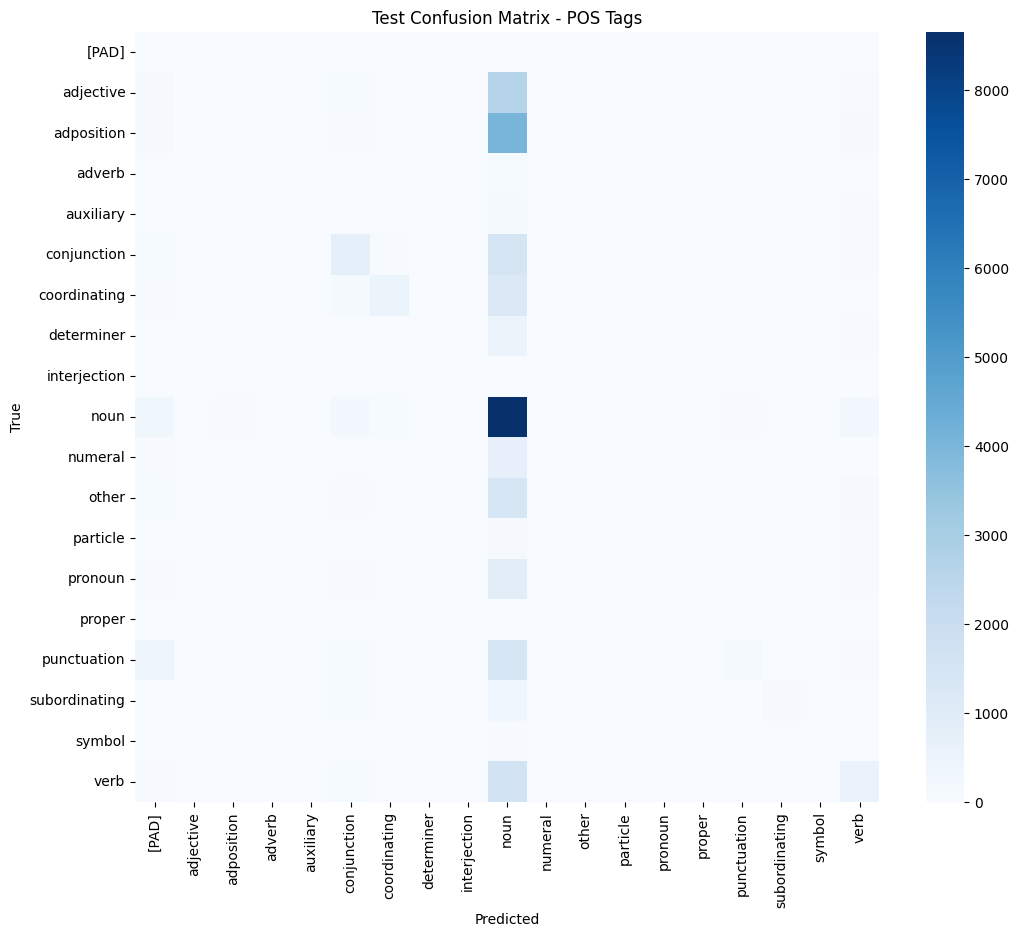

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

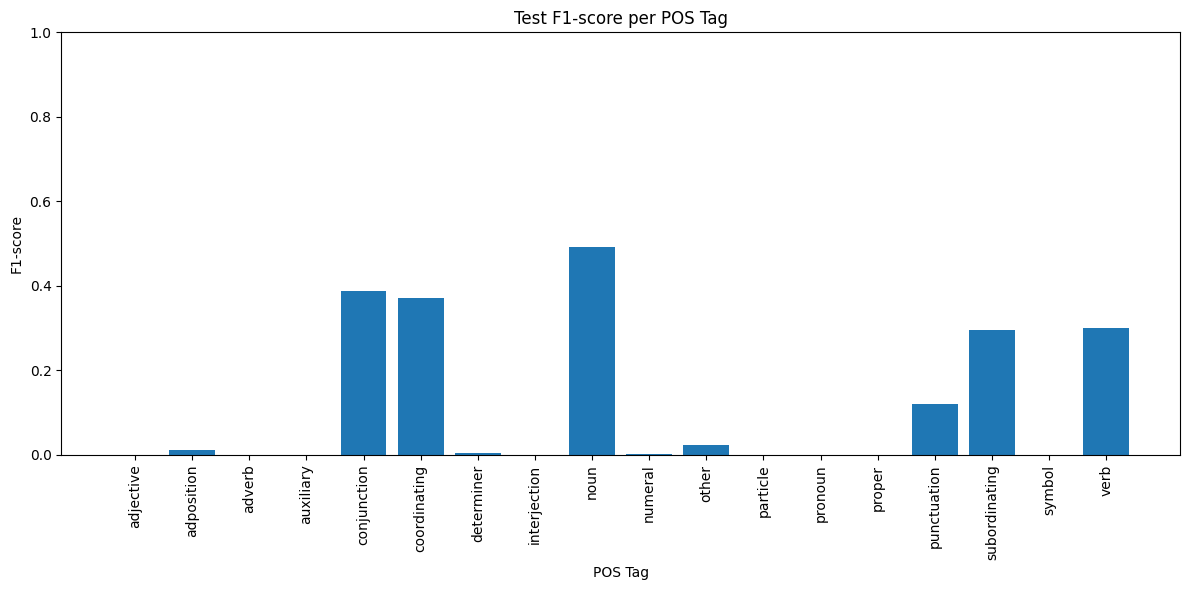

Test Sequence-level accuracy: 0.002607561929595828


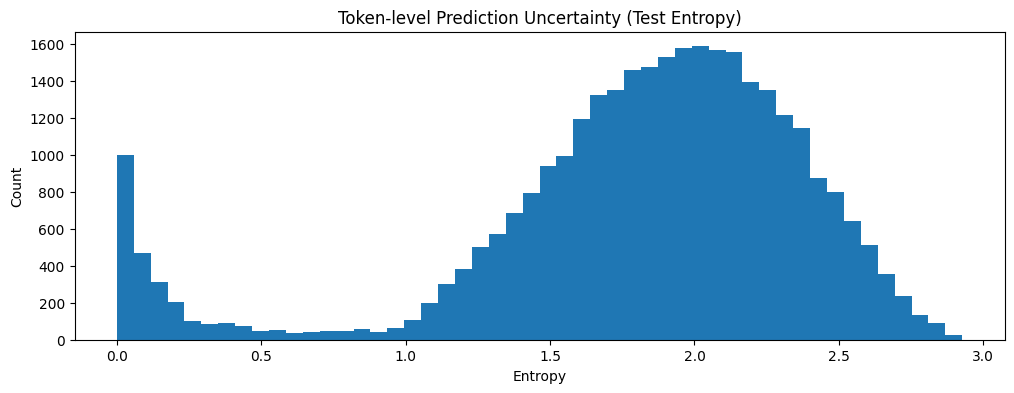

BLEU score (corpus-level): 12.93

Sample 1:
Words:  ['و', 'قال', 'غازي', 'عبد', 'الجواد', 'إن', 'ه', 'تم', 'التفاهم', 'ب', 'الفعل', 'على', 'خطوات', 'محددة', 'ل', 'جدولة', 'الدين', 'حيث', 'يتم', 'سداد', 'ها', 'ب', 'مواعيد', 'متفق', 'علي', 'ها', 'على', 'فترات', 'زمنية', 'محددة']
Gold tags:   ['coordinating', 'conjunction', 'verb', 'other', 'other', 'other', 'subordinating', 'conjunction', 'pronoun', 'verb', 'noun', 'adposition', 'noun', 'adposition', 'noun', 'adjective', 'adposition', 'noun', 'noun', 'coordinating', 'conjunction', 'verb', 'noun', 'pronoun', 'adposition', 'noun', 'adjective', 'adposition', 'pronoun', 'adposition', 'noun', 'adjective', 'adjective', 'punctuation']
Predicted:   ['coordinating', 'conjunction', 'verb', 'other', 'subordinating', 'verb', 'subordinating', 'conjunction', 'verb', 'verb', 'noun', 'noun', 'noun', 'noun', 'noun', 'noun', 'noun', 'noun', 'noun', 'conjunction', 'conjunction', 'noun', 'noun', 'noun', 'noun', 'noun', 'noun', 'noun', 'noun', 'noun', 'noun'

In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import pickle
from tensorflow.keras.layers import Input, Embedding, Conv1D, Dense, LayerNormalization, Dropout, TimeDistributed
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

# ========= USER CONFIG ========= #
data_size = None  # Use all PADT data; set to int if you want a subset
max_epochs = 100
batch_size = 32
random_state = 42

# Excel you generated from PADT (with columns: train_sentence, train_pos_seq, dev_sentence, dev_pos_seq, test_sentence, test_pos_seq)
excel_path = "/kaggle/input/fulltag/padt_pos_4cols_fulltags.xlsx"

# Cache file for preprocessed tensors
pkl_path = "/kaggle/working/preprocessed_pos_data_padt_word.pkl"
# =============================== #

# ========== DATA PREPROCESS (CACHED) ========== #
if os.path.exists(pkl_path):
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    X = data["X"]
    y = data["y"]
    sentences = data["sentences"]
    tag_tokenizer = data["tag_tokenizer"]
    word_tokenizer = data["word_tokenizer"]
    print("Preprocessed PADT WORD-level data loaded from pickle file.")
else:
    # 1) Read PADT Excel
    df = pd.read_excel(excel_path)

    sent_cols = ["train_sentence", "dev_sentence", "test_sentence"]
    pos_cols  = ["train_pos_seq",  "dev_pos_seq",  "test_pos_seq"]

    all_sentences = []
    all_tags_seq  = []

    for s_col, p_col in zip(sent_cols, pos_cols):
        s = df[s_col].fillna("").astype(str).values
        p = df[p_col].fillna("").astype(str).values
        for sent, tags in zip(s, p):
            if sent.strip() == "" or tags.strip() == "":
                continue
            all_sentences.append(sent)
            all_tags_seq.append(tags)

    sentences = np.array(all_sentences)
    tags_seq  = np.array(all_tags_seq)

    if data_size is not None and data_size <= len(sentences):
        sentences = sentences[:data_size]
        tags_seq  = tags_seq[:data_size]

    print("Total sentences after filtering:", len(sentences))

    # 2) WORD-level tokenizer on sentences
    #    (each token is a word, separated by whitespace)
    word_tokenizer = Tokenizer(char_level=False, oov_token="[OOV]")
    word_tokenizer.fit_on_texts(sentences)
    X_seqs = word_tokenizer.texts_to_sequences(sentences)

    # 3) Tag tokenizer on full-word tags (e.g., "noun verb determiner")
    tag_tokenizer = Tokenizer()
    tag_tokenizer.fit_on_texts(tags_seq)
    y_seqs = tag_tokenizer.texts_to_sequences(tags_seq)

    # 4) Pad both to the same max_len
    MAX_LEN = None  # None = use max length in data; or set e.g. 100 if you want truncation
    X = pad_sequences(X_seqs, padding='post', truncating='post', maxlen=MAX_LEN)
    y = pad_sequences(y_seqs, padding='post', truncating='post', maxlen=X.shape[1])

    with open(pkl_path, "wb") as f:
        pickle.dump({
            "X": X,
            "y": y,
            "sentences": sentences,
            "tag_tokenizer": tag_tokenizer,
            "word_tokenizer": word_tokenizer
        }, f)
    print("Preprocessed PADT WORD-level data saved to pickle file.")

# Inspect label distribution
unique, counts = np.unique(y, return_counts=True)
print("Label distribution:", dict(zip(unique, counts)))

vocab_size = len(word_tokenizer.word_index) + 1
tag_count = len(tag_tokenizer.word_index) + 1
max_len = X.shape[1]
max_tags = y.shape[1]

print("vocab_size:", vocab_size)
print("tag_count :", tag_count)
print("max_len   :", max_len)
print("max_tags  :", max_tags)

# ========== DATA SPLIT ========== #
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.1, random_state=random_state
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.1111, random_state=random_state
)
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

# ========== MODEL BLOCKS ========== #
class SimpleTransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, num_heads, embed_dim, ff_dim):
        super().__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation='relu'),
            Dense(embed_dim)
        ])
        self.layernorm1 = LayerNormalization()
        self.layernorm2 = LayerNormalization()
        self.dropout1 = Dropout(0.15)
        self.dropout2 = Dropout(0.15)

    def call(self, inputs):
        attn_output = self.att(inputs, inputs)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        out2 = self.layernorm2(out1 + ffn_output)
        return self.dropout2(out2)

class StackedTransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, num_layers=4, num_heads=8, embed_dim=128, ff_dim=256, dropout=0.18):
        super().__init__()
        self.encoders = [
            SimpleTransformerEncoder(num_heads=num_heads, embed_dim=embed_dim, ff_dim=ff_dim)
            for _ in range(num_layers)
        ]
        self.norm = LayerNormalization()
        self.dropout = Dropout(dropout)

    def call(self, inputs):
        x = inputs
        for encoder in self.encoders:
            x = encoder(x)
        x = self.norm(x)
        return self.dropout(x)

class DeepCNNSDEPoss(tf.keras.layers.Layer):
    def __init__(self, filters=128, kernel_size=7, layers=2):
        super().__init__()
        self.cnns = [Conv1D(filters, kernel_size, padding='same', activation='relu') for _ in range(layers)]
        self.dropouts = [Dropout(0.2 + (i * 0.07)) for i in range(layers)]
        self.drifts = [Dense(filters) for _ in range(layers)]
        self.diffusions = [Dense(filters) for _ in range(layers)]

    def call(self, inputs, training=None):
        x = inputs
        dt = 1.0
        for cnn, drift, diffu, drop in zip(self.cnns, self.drifts, self.diffusions, self.dropouts):
            x = drop(x, training=training)
            x = cnn(x)
            batch_size = tf.shape(x)[0]
            seq_len = tf.shape(x)[1]
            c_dim = tf.shape(x)[2]
            noise = tf.random.normal((batch_size, seq_len, c_dim), mean=0., stddev=1.)
            x = x + drift(x) * dt + diffu(x) * noise * tf.sqrt(dt)
        return x

# ========== MODEL DEFINITION (WORD-LEVEL, NO FLATTEN) ========== #
from tensorflow.keras.optimizers import Adam

inputs = Input(shape=(max_len,), name='input')
emb = Embedding(vocab_size, 128, mask_zero=True)(inputs)
encoder = StackedTransformerEncoder(
    num_layers=4, num_heads=8, embed_dim=128, ff_dim=256, dropout=0.18
)(emb)
decoder_cnn = DeepCNNSDEPoss(filters=128, kernel_size=7, layers=2)(encoder)

# One softmax per time-step (word)
logits = TimeDistributed(Dense(tag_count, activation='softmax'))(decoder_cnn)

model = Model(inputs, logits)
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

# Targets: (batch, max_len, 1)
y_train_targets = np.expand_dims(y_train, -1)
y_val_targets   = np.expand_dims(y_val, -1)

early = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('/kaggle/working/best_model.keras', monitor='val_loss', save_best_only=True)

history = model.fit(
    X_train, y_train_targets,
    batch_size=batch_size,
    epochs=max_epochs,
    validation_data=(X_val, y_val_targets),
    callbacks=[early, checkpoint]
)

# ========== EVALUATION & VISUALIZATION ========== #
y_probs = model.predict(X_test)
y_pred = np.argmax(y_probs, axis=-1)
y_true = y_test

y_true = np.squeeze(y_true)
y_pred = np.squeeze(y_pred)

mask = (y_true != 0)
y_true_flat = y_true[mask]
y_pred_flat = y_pred[mask]

idx2tag = {v: k for k, v in tag_tokenizer.word_index.items()}
idx2tag[0] = '[PAD]'
y_true_tags = [idx2tag[idx] for idx in y_true_flat]
y_pred_tags = [idx2tag[idx] for idx in y_pred_flat]

print("\nTest Classification Report:")
with open('/kaggle/working/test_classification_report.txt', 'w', encoding='utf-8') as f:
    f.write(classification_report(y_true_tags, y_pred_tags))
print(classification_report(y_true_tags, y_pred_tags))

labels = np.unique(y_true_tags + y_pred_tags)
cm = confusion_matrix(y_true_tags, y_pred_tags, labels=labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix - POS Tags")
plt.savefig('/kaggle/working/Test_Confusion_Matrix.png')
plt.show()

report = classification_report(y_true_tags, y_pred_tags, output_dict=True)
f1s = [report[tag]['f1-score'] for tag in labels if tag != '[PAD]']
plt.figure(figsize=(12, 6))
plt.bar(labels[1:], f1s)
plt.title("Test F1-score per POS Tag")
plt.xlabel("POS Tag")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('/kaggle/working/Test_F1-score.png')
plt.show()

sequence_correct = (y_true == y_pred).all(axis=1)
print("Test Sequence-level accuracy:", sequence_correct.mean())

def compute_entropy(prob_vec):
    prob_vec = np.clip(prob_vec, 1e-12, 1 - 1e-12)
    return -np.sum(prob_vec * np.log(prob_vec), axis=-1)

entropies = compute_entropy(y_probs)
plt.figure(figsize=(12, 4))
plt.hist(entropies[mask], bins=50)
plt.title("Token-level Prediction Uncertainty (Test Entropy)")
plt.xlabel("Entropy")
plt.ylabel("Count")
plt.savefig('/kaggle/working/Test_Token-level_Prediction_Uncertainty.png')
plt.show()

# --- BLEU Evaluation ---
bleu_hyps, bleu_refs = [], []
for i in range(y_true.shape[0]):
    ref_seq = [idx2tag[tag] for tag in y_true[i] if tag != 0]
    hyp_seq = [idx2tag[tag] for tag in y_pred[i] if tag != 0]
    if ref_seq and hyp_seq:
        bleu_refs.append([ref_seq])
        bleu_hyps.append(hyp_seq)
bleu = corpus_bleu(bleu_refs, bleu_hyps, smoothing_function=SmoothingFunction().method4)
print(f"BLEU score (corpus-level): {bleu*100:.2f}")

# --- Sample Print ---
n_samples = 5
idx2word = {v: k for k, v in word_tokenizer.word_index.items()}
idx2word[0] = '[PAD]'

for i in range(n_samples):
    idx = np.random.randint(len(X_test))
    words = [idx2word[w] for w in X_test[idx] if w != 0]
    true_seq = [idx2tag[tag] for tag in y_true[idx] if tag != 0]
    pred_seq = [idx2tag[tag] for tag in y_pred[idx] if tag != 0]
    print(f"\nSample {i+1}:")
    print("Words: ", words)
    print("Gold tags:  ", true_seq)
    print("Predicted:  ", pred_seq)
    print("-" * 40)


Preprocessed PADT WORD-level data loaded from pickle file.
Class weights: {1: 0.0014261107004977455, 2: 0.0031486057191010513, 3: 0.004564448354884633, 4: 0.005308819019504388, 5: 0.005713444950915048, 6: 0.0059693164439710445, 7: 0.0067799084076907695, 8: 0.007803648509795771, 9: 0.012320190409192884, 10: 0.01726700571270356, 11: 0.022723906754733538, 12: 0.024467110560576114, 13: 0.06075166907898151, 14: 0.06227681558305635, 15: 0.12278407911929809, 16: 0.3452511090699851, 17: 0.5467650217108336, 18: 16.744678789894277, 0: 0.0}
vocab_size: 24655
tag_count : 19
max_len   : 387
Train: (6130, 387) (6130, 387)
Val:   (767, 387) (767, 387)
Test:  (767, 387) (767, 387)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'stacked_transformer_encoder_3' (of type StackedTransformerEncoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 387)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 387, 128)       │     3,155,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stacked_transformer_encoder_3   │ (None, 387, 128)       │       660,736 │
│ (StackedTransformerEncoder)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deep_cnnsde_poss_3              │ (None, 387, 64)        │        49,344 │
│ (DeepCNNSDEPoss)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 387, 19)        │         1,235 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,867,155 (14.75 MB)

...

191/192 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.0143 - loss: 0.0029

W0000 00:00:1764346556.830913     102 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 534ms/step - accuracy: 0.0143 - loss: 0.0029

W0000 00:00:1764346657.412199     100 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1764346710.937683     102 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


192/192 ━━━━━━━━━━━━━━━━━━━━ 346s 1s/step - accuracy: 0.0143 - loss: 0.0029 - val_accuracy: 0.0095 - val_loss: 0.0023
Epoch 2/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.0095 - loss: 0.0024 - val_accuracy: 0.0139 - val_loss: 0.0023
Epoch 3/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.0096 - loss: 0.0024 - val_accuracy: 0.0147 - val_loss: 0.0023
Epoch 4/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.0096 - loss: 0.0024 - val_accuracy: 0.0138 - val_loss: 0.0023
Epoch 5/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.0100 - loss: 0.0025 - val_accuracy: 0.0141 - val_loss: 0.0023
Epoch 6/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.0096 - loss: 0.0023 - val_accuracy: 0.0157 - val_loss: 0.0023
Epoch 7/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.0100 - loss: 0.0024 - val_accuracy: 0.0162 - val_loss: 0.0023
Epoch 8/60
192/192 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.0107 - loss: 0.0024 - val_accuracy: 0.016

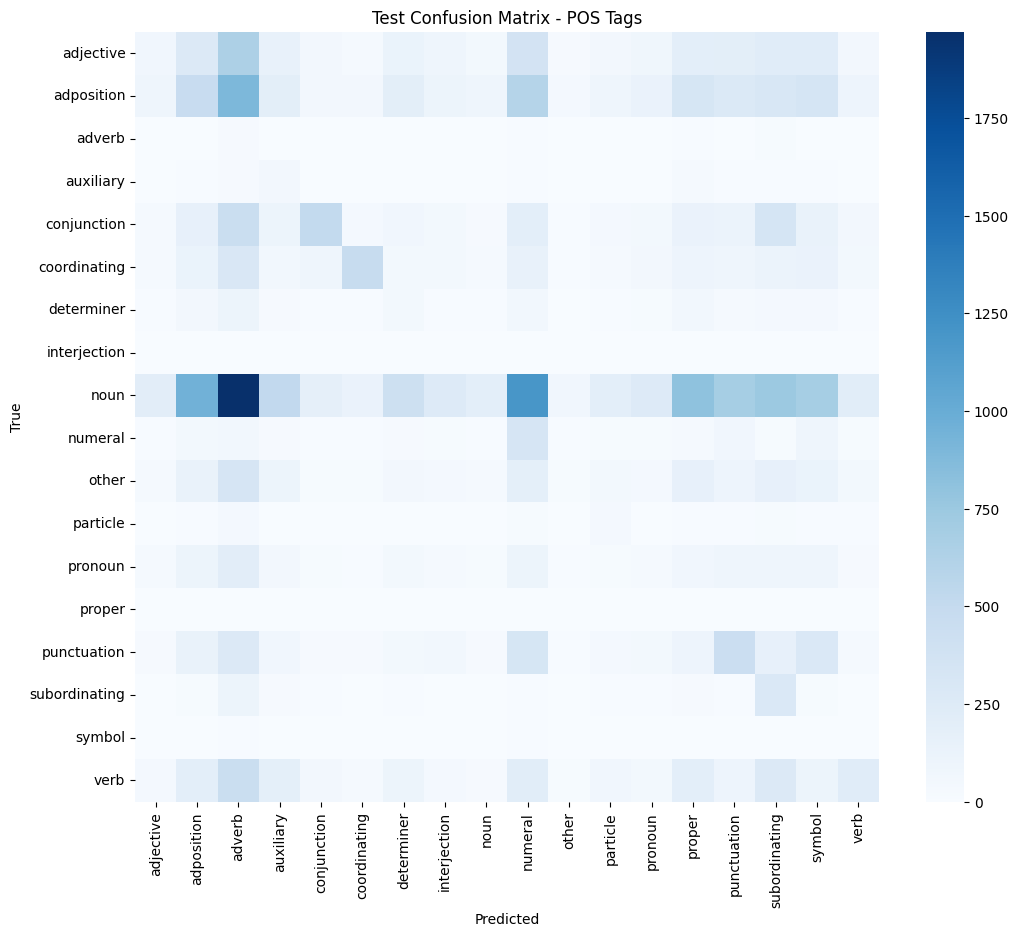

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (17,) and arg 1 with shape (18,).

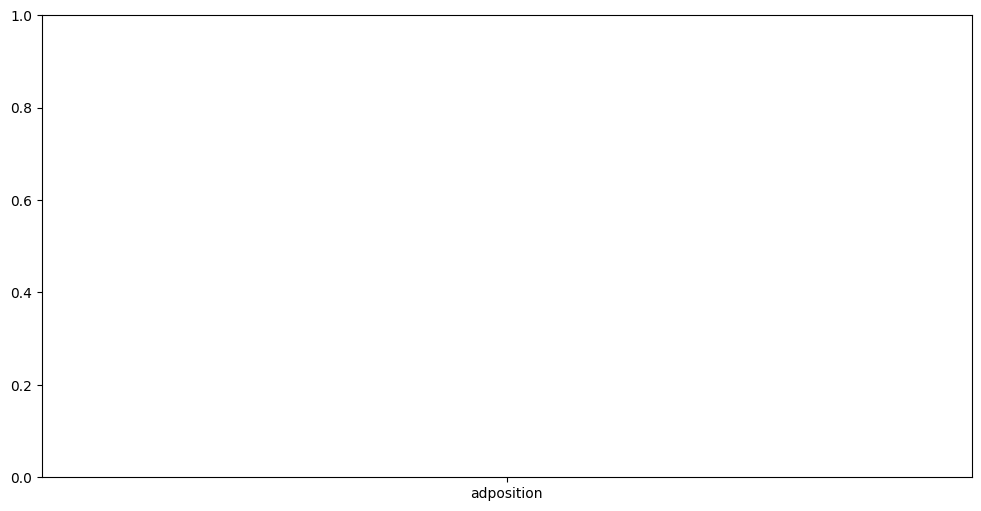

In [4]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import pickle
from tensorflow.keras.layers import Input, Embedding, Conv1D, Dense, LayerNormalization, Dropout, TimeDistributed
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

# ========= USER CONFIG ========= #
data_size = None  # Use all PADT data; set to int if you want a subset
max_epochs = 60
batch_size = 32
random_state = 42

excel_path = "/kaggle/input/fulltag/padt_pos_4cols_fulltags.xlsx"
pkl_path   = "/kaggle/working/preprocessed_pos_data_padt_word.pkl"
# =============================== #

# ========== DATA PREPROCESS (CACHED) ========== #
if os.path.exists(pkl_path):
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    X = data["X"]
    y = data["y"]
    sentences = data["sentences"]
    tag_tokenizer = data["tag_tokenizer"]
    word_tokenizer = data["word_tokenizer"]
    print("Preprocessed PADT WORD-level data loaded from pickle file.")
else:
    df = pd.read_excel(excel_path)

    sent_cols = ["train_sentence", "dev_sentence", "test_sentence"]
    pos_cols  = ["train_pos_seq",  "dev_pos_seq",  "test_pos_seq"]

    all_sentences, all_tags_seq = [], []
    for s_col, p_col in zip(sent_cols, pos_cols):
        s = df[s_col].fillna("").astype(str).values
        p = df[p_col].fillna("").astype(str).values
        for sent, tags in zip(s, p):
            if sent.strip() == "" or tags.strip() == "":
                continue
            all_sentences.append(sent)
            all_tags_seq.append(tags)

    sentences = np.array(all_sentences)
    tags_seq  = np.array(all_tags_seq)

    if data_size is not None and data_size <= len(sentences):
        sentences = sentences[:data_size]
        tags_seq  = tags_seq[:data_size]

    print("Total sentences after filtering:", len(sentences))

    # word-level tokenizer
    word_tokenizer = Tokenizer(char_level=False, oov_token="[OOV]")
    word_tokenizer.fit_on_texts(sentences)
    X_seqs = word_tokenizer.texts_to_sequences(sentences)

    # tag tokenizer
    tag_tokenizer = Tokenizer()
    tag_tokenizer.fit_on_texts(tags_seq)
    y_seqs = tag_tokenizer.texts_to_sequences(tags_seq)

    # pad to same MAX_LEN
    MAX_LEN = None  # or e.g. 100 لتقليل الطول
    X = pad_sequences(X_seqs, padding='post', truncating='post', maxlen=MAX_LEN)
    y = pad_sequences(y_seqs, padding='post', truncating='post', maxlen=X.shape[1])

    with open(pkl_path, "wb") as f:
        pickle.dump({
            "X": X,
            "y": y,
            "sentences": sentences,
            "tag_tokenizer": tag_tokenizer,
            "word_tokenizer": word_tokenizer
        }, f)
    print("Preprocessed PADT WORD-level data saved to pickle file.")

# ====== CLASS WEIGHTS (token-level) ====== #
# تجاهل 0 (PAD) عند حساب الأوزان
all_labels = y.flatten()
non_pad = all_labels[all_labels != 0]
labels, freqs = np.unique(non_pad, return_counts=True)
inv_freq = 1.0 / freqs
inv_freq = inv_freq / inv_freq.mean()  # normalize for stability
class_weight_vec = {int(label): float(w) for label, w in zip(labels, inv_freq)}
class_weight_vec[0] = 0.0  # لا نعاقب على البادينغ

print("Class weights:", class_weight_vec)

# سنحوّلها إلى مصفوفة 2D بنفس شكل y لكل عينة
def make_sample_weights(y_array):
    w = np.ones_like(y_array, dtype="float32")
    for lab, cw in class_weight_vec.items():
        w[y_array == lab] = cw
    return w

sample_weights = make_sample_weights(y)

# ========== SHAPES & SPLIT ========== #
vocab_size = len(word_tokenizer.word_index) + 1
tag_count = len(tag_tokenizer.word_index) + 1
max_len = X.shape[1]

print("vocab_size:", vocab_size)
print("tag_count :", tag_count)
print("max_len   :", max_len)

X_trainval, X_test, y_trainval, y_test, sw_trainval, sw_test = train_test_split(
    X, y, sample_weights, test_size=0.1, random_state=random_state
)
X_train, X_val, y_train, y_val, sw_train, sw_val = train_test_split(
    X_trainval, y_trainval, sw_trainval, test_size=0.1111, random_state=random_state
)
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

# ========== MODEL BLOCKS ========== #
class SimpleTransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, num_heads, embed_dim, ff_dim):
        super().__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation='relu'),
            Dense(embed_dim)
        ])
        self.layernorm1 = LayerNormalization()
        self.layernorm2 = LayerNormalization()
        self.dropout1 = Dropout(0.1)
        self.dropout2 = Dropout(0.1)

    def call(self, inputs):
        attn_output = self.att(inputs, inputs)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        out2 = self.layernorm2(out1 + ffn_output)
        return self.dropout2(out2)

class StackedTransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, num_layers=2, num_heads=4, embed_dim=128, ff_dim=256, dropout=0.15):
        super().__init__()
        self.encoders = [
            SimpleTransformerEncoder(num_heads=num_heads, embed_dim=embed_dim, ff_dim=ff_dim)
            for _ in range(num_layers)
        ]
        self.norm = LayerNormalization()
        self.dropout = Dropout(dropout)

    def call(self, inputs):
        x = inputs
        for encoder in self.encoders:
            x = encoder(x)
        x = self.norm(x)
        return self.dropout(x)

class DeepCNNSDEPoss(tf.keras.layers.Layer):
    def __init__(self, filters=64, kernel_size=5, layers=1):
        super().__init__()
        self.cnns = [Conv1D(filters, kernel_size, padding='same', activation='relu') for _ in range(layers)]
        self.dropouts = [Dropout(0.25) for _ in range(layers)]
        self.drifts = [Dense(filters) for _ in range(layers)]
        self.diffusions = [Dense(filters) for _ in range(layers)]

    def call(self, inputs, training=None):
        x = inputs
        dt = 1.0
        for cnn, drift, diffu, drop in zip(self.cnns, self.drifts, self.diffusions, self.dropouts):
            x = drop(x, training=training)
            x = cnn(x)
            b = tf.shape(x)[0]
            t = tf.shape(x)[1]
            c = tf.shape(x)[2]
            noise = tf.random.normal((b, t, c), mean=0., stddev=1.)
            x = x + drift(x) * dt + diffu(x) * noise * tf.sqrt(dt)
        return x

# ========== MODEL DEFINITION ========== #
from tensorflow.keras.optimizers import Adam

inputs = Input(shape=(max_len,), name='input')
emb = Embedding(vocab_size, 128, mask_zero=True)(inputs)
encoder = StackedTransformerEncoder()(emb)
decoder_cnn = DeepCNNSDEPoss()(encoder)
logits = TimeDistributed(Dense(tag_count, activation='softmax'))(decoder_cnn)

model = Model(inputs, logits)
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

y_train_targets = np.expand_dims(y_train, -1)
y_val_targets   = np.expand_dims(y_val, -1)

early = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
checkpoint = ModelCheckpoint('/kaggle/working/best_model.keras', monitor='val_loss', save_best_only=True)

history = model.fit(
    X_train, y_train_targets,
    sample_weight=sw_train,
    batch_size=batch_size,
    epochs=max_epochs,
    validation_data=(X_val, y_val_targets, sw_val),
    callbacks=[early, checkpoint]
)

# ========== EVALUATION & VISUALIZATION ========== #
y_probs = model.predict(X_test)
y_pred = np.argmax(y_probs, axis=-1)
y_true = y_test

y_true = np.squeeze(y_true)
y_pred = np.squeeze(y_pred)

mask = (y_true != 0)
y_true_flat = y_true[mask]
y_pred_flat = y_pred[mask]

idx2tag = {v: k for k, v in tag_tokenizer.word_index.items()}
idx2tag[0] = '[PAD]'
y_true_tags = [idx2tag[idx] for idx in y_true_flat]
y_pred_tags = [idx2tag[idx] for idx in y_pred_flat]

print("\nTest Classification Report:")
with open('/kaggle/working/test_classification_report.txt', 'w', encoding='utf-8') as f:
    f.write(classification_report(y_true_tags, y_pred_tags))
print(classification_report(y_true_tags, y_pred_tags))

labels = np.unique(y_true_tags + y_pred_tags)
cm = confusion_matrix(y_true_tags, y_pred_tags, labels=labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix - POS Tags")
plt.savefig('/kaggle/working/Test_Confusion_Matrix.png')
plt.show()

report = classification_report(y_true_tags, y_pred_tags, output_dict=True)
f1s = [report[tag]['f1-score'] for tag in labels if tag != '[PAD]']
plt.figure(figsize=(12, 6))
plt.bar(labels[1:], f1s)
plt.title("Test F1-score per POS Tag")
plt.xlabel("POS Tag")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('/kaggle/working/Test_F1-score.png')
plt.show()

sequence_correct = (y_true == y_pred).all(axis=1)
print("Test Sequence-level accuracy:", sequence_correct.mean())

def compute_entropy(prob_vec):
    prob_vec = np.clip(prob_vec, 1e-12, 1 - 1e-12)
    return -np.sum(prob_vec * np.log(prob_vec), axis=-1)

entropies = compute_entropy(y_probs)
plt.figure(figsize=(12, 4))
plt.hist(entropies[mask], bins=50)
plt.title("Token-level Prediction Uncertainty (Test Entropy)")
plt.xlabel("Entropy")
plt.ylabel("Count")
plt.savefig('/kaggle/working/Test_Token-level_Prediction_Uncertainty.png')
plt.show()

# --- BLEU Evaluation ---
bleu_hyps, bleu_refs = [], []
for i in range(y_true.shape[0]):
    ref_seq = [idx2tag[tag] for tag in y_true[i] if tag != 0]
    hyp_seq = [idx2tag[tag] for tag in y_pred[i] if tag != 0]
    if ref_seq and hyp_seq:
        bleu_refs.append([ref_seq])
        bleu_hyps.append(hyp_seq)
bleu = corpus_bleu(bleu_refs, bleu_hyps, smoothing_function=SmoothingFunction().method4)
print(f"BLEU score (corpus-level): {bleu*100:.2f}")

# --- Sample Print ---
n_samples = 5
idx2word = {v: k for k, v in word_tokenizer.word_index.items()}
idx2word[0] = '[PAD]'

for i in range(n_samples):
    idx = np.random.randint(len(X_test))
    words = [idx2word[w] for w in X_test[idx] if w != 0]
    true_seq = [idx2tag[tag] for tag in y_true[idx] if tag != 0]
    pred_seq = [idx2tag[tag] for tag in y_pred[idx] if tag != 0]
    print(f"\nSample {i+1}:")
    print("Words: ", words)
    print("Gold tags:  ", true_seq)
    print("Predicted:  ", pred_seq)
    print("-" * 40)


Total sentences: 7664
Saved preprocessed data to pickle.
vocab_size: 24655
tag_count : 19
max_len   : 100
Train: (6130, 100) (6130, 100)
Val:   (767, 100) (767, 100)
Test:  (767, 100) (767, 100)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'deep_cnnsde_poss_4' (of type DeepCNNSDEPoss) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_5 (Embedding)         │ (None, 100, 128)       │     3,155,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deep_cnnsde_poss_4              │ (None, 100, 128)       │       295,680 │
│ (DeepCNNSDEPoss)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 100, 19)        │         2,451 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,971 (13.18 MB)

...

192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.6780 - loss: 1.1720

W0000 00:00:1764347506.086051      99 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1764347519.803374      99 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


192/192 ━━━━━━━━━━━━━━━━━━━━ 88s 282ms/step - accuracy: 0.6782 - loss: 1.1709 - val_accuracy: 0.7441 - val_loss: 0.8117
Epoch 2/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7395 - loss: 0.8131 - val_accuracy: 0.7508 - val_loss: 0.7646
Epoch 3/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7584 - loss: 0.7325 - val_accuracy: 0.7524 - val_loss: 0.7643
Epoch 4/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7898 - loss: 0.6411 - val_accuracy: 0.7471 - val_loss: 0.7991
Epoch 5/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8196 - loss: 0.5663 - val_accuracy: 0.7432 - val_loss: 0.8592
Epoch 6/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8498 - loss: 0.4793 - val_accuracy: 0.7425 - val_loss: 0.9286
Epoch 7/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8679 - loss: 0.4314 - val_accuracy: 0.7374 - val_loss: 1.0131
Epoch 8/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8849 - loss: 0.3800 - val_accuracy: 0.7382 - v

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

               precision    recall  f1-score   support

        [PAD]       0.00      0.00      0.00         0
    adjective       0.33      0.07      0.11      2823
   adposition       0.32      0.19      0.24      4218
       adverb       0.00      0.00      0.00        99
    auxiliary       0.22      0.13      0.17       204
  conjunction       0.39      0.36      0.37      2427
 coordinating       0.44      0.33      0.37      1873
   determiner       0.20      0.11      0.15       545
 interjection       0.00      0.00      0.00         1
         noun       0.39      0.65      0.49      9315
      numeral       0.33      0.30      0.31       807
        other       0.40      0.28      0.33      1666
     particle       0.04      0.00      0.01       216
      pronoun       0.26      0.11      0.16      1043
       proper       0.00      0.00      0.00        29
  punctuation       0.31      0.06      0.10      2057
subordinating       0.37      0.39      0.38       557
       sy

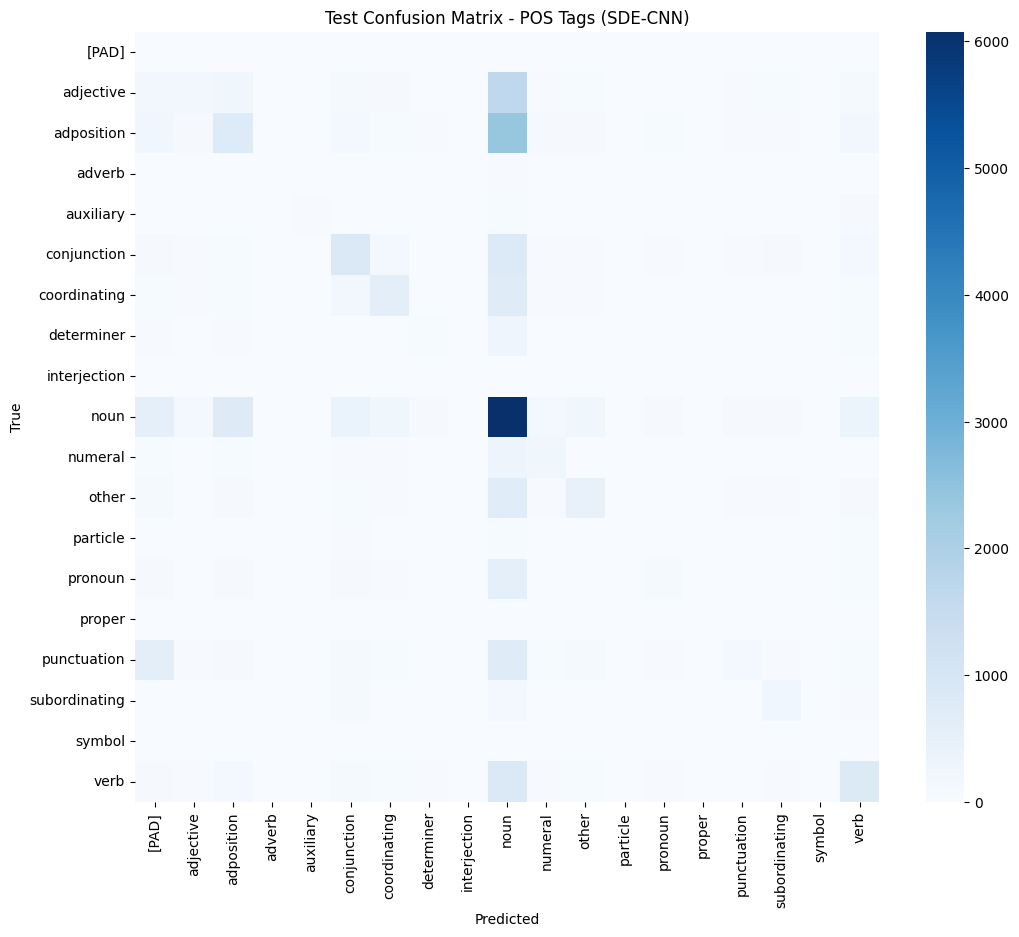

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

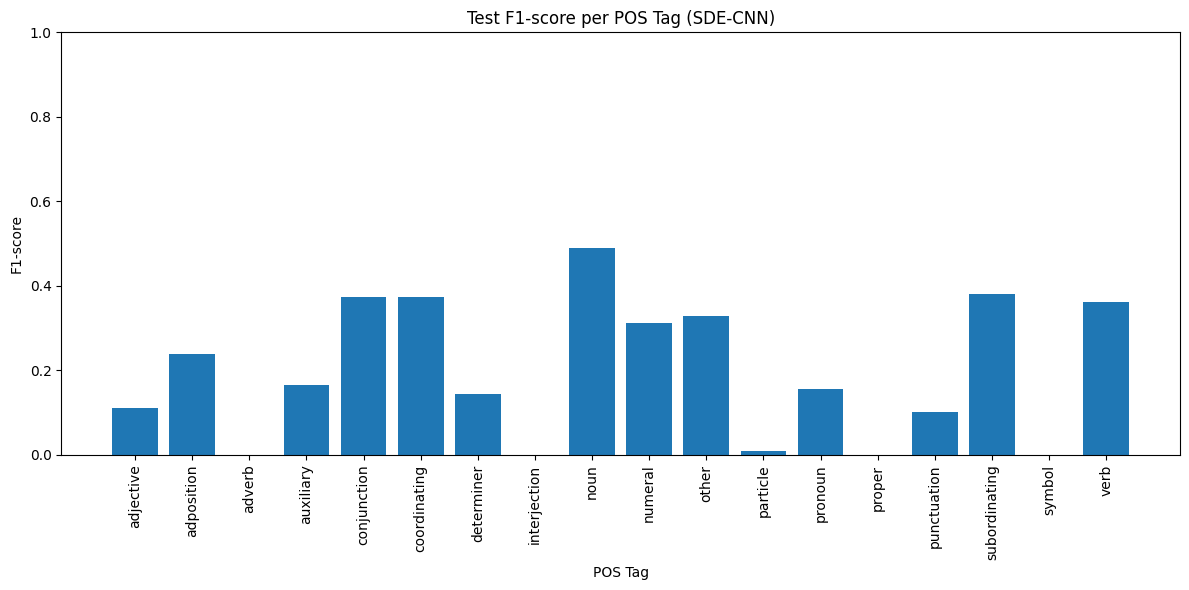

Test Sequence-level accuracy: 0.01955671447196871


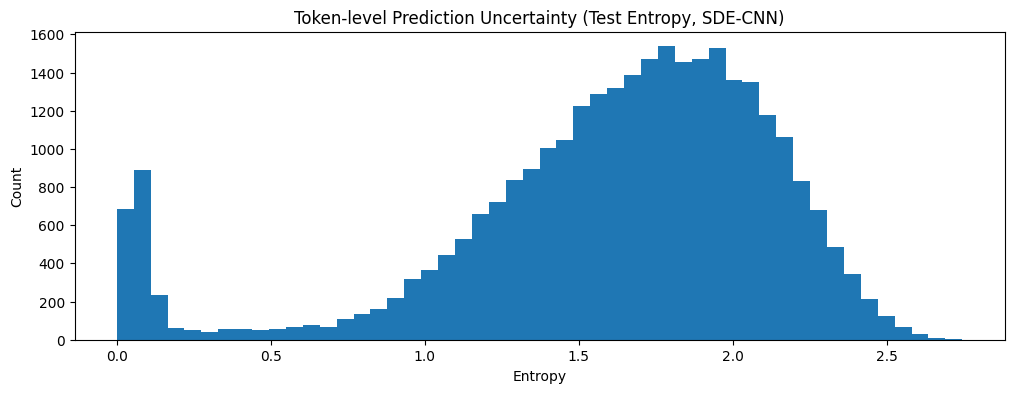

BLEU score (corpus-level): 29.61

Sample 1:
Words:  ['انتقد', 'مفتى', 'القدس', 'و', 'الديار', 'الفلسطينية', 'الشيخ', 'عكرمة', 'صبري', 'ب', 'شدة', 'وثيقة', 'جنيف', 'و', 'القائمين', 'علي', 'ها', '،', 'خصوصاً', 'في', 'ما', 'يتعلق', 'ب', 'منح', 'الإسرائيليين', 'السيادة', 'على', 'الحائط', 'الجنوبي', 'ل', 'الحرم', 'القدسي', 'الشريف', '،', 'المعروف', 'ب', 'حائط', 'البراق', '،', 'و', 'الذي', 'يطلق', 'علي', 'ه', 'الإسرائيليون', 'حائط', 'المبكي']
Gold tags:   ['verb', 'noun', 'noun', 'coordinating', 'conjunction', 'noun', 'adjective', 'noun', 'other', 'other', 'adposition', 'noun', 'punctuation', 'noun', 'other', 'punctuation', 'coordinating', 'conjunction', 'adjective', 'adposition', 'pronoun', 'punctuation', 'noun', 'adposition', 'determiner', 'verb', 'adposition', 'noun', 'noun', 'punctuation', 'noun', 'punctuation', 'adposition', 'noun', 'adjective', 'adposition', 'noun', 'noun', 'adjective', 'punctuation', 'adjective', 'adposition', 'noun', 'noun', 'punctuation', 'coordinating', 'conjunctio

In [6]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import pickle
from tensorflow.keras.layers import Input, Embedding, Conv1D, Dense, Dropout, TimeDistributed
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from tensorflow.keras.optimizers import Adam

# ========= USER CONFIG ========= #
data_size = None
max_epochs = 40
batch_size = 32
random_state = 42

excel_path = "/kaggle/input/fulltag/padt_pos_4cols_fulltags.xlsx"
pkl_path   = "/kaggle/working/preprocessed_pos_data_padt_word_sde.pkl"
MAX_LEN    = 100   # طول تسلسل الكلمات
EMB_DIM    = 128
SDE_FILTERS = 128
SDE_KERNEL  = 7
SDE_LAYERS  = 2
# =============================== #

# ========== DATA PREPROCESS (CACHED) ========== #
if os.path.exists(pkl_path):
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    X = data["X"]
    y = data["y"]
    sentences = data["sentences"]
    tag_tokenizer = data["tag_tokenizer"]
    word_tokenizer = data["word_tokenizer"]
    print("Loaded preprocessed data from pickle.")
else:
    df = pd.read_excel(excel_path)

    sent_cols = ["train_sentence", "dev_sentence", "test_sentence"]
    pos_cols  = ["train_pos_seq",  "dev_pos_seq",  "test_pos_seq"]

    all_sentences, all_tags_seq = [], []
    for s_col, p_col in zip(sent_cols, pos_cols):
        s = df[s_col].fillna("").astype(str).values
        p = df[p_col].fillna("").astype(str).values
        for sent, tags in zip(s, p):
            if sent.strip() == "" or tags.strip() == "":
                continue
            all_sentences.append(sent)
            all_tags_seq.append(tags)

    sentences = np.array(all_sentences)
    tags_seq  = np.array(all_tags_seq)

    if data_size is not None and data_size <= len(sentences):
        sentences = sentences[:data_size]
        tags_seq  = tags_seq[:data_size]

    print("Total sentences:", len(sentences))

    # word tokenizer
    word_tokenizer = Tokenizer(char_level=False, oov_token="[OOV]")
    word_tokenizer.fit_on_texts(sentences)
    X_seqs = word_tokenizer.texts_to_sequences(sentences)

    # tag tokenizer
    tag_tokenizer = Tokenizer()
    tag_tokenizer.fit_on_texts(tags_seq)
    y_seqs = tag_tokenizer.texts_to_sequences(tags_seq)

    # pad/truncate to MAX_LEN
    X = pad_sequences(X_seqs, maxlen=MAX_LEN, padding='post', truncating='post')
    y = pad_sequences(y_seqs, maxlen=MAX_LEN, padding='post', truncating='post')

    with open(pkl_path, "wb") as f:
        pickle.dump({
            "X": X,
            "y": y,
            "sentences": sentences,
            "tag_tokenizer": tag_tokenizer,
            "word_tokenizer": word_tokenizer
        }, f)
    print("Saved preprocessed data to pickle.")

# ====== SHAPES ====== #
vocab_size = len(word_tokenizer.word_index) + 1
tag_count  = len(tag_tokenizer.word_index) + 1
max_len    = X.shape[1]

print("vocab_size:", vocab_size)
print("tag_count :", tag_count)
print("max_len   :", max_len)

# ====== SPLIT ====== #
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.1, random_state=random_state
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.1111, random_state=random_state
)
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

# ====== SDE-CNN BLOCK ====== #
class DeepCNNSDEPoss(tf.keras.layers.Layer):
    def __init__(self, filters=SDE_FILTERS, kernel_size=SDE_KERNEL, layers=SDE_LAYERS):
        super().__init__()
        self.cnns = [Conv1D(filters, kernel_size, padding='same', activation='relu') for _ in range(layers)]
        self.dropouts = [Dropout(0.25) for _ in range(layers)]
        self.drifts = [Dense(filters) for _ in range(layers)]
        self.diffusions = [Dense(filters) for _ in range(layers)]

    def call(self, inputs, training=None):
        x = inputs
        dt = 1.0
        for cnn, drift, diffu, drop in zip(self.cnns, self.drifts, self.diffusions, self.dropouts):
            x = drop(x, training=training)
            x = cnn(x)
            b = tf.shape(x)[0]
            t = tf.shape(x)[1]
            c = tf.shape(x)[2]
            noise = tf.random.normal((b, t, c), mean=0., stddev=1.)
            x = x + drift(x) * dt + diffu(x) * noise * tf.sqrt(dt)
        return x

# ====== MODEL: Emb + SDE-CNN + TimeDistributed ====== #
inputs = Input(shape=(max_len,), name="input")
emb = Embedding(vocab_size, EMB_DIM, mask_zero=True)(inputs)
sde_out = DeepCNNSDEPoss()(emb)
logits = TimeDistributed(Dense(tag_count, activation="softmax"))(sde_out)

model = Model(inputs, logits)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

y_train_targets = np.expand_dims(y_train, -1)
y_val_targets   = np.expand_dims(y_val, -1)

early = EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
checkpoint = ModelCheckpoint("/kaggle/working/best_sde_pos.keras",
                             monitor="val_loss", save_best_only=True)

history = model.fit(
    X_train, y_train_targets,
    batch_size=batch_size,
    epochs=max_epochs,
    validation_data=(X_val, y_val_targets),
    callbacks=[early, checkpoint]
)

# ====== EVALUATION ====== #
y_probs = model.predict(X_test)
y_pred = np.argmax(y_probs, axis=-1)
y_true = y_test

y_true = np.squeeze(y_true)
y_pred = np.squeeze(y_pred)

mask = (y_true != 0)
y_true_flat = y_true[mask]
y_pred_flat = y_pred[mask]

idx2tag = {v: k for k, v in tag_tokenizer.word_index.items()}
idx2tag[0] = '[PAD]'
y_true_tags = [idx2tag[idx] for idx in y_true_flat]
y_pred_tags = [idx2tag[idx] for idx in y_pred_flat]

print("\nTest Classification Report:")
with open("/kaggle/working/test_classification_report_sde.txt", "w", encoding="utf-8") as f:
    f.write(classification_report(y_true_tags, y_pred_tags))
print(classification_report(y_true_tags, y_pred_tags))

labels = np.unique(y_true_tags + y_pred_tags)
cm = confusion_matrix(y_true_tags, y_pred_tags, labels=labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix - POS Tags (SDE-CNN)")
plt.savefig("/kaggle/working/Test_Confusion_Matrix_SDE.png")
plt.show()

report = classification_report(y_true_tags, y_pred_tags, output_dict=True)
f1s = [report[tag]["f1-score"] for tag in labels if tag != "[PAD]"]
plt.figure(figsize=(12, 6))
plt.bar(labels[1:], f1s)
plt.title("Test F1-score per POS Tag (SDE-CNN)")
plt.xlabel("POS Tag")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("/kaggle/working/Test_F1-score_SDE.png")
plt.show()

sequence_correct = (y_true == y_pred).all(axis=1)
print("Test Sequence-level accuracy:", sequence_correct.mean())

def compute_entropy(prob_vec):
    prob_vec = np.clip(prob_vec, 1e-12, 1 - 1e-12)
    return -np.sum(prob_vec * np.log(prob_vec), axis=-1)

entropies = compute_entropy(y_probs)
plt.figure(figsize=(12, 4))
plt.hist(entropies[mask], bins=50)
plt.title("Token-level Prediction Uncertainty (Test Entropy, SDE-CNN)")
plt.xlabel("Entropy")
plt.ylabel("Count")
plt.savefig("/kaggle/working/Test_Token-level_Prediction_Uncertainty_SDE.png")
plt.show()

# --- BLEU Evaluation ---
bleu_hyps, bleu_refs = [], []
for i in range(y_true.shape[0]):
    ref_seq = [idx2tag[tag] for tag in y_true[i] if tag != 0]
    hyp_seq = [idx2tag[tag] for tag in y_pred[i] if tag != 0]
    if ref_seq and hyp_seq:
        bleu_refs.append([ref_seq])
        bleu_hyps.append(hyp_seq)
bleu = corpus_bleu(bleu_refs, bleu_hyps, smoothing_function=SmoothingFunction().method4)
print(f"BLEU score (corpus-level): {bleu*100:.2f}")

# --- Sample Print ---
n_samples = 5
idx2word = {v: k for k, v in word_tokenizer.word_index.items()}
idx2word[0] = "[PAD]"

for i in range(n_samples):
    idx = np.random.randint(len(X_test))
    words = [idx2word[w] for w in X_test[idx] if w != 0]
    true_seq = [idx2tag[tag] for tag in y_true[idx] if tag != 0]
    pred_seq = [idx2tag[tag] for tag in y_pred[idx] if tag != 0]
    print(f"\nSample {i+1}:")
    print("Words: ", words)
    print("Gold tags:  ", true_seq)
    print("Predicted:  ", pred_seq)
    print("-" * 40)


Total sentences: 7664
Saved preprocessed WORD+CHAR data to pickle.
vocab_size_words: 24655
vocab_size_chars: 107
tag_count       : 19
max_len(words)  : 100
max_word_len    : 15
Train words: (6130, 100) chars: (6130, 100, 15) y: (6130, 100)
Val   words: (767, 100) chars: (767, 100, 15) y: (767, 100)
Test  words: (767, 100) chars: (767, 100, 15) y: (767, 100)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'deep_cnnsde_poss_5' (of type DeepCNNSDEPoss) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ char_input          │ (None, 100, 15)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_emb         │ (None, 100, 15,   │      5,350 │ char_input[0][0]  │
│ (TimeDistributed)   │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_input          │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_cnn         │ (None, 100, 15,   │      7,550 │ td_char_emb[0][0] │
│ (TimeDistributed)   │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 100, 128)  │  3,155,840 │ word_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_pool        │ (None, 100, 50)   │          0 │ td_char_cnn[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_char_concat    │ (None, 100, 178)  │          0 │ word_embedding[0… │
│ (Concatenate)       │                   │            │ td_char_pool[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ deep_cnnsde_poss_5  │ (None, 100, 128)  │    340,480 │ word_char_concat… │
│ (DeepCNNSDEPoss)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tag_output          │ (None, 100, 19)   │      2,451 │ deep_cnnsde_poss… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,511,671 (13.40 MB)

...

192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 744ms/step - accuracy: 0.6897 - loss: 1.0995

W0000 00:00:1764347945.100734     101 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1764347961.999964     101 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


192/192 ━━━━━━━━━━━━━━━━━━━━ 287s 965ms/step - accuracy: 0.6899 - loss: 1.0985 - val_accuracy: 0.7525 - val_loss: 0.7437
Epoch 2/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 37s 191ms/step - accuracy: 0.7471 - loss: 0.7529 - val_accuracy: 0.7669 - val_loss: 0.6849
Epoch 3/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 37s 191ms/step - accuracy: 0.7699 - loss: 0.6638 - val_accuracy: 0.7697 - val_loss: 0.6734
Epoch 4/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 36s 190ms/step - accuracy: 0.8036 - loss: 0.5695 - val_accuracy: 0.7665 - val_loss: 0.6984
Epoch 5/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 36s 190ms/step - accuracy: 0.8358 - loss: 0.4831 - val_accuracy: 0.7642 - val_loss: 0.7371
Epoch 6/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 36s 190ms/step - accuracy: 0.8591 - loss: 0.4209 - val_accuracy: 0.7643 - val_loss: 0.8121
Epoch 7/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 36s 190ms/step - accuracy: 0.8794 - loss: 0.3649 - val_accuracy: 0.7594 - val_loss: 0.8663
Epoch 8/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 36s 190ms/step - accuracy: 0.8959 - loss: 0.3187 - va

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

               precision    recall  f1-score   support

        [PAD]       0.00      0.00      0.00         0
    adjective       0.35      0.21      0.26      2823
   adposition       0.42      0.19      0.26      4218
       adverb       0.00      0.00      0.00        99
    auxiliary       0.31      0.22      0.26       204
  conjunction       0.44      0.39      0.42      2427
 coordinating       0.47      0.36      0.41      1873
   determiner       0.35      0.14      0.20       545
 interjection       0.00      0.00      0.00         1
         noun       0.44      0.63      0.52      9315
      numeral       0.33      0.47      0.38       807
        other       0.48      0.28      0.36      1666
     particle       0.52      0.05      0.09       216
      pronoun       0.27      0.19      0.22      1043
       proper       0.00      0.00      0.00        29
  punctuation       0.31      0.38      0.34      2057
subordinating       0.53      0.40      0.45       557
       sy

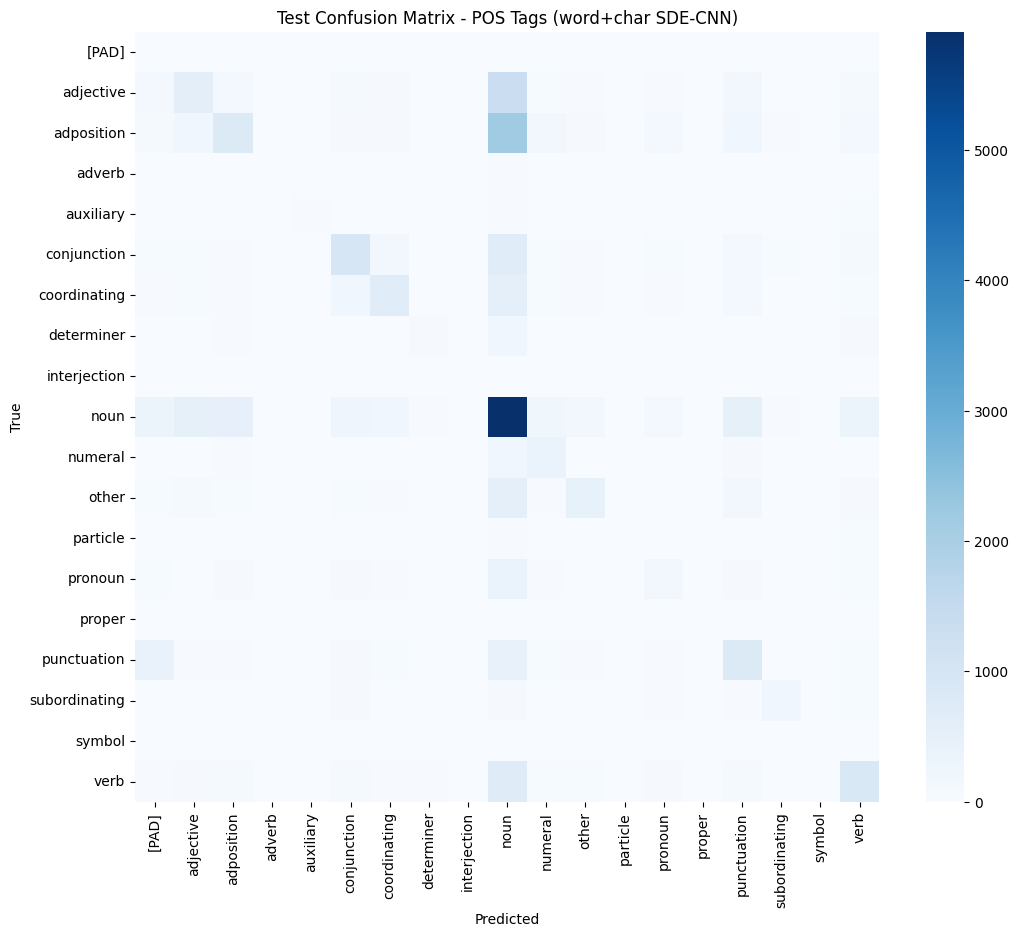

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

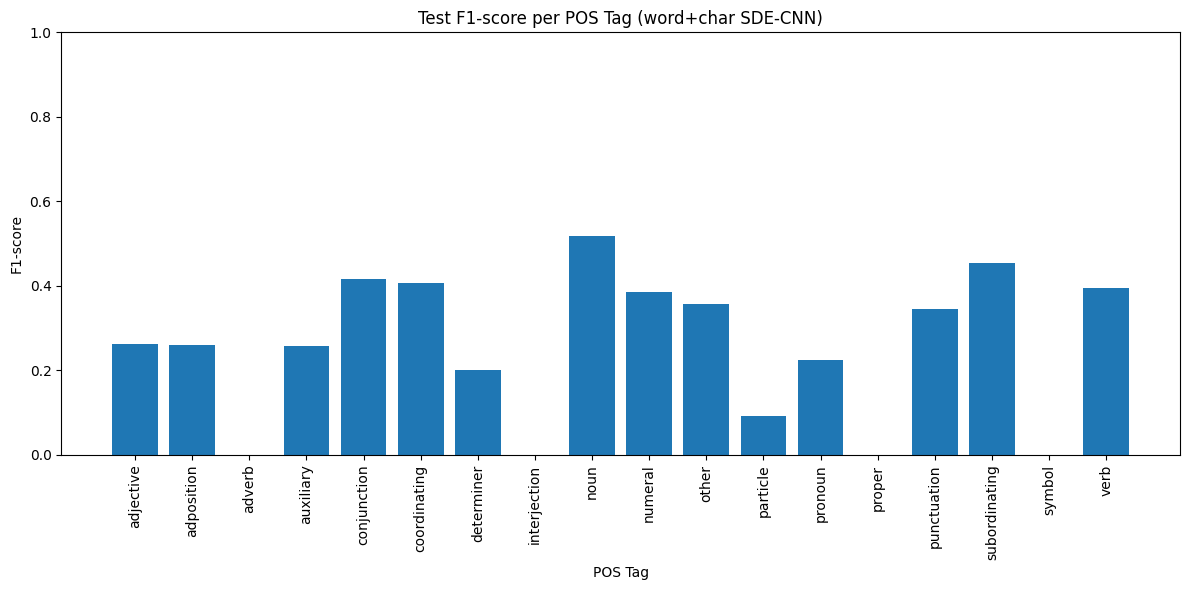

Test Sequence-level accuracy: 0.024771838331160364


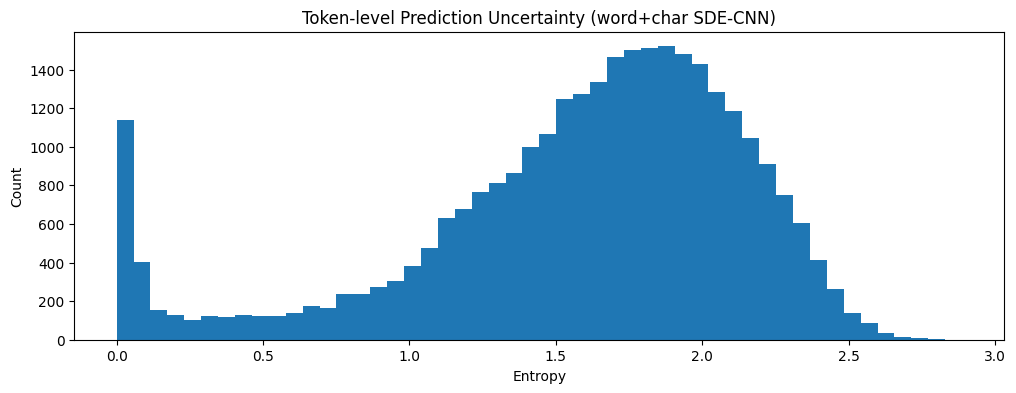

BLEU score (corpus-level): 33.62

Sample 1:
Words:  ['التربية', 'البدنية', 'إحداث', '4', 'لجان', 'وطنية', 'في', 'التكوين', 'والتوجيه', 'والتوجيه']
Gold tags:   ['noun', 'adjective', 'punctuation', 'noun', 'numeral', 'noun', 'adjective', 'adposition', 'noun', 'coordinating', 'conjunction', 'noun']
Predicted:   ['noun', 'noun', 'punctuation', 'adjective', 'punctuation', 'noun', 'noun', 'adjective', 'noun', 'noun', 'noun']
----------------------------------------

Sample 2:
Words:  ['و', 'طالب', 'ماهر', 'ب', 'انسحاب', 'القوات', 'الأمريكية', 'و', 'البريطانية', 'من', 'العراق', 'فى', 'أقرب', 'وقت', 'ممكن', 'ل', 'تمكين', 'الشعب', 'العراقى', 'من', 'ان', 'يقرر', 'مستقبل', 'ه', 'ب', 'نفس', 'ه', 'و', 'على', 'أرض', 'ه', 'الموحدة']
Gold tags:   ['coordinating', 'conjunction', 'verb', 'other', 'adposition', 'noun', 'noun', 'adjective', 'coordinating', 'conjunction', 'adjective', 'adposition', 'noun', 'adposition', 'adjective', 'noun', 'adjective', 'adposition', 'noun', 'noun', 'adjective', 'adpositi

In [7]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import pickle
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, Dense, Dropout, TimeDistributed,
    GlobalMaxPooling1D, Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from tensorflow.keras.optimizers import Adam

# ========= USER CONFIG ========= #
data_size   = None
max_epochs  = 40
batch_size  = 32
random_state = 42

excel_path = "/kaggle/input/fulltag/padt_pos_4cols_fulltags.xlsx"
pkl_path   = "/kaggle/working/preprocessed_pos_data_padt_word_char_sde.pkl"

MAX_LEN        = 100   # max words per sentence
MAX_WORD_LEN   = 15    # max chars per word
WORD_EMB_DIM   = 128
CHAR_EMB_DIM   = 50
SDE_FILTERS    = 128
SDE_KERNEL     = 7
SDE_LAYERS     = 2
# =============================== #

# ========== DATA PREPROCESS (CACHED) ========== #
if os.path.exists(pkl_path):
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    X_words = data["X_words"]
    X_chars = data["X_chars"]
    y = data["y"]
    sentences = data["sentences"]
    tag_tokenizer = data["tag_tokenizer"]
    word_tokenizer = data["word_tokenizer"]
    char_tokenizer = data["char_tokenizer"]
    print("Loaded preprocessed WORD+CHAR data from pickle.")
else:
    df = pd.read_excel(excel_path)

    sent_cols = ["train_sentence", "dev_sentence", "test_sentence"]
    pos_cols  = ["train_pos_seq",  "dev_pos_seq",  "test_pos_seq"]

    all_sentences, all_tags_seq = [], []
    for s_col, p_col in zip(sent_cols, pos_cols):
        s = df[s_col].fillna("").astype(str).values
        p = df[p_col].fillna("").astype(str).values
        for sent, tags in zip(s, p):
            if sent.strip() == "" or tags.strip() == "":
                continue
            all_sentences.append(sent)
            all_tags_seq.append(tags)

    sentences = np.array(all_sentences)
    tags_seq  = np.array(all_tags_seq)

    if data_size is not None and data_size <= len(sentences):
        sentences = sentences[:data_size]
        tags_seq  = tags_seq[:data_size]

    print("Total sentences:", len(sentences))

    # ---------- 1) WORD tokenizer (for sequence of words) ----------
    word_tokenizer = Tokenizer(char_level=False, oov_token="[OOV]")
    word_tokenizer.fit_on_texts(sentences)
    word_seqs = word_tokenizer.texts_to_sequences(sentences)
    X_words = pad_sequences(word_seqs, maxlen=MAX_LEN, padding="post", truncating="post")

    # ---------- 2) CHAR tokenizer (for characters of each word) ----------
    # نبني قائمة كل الكلمات من الكوربوس لبناء قاموس الأحرف
    all_words_for_chars = []
    for sent in sentences:
        all_words_for_chars.extend(sent.split())

    char_tokenizer = Tokenizer(char_level=True, oov_token="[OOV_CH]")
    char_tokenizer.fit_on_texts(all_words_for_chars)

    # الآن نُحوّل كل جملة إلى مصفوفة (max_len, max_word_len) من أحرف
    def sentence_to_char_ids(sent):
        words = sent.split()
        # نقطع/نحشو عدد الكلمات إلى MAX_LEN
        words = words[:MAX_LEN] + [""] * max(0, MAX_LEN - len(words))
        # لكل كلمة: نأخذ تسلسل أحرف ونحشوه إلى MAX_WORD_LEN
        char_ids = []
        for w in words:
            chars = list(w)
            ch_seq = char_tokenizer.texts_to_sequences(["".join(chars)])[0]
            ch_seq = ch_seq[:MAX_WORD_LEN]
            ch_seq = ch_seq + [0] * max(0, MAX_WORD_LEN - len(ch_seq))
            char_ids.append(ch_seq)
        return np.array(char_ids, dtype="int32")  # (max_len, max_word_len)

    X_chars = np.stack([sentence_to_char_ids(s) for s in sentences])  # (N, max_len, max_word_len)

    # ---------- 3) Tag tokenizer ----------
    tag_tokenizer = Tokenizer()
    tag_tokenizer.fit_on_texts(tags_seq)
    y_seqs = tag_tokenizer.texts_to_sequences(tags_seq)
    y = pad_sequences(y_seqs, maxlen=MAX_LEN, padding="post", truncating="post")

    with open(pkl_path, "wb") as f:
        pickle.dump({
            "X_words": X_words,
            "X_chars": X_chars,
            "y": y,
            "sentences": sentences,
            "tag_tokenizer": tag_tokenizer,
            "word_tokenizer": word_tokenizer,
            "char_tokenizer": char_tokenizer
        }, f)
    print("Saved preprocessed WORD+CHAR data to pickle.")

# ====== SHAPES ====== #
vocab_size_words = len(word_tokenizer.word_index) + 1
vocab_size_chars = len(char_tokenizer.word_index) + 1
tag_count        = len(tag_tokenizer.word_index) + 1
max_len          = X_words.shape[1]
max_word_len     = X_chars.shape[2]

print("vocab_size_words:", vocab_size_words)
print("vocab_size_chars:", vocab_size_chars)
print("tag_count       :", tag_count)
print("max_len(words)  :", max_len)
print("max_word_len    :", max_word_len)

# ====== SPLIT ====== #
Xw_trainval, Xw_test, Xc_trainval, Xc_test, y_trainval, y_test = train_test_split(
    X_words, X_chars, y, test_size=0.1, random_state=random_state
)
Xw_train, Xw_val, Xc_train, Xc_val, y_train, y_val = train_test_split(
    Xw_trainval, Xc_trainval, y_trainval, test_size=0.1111, random_state=random_state
)
print("Train words:", Xw_train.shape, "chars:", Xc_train.shape, "y:", y_train.shape)
print("Val   words:", Xw_val.shape, "chars:", Xc_val.shape, "y:", y_val.shape)
print("Test  words:", Xw_test.shape, "chars:", Xc_test.shape, "y:", y_test.shape)

# ====== SDE-CNN BLOCK ====== #
class DeepCNNSDEPoss(tf.keras.layers.Layer):
    def __init__(self, filters=SDE_FILTERS, kernel_size=SDE_KERNEL, layers=SDE_LAYERS):
        super().__init__()
        self.cnns = [Conv1D(filters, kernel_size, padding='same', activation='relu') for _ in range(layers)]
        self.dropouts = [Dropout(0.25) for _ in range(layers)]
        self.drifts = [Dense(filters) for _ in range(layers)]
        self.diffusions = [Dense(filters) for _ in range(layers)]

    def call(self, inputs, training=None):
        x = inputs
        dt = 1.0
        for cnn, drift, diffu, drop in zip(self.cnns, self.drifts, self.diffusions, self.dropouts):
            x = drop(x, training=training)
            x = cnn(x)
            b = tf.shape(x)[0]
            t = tf.shape(x)[1]
            c = tf.shape(x)[2]
            noise = tf.random.normal((b, t, c), mean=0., stddev=1.)
            x = x + drift(x) * dt + diffu(x) * noise * tf.sqrt(dt)
        return x

# ====== MODEL: word+char embedding -> concat -> SDE-CNN -> TimeDistributed ====== #
# مدخل الكلمات
word_inputs = Input(shape=(max_len,), name="word_input")
word_emb = Embedding(vocab_size_words, WORD_EMB_DIM, mask_zero=True, name="word_embedding")(word_inputs)

# مدخل الأحرف: (batch, max_len, max_word_len)
char_inputs = Input(shape=(max_len, max_word_len), name="char_input")
# نُطبّق Embedding + CNN على كل كلمة (على محور الأحرف) باستخدام TimeDistributed
char_emb_layer = Embedding(vocab_size_chars, CHAR_EMB_DIM, mask_zero=True, name="char_embedding")
char_emb = TimeDistributed(char_emb_layer, name="td_char_emb")(char_inputs)  # (B, T, W, C)

# CNN على الأحرف داخل كل كلمة -> vector
char_cnn = TimeDistributed(
    Conv1D(filters=50, kernel_size=3, padding="same", activation="relu"),
    name="td_char_cnn"
)(char_emb)
char_pool = TimeDistributed(
    GlobalMaxPooling1D(),
    name="td_char_pool"
)(char_cnn)  # (B, T, 50) تمثيل حرفي لكل كلمة

# دمج word embedding + char embedding
merged = Concatenate(axis=-1, name="word_char_concat")([word_emb, char_pool])  # (B, T, WORD_EMB_DIM+50)

# SDE-CNN على التسلسل
sde_out = DeepCNNSDEPoss()(merged)  # (B, T, filters)

# تنبؤ وسم لكل كلمة
logits = TimeDistributed(Dense(tag_count, activation="softmax"), name="tag_output")(sde_out)

model = Model(inputs=[word_inputs, char_inputs], outputs=logits)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

# ====== TRAIN ====== #
y_train_targets = np.expand_dims(y_train, -1)
y_val_targets   = np.expand_dims(y_val, -1)

early = EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
checkpoint = ModelCheckpoint("/kaggle/working/best_word_char_sde_pos.keras",
                             monitor="val_loss", save_best_only=True)

history = model.fit(
    [Xw_train, Xc_train], y_train_targets,
    batch_size=batch_size,
    epochs=max_epochs,
    validation_data=([Xw_val, Xc_val], y_val_targets),
    callbacks=[early, checkpoint]
)

# ====== EVALUATION ====== #
y_probs = model.predict([Xw_test, Xc_test])
y_pred = np.argmax(y_probs, axis=-1)
y_true = y_test

y_true = np.squeeze(y_true)
y_pred = np.squeeze(y_pred)

mask = (y_true != 0)
y_true_flat = y_true[mask]
y_pred_flat = y_pred[mask]

idx2tag = {v: k for k, v in tag_tokenizer.word_index.items()}
idx2tag[0] = '[PAD]'
y_true_tags = [idx2tag[idx] for idx in y_true_flat]
y_pred_tags = [idx2tag[idx] for idx in y_pred_flat]

print("\nTest Classification Report:")
with open("/kaggle/working/test_classification_report_word_char_sde.txt", "w", encoding="utf-8") as f:
    f.write(classification_report(y_true_tags, y_pred_tags))
print(classification_report(y_true_tags, y_pred_tags))

labels = np.unique(y_true_tags + y_pred_tags)
cm = confusion_matrix(y_true_tags, y_pred_tags, labels=labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix - POS Tags (word+char SDE-CNN)")
plt.savefig("/kaggle/working/Test_Confusion_Matrix_word_char_SDE.png")
plt.show()

report = classification_report(y_true_tags, y_pred_tags, output_dict=True)
f1s = [report[tag]["f1-score"] for tag in labels if tag != "[PAD]"]
plt.figure(figsize=(12, 6))
plt.bar(labels[1:], f1s)
plt.title("Test F1-score per POS Tag (word+char SDE-CNN)")
plt.xlabel("POS Tag")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("/kaggle/working/Test_F1-score_word_char_SDE.png")
plt.show()

sequence_correct = (y_true == y_pred).all(axis=1)
print("Test Sequence-level accuracy:", sequence_correct.mean())

def compute_entropy(prob_vec):
    prob_vec = np.clip(prob_vec, 1e-12, 1 - 1e-12)
    return -np.sum(prob_vec * np.log(prob_vec), axis=-1)

entropies = compute_entropy(y_probs)
plt.figure(figsize=(12, 4))
plt.hist(entropies[mask], bins=50)
plt.title("Token-level Prediction Uncertainty (word+char SDE-CNN)")
plt.xlabel("Entropy")
plt.ylabel("Count")
plt.savefig("/kaggle/working/Test_Token-level_Prediction_Uncertainty_word_char_SDE.png")
plt.show()

# --- BLEU Evaluation ---
bleu_hyps, bleu_refs = [], []
for i in range(y_true.shape[0]):
    ref_seq = [idx2tag[tag] for tag in y_true[i] if tag != 0]
    hyp_seq = [idx2tag[tag] for tag in y_pred[i] if tag != 0]
    if ref_seq and hyp_seq:
        bleu_refs.append([ref_seq])
        bleu_hyps.append(hyp_seq)
bleu = corpus_bleu(bleu_refs, bleu_hyps, smoothing_function=SmoothingFunction().method4)
print(f"BLEU score (corpus-level): {bleu*100:.2f}")

# --- Sample Print ---
n_samples = 5
idx2word = {v: k for k, v in word_tokenizer.word_index.items()}
idx2word[0] = "[PAD]"

for i in range(n_samples):
    idx = np.random.randint(len(Xw_test))
    words = [idx2word[w] for w in Xw_test[idx] if w != 0]
    true_seq = [idx2tag[tag] for tag in y_true[idx] if tag != 0]
    pred_seq = [idx2tag[tag] for tag in y_pred[idx] if tag != 0]
    print(f"\nSample {i+1}:")
    print("Words: ", words)
    print("Gold tags:  ", true_seq)
    print("Predicted:  ", pred_seq)
    print("-" * 40)


Loaded preprocessed WORD+CHAR data from pickle.
vocab_size_words: 24655
vocab_size_chars: 107
tag_count       : 19
max_len(words)  : 100
max_word_len    : 15
Train words: (6130, 100) chars: (6130, 100, 15) y: (6130, 100)
Val   words: (767, 100) chars: (767, 100, 15) y: (767, 100)
Test  words: (767, 100) chars: (767, 100, 15) y: (767, 100)


Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ char_input          │ (None, 100, 15)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_emb         │ (None, 100, 15,   │      5,350 │ char_input[0][0]  │
│ (TimeDistributed)   │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_input          │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_cnn         │ (None, 100, 15,   │      7,550 │ td_char_emb[0][0] │
│ (TimeDistributed)   │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 100, 128)  │  3,155,840 │ word_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_pool        │ (None, 100, 50)   │          0 │ td_char_cnn[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_char_concat    │ (None, 100, 178)  │          0 │ word_embedding[0… │
│ (Concatenate)       │                   │            │ td_char_pool[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 100, 256)  │    314,368 │ word_char_concat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tag_output          │ (None, 100, 19)   │      4,883 │ bilstm[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,487,991 (13.31 MB)

 Trainable params: 3,487,991 (13.31 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 67s 126ms/step - accuracy: 0.6839 - loss: 1.0941 - val_accuracy: 0.7524 - val_loss: 0.7361
Epoch 2/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 15s 77ms/step - accuracy: 0.7523 - loss: 0.7285 - val_accuracy: 0.7904 - val_loss: 0.5947
Epoch 3/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 15s 77ms/step - accuracy: 0.7954 - loss: 0.5859 - val_accuracy: 0.8225 - val_loss: 0.5072
Epoch 4/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 15s 76ms/step - accuracy: 0.8332 - loss: 0.4763 - val_accuracy: 0.8456 - val_loss: 0.4447
Epoch 5/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 15s 76ms/step - accuracy: 0.8619 - loss: 0.3969 - val_accuracy: 0.8603 - val_loss: 0.4003
Epoch 6/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 15s 77ms/step - accuracy: 0.8881 - loss: 0.3290 - val_accuracy: 0.8687 - val_loss: 0.3811
Epoch 7/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 15s 77ms/step - accuracy: 0.9085 - loss: 0.2693 - val_accuracy: 0.8733 - val_loss: 0.3718
Epoch 8/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 15s 77ms/step - accuracy: 0.9166 - loss: 0.2456 -

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

               precision    recall  f1-score   support

        [PAD]       0.00      0.00      0.00         0
    adjective       0.68      0.60      0.64      2823
   adposition       0.69      0.68      0.69      4218
       adverb       0.90      0.19      0.32        99
    auxiliary       0.67      0.42      0.52       204
  conjunction       0.69      0.71      0.70      2427
 coordinating       0.67      0.67      0.67      1873
   determiner       0.67      0.41      0.51       545
 interjection       0.00      0.00      0.00         1
         noun       0.69      0.79      0.74      9315
      numeral       0.69      0.58      0.63       807
        other       0.63      0.47      0.54      1666
     particle       0.61      0.33      0.43       216
      pronoun       0.64      0.55      0.59      1043
       proper       0.50      0.03      0.06        29
  punctuation       0.71      0.79      0.74      2057
subordinating       0.77      0.69      0.73       557
       sy

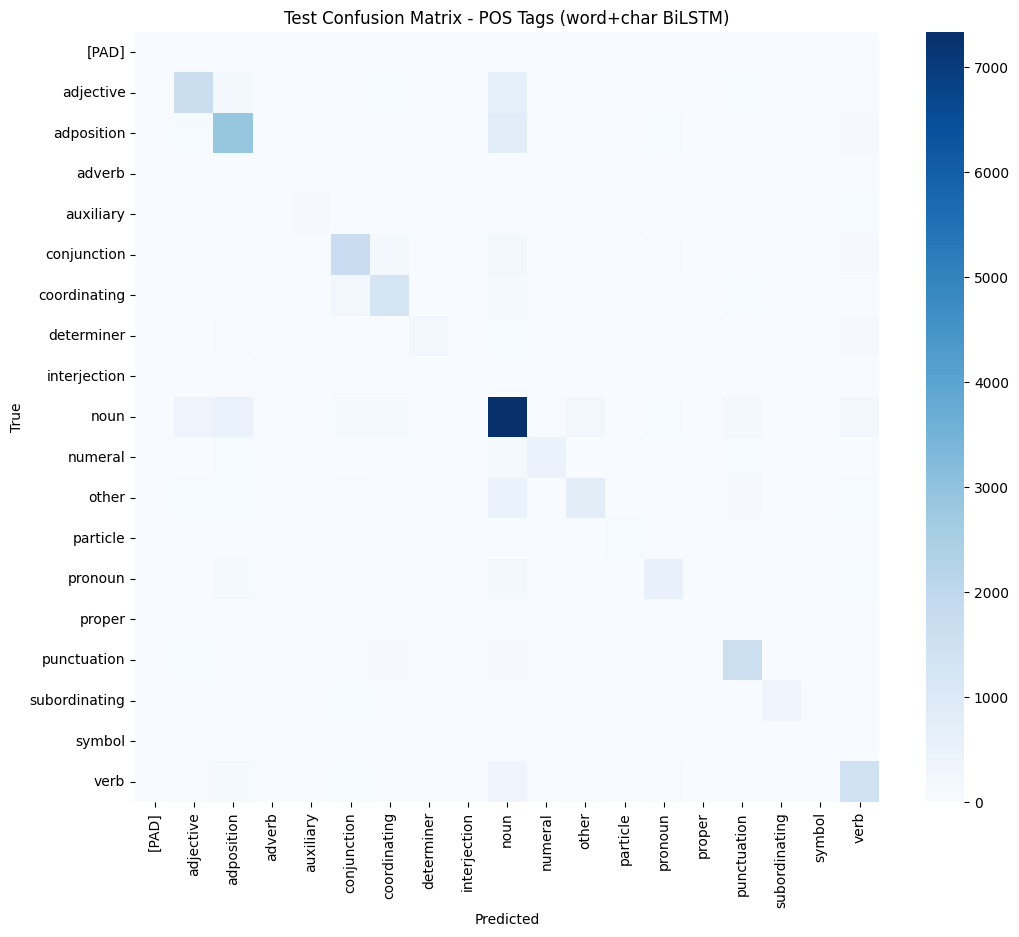

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

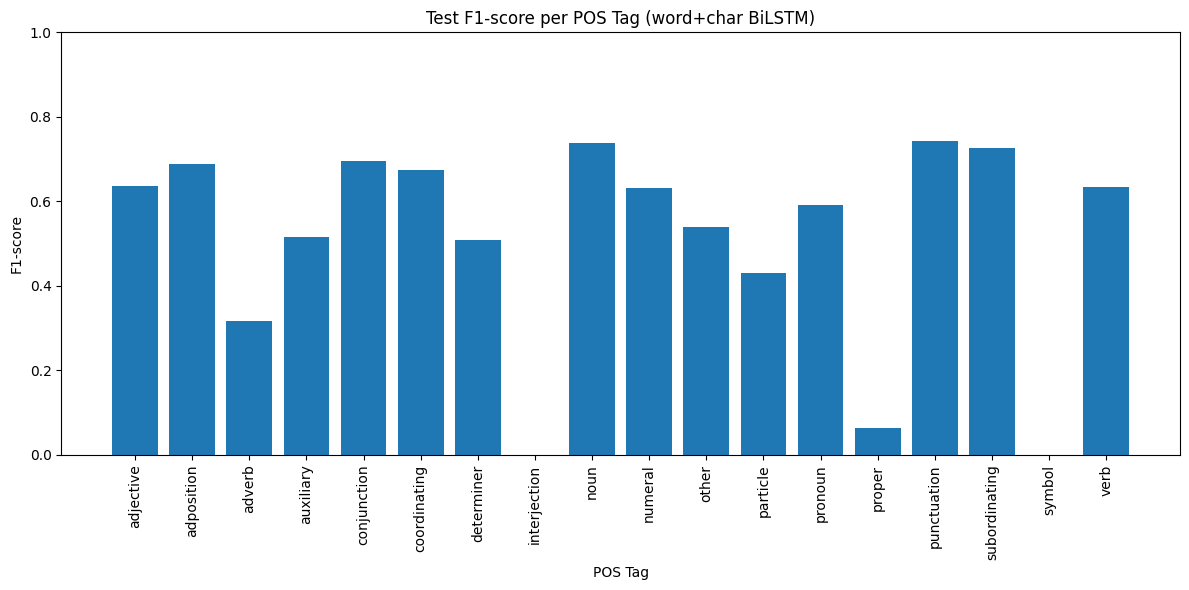

Test Sequence-level accuracy: 0.11603650586701435


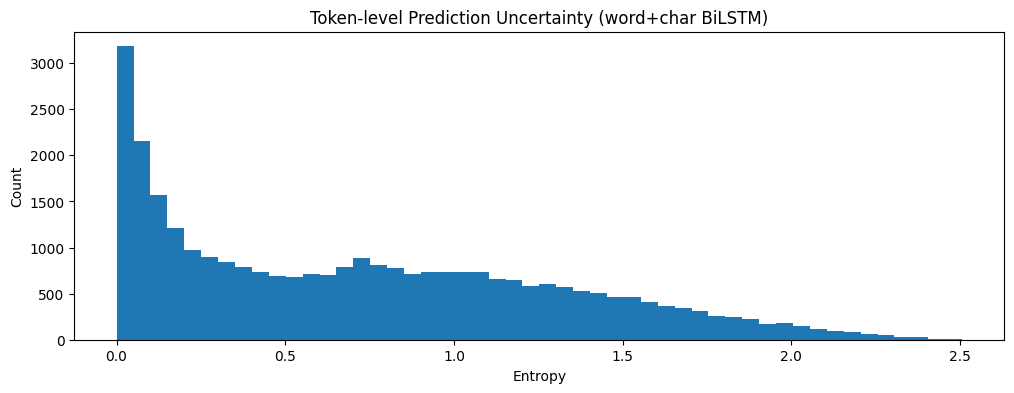

BLEU score (corpus-level): 60.45

Sample 1:
Words:  ['و', 'حسب', 'المعلومات', 'المتوفرة', 'لدي', 'نا', 'من', 'مصادر', 'علمية', 'ف', 'إن', 'عملية', 'الاقتران', 'بين', 'الشمس', 'و', 'القمر', 'و', 'الأرض', 'تتم', 'غدا', 'الخميس', 'على', 'الساعة', 'الثانية', 'صباحا', 'و', '24', 'دقيقة', 'ب', 'توقيت', 'غرينيتش', 'الثالثة', 'صباحا', 'و', '47', 'دقيقة', 'ب', 'توقيت', 'تونس', 'و', 'س', 'تكون', 'مدة', 'مكوث', 'القمر', 'بعد', 'غروب', 'الشمس', 'على', 'المدن', 'التونسية', 'في', 'حدود', '17', 'دقيقة', 'تكون', 'خلال', 'ها', 'الفترة', 'الفاصلة', 'بين', 'الاقتران', 'و', 'غروب', 'الشمس', 'ب', 'ذات', 'المدن', 'ما', 'بين', '13', 'ساعة', 'و', '55', 'دقيقة', 'و', '14', 'ساعة', 'و', 'بضع', 'دقائق', 'على', 'اختلاف', 'المدن']
Gold tags:   ['coordinating', 'conjunction', 'adposition', 'noun', 'adjective', 'adposition', 'pronoun', 'adposition', 'noun', 'adjective', 'coordinating', 'conjunction', 'particle', 'noun', 'noun', 'adposition', 'noun', 'coordinating', 'conjunction', 'noun', 'coordinating', 'conjunction

In [10]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import pickle
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, Dense, Dropout, TimeDistributed,
    GlobalMaxPooling1D, Concatenate, Bidirectional, LSTM
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from tensorflow.keras.optimizers import Adam

# ========= USER CONFIG ========= #
data_size   = None
max_epochs  = 40
batch_size  = 32
random_state = 42

excel_path = "/kaggle/input/fulltag/padt_pos_4cols_fulltags.xlsx"
pkl_path   = "/kaggle/working/preprocessed_pos_data_padt_word_char_bilstm.pkl"

MAX_LEN        = 100   # max words per sentence
MAX_WORD_LEN   = 15    # max chars per word
WORD_EMB_DIM   = 128
CHAR_EMB_DIM   = 50
LSTM_UNITS     = 128
# =============================== #

# ========== DATA PREPROCESS (CACHED) ========== #
if os.path.exists(pkl_path):
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    X_words = data["X_words"]
    X_chars = data["X_chars"]
    y = data["y"]
    sentences = data["sentences"]
    tag_tokenizer = data["tag_tokenizer"]
    word_tokenizer = data["word_tokenizer"]
    char_tokenizer = data["char_tokenizer"]
    print("Loaded preprocessed WORD+CHAR data from pickle.")
else:
    df = pd.read_excel(excel_path)

    sent_cols = ["train_sentence", "dev_sentence", "test_sentence"]
    pos_cols  = ["train_pos_seq",  "dev_pos_seq",  "test_pos_seq"]

    all_sentences, all_tags_seq = [], []
    for s_col, p_col in zip(sent_cols, pos_cols):
        s = df[s_col].fillna("").astype(str).values
        p = df[p_col].fillna("").astype(str).values
        for sent, tags in zip(s, p):
            if sent.strip() == "" or tags.strip() == "":
                continue
            all_sentences.append(sent)
            all_tags_seq.append(tags)

    sentences = np.array(all_sentences)
    tags_seq  = np.array(all_tags_seq)

    if data_size is not None and data_size <= len(sentences):
        sentences = sentences[:data_size]
        tags_seq  = tags_seq[:data_size]

    print("Total sentences:", len(sentences))

    # ---------- 1) WORD tokenizer ----------
    word_tokenizer = Tokenizer(char_level=False, oov_token="[OOV]")
    word_tokenizer.fit_on_texts(sentences)
    word_seqs = word_tokenizer.texts_to_sequences(sentences)
    X_words = pad_sequences(word_seqs, maxlen=MAX_LEN, padding="post", truncating="post")

    # ---------- 2) CHAR tokenizer ----------
    all_words_for_chars = []
    for sent in sentences:
        all_words_for_chars.extend(sent.split())

    char_tokenizer = Tokenizer(char_level=True, oov_token="[OOV_CH]")
    char_tokenizer.fit_on_texts(all_words_for_chars)

    def sentence_to_char_ids(sent):
        words = sent.split()
        words = words[:MAX_LEN] + [""] * max(0, MAX_LEN - len(words))
        char_ids = []
        for w in words:
            chars = list(w)
            ch_seq = char_tokenizer.texts_to_sequences(["".join(chars)])[0]
            ch_seq = ch_seq[:MAX_WORD_LEN]
            ch_seq = ch_seq + [0] * max(0, MAX_WORD_LEN - len(ch_seq))
            char_ids.append(ch_seq)
        return np.array(char_ids, dtype="int32")

    X_chars = np.stack([sentence_to_char_ids(s) for s in sentences])  # (N, max_len, max_word_len)

    # ---------- 3) Tag tokenizer ----------
    tag_tokenizer = Tokenizer()
    tag_tokenizer.fit_on_texts(tags_seq)
    y_seqs = tag_tokenizer.texts_to_sequences(tags_seq)
    y = pad_sequences(y_seqs, maxlen=MAX_LEN, padding="post", truncating="post")

    with open(pkl_path, "wb") as f:
        pickle.dump({
            "X_words": X_words,
            "X_chars": X_chars,
            "y": y,
            "sentences": sentences,
            "tag_tokenizer": tag_tokenizer,
            "word_tokenizer": word_tokenizer,
            "char_tokenizer": char_tokenizer
        }, f)
    print("Saved preprocessed WORD+CHAR data to pickle.")

# ====== SHAPES ====== #
vocab_size_words = len(word_tokenizer.word_index) + 1
vocab_size_chars = len(char_tokenizer.word_index) + 1
tag_count        = len(tag_tokenizer.word_index) + 1
max_len          = X_words.shape[1]
max_word_len     = X_chars.shape[2]

print("vocab_size_words:", vocab_size_words)
print("vocab_size_chars:", vocab_size_chars)
print("tag_count       :", tag_count)
print("max_len(words)  :", max_len)
print("max_word_len    :", max_word_len)

# ====== SPLIT ====== #
Xw_trainval, Xw_test, Xc_trainval, Xc_test, y_trainval, y_test = train_test_split(
    X_words, X_chars, y, test_size=0.1, random_state=random_state
)
Xw_train, Xw_val, Xc_train, Xc_val, y_train, y_val = train_test_split(
    Xw_trainval, Xc_trainval, y_trainval, test_size=0.1111, random_state=random_state
)
print("Train words:", Xw_train.shape, "chars:", Xc_train.shape, "y:", y_train.shape)
print("Val   words:", Xw_val.shape, "chars:", Xc_val.shape, "y:", y_val.shape)
print("Test  words:", Xw_test.shape, "chars:", Xc_test.shape, "y:", y_test.shape)

# ====== MODEL: word+char embedding -> concat -> BiLSTM -> TimeDistributed ====== #
word_inputs = Input(shape=(max_len,), name="word_input")
# نلغي mask_zero لتفادي مشاكل BroadcastTo مع مدخلين
word_emb = Embedding(vocab_size_words, WORD_EMB_DIM,
                     mask_zero=False, name="word_embedding")(word_inputs)

char_inputs = Input(shape=(max_len, max_word_len), name="char_input")
char_emb_layer = Embedding(vocab_size_chars, CHAR_EMB_DIM,
                           mask_zero=False, name="char_embedding")
char_emb = TimeDistributed(char_emb_layer, name="td_char_emb")(char_inputs)  # (B, T, W, C)

char_cnn = TimeDistributed(
    Conv1D(filters=50, kernel_size=3, padding="same", activation="relu"),
    name="td_char_cnn"
)(char_emb)
char_pool = TimeDistributed(GlobalMaxPooling1D(), name="td_char_pool")(char_cnn)  # (B, T, 50)

merged = Concatenate(axis=-1, name="word_char_concat")([word_emb, char_pool])  # (B, T, WORD_EMB_DIM+50)

bilstm = Bidirectional(
    LSTM(LSTM_UNITS, return_sequences=True),
    name="bilstm"
)(merged)

logits = TimeDistributed(Dense(tag_count, activation="softmax"), name="tag_output")(bilstm)

model = Model(inputs=[word_inputs, char_inputs], outputs=logits)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

# ====== TRAIN ====== #
y_train_targets = np.expand_dims(y_train, -1)
y_val_targets   = np.expand_dims(y_val, -1)

early = EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
checkpoint = ModelCheckpoint("/kaggle/working/best_word_char_bilstm_pos.keras",
                             monitor="val_loss", save_best_only=True)

history = model.fit(
    [Xw_train, Xc_train], y_train_targets,
    batch_size=batch_size,
    epochs=max_epochs,
    validation_data=([Xw_val, Xc_val], y_val_targets),
    callbacks=[early, checkpoint]
)

# ====== EVALUATION ====== #
y_probs = model.predict([Xw_test, Xc_test])
y_pred = np.argmax(y_probs, axis=-1)
y_true = y_test

y_true = np.squeeze(y_true)
y_pred = np.squeeze(y_pred)

mask = (y_true != 0)
y_true_flat = y_true[mask]
y_pred_flat = y_pred[mask]

idx2tag = {v: k for k, v in tag_tokenizer.word_index.items()}
idx2tag[0] = '[PAD]'
y_true_tags = [idx2tag[idx] for idx in y_true_flat]
y_pred_tags = [idx2tag[idx] for idx in y_pred_flat]

print("\nTest Classification Report:")
with open("/kaggle/working/test_classification_report_word_char_bilstm.txt", "w", encoding="utf-8") as f:
    f.write(classification_report(y_true_tags, y_pred_tags))
print(classification_report(y_true_tags, y_pred_tags))

labels = np.unique(y_true_tags + y_pred_tags)
cm = confusion_matrix(y_true_tags, y_pred_tags, labels=labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix - POS Tags (word+char BiLSTM)")
plt.savefig("/kaggle/working/Test_Confusion_Matrix_word_char_BiLSTM.png")
plt.show()

report = classification_report(y_true_tags, y_pred_tags, output_dict=True)
f1s = [report[tag]["f1-score"] for tag in labels if tag != "[PAD]"]
plt.figure(figsize=(12, 6))
plt.bar(labels[1:], f1s)
plt.title("Test F1-score per POS Tag (word+char BiLSTM)")
plt.xlabel("POS Tag")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("/kaggle/working/Test_F1-score_word_char_BiLSTM.png")
plt.show()

sequence_correct = (y_true == y_pred).all(axis=1)
print("Test Sequence-level accuracy:", sequence_correct.mean())

def compute_entropy(prob_vec):
    prob_vec = np.clip(prob_vec, 1e-12, 1 - 1e-12)
    return -np.sum(prob_vec * np.log(prob_vec), axis=-1)

entropies = compute_entropy(y_probs)
plt.figure(figsize=(12, 4))
plt.hist(entropies[mask], bins=50)
plt.title("Token-level Prediction Uncertainty (word+char BiLSTM)")
plt.xlabel("Entropy")
plt.ylabel("Count")
plt.savefig("/kaggle/working/Test_Token-level_Prediction_Uncertainty_word_char_BiLSTM.png")
plt.show()

# --- BLEU Evaluation ---
bleu_hyps, bleu_refs = [], []
for i in range(y_true.shape[0]):
    ref_seq = [idx2tag[tag] for tag in y_true[i] if tag != 0]
    hyp_seq = [idx2tag[tag] for tag in y_pred[i] if tag != 0]
    if ref_seq and hyp_seq:
        bleu_refs.append([ref_seq])
        bleu_hyps.append(hyp_seq)
bleu = corpus_bleu(bleu_refs, bleu_hyps, smoothing_function=SmoothingFunction().method4)
print(f"BLEU score (corpus-level): {bleu*100:.2f}")

# --- Sample Print ---
n_samples = 5
idx2word = {v: k for k, v in word_tokenizer.word_index.items()}
idx2word[0] = "[PAD]"

for i in range(n_samples):
    idx = np.random.randint(len(Xw_test))
    words = [idx2word[w] for w in Xw_test[idx] if w != 0]
    true_seq = [idx2tag[tag] for tag in y_true[idx] if tag != 0]
    pred_seq = [idx2tag[tag] for tag in y_pred[idx] if tag != 0]
    print(f"\nSample {i+1}:")
    print("Words: ", words)
    print("Gold tags:  ", true_seq)
    print("Predicted:  ", pred_seq)
    print("-" * 40)


Loaded preprocessed WORD+CHAR data from pickle.
vocab_size_words: 24655
vocab_size_chars: 107
tag_count       : 19
max_len(words)  : 100
max_word_len    : 15
Train words: (6130, 100) chars: (6130, 100, 15) y: (6130, 100)
Val   words: (767, 100) chars: (767, 100, 15) y: (767, 100)
Test  words: (767, 100) chars: (767, 100, 15) y: (767, 100)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'deep_cnnsde_poss_7' (of type DeepCNNSDEPoss) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ char_input          │ (None, 100, 15)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_emb         │ (None, 100, 15,   │      5,350 │ char_input[0][0]  │
│ (TimeDistributed)   │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_input          │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_cnn         │ (None, 100, 15,   │      7,550 │ td_char_emb[0][0] │
│ (TimeDistributed)   │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 100, 128)  │  3,155,840 │ word_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_pool        │ (None, 100, 50)   │          0 │ td_char_cnn[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_char_concat    │ (None, 100, 178)  │          0 │ word_embedding[0… │
│ (Concatenate)       │                   │            │ td_char_pool[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ deep_cnnsde_poss_7  │ (None, 100, 128)  │    488,320 │ word_char_concat… │
│ (DeepCNNSDEPoss)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tag_output          │ (None, 100, 19)   │      2,451 │ deep_cnnsde_poss… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,659,511 (13.96 MB)

...

96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - accuracy: 0.6574 - loss: 1.2534

E0000 00:00:1764350573.491613     100 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764350573.730375     100 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


96/96 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.6579 - loss: 1.2509 - val_accuracy: 0.7402 - val_loss: 0.8233
Epoch 2/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.7372 - loss: 0.8281 - val_accuracy: 0.7526 - val_loss: 0.7424
Epoch 3/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.7449 - loss: 0.7531 - val_accuracy: 0.7602 - val_loss: 0.6984
Epoch 4/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.7577 - loss: 0.6924 - val_accuracy: 0.7662 - val_loss: 0.6807
Epoch 5/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.7738 - loss: 0.6384 - val_accuracy: 0.7700 - val_loss: 0.6786
Epoch 6/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.7969 - loss: 0.5694 - val_accuracy: 0.7705 - val_loss: 0.6929
Epoch 7/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.8164 - loss: 0.5149 - val_accuracy: 0.7694 - val_loss: 0.7149
Epoch 8/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.8296 - loss: 0.4762 - val_accuracy: 0.7707 - val_loss: 0.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

               precision    recall  f1-score   support

        [PAD]       0.00      0.00      0.00         0
    adjective       0.41      0.12      0.19      2823
   adposition       0.39      0.15      0.21      4218
       adverb       0.00      0.00      0.00        99
    auxiliary       0.38      0.17      0.24       204
  conjunction       0.40      0.42      0.41      2427
 coordinating       0.46      0.36      0.40      1873
   determiner       0.36      0.15      0.21       545
 interjection       0.00      0.00      0.00         1
         noun       0.41      0.73      0.52      9315
      numeral       0.38      0.29      0.33       807
        other       0.48      0.26      0.34      1666
     particle       0.42      0.02      0.04       216
      pronoun       0.26      0.13      0.17      1043
       proper       0.00      0.00      0.00        29
  punctuation       0.36      0.27      0.31      2057
subordinating       0.58      0.39      0.47       557
       sy

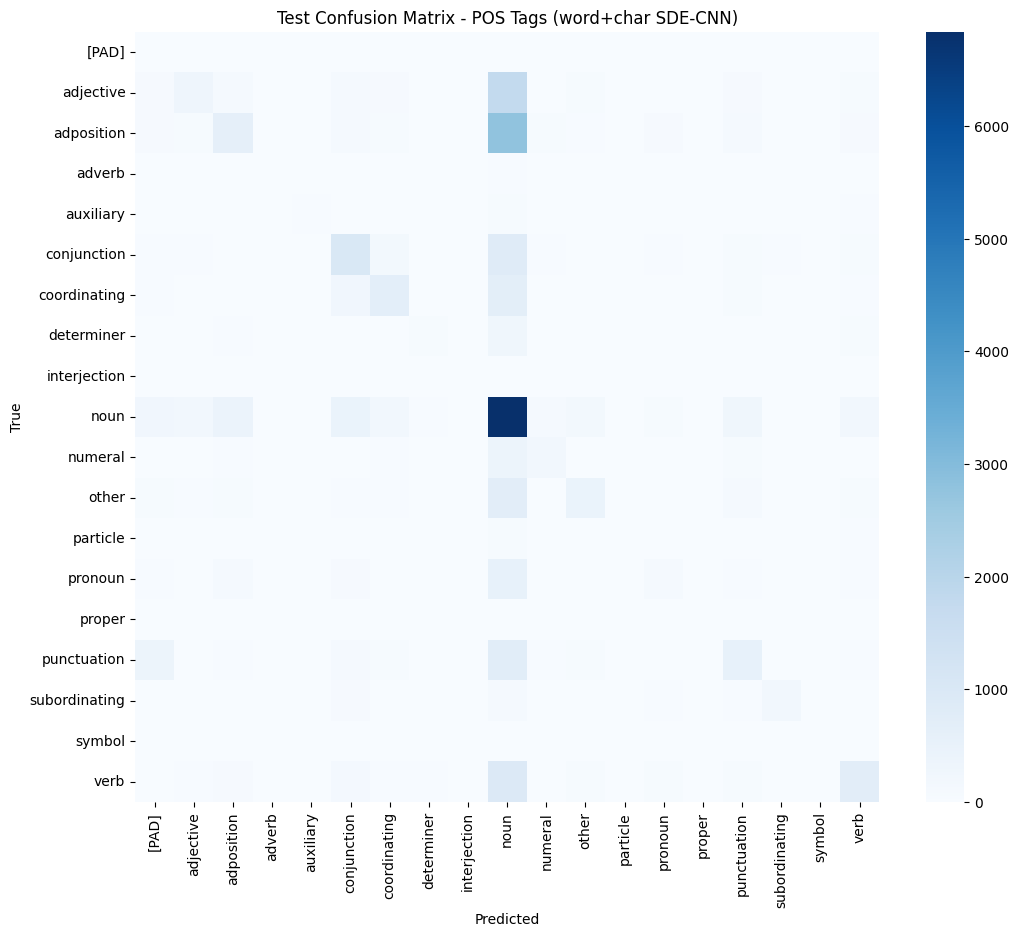

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

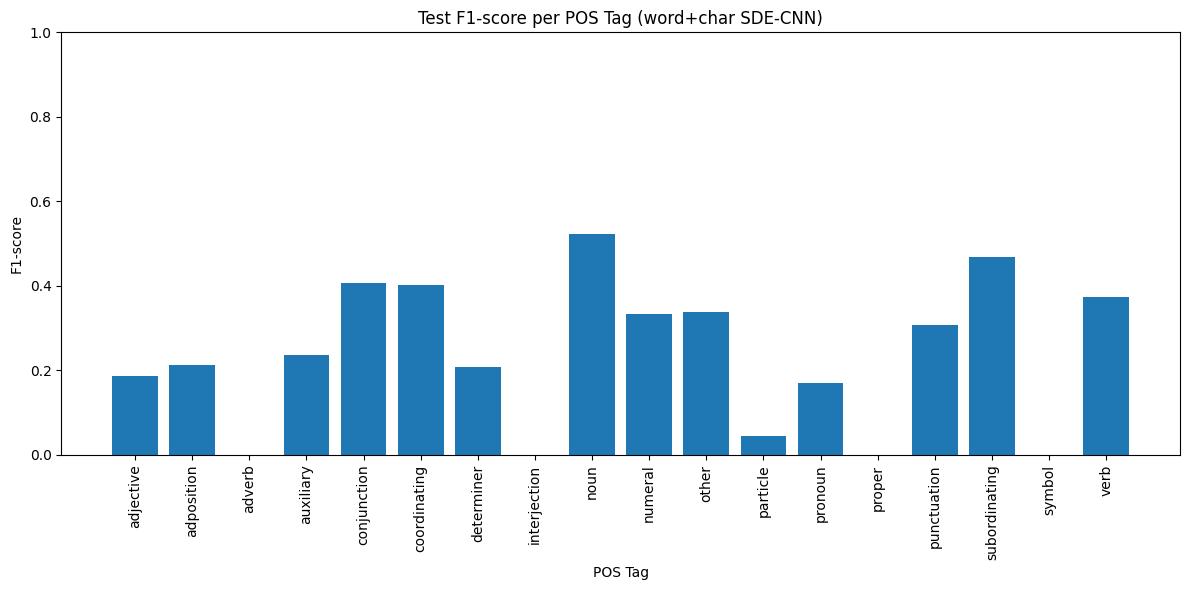

Test Sequence-level accuracy: 0.01694915254237288


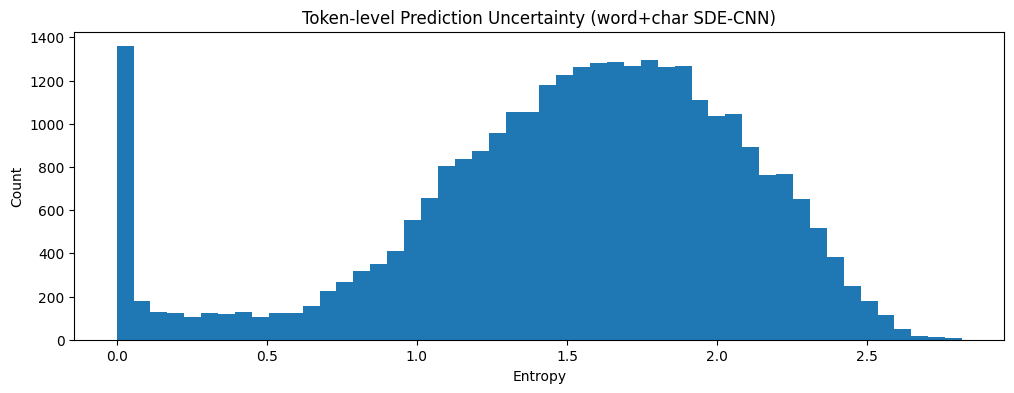

BLEU score (corpus-level): 30.36

Sample 1:
Words:  ['استمرار', 'ارتفاع', 'تجارة', 'مصر', 'والأردن', 'والأردن']
Gold tags:   ['noun', 'noun', 'noun', 'noun', 'coordinating', 'conjunction', 'noun']
Predicted:   ['noun', 'noun', 'noun', 'noun', 'adjective', 'adjective']
----------------------------------------

Sample 2:
Words:  ['خبراء', 'ليبيا', 'تدخر', 'أفضل', 'فرص', 'الاستثمار', 'في', 'قطاع', 'النفط', 'ل', 'الشركات', 'الأميركية']
Gold tags:   ['noun', 'punctuation', 'other', 'verb', 'adjective', 'noun', 'noun', 'adposition', 'noun', 'noun', 'adposition', 'noun', 'adjective']
Predicted:   ['punctuation', 'punctuation', 'other', 'other', 'noun', 'noun', 'noun', 'noun', 'noun', 'noun', 'noun', 'noun', 'noun']
----------------------------------------

Sample 3:
Words:  ['بكين', 'اول', 'مايو', '14', '23']
Gold tags:   ['other', 'adjective', 'noun', 'numeral', 'punctuation', 'numeral']
Predicted:   ['other', 'other', 'noun', 'numeral', 'punctuation', 'numeral']
----------------------------

In [12]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import pickle
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, Dense, Dropout, TimeDistributed,
    GlobalMaxPooling1D, Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from tensorflow.keras.optimizers import Adam

# ========= USER CONFIG ========= #
data_size   = None
max_epochs  = 40
batch_size  = 64
random_state = 42

excel_path = "/kaggle/input/fulltag/padt_pos_4cols_fulltags.xlsx"
pkl_path   = "/kaggle/working/preprocessed_pos_data_padt_word_char_sde.pkl"

MAX_LEN        = 100   # max words per sentence
MAX_WORD_LEN   = 15    # max chars per word
WORD_EMB_DIM   = 128
CHAR_EMB_DIM   = 50
SDE_FILTERS    = 128
SDE_KERNEL     = 7
SDE_LAYERS     = 3
# =============================== #

# ========== DATA PREPROCESS (CACHED) ========== #
if os.path.exists(pkl_path):
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    X_words = data["X_words"]
    X_chars = data["X_chars"]
    y = data["y"]
    sentences = data["sentences"]
    tag_tokenizer = data["tag_tokenizer"]
    word_tokenizer = data["word_tokenizer"]
    char_tokenizer = data["char_tokenizer"]
    print("Loaded preprocessed WORD+CHAR data from pickle.")
else:
    df = pd.read_excel(excel_path)

    sent_cols = ["train_sentence", "dev_sentence", "test_sentence"]
    pos_cols  = ["train_pos_seq",  "dev_pos_seq",  "test_pos_seq"]

    all_sentences, all_tags_seq = [], []
    for s_col, p_col in zip(sent_cols, pos_cols):
        s = df[s_col].fillna("").astype(str).values
        p = df[p_col].fillna("").astype(str).values
        for sent, tags in zip(s, p):
            if sent.strip() == "" or tags.strip() == "":
                continue
            all_sentences.append(sent)
            all_tags_seq.append(tags)

    sentences = np.array(all_sentences)
    tags_seq  = np.array(all_tags_seq)

    if data_size is not None and data_size <= len(sentences):
        sentences = sentences[:data_size]
        tags_seq  = tags_seq[:data_size]

    print("Total sentences:", len(sentences))

    # ---------- 1) WORD tokenizer (for sequence of words) ----------
    word_tokenizer = Tokenizer(char_level=False, oov_token="[OOV]")
    word_tokenizer.fit_on_texts(sentences)
    word_seqs = word_tokenizer.texts_to_sequences(sentences)
    X_words = pad_sequences(word_seqs, maxlen=MAX_LEN, padding="post", truncating="post")

    # ---------- 2) CHAR tokenizer (for characters of each word) ----------
    # نبني قائمة كل الكلمات من الكوربوس لبناء قاموس الأحرف
    all_words_for_chars = []
    for sent in sentences:
        all_words_for_chars.extend(sent.split())

    char_tokenizer = Tokenizer(char_level=True, oov_token="[OOV_CH]")
    char_tokenizer.fit_on_texts(all_words_for_chars)

    # الآن نُحوّل كل جملة إلى مصفوفة (max_len, max_word_len) من أحرف
    def sentence_to_char_ids(sent):
        words = sent.split()
        # نقطع/نحشو عدد الكلمات إلى MAX_LEN
        words = words[:MAX_LEN] + [""] * max(0, MAX_LEN - len(words))
        # لكل كلمة: نأخذ تسلسل أحرف ونحشوه إلى MAX_WORD_LEN
        char_ids = []
        for w in words:
            chars = list(w)
            ch_seq = char_tokenizer.texts_to_sequences(["".join(chars)])[0]
            ch_seq = ch_seq[:MAX_WORD_LEN]
            ch_seq = ch_seq + [0] * max(0, MAX_WORD_LEN - len(ch_seq))
            char_ids.append(ch_seq)
        return np.array(char_ids, dtype="int32")  # (max_len, max_word_len)

    X_chars = np.stack([sentence_to_char_ids(s) for s in sentences])  # (N, max_len, max_word_len)

    # ---------- 3) Tag tokenizer ----------
    tag_tokenizer = Tokenizer()
    tag_tokenizer.fit_on_texts(tags_seq)
    y_seqs = tag_tokenizer.texts_to_sequences(tags_seq)
    y = pad_sequences(y_seqs, maxlen=MAX_LEN, padding="post", truncating="post")

    with open(pkl_path, "wb") as f:
        pickle.dump({
            "X_words": X_words,
            "X_chars": X_chars,
            "y": y,
            "sentences": sentences,
            "tag_tokenizer": tag_tokenizer,
            "word_tokenizer": word_tokenizer,
            "char_tokenizer": char_tokenizer
        }, f)
    print("Saved preprocessed WORD+CHAR data to pickle.")

# ====== SHAPES ====== #
vocab_size_words = len(word_tokenizer.word_index) + 1
vocab_size_chars = len(char_tokenizer.word_index) + 1
tag_count        = len(tag_tokenizer.word_index) + 1
max_len          = X_words.shape[1]
max_word_len     = X_chars.shape[2]

print("vocab_size_words:", vocab_size_words)
print("vocab_size_chars:", vocab_size_chars)
print("tag_count       :", tag_count)
print("max_len(words)  :", max_len)
print("max_word_len    :", max_word_len)

# ====== SPLIT ====== #
Xw_trainval, Xw_test, Xc_trainval, Xc_test, y_trainval, y_test = train_test_split(
    X_words, X_chars, y, test_size=0.1, random_state=random_state
)
Xw_train, Xw_val, Xc_train, Xc_val, y_train, y_val = train_test_split(
    Xw_trainval, Xc_trainval, y_trainval, test_size=0.1111, random_state=random_state
)
print("Train words:", Xw_train.shape, "chars:", Xc_train.shape, "y:", y_train.shape)
print("Val   words:", Xw_val.shape, "chars:", Xc_val.shape, "y:", y_val.shape)
print("Test  words:", Xw_test.shape, "chars:", Xc_test.shape, "y:", y_test.shape)

# ====== SDE-CNN BLOCK ====== #
class DeepCNNSDEPoss(tf.keras.layers.Layer):
    def __init__(self, filters=SDE_FILTERS, kernel_size=SDE_KERNEL, layers=SDE_LAYERS):
        super().__init__()
        self.cnns = [Conv1D(filters, kernel_size, padding='same', activation='relu') for _ in range(layers)]
        self.dropouts = [Dropout(0.25) for _ in range(layers)]
        self.drifts = [Dense(filters) for _ in range(layers)]
        self.diffusions = [Dense(filters) for _ in range(layers)]

    def call(self, inputs, training=None):
        x = inputs
        dt = 1.0
        for cnn, drift, diffu, drop in zip(self.cnns, self.drifts, self.diffusions, self.dropouts):
            x = drop(x, training=training)
            x = cnn(x)
            b = tf.shape(x)[0]
            t = tf.shape(x)[1]
            c = tf.shape(x)[2]
            noise = tf.random.normal((b, t, c), mean=0., stddev=1.)
            x = x + drift(x) * dt + diffu(x) * noise * tf.sqrt(dt)
        return x

# ====== MODEL: word+char embedding -> concat -> SDE-CNN -> TimeDistributed ====== #
# مدخل الكلمات
word_inputs = Input(shape=(max_len,), name="word_input")
word_emb = Embedding(vocab_size_words, WORD_EMB_DIM, mask_zero=True, name="word_embedding")(word_inputs)

# مدخل الأحرف: (batch, max_len, max_word_len)
char_inputs = Input(shape=(max_len, max_word_len), name="char_input")
# نُطبّق Embedding + CNN على كل كلمة (على محور الأحرف) باستخدام TimeDistributed
char_emb_layer = Embedding(vocab_size_chars, CHAR_EMB_DIM, mask_zero=True, name="char_embedding")
char_emb = TimeDistributed(char_emb_layer, name="td_char_emb")(char_inputs)  # (B, T, W, C)

# CNN على الأحرف داخل كل كلمة -> vector
char_cnn = TimeDistributed(
    Conv1D(filters=50, kernel_size=3, padding="same", activation="relu"),
    name="td_char_cnn"
)(char_emb)
char_pool = TimeDistributed(
    GlobalMaxPooling1D(),
    name="td_char_pool"
)(char_cnn)  # (B, T, 50) تمثيل حرفي لكل كلمة

# دمج word embedding + char embedding
merged = Concatenate(axis=-1, name="word_char_concat")([word_emb, char_pool])  # (B, T, WORD_EMB_DIM+50)

# SDE-CNN على التسلسل
sde_out = DeepCNNSDEPoss()(merged)  # (B, T, filters)

# تنبؤ وسم لكل كلمة
logits = TimeDistributed(Dense(tag_count, activation="softmax"), name="tag_output")(sde_out)

model = Model(inputs=[word_inputs, char_inputs], outputs=logits)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

# ====== TRAIN ====== #
y_train_targets = np.expand_dims(y_train, -1)
y_val_targets   = np.expand_dims(y_val, -1)

early = EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
checkpoint = ModelCheckpoint("/kaggle/working/best_word_char_sde_pos.keras",
                             monitor="val_loss", save_best_only=True)

history = model.fit(
    [Xw_train, Xc_train], y_train_targets,
    batch_size=batch_size,
    epochs=max_epochs,
    validation_data=([Xw_val, Xc_val], y_val_targets),
    callbacks=[early, checkpoint]
)

# ====== EVALUATION ====== #
y_probs = model.predict([Xw_test, Xc_test])
y_pred = np.argmax(y_probs, axis=-1)
y_true = y_test

y_true = np.squeeze(y_true)
y_pred = np.squeeze(y_pred)

mask = (y_true != 0)
y_true_flat = y_true[mask]
y_pred_flat = y_pred[mask]

idx2tag = {v: k for k, v in tag_tokenizer.word_index.items()}
idx2tag[0] = '[PAD]'
y_true_tags = [idx2tag[idx] for idx in y_true_flat]
y_pred_tags = [idx2tag[idx] for idx in y_pred_flat]

print("\nTest Classification Report:")
with open("/kaggle/working/test_classification_report_word_char_sde.txt", "w", encoding="utf-8") as f:
    f.write(classification_report(y_true_tags, y_pred_tags))
print(classification_report(y_true_tags, y_pred_tags))

labels = np.unique(y_true_tags + y_pred_tags)
cm = confusion_matrix(y_true_tags, y_pred_tags, labels=labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix - POS Tags (word+char SDE-CNN)")
plt.savefig("/kaggle/working/Test_Confusion_Matrix_word_char_SDE.png")
plt.show()

report = classification_report(y_true_tags, y_pred_tags, output_dict=True)
f1s = [report[tag]["f1-score"] for tag in labels if tag != "[PAD]"]
plt.figure(figsize=(12, 6))
plt.bar(labels[1:], f1s)
plt.title("Test F1-score per POS Tag (word+char SDE-CNN)")
plt.xlabel("POS Tag")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("/kaggle/working/Test_F1-score_word_char_SDE.png")
plt.show()

sequence_correct = (y_true == y_pred).all(axis=1)
print("Test Sequence-level accuracy:", sequence_correct.mean())

def compute_entropy(prob_vec):
    prob_vec = np.clip(prob_vec, 1e-12, 1 - 1e-12)
    return -np.sum(prob_vec * np.log(prob_vec), axis=-1)

entropies = compute_entropy(y_probs)
plt.figure(figsize=(12, 4))
plt.hist(entropies[mask], bins=50)
plt.title("Token-level Prediction Uncertainty (word+char SDE-CNN)")
plt.xlabel("Entropy")
plt.ylabel("Count")
plt.savefig("/kaggle/working/Test_Token-level_Prediction_Uncertainty_word_char_SDE.png")
plt.show()

# --- BLEU Evaluation ---
bleu_hyps, bleu_refs = [], []
for i in range(y_true.shape[0]):
    ref_seq = [idx2tag[tag] for tag in y_true[i] if tag != 0]
    hyp_seq = [idx2tag[tag] for tag in y_pred[i] if tag != 0]
    if ref_seq and hyp_seq:
        bleu_refs.append([ref_seq])
        bleu_hyps.append(hyp_seq)
bleu = corpus_bleu(bleu_refs, bleu_hyps, smoothing_function=SmoothingFunction().method4)
print(f"BLEU score (corpus-level): {bleu*100:.2f}")

# --- Sample Print ---
n_samples = 5
idx2word = {v: k for k, v in word_tokenizer.word_index.items()}
idx2word[0] = "[PAD]"

for i in range(n_samples):
    idx = np.random.randint(len(Xw_test))
    words = [idx2word[w] for w in Xw_test[idx] if w != 0]
    true_seq = [idx2tag[tag] for tag in y_true[idx] if tag != 0]
    pred_seq = [idx2tag[tag] for tag in y_pred[idx] if tag != 0]
    print(f"\nSample {i+1}:")
    print("Words: ", words)
    print("Gold tags:  ", true_seq)
    print("Predicted:  ", pred_seq)
    print("-" * 40)


Total sentences: 7664
Saved preprocessed WORD+CHAR data to pickle.
vocab_size_words: 24655
vocab_size_chars: 107
tag_count       : 19
max_len(words)  : 100
max_word_len    : 15
Train words: (6130, 100) chars: (6130, 100, 15) y: (6130, 100)
Val   words: (767, 100) chars: (767, 100, 15) y: (767, 100)
Test  words: (767, 100) chars: (767, 100, 15) y: (767, 100)


Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ char_input          │ (None, 100, 15)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_emb         │ (None, 100, 15,   │      5,350 │ char_input[0][0]  │
│ (TimeDistributed)   │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_input          │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_cnn         │ (None, 100, 15,   │      7,550 │ td_char_emb[0][0] │
│ (TimeDistributed)   │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 100, 128)  │  3,155,840 │ word_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_pool        │ (None, 100, 50)   │          0 │ td_char_cnn[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_char_concat    │ (None, 100, 178)  │          0 │ word_embedding[0… │
│ (Concatenate)       │                   │            │ td_char_pool[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stacked_transforme… │ (None, 100, 178)  │  1,203,436 │ word_char_concat… │
│ (StackedTransforme… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tag_output          │ (None, 100, 19)   │      3,401 │ stacked_transfor… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,375,577 (16.69 MB)

 Trainable params: 4,375,577 (16.69 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 311s 1s/step - accuracy: 0.6694 - loss: 1.2520 - val_accuracy: 0.7307 - val_loss: 0.9252
Epoch 2/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 38s 199ms/step - accuracy: 0.7102 - loss: 1.0033 - val_accuracy: 0.7364 - val_loss: 0.9056
Epoch 3/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 38s 199ms/step - accuracy: 0.7204 - loss: 0.9629 - val_accuracy: 0.7399 - val_loss: 0.8929
Epoch 4/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 38s 199ms/step - accuracy: 0.7273 - loss: 0.9362 - val_accuracy: 0.7421 - val_loss: 0.8831
Epoch 5/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 38s 199ms/step - accuracy: 0.7315 - loss: 0.9158 - val_accuracy: 0.7424 - val_loss: 0.8759
Epoch 6/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 38s 199ms/step - accuracy: 0.7408 - loss: 0.8799 - val_accuracy: 0.7426 - val_loss: 0.8688
Epoch 7/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 38s 197ms/step - accuracy: 0.7421 - loss: 0.8702 - val_accuracy: 0.7426 - val_loss: 0.8709
Epoch 8/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 38s 197ms/step - accuracy: 0.7436 - loss: 0.8

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

               precision    recall  f1-score   support

        [PAD]       0.00      0.00      0.00         0
    adjective       0.29      0.02      0.04      2823
   adposition       0.37      0.08      0.13      4218
       adverb       1.00      0.02      0.04        99
    auxiliary       1.00      0.01      0.02       204
  conjunction       0.29      0.16      0.20      2427
 coordinating       0.45      0.29      0.35      1873
   determiner       0.36      0.01      0.02       545
 interjection       0.00      0.00      0.00         1
         noun       0.34      0.81      0.48      9315
      numeral       0.49      0.21      0.29       807
        other       0.33      0.12      0.18      1666
     particle       0.47      0.04      0.07       216
      pronoun       0.53      0.02      0.04      1043
       proper       0.00      0.00      0.00        29
  punctuation       0.52      0.14      0.22      2057
subordinating       0.42      0.05      0.10       557
       sy

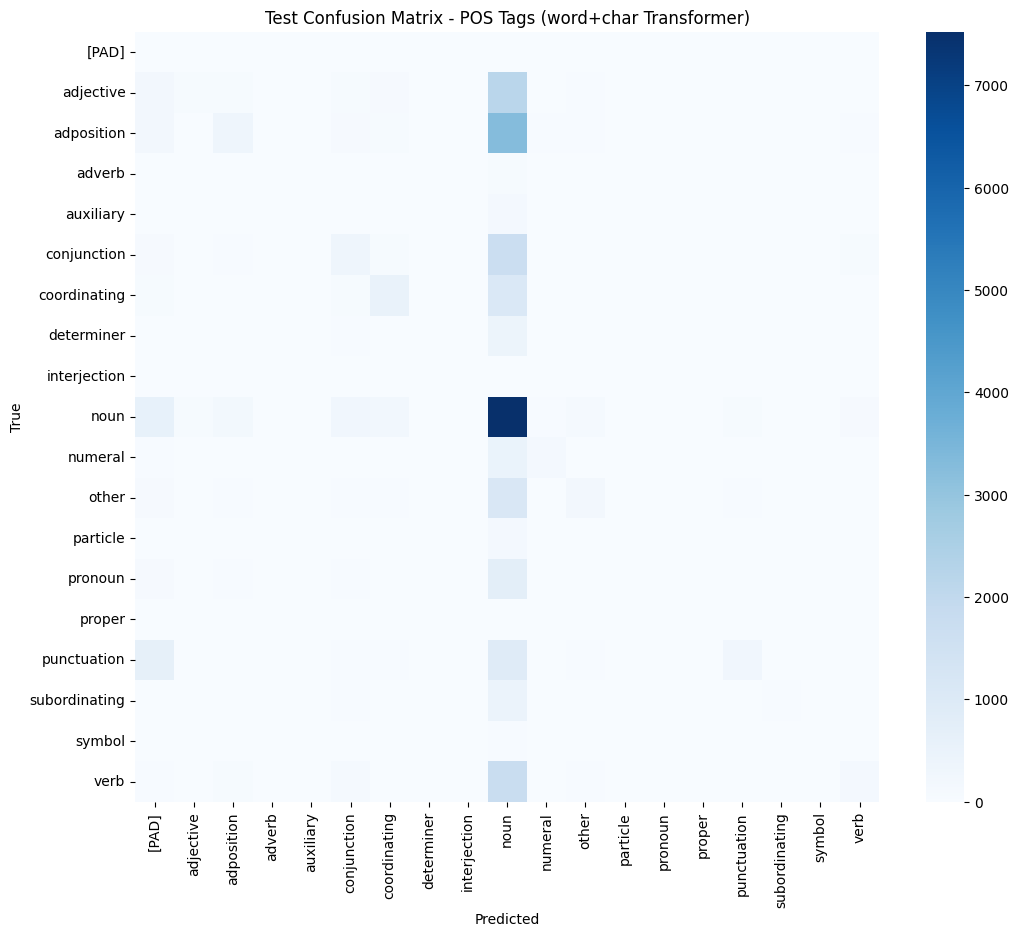

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

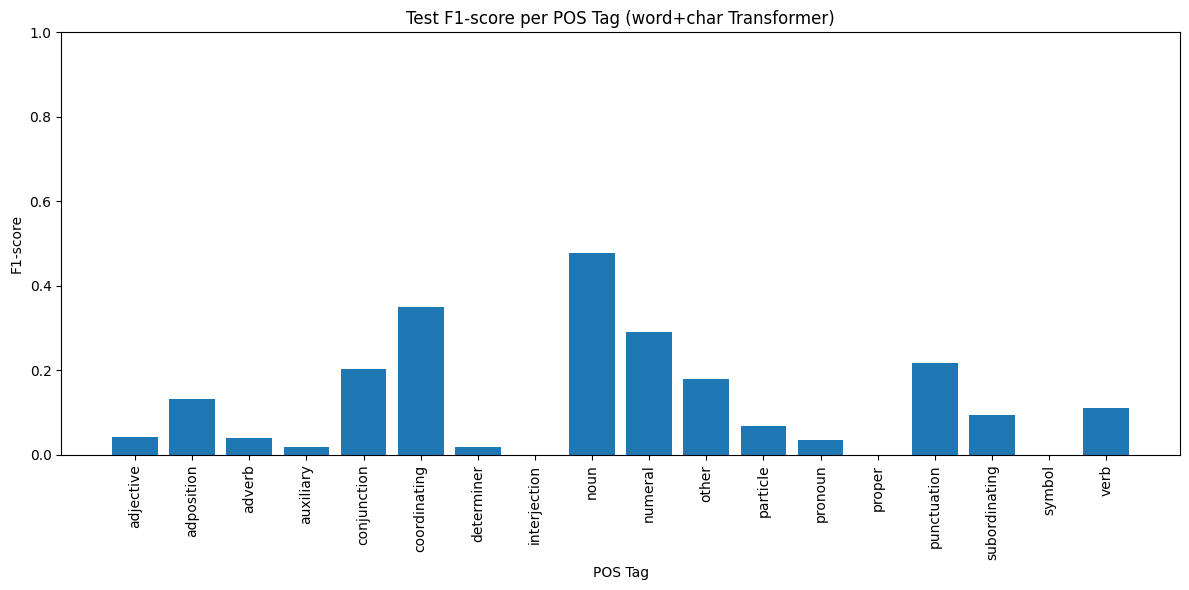

Test Sequence-level accuracy: 0.0469361147327249


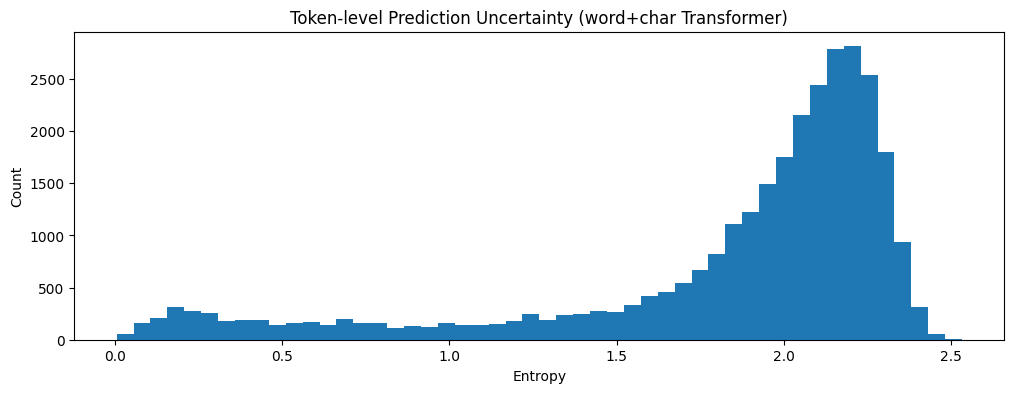

BLEU score (corpus-level): 16.98

Sample 1:
Words:  ['الشيشان', 'جاهزة', 'ل', 'الانتخابات', 'النيابية', 'الاحد', 'المقبل']
Gold tags:   ['noun', 'punctuation', 'adjective', 'punctuation', 'adposition', 'noun', 'adjective', 'noun', 'adjective']
Predicted:   ['noun', 'punctuation', 'noun', 'punctuation', 'noun', 'noun', 'adjective', 'noun', 'noun']
----------------------------------------

Sample 2:
Words:  ['و', 'أشارت', 'إلى', 'أن', 'عناصر', 'ها', 'أطلقت', 'تسعة', 'صواريخ', 'من', 'طراز', 'قسام', 'ب', 'اتجاه', 'قاعدة', 'ل', 'الجيش', 'الإسرائيلى', 'شرق', 'مدينة', 'غزة', '،', 'فيما', 'قامت', 'مجموعة', 'أخرى', 'ب', 'قصف', 'ما', 'يسمى', 'ب', 'مدينة', 'اسديروت', 'ب', 'أربعة', 'صواريخ', 'قسام', 'واحد']
Gold tags:   ['coordinating', 'conjunction', 'verb', 'adposition', 'subordinating', 'conjunction', 'noun', 'pronoun', 'verb', 'numeral', 'noun', 'adposition', 'noun', 'other', 'adposition', 'noun', 'adjective', 'adposition', 'noun', 'adjective', 'noun', 'noun', 'noun', 'punctuation', 'coordinat

In [13]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import pickle
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, Dense, Dropout, TimeDistributed,
    GlobalMaxPooling1D, Concatenate, LayerNormalization, MultiHeadAttention
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from tensorflow.keras.optimizers import Adam

# ========= USER CONFIG ========= #
data_size   = None
max_epochs  = 40
batch_size  = 32
random_state = 42

excel_path = "/kaggle/input/fulltag/padt_pos_4cols_fulltags.xlsx"
pkl_path   = "/kaggle/working/preprocessed_pos_data_padt_word_char_trans.pkl"

MAX_LEN        = 100   # max words per sentence
MAX_WORD_LEN   = 15    # max chars per word
WORD_EMB_DIM   = 128
CHAR_EMB_DIM   = 50
TRANS_LAYERS   = 2
TRANS_HEADS    = 4
TRANS_FF_DIM   = 256
# =============================== #

# ========== DATA PREPROCESS (CACHED) ========== #
if os.path.exists(pkl_path):
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    X_words = data["X_words"]
    X_chars = data["X_chars"]
    y = data["y"]
    sentences = data["sentences"]
    tag_tokenizer = data["tag_tokenizer"]
    word_tokenizer = data["word_tokenizer"]
    char_tokenizer = data["char_tokenizer"]
    print("Loaded preprocessed WORD+CHAR data from pickle.")
else:
    df = pd.read_excel(excel_path)

    sent_cols = ["train_sentence", "dev_sentence", "test_sentence"]
    pos_cols  = ["train_pos_seq",  "dev_pos_seq",  "test_pos_seq"]

    all_sentences, all_tags_seq = [], []
    for s_col, p_col in zip(sent_cols, pos_cols):
        s = df[s_col].fillna("").astype(str).values
        p = df[p_col].fillna("").astype(str).values
        for sent, tags in zip(s, p):
            if sent.strip() == "" or tags.strip() == "":
                continue
            all_sentences.append(sent)
            all_tags_seq.append(tags)

    sentences = np.array(all_sentences)
    tags_seq  = np.array(all_tags_seq)

    if data_size is not None and data_size <= len(sentences):
        sentences = sentences[:data_size]
        tags_seq  = tags_seq[:data_size]

    print("Total sentences:", len(sentences))

    # ---------- 1) WORD tokenizer ----------
    word_tokenizer = Tokenizer(char_level=False, oov_token="[OOV]")
    word_tokenizer.fit_on_texts(sentences)
    word_seqs = word_tokenizer.texts_to_sequences(sentences)
    X_words = pad_sequences(word_seqs, maxlen=MAX_LEN, padding="post", truncating="post")

    # ---------- 2) CHAR tokenizer ----------
    all_words_for_chars = []
    for sent in sentences:
        all_words_for_chars.extend(sent.split())

    char_tokenizer = Tokenizer(char_level=True, oov_token="[OOV_CH]")
    char_tokenizer.fit_on_texts(all_words_for_chars)

    def sentence_to_char_ids(sent):
        words = sent.split()
        words = words[:MAX_LEN] + [""] * max(0, MAX_LEN - len(words))
        char_ids = []
        for w in words:
            chars = list(w)
            ch_seq = char_tokenizer.texts_to_sequences(["".join(chars)])[0]
            ch_seq = ch_seq[:MAX_WORD_LEN]
            ch_seq = ch_seq + [0] * max(0, MAX_WORD_LEN - len(ch_seq))
            char_ids.append(ch_seq)
        return np.array(char_ids, dtype="int32")

    X_chars = np.stack([sentence_to_char_ids(s) for s in sentences])  # (N, max_len, max_word_len)

    # ---------- 3) Tag tokenizer ----------
    tag_tokenizer = Tokenizer()
    tag_tokenizer.fit_on_texts(tags_seq)
    y_seqs = tag_tokenizer.texts_to_sequences(tags_seq)
    y = pad_sequences(y_seqs, maxlen=MAX_LEN, padding="post", truncating="post")

    with open(pkl_path, "wb") as f:
        pickle.dump({
            "X_words": X_words,
            "X_chars": X_chars,
            "y": y,
            "sentences": sentences,
            "tag_tokenizer": tag_tokenizer,
            "word_tokenizer": word_tokenizer,
            "char_tokenizer": char_tokenizer
        }, f)
    print("Saved preprocessed WORD+CHAR data to pickle.")

# ====== SHAPES ====== #
vocab_size_words = len(word_tokenizer.word_index) + 1
vocab_size_chars = len(char_tokenizer.word_index) + 1
tag_count        = len(tag_tokenizer.word_index) + 1
max_len          = X_words.shape[1]
max_word_len     = X_chars.shape[2]

print("vocab_size_words:", vocab_size_words)
print("vocab_size_chars:", vocab_size_chars)
print("tag_count       :", tag_count)
print("max_len(words)  :", max_len)
print("max_word_len    :", max_word_len)

# ====== SPLIT ====== #
Xw_trainval, Xw_test, Xc_trainval, Xc_test, y_trainval, y_test = train_test_split(
    X_words, X_chars, y, test_size=0.1, random_state=random_state
)
Xw_train, Xw_val, Xc_train, Xc_val, y_train, y_val = train_test_split(
    Xw_trainval, Xc_trainval, y_trainval, test_size=0.1111, random_state=random_state
)
print("Train words:", Xw_train.shape, "chars:", Xc_train.shape, "y:", y_train.shape)
print("Val   words:", Xw_val.shape, "chars:", Xc_val.shape, "y:", y_val.shape)
print("Test  words:", Xw_test.shape, "chars:", Xc_test.shape, "y:", y_test.shape)

# ====== TRANSFORMER ENCODER BLOCK ====== #
class SimpleTransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, num_heads, embed_dim, ff_dim, dropout=0.1):
        super().__init__()
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation='relu'),
            Dense(embed_dim)
        ])
        self.layernorm1 = LayerNormalization()
        self.layernorm2 = LayerNormalization()
        self.dropout1 = Dropout(dropout)
        self.dropout2 = Dropout(dropout)

    def call(self, inputs):
        attn_output = self.att(inputs, inputs)  # لا نمرّر mask لتفادي مشاكل البث [web:136][web:138]
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        out2 = self.layernorm2(out1 + ffn_output)
        return self.dropout2(out2)

class StackedTransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, num_layers=TRANS_LAYERS, num_heads=TRANS_HEADS,
                 embed_dim=WORD_EMB_DIM+50, ff_dim=TRANS_FF_DIM, dropout=0.1):
        super().__init__()
        self.encoders = [
            SimpleTransformerEncoder(num_heads=num_heads,
                                     embed_dim=embed_dim,
                                     ff_dim=ff_dim,
                                     dropout=dropout)
            for _ in range(num_layers)
        ]
        self.norm = LayerNormalization()
        self.dropout = Dropout(dropout)

    def call(self, inputs):
        x = inputs
        for encoder in self.encoders:
            x = encoder(x)
        x = self.norm(x)
        return self.dropout(x)

# ====== MODEL: word+char embedding -> concat -> Transformer -> TimeDistributed ====== #
word_inputs = Input(shape=(max_len,), name="word_input")
# بدون mask_zero لتفادي مشاكل Concatenate مع مدخل آخر [web:143]
word_emb = Embedding(vocab_size_words, WORD_EMB_DIM,
                     mask_zero=False, name="word_embedding")(word_inputs)

char_inputs = Input(shape=(max_len, max_word_len), name="char_input")
char_emb_layer = Embedding(vocab_size_chars, CHAR_EMB_DIM,
                           mask_zero=False, name="char_embedding")
char_emb = TimeDistributed(char_emb_layer, name="td_char_emb")(char_inputs)  # (B, T, W, C)

char_cnn = TimeDistributed(
    Conv1D(filters=50, kernel_size=3, padding="same", activation="relu"),
    name="td_char_cnn"
)(char_emb)
char_pool = TimeDistributed(GlobalMaxPooling1D(), name="td_char_pool")(char_cnn)  # (B, T, 50)

merged = Concatenate(axis=-1, name="word_char_concat")([word_emb, char_pool])  # (B, T, WORD_EMB_DIM+50)

encoder_out = StackedTransformerEncoder()(merged)

logits = TimeDistributed(Dense(tag_count, activation="softmax"),
                         name="tag_output")(encoder_out)

model = Model(inputs=[word_inputs, char_inputs], outputs=logits)
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

# ====== TRAIN ====== #
y_train_targets = np.expand_dims(y_train, -1)
y_val_targets   = np.expand_dims(y_val, -1)

early = EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
checkpoint = ModelCheckpoint("/kaggle/working/best_word_char_trans_pos.keras",
                             monitor="val_loss", save_best_only=True)

history = model.fit(
    [Xw_train, Xc_train], y_train_targets,
    batch_size=batch_size,
    epochs=max_epochs,
    validation_data=([Xw_val, Xc_val], y_val_targets),
    callbacks=[early, checkpoint]
)

# ====== EVALUATION ====== #
y_probs = model.predict([Xw_test, Xc_test])
y_pred = np.argmax(y_probs, axis=-1)
y_true = y_test

y_true = np.squeeze(y_true)
y_pred = np.squeeze(y_pred)

mask = (y_true != 0)
y_true_flat = y_true[mask]
y_pred_flat = y_pred[mask]

idx2tag = {v: k for k, v in tag_tokenizer.word_index.items()}
idx2tag[0] = '[PAD]'
y_true_tags = [idx2tag[idx] for idx in y_true_flat]
y_pred_tags = [idx2tag[idx] for idx in y_pred_flat]

print("\nTest Classification Report:")
with open("/kaggle/working/test_classification_report_word_char_trans.txt", "w", encoding="utf-8") as f:
    f.write(classification_report(y_true_tags, y_pred_tags))
print(classification_report(y_true_tags, y_pred_tags))

labels = np.unique(y_true_tags + y_pred_tags)
cm = confusion_matrix(y_true_tags, y_pred_tags, labels=labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix - POS Tags (word+char Transformer)")
plt.savefig("/kaggle/working/Test_Confusion_Matrix_word_char_Transformer.png")
plt.show()

report = classification_report(y_true_tags, y_pred_tags, output_dict=True)
f1s = [report[tag]["f1-score"] for tag in labels if tag != "[PAD]"]
plt.figure(figsize=(12, 6))
plt.bar(labels[1:], f1s)
plt.title("Test F1-score per POS Tag (word+char Transformer)")
plt.xlabel("POS Tag")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("/kaggle/working/Test_F1-score_word_char_Transformer.png")
plt.show()

sequence_correct = (y_true == y_pred).all(axis=1)
print("Test Sequence-level accuracy:", sequence_correct.mean())

def compute_entropy(prob_vec):
    prob_vec = np.clip(prob_vec, 1e-12, 1 - 1e-12)
    return -np.sum(prob_vec * np.log(prob_vec), axis=-1)

entropies = compute_entropy(y_probs)
plt.figure(figsize=(12, 4))
plt.hist(entropies[mask], bins=50)
plt.title("Token-level Prediction Uncertainty (word+char Transformer)")
plt.xlabel("Entropy")
plt.ylabel("Count")
plt.savefig("/kaggle/working/Test_Token-level_Prediction_Uncertainty_word_char_Transformer.png")
plt.show()

# --- BLEU Evaluation ---
bleu_hyps, bleu_refs = [], []
for i in range(y_true.shape[0]):
    ref_seq = [idx2tag[tag] for tag in y_true[i] if tag != 0]
    hyp_seq = [idx2tag[tag] for tag in y_pred[i] if tag != 0]
    if ref_seq and hyp_seq:
        bleu_refs.append([ref_seq])
        bleu_hyps.append(hyp_seq)
bleu = corpus_bleu(bleu_refs, bleu_hyps, smoothing_function=SmoothingFunction().method4)
print(f"BLEU score (corpus-level): {bleu*100:.2f}")

# --- Sample Print ---
n_samples = 5
idx2word = {v: k for k, v in word_tokenizer.word_index.items()}
idx2word[0] = "[PAD]"

for i in range(n_samples):
    idx = np.random.randint(len(Xw_test))
    words = [idx2word[w] for w in Xw_test[idx] if w != 0]
    true_seq = [idx2tag[tag] for tag in y_true[idx] if tag != 0]
    pred_seq = [idx2tag[tag] for tag in y_pred[idx] if tag != 0]
    print(f"\nSample {i+1}:")
    print("Words: ", words)
    print("Gold tags:  ", true_seq)
    print("Predicted:  ", pred_seq)
    print("-" * 40)


Total sentences: 7664
Saved preprocessed WORD+CHAR data to pickle.
vocab_size_words: 24655
vocab_size_chars: 107
tag_count       : 19
max_len(words)  : 100
max_word_len    : 15
Train words: (6130, 100) chars: (6130, 100, 15) y: (6130, 100)
Val   words: (767, 100) chars: (767, 100, 15) y: (767, 100)
Test  words: (767, 100) chars: (767, 100, 15) y: (767, 100)


Model: "functional_26"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ char_input          │ (None, 100, 15)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_emb         │ (None, 100, 15,   │      5,350 │ char_input[0][0]  │
│ (TimeDistributed)   │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_input          │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_cnn         │ (None, 100, 15,   │      7,550 │ td_char_emb[0][0] │
│ (TimeDistributed)   │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 100, 128)  │  3,155,840 │ word_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_pool        │ (None, 100, 50)   │          0 │ td_char_cnn[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_char_concat    │ (None, 100, 178)  │          0 │ word_embedding[0… │
│ (Concatenate)       │                   │            │ td_char_pool[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 100, 256)  │    314,368 │ word_char_concat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ deep_cnnsde_poss_8  │ (None, 100, 96)   │    138,816 │ bilstm[0][0]      │
│ (DeepCNNSDEPoss)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tag_output          │ (None, 100, 19)   │      1,843 │ deep_cnnsde_poss… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,623,767 (13.82 MB)

 Trainable params: 3,623,767 (13.82 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 67s 130ms/step - accuracy: 0.6828 - loss: 1.1171 - val_accuracy: 0.7644 - val_loss: 0.7022
Epoch 2/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - accuracy: 0.7561 - loss: 0.7104 - val_accuracy: 0.8106 - val_loss: 0.5375
Epoch 3/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - accuracy: 0.8107 - loss: 0.5341 - val_accuracy: 0.8450 - val_loss: 0.4380
Epoch 4/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - accuracy: 0.8462 - loss: 0.4309 - val_accuracy: 0.8685 - val_loss: 0.3730
Epoch 5/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - accuracy: 0.8742 - loss: 0.3513 - val_accuracy: 0.8821 - val_loss: 0.3430
Epoch 6/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - accuracy: 0.8917 - loss: 0.2992 - val_accuracy: 0.8850 - val_loss: 0.3426
Epoch 7/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - accuracy: 0.9043 - loss: 0.2620 - val_accuracy: 0.8942 - val_loss: 0.3302
Epoch 8/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 15s 77ms/step - accuracy: 0.9151 - loss: 0.2314 -

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

               precision    recall  f1-score   support

        [PAD]       0.00      0.00      0.00         0
    adjective       0.77      0.60      0.68      2823
   adposition       0.78      0.68      0.73      4218
       adverb       0.82      0.28      0.42        99
    auxiliary       0.68      0.49      0.57       204
  conjunction       0.69      0.78      0.73      2427
 coordinating       0.74      0.76      0.75      1873
   determiner       0.71      0.53      0.61       545
 interjection       0.00      0.00      0.00         1
         noun       0.69      0.82      0.75      9315
      numeral       0.70      0.72      0.71       807
        other       0.67      0.54      0.60      1666
     particle       0.61      0.35      0.45       216
      pronoun       0.67      0.67      0.67      1043
       proper       0.67      0.07      0.12        29
  punctuation       0.79      0.79      0.79      2057
subordinating       0.83      0.75      0.79       557
       sy

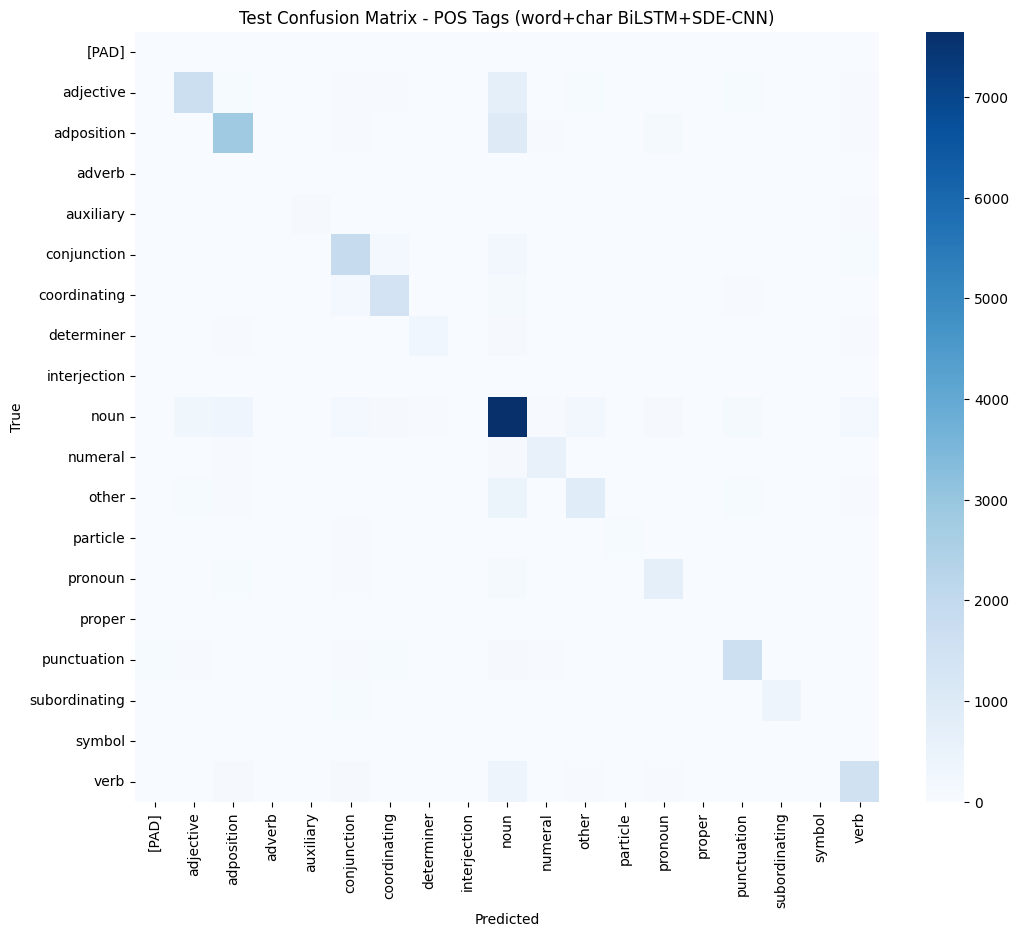

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

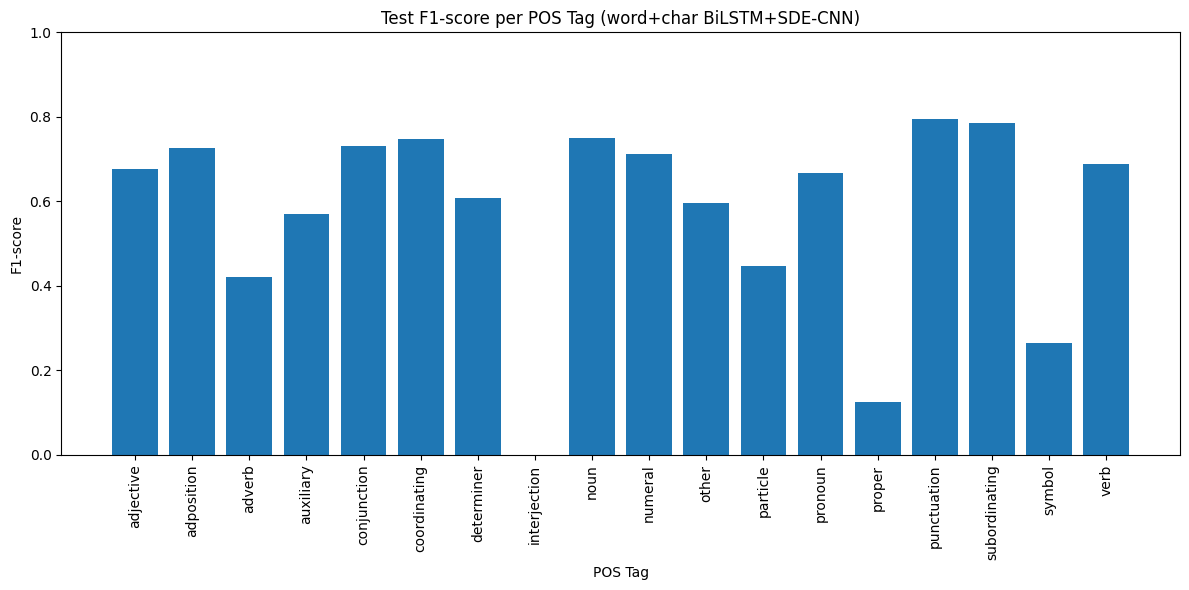

Test Sequence-level accuracy: 0.13820078226857888


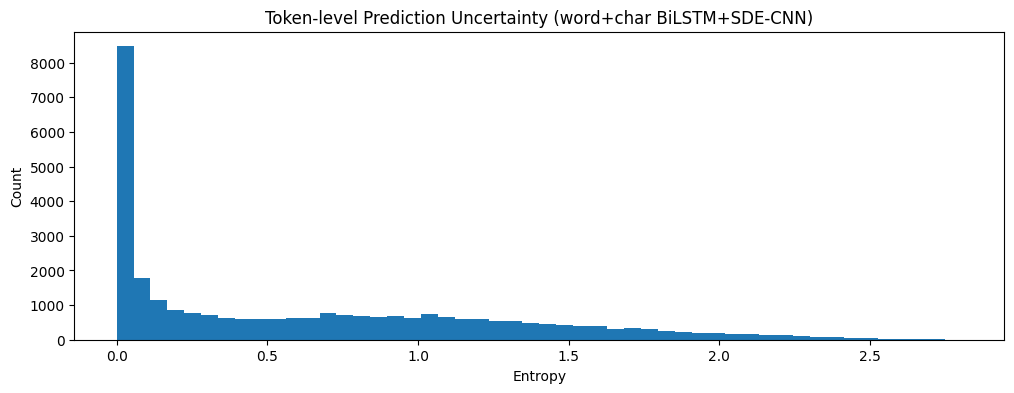

BLEU score (corpus-level): 63.79

Sample 1:
Words:  ['و', 'يمثل', 'وينير', 'بروكلين', 'وكوينز', 'في', 'نيويورك', 'و', 'كان', 'هو', 'المسؤول', 'الرئيسي', 'عن', 'إدراج', 'الرعايا', 'السعوديين', 'ضمن', 'رعايا', 'دول', 'عربية', 'و', 'إسلامية', 'كان', 'يتعين', 'علي', 'هم', 'تسجيل', 'أنفس', 'هم', 'ب', 'شكل', 'دوري', 'لدى', 'سلطات', 'الهجرة', 'الأمريكية']
Gold tags:   ['coordinating', 'conjunction', 'verb', 'other', 'other', 'other', 'adposition', 'other', 'coordinating', 'conjunction', 'verb', 'pronoun', 'adjective', 'adjective', 'adposition', 'noun', 'noun', 'adjective', 'adposition', 'noun', 'noun', 'adjective', 'coordinating', 'conjunction', 'adjective', 'verb', 'verb', 'adposition', 'pronoun', 'noun', 'noun', 'pronoun', 'adposition', 'noun', 'adjective', 'adposition', 'noun', 'noun', 'adjective', 'punctuation']
Predicted:   ['coordinating', 'conjunction', 'verb', 'other', 'other', 'other', 'adposition', 'other', 'coordinating', 'conjunction', 'verb', 'pronoun', 'noun', 'adjective', 'adpo

In [14]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import pickle
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, Dense, Dropout, TimeDistributed,
    GlobalMaxPooling1D, Concatenate, Bidirectional, LSTM
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from tensorflow.keras.optimizers import Adam

# ========= USER CONFIG ========= #
data_size   = None
max_epochs  = 40
batch_size  = 32
random_state = 42

excel_path = "/kaggle/input/fulltag/padt_pos_4cols_fulltags.xlsx"
pkl_path   = "/kaggle/working/preprocessed_pos_data_padt_word_char_bilstm_sde.pkl"

MAX_LEN        = 100   # max words per sentence
MAX_WORD_LEN   = 15    # max chars per word
WORD_EMB_DIM   = 128
CHAR_EMB_DIM   = 50
LSTM_UNITS     = 128
SDE_FILTERS    = 96
SDE_KERNEL     = 3
SDE_LAYERS     = 2
# =============================== #

# ========== DATA PREPROCESS (CACHED) ========== #
if os.path.exists(pkl_path):
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    X_words = data["X_words"]
    X_chars = data["X_chars"]
    y = data["y"]
    sentences = data["sentences"]
    tag_tokenizer = data["tag_tokenizer"]
    word_tokenizer = data["word_tokenizer"]
    char_tokenizer = data["char_tokenizer"]
    print("Loaded preprocessed WORD+CHAR data from pickle.")
else:
    df = pd.read_excel(excel_path)

    sent_cols = ["train_sentence", "dev_sentence", "test_sentence"]
    pos_cols  = ["train_pos_seq",  "dev_pos_seq",  "test_pos_seq"]

    all_sentences, all_tags_seq = [], []
    for s_col, p_col in zip(sent_cols, pos_cols):
        s = df[s_col].fillna("").astype(str).values
        p = df[p_col].fillna("").astype(str).values
        for sent, tags in zip(s, p):
            if sent.strip() == "" or tags.strip() == "":
                continue
            all_sentences.append(sent)
            all_tags_seq.append(tags)

    sentences = np.array(all_sentences)
    tags_seq  = np.array(all_tags_seq)

    if data_size is not None and data_size <= len(sentences):
        sentences = sentences[:data_size]
        tags_seq  = tags_seq[:data_size]

    print("Total sentences:", len(sentences))

    # ---------- 1) WORD tokenizer ----------
    word_tokenizer = Tokenizer(char_level=False, oov_token="[OOV]")
    word_tokenizer.fit_on_texts(sentences)
    word_seqs = word_tokenizer.texts_to_sequences(sentences)
    X_words = pad_sequences(word_seqs, maxlen=MAX_LEN, padding="post", truncating="post")

    # ---------- 2) CHAR tokenizer ----------
    all_words_for_chars = []
    for sent in sentences:
        all_words_for_chars.extend(sent.split())

    char_tokenizer = Tokenizer(char_level=True, oov_token="[OOV_CH]")
    char_tokenizer.fit_on_texts(all_words_for_chars)

    def sentence_to_char_ids(sent):
        words = sent.split()
        words = words[:MAX_LEN] + [""] * max(0, MAX_LEN - len(words))
        char_ids = []
        for w in words:
            chars = list(w)
            ch_seq = char_tokenizer.texts_to_sequences(["".join(chars)])[0]
            ch_seq = ch_seq[:MAX_WORD_LEN]
            ch_seq = ch_seq + [0] * max(0, MAX_WORD_LEN - len(ch_seq))
            char_ids.append(ch_seq)
        return np.array(char_ids, dtype="int32")

    X_chars = np.stack([sentence_to_char_ids(s) for s in sentences])  # (N, max_len, max_word_len)

    # ---------- 3) Tag tokenizer ----------
    tag_tokenizer = Tokenizer()
    tag_tokenizer.fit_on_texts(tags_seq)
    y_seqs = tag_tokenizer.texts_to_sequences(tags_seq)
    y = pad_sequences(y_seqs, maxlen=MAX_LEN, padding="post", truncating="post")

    with open(pkl_path, "wb") as f:
        pickle.dump({
            "X_words": X_words,
            "X_chars": X_chars,
            "y": y,
            "sentences": sentences,
            "tag_tokenizer": tag_tokenizer,
            "word_tokenizer": word_tokenizer,
            "char_tokenizer": char_tokenizer
        }, f)
    print("Saved preprocessed WORD+CHAR data to pickle.")

# ====== SHAPES ====== #
vocab_size_words = len(word_tokenizer.word_index) + 1
vocab_size_chars = len(char_tokenizer.word_index) + 1
tag_count        = len(tag_tokenizer.word_index) + 1
max_len          = X_words.shape[1]
max_word_len     = X_chars.shape[2]

print("vocab_size_words:", vocab_size_words)
print("vocab_size_chars:", vocab_size_chars)
print("tag_count       :", tag_count)
print("max_len(words)  :", max_len)
print("max_word_len    :", max_word_len)

# ====== SPLIT ====== #
Xw_trainval, Xw_test, Xc_trainval, Xc_test, y_trainval, y_test = train_test_split(
    X_words, X_chars, y, test_size=0.1, random_state=random_state
)
Xw_train, Xw_val, Xc_train, Xc_val, y_train, y_val = train_test_split(
    Xw_trainval, Xc_trainval, y_trainval, test_size=0.1111, random_state=random_state
)
print("Train words:", Xw_train.shape, "chars:", Xc_train.shape, "y:", y_train.shape)
print("Val   words:", Xw_val.shape, "chars:", Xc_val.shape, "y:", y_val.shape)
print("Test  words:", Xw_test.shape, "chars:", Xc_test.shape, "y:", y_test.shape)

# ====== SDE-CNN BLOCK ====== #
class DeepCNNSDEPoss(tf.keras.layers.Layer):
    def __init__(self, filters=SDE_FILTERS, kernel_size=SDE_KERNEL, layers=SDE_LAYERS):
        super().__init__()
        self.cnns = [Conv1D(filters, kernel_size, padding='same', activation='relu') for _ in range(layers)]
        self.dropouts = [Dropout(0.18) for _ in range(layers)]
        self.drifts = [Dense(filters) for _ in range(layers)]
        self.diffusions = [Dense(filters) for _ in range(layers)]

    def call(self, inputs, training=None):
        x = inputs
        dt = 1.0
        for cnn, drift, diffu, drop in zip(self.cnns, self.drifts, self.diffusions, self.dropouts):
            x = drop(x, training=training)
            x = cnn(x)
            b = tf.shape(x)[0]
            t = tf.shape(x)[1]
            c = tf.shape(x)[2]
            noise = tf.random.normal((b, t, c), mean=0., stddev=1.)
            x = x + drift(x) * dt + diffu(x) * noise * tf.sqrt(dt)
        return x

# ====== MODEL: word+char -> BiLSTM -> SDE-CNN -> TimeDistributed ====== #
word_inputs = Input(shape=(max_len,), name="word_input")
word_emb = Embedding(vocab_size_words, WORD_EMB_DIM,
                     mask_zero=False, name="word_embedding")(word_inputs)

char_inputs = Input(shape=(max_len, max_word_len), name="char_input")
char_emb_layer = Embedding(vocab_size_chars, CHAR_EMB_DIM,
                           mask_zero=False, name="char_embedding")
char_emb = TimeDistributed(char_emb_layer, name="td_char_emb")(char_inputs)

char_cnn = TimeDistributed(
    Conv1D(filters=50, kernel_size=3, padding="same", activation="relu"),
    name="td_char_cnn"
)(char_emb)
char_pool = TimeDistributed(GlobalMaxPooling1D(), name="td_char_pool")(char_cnn)

merged = Concatenate(axis=-1, name="word_char_concat")([word_emb, char_pool])

bilstm = Bidirectional(
    LSTM(LSTM_UNITS, return_sequences=True),
    name="bilstm"
)(merged)

sde_out = DeepCNNSDEPoss()(bilstm)

logits = TimeDistributed(Dense(tag_count, activation="softmax"),
                         name="tag_output")(sde_out)

model = Model(inputs=[word_inputs, char_inputs], outputs=logits)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

# ====== TRAIN ====== #
y_train_targets = np.expand_dims(y_train, -1)
y_val_targets   = np.expand_dims(y_val, -1)

early = EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
checkpoint = ModelCheckpoint("/kaggle/working/best_word_char_bilstm_sde_pos.keras",
                             monitor="val_loss", save_best_only=True)

history = model.fit(
    [Xw_train, Xc_train], y_train_targets,
    batch_size=batch_size,
    epochs=max_epochs,
    validation_data=([Xw_val, Xc_val], y_val_targets),
    callbacks=[early, checkpoint]
)

# ====== EVALUATION ====== #
y_probs = model.predict([Xw_test, Xc_test])
y_pred = np.argmax(y_probs, axis=-1)
y_true = y_test

y_true = np.squeeze(y_true)
y_pred = np.squeeze(y_pred)

mask = (y_true != 0)
y_true_flat = y_true[mask]
y_pred_flat = y_pred[mask]

idx2tag = {v: k for k, v in tag_tokenizer.word_index.items()}
idx2tag[0] = '[PAD]'
y_true_tags = [idx2tag[idx] for idx in y_true_flat]
y_pred_tags = [idx2tag[idx] for idx in y_pred_flat]

print("\nTest Classification Report:")
with open("/kaggle/working/test_classification_report_word_char_bilstm_sde.txt", "w", encoding="utf-8") as f:
    f.write(classification_report(y_true_tags, y_pred_tags))
print(classification_report(y_true_tags, y_pred_tags))

labels = np.unique(y_true_tags + y_pred_tags)
cm = confusion_matrix(y_true_tags, y_pred_tags, labels=labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix - POS Tags (word+char BiLSTM+SDE-CNN)")
plt.savefig("/kaggle/working/Test_Confusion_Matrix_word_char_BiLSTM_SDE.png")
plt.show()

report = classification_report(y_true_tags, y_pred_tags, output_dict=True)
f1s = [report[tag]["f1-score"] for tag in labels if tag != "[PAD]"]
plt.figure(figsize=(12, 6))
plt.bar(labels[1:], f1s)
plt.title("Test F1-score per POS Tag (word+char BiLSTM+SDE-CNN)")
plt.xlabel("POS Tag")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("/kaggle/working/Test_F1-score_word_char_BiLSTM_SDE.png")
plt.show()

sequence_correct = (y_true == y_pred).all(axis=1)
print("Test Sequence-level accuracy:", sequence_correct.mean())

def compute_entropy(prob_vec):
    prob_vec = np.clip(prob_vec, 1e-12, 1 - 1e-12)
    return -np.sum(prob_vec * np.log(prob_vec), axis=-1)

entropies = compute_entropy(y_probs)
plt.figure(figsize=(12, 4))
plt.hist(entropies[mask], bins=50)
plt.title("Token-level Prediction Uncertainty (word+char BiLSTM+SDE-CNN)")
plt.xlabel("Entropy")
plt.ylabel("Count")
plt.savefig("/kaggle/working/Test_Token-level_Prediction_Uncertainty_word_char_BiLSTM_SDE.png")
plt.show()

# --- BLEU Evaluation ---
bleu_hyps, bleu_refs = [], []
for i in range(y_true.shape[0]):
    ref_seq = [idx2tag[tag] for tag in y_true[i] if tag != 0]
    hyp_seq = [idx2tag[tag] for tag in y_pred[i] if tag != 0]
    if ref_seq and hyp_seq:
        bleu_refs.append([ref_seq])
        bleu_hyps.append(hyp_seq)
bleu = corpus_bleu(bleu_refs, bleu_hyps, smoothing_function=SmoothingFunction().method4)
print(f"BLEU score (corpus-level): {bleu*100:.2f}")

# --- Sample Print ---
n_samples = 5
idx2word = {v: k for k, v in word_tokenizer.word_index.items()}
idx2word[0] = "[PAD]"

for i in range(n_samples):
    idx = np.random.randint(len(Xw_test))
    words = [idx2word[w] for w in Xw_test[idx] if w != 0]
    true_seq = [idx2tag[tag] for tag in y_true[idx] if tag != 0]
    pred_seq = [idx2tag[tag] for tag in y_pred[idx] if tag != 0]
    print(f"\nSample {i+1}:")
    print("Words: ", words)
    print("Gold tags:  ", true_seq)
    print("Predicted:  ", pred_seq)
    print("-" * 40)


Loaded preprocessed WORD+CHAR data from pickle.
vocab_size_words: 24655
vocab_size_chars: 107
tag_count       : 19
max_len(words)  : 100
max_word_len    : 15
Train words: (6130, 100) chars: (6130, 100, 15) y: (6130, 100)
Val   words: (767, 100) chars: (767, 100, 15) y: (767, 100)
Test  words: (767, 100) chars: (767, 100, 15) y: (767, 100)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ char_input          │ (None, 100, 15)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_emb         │ (None, 100, 15,   │      5,350 │ char_input[0][0]  │
│ (TimeDistributed)   │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_input          │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_cnn         │ (None, 100, 15,   │      7,550 │ td_char_emb[0][0] │
│ (TimeDistributed)   │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 100, 128)  │  3,155,840 │ word_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_pool        │ (None, 100, 50)   │          0 │ td_char_cnn[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_char_concat    │ (None, 100, 178)  │          0 │ word_embedding[0… │
│ (Concatenate)       │                   │            │ td_char_pool[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_sde_f (RNN)    │ (None, 100, 128)  │    157,184 │ word_char_concat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_sde_b (RNN)    │ (None, 100, 128)  │    157,184 │ word_char_concat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_sde          │ (None, 100, 256)  │          0 │ lstm_sde_f[0][0], │
│ (Concatenate)       │                   │            │ lstm_sde_b[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tag_output          │ (None, 100, 19)   │      4,883 │ bilstm_sde[0][0]  │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,487,991 (13.31 MB)

 Trainable params: 3,487,991 (13.31 MB)

...

96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 605ms/step - accuracy: 0.6573 - loss: 1.2593

W0000 00:00:1764358718.744713      98 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
W0000 00:00:1764358735.329711      98 assert_op.cc:38] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


96/96 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.6578 - loss: 1.2565 - val_accuracy: 0.7413 - val_loss: 0.7864
Epoch 2/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - accuracy: 0.7400 - loss: 0.7755 - val_accuracy: 0.7737 - val_loss: 0.6527
Epoch 3/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - accuracy: 0.7755 - loss: 0.6415 - val_accuracy: 0.7994 - val_loss: 0.5730
Epoch 4/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - accuracy: 0.8075 - loss: 0.5468 - val_accuracy: 0.8222 - val_loss: 0.5073
Epoch 5/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - accuracy: 0.8345 - loss: 0.4657 - val_accuracy: 0.8441 - val_loss: 0.4455
Epoch 6/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - accuracy: 0.8592 - loss: 0.4010 - val_accuracy: 0.8601 - val_loss: 0.3991
Epoch 7/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - accuracy: 0.8726 - loss: 0.3586 - val_accuracy: 0.8680 - val_loss: 0.3833
Epoch 8/40
96/96 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - accuracy: 0.8908 - loss: 0.3082 - val_accuracy: 0.8721 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

               precision    recall  f1-score   support

        [PAD]       0.00      0.00      0.00         0
    adjective       0.70      0.61      0.65      2823
   adposition       0.70      0.69      0.69      4218
       adverb       0.76      0.19      0.31        99
    auxiliary       0.75      0.49      0.59       204
  conjunction       0.67      0.76      0.71      2427
 coordinating       0.70      0.70      0.70      1873
   determiner       0.61      0.45      0.52       545
 interjection       0.00      0.00      0.00         1
         noun       0.68      0.79      0.73      9315
      numeral       0.69      0.59      0.63       807
        other       0.67      0.48      0.56      1666
     particle       0.74      0.39      0.51       216
      pronoun       0.66      0.57      0.61      1043
       proper       0.75      0.10      0.18        29
  punctuation       0.72      0.74      0.73      2057
subordinating       0.78      0.74      0.76       557
       sy

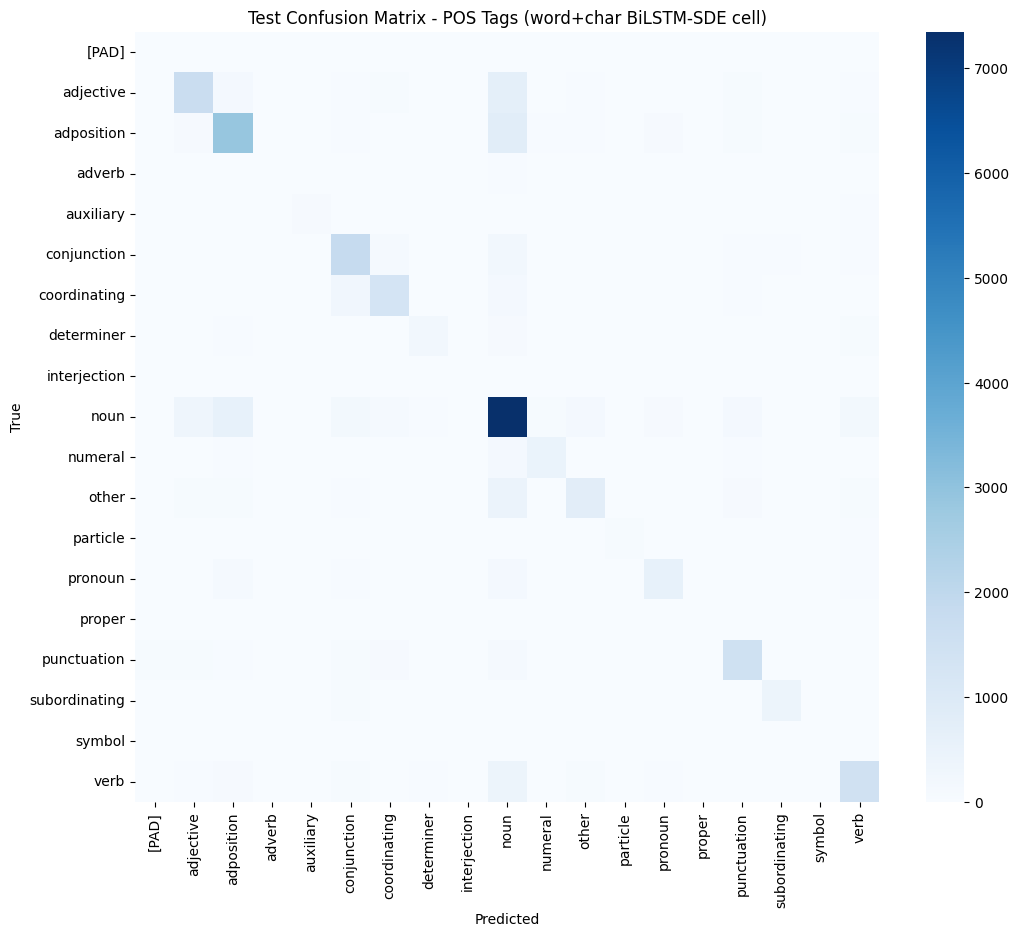

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

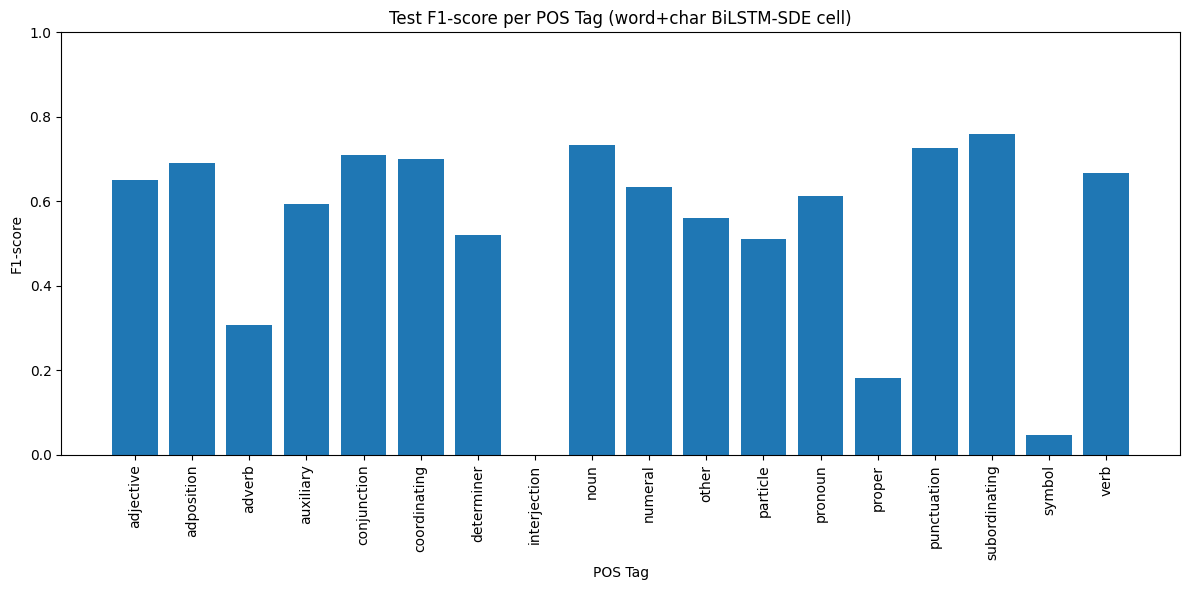

Test Sequence-level accuracy: 0.1303780964797914


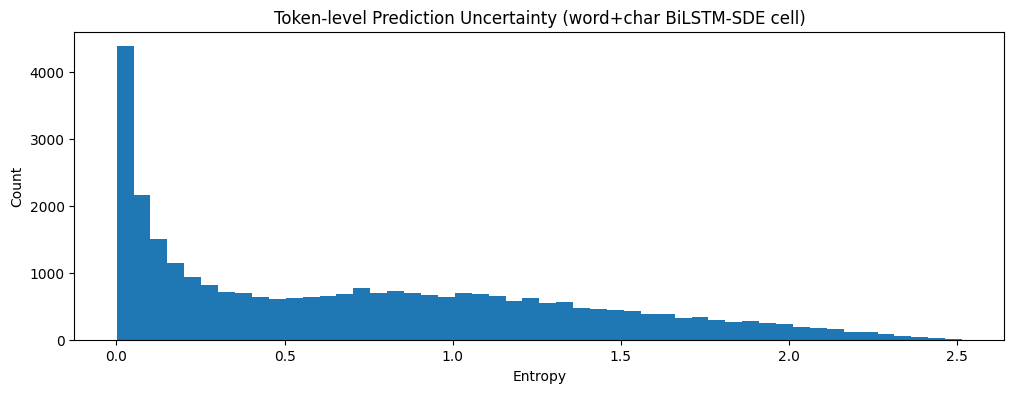

BLEU score (corpus-level): 60.92

Sample 1:
Words:  ['و', 'من', 'جهة', 'ه', '،', 'توقع', 'وزير', 'التخطيط', 'المصري', 'السابق', 'الدكتور', 'أحمد', 'الدرش', 'أن', 'يؤدي', 'استمرار', 'مساندة', 'نظام', 'الصرف', 'الحالي', 'من', 'الحكومة', 'و', 'منظمات', 'الأعمال', 'و', 'كذٰلك', 'الأفراد', 'إلى', 'توريط', 'المضاربين', 'على', 'الدولار', 'في', 'خسائر', 'كبيرة', 'فيما', 'أشار', 'إلى', 'أهمية', 'أن', 'تكون', 'الحكومة', 'جاهزة', 'ل', 'مواجهة', 'مردود', 'القرارات', 'الجديدة', 'المتعلقة', 'ب', 'التعريفة', 'الجمركية', 'التي', 'قد', 'تشجع', 'على', 'تحريك', 'الاستيراد', 'و', 'ب', 'التالي', 'زيادة', 'طلبات', 'فتح', 'الاعتمادات', 'خاصة', 'في', 'ضوء', 'اتجاه', 'الحكومة', 'ل', 'تفعيل', 'قرار', 'يقضي', 'ب', 'تلبية', 'طلبات', 'فتح', 'الاعتمادات', 'المستندية', 'خلال', 'ثلاثة', 'أيام', 'من', 'تقديم', 'ها']
Gold tags:   ['coordinating', 'conjunction', 'adposition', 'noun', 'pronoun', 'punctuation', 'verb', 'noun', 'noun', 'adjective', 'adjective', 'noun', 'other', 'other', 'subordinating', 'conjunction', 'oth

In [6]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import pickle
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, Dense, Dropout, TimeDistributed,
    GlobalMaxPooling1D, Concatenate, RNN
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from tensorflow.keras.optimizers import Adam

# ========= USER CONFIG ========= #
data_size   = None
max_epochs  = 40
batch_size  = 64
random_state = 42

excel_path = "/kaggle/input/fulltag/padt_pos_4cols_fulltags.xlsx"
pkl_path   = "/kaggle/working/preprocessed_pos_data_padt_word_char_lstm_sde.pkl"

MAX_LEN        = 100   # max words per sentence
MAX_WORD_LEN   = 15    # max chars per word
WORD_EMB_DIM   = 128
CHAR_EMB_DIM   = 50
LSTM_UNITS     = 128
NOISE_STD      = 0.5  # جرّب 0.5 أو 1.0
# =============================== #

# ========== DATA PREPROCESS (CACHED) ========== #
if os.path.exists(pkl_path):
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    X_words = data["X_words"]
    X_chars = data["X_chars"]
    y = data["y"]
    sentences = data["sentences"]
    tag_tokenizer = data["tag_tokenizer"]
    word_tokenizer = data["word_tokenizer"]
    char_tokenizer = data["char_tokenizer"]
    print("Loaded preprocessed WORD+CHAR data from pickle.")
else:
    df = pd.read_excel(excel_path)

    sent_cols = ["train_sentence", "dev_sentence", "test_sentence"]
    pos_cols  = ["train_pos_seq",  "dev_pos_seq",  "test_pos_seq"]

    all_sentences, all_tags_seq = [], []
    for s_col, p_col in zip(sent_cols, pos_cols):
        s = df[s_col].fillna("").astype(str).values
        p = df[p_col].fillna("").astype(str).values
        for sent, tags in zip(s, p):
            if sent.strip() == "" or tags.strip() == "":
                continue
            all_sentences.append(sent)
            all_tags_seq.append(tags)

    sentences = np.array(all_sentences)
    tags_seq  = np.array(all_tags_seq)

    if data_size is not None and data_size <= len(sentences):
        sentences = sentences[:data_size]
        tags_seq  = tags_seq[:data_size]

    print("Total sentences:", len(sentences))

    # ---------- 1) WORD tokenizer ----------
    word_tokenizer = Tokenizer(char_level=False, oov_token="[OOV]")
    word_tokenizer.fit_on_texts(sentences)
    word_seqs = word_tokenizer.texts_to_sequences(sentences)
    X_words = pad_sequences(word_seqs, maxlen=MAX_LEN, padding="post", truncating="post")

    # ---------- 2) CHAR tokenizer ----------
    all_words_for_chars = []
    for sent in sentences:
        all_words_for_chars.extend(sent.split())

    char_tokenizer = Tokenizer(char_level=True, oov_token="[OOV_CH]")
    char_tokenizer.fit_on_texts(all_words_for_chars)

    def sentence_to_char_ids(sent):
        words = sent.split()
        words = words[:MAX_LEN] + [""] * max(0, MAX_LEN - len(words))
        char_ids = []
        for w in words:
            chars = list(w)
            ch_seq = char_tokenizer.texts_to_sequences(["".join(chars)])[0]
            ch_seq = ch_seq[:MAX_WORD_LEN]
            ch_seq = ch_seq + [0] * max(0, MAX_WORD_LEN - len(ch_seq))
            char_ids.append(ch_seq)
        return np.array(char_ids, dtype="int32")

    X_chars = np.stack([sentence_to_char_ids(s) for s in sentences])  # (N, max_len, max_word_len)

    # ---------- 3) Tag tokenizer ----------
    tag_tokenizer = Tokenizer()
    tag_tokenizer.fit_on_texts(tags_seq)
    y_seqs = tag_tokenizer.texts_to_sequences(tags_seq)
    y = pad_sequences(y_seqs, maxlen=MAX_LEN, padding="post", truncating="post")

    with open(pkl_path, "wb") as f:
        pickle.dump({
            "X_words": X_words,
            "X_chars": X_chars,
            "y": y,
            "sentences": sentences,
            "tag_tokenizer": tag_tokenizer,
            "word_tokenizer": word_tokenizer,
            "char_tokenizer": char_tokenizer
        }, f)
    print("Saved preprocessed WORD+CHAR data to pickle.")

# ====== SHAPES ====== #
vocab_size_words = len(word_tokenizer.word_index) + 1
vocab_size_chars = len(char_tokenizer.word_index) + 1
tag_count        = len(tag_tokenizer.word_index) + 1
max_len          = X_words.shape[1]
max_word_len     = X_chars.shape[2]

print("vocab_size_words:", vocab_size_words)
print("vocab_size_chars:", vocab_size_chars)
print("tag_count       :", tag_count)
print("max_len(words)  :", max_len)
print("max_word_len    :", max_word_len)

# ====== SPLIT ====== #
Xw_trainval, Xw_test, Xc_trainval, Xc_test, y_trainval, y_test = train_test_split(
    X_words, X_chars, y, test_size=0.1, random_state=random_state
)
Xw_train, Xw_val, Xc_train, Xc_val, y_train, y_val = train_test_split(
    Xw_trainval, Xc_trainval, y_trainval, test_size=0.1111, random_state=random_state
)
print("Train words:", Xw_train.shape, "chars:", Xc_train.shape, "y:", y_train.shape)
print("Val   words:", Xw_val.shape, "chars:", Xc_val.shape, "y:", y_val.shape)
print("Test  words:", Xw_test.shape, "chars:", Xc_test.shape, "y:", y_test.shape)

# ====== LSTM-SDE CELL (Layer-based, كما في وثائق Keras RNN) ====== #
class LSTMSDECell(tf.keras.layers.Layer):
    def __init__(self, units, noise_std=1.0, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        # حالتان: h و c
        self.state_size = [units, units]
        self.output_size = units
        self.noise_std = noise_std

    def build(self, input_shape):
        input_dim = input_shape[-1]

        self.W_x = self.add_weight(
            shape=(input_dim, 4 * self.units),
            initializer="glorot_uniform",
            name="W_x",
        )
        self.W_h = self.add_weight(
            shape=(self.units, 4 * self.units),
            initializer="orthogonal",
            name="W_h",
        )
        self.b = self.add_weight(
            shape=(4 * self.units,),
            initializer="zeros",
            name="b",
        )

        self.drift_dense = Dense(self.units, name="drift_dense")
        self.diff_dense = Dense(self.units, name="diff_dense")

        super().build(input_shape)

    def call(self, inputs, states, training=None):
        h_tm1, c_tm1 = states  # (batch, units)

        z = tf.matmul(inputs, self.W_x) + tf.matmul(h_tm1, self.W_h) + self.b
        zi, zf, zc, zo = tf.split(z, num_or_size_splits=4, axis=-1)

        i = tf.sigmoid(zi)
        f = tf.sigmoid(zf)
        o = tf.sigmoid(zo)
        c_hat = tf.tanh(zc)

        c_t = f * c_tm1 + i * c_hat
        h_t = o * tf.tanh(c_t)

        # SDE term على h_t
        dt = 1.0
        drift = self.drift_dense(h_t)
        diffusion = self.diff_dense(h_t)
        noise = tf.random.normal(tf.shape(h_t), mean=0.0, stddev=self.noise_std)

        h_t_sde = h_t + drift * dt + diffusion * noise * tf.sqrt(dt)

        return h_t_sde, [h_t_sde, c_t]

# ====== MODEL: word+char -> BiLSTM-SDE -> TimeDistributed ====== #
word_inputs = Input(shape=(max_len,), name="word_input")
word_emb = Embedding(vocab_size_words, WORD_EMB_DIM,
                     mask_zero=False, name="word_embedding")(word_inputs)

char_inputs = Input(shape=(max_len, max_word_len), name="char_input")
char_emb_layer = Embedding(vocab_size_chars, CHAR_EMB_DIM,
                           mask_zero=False, name="char_embedding")
char_emb = TimeDistributed(char_emb_layer, name="td_char_emb")(char_inputs)

char_cnn = TimeDistributed(
    Conv1D(filters=50, kernel_size=3, padding="same", activation="relu"),
    name="td_char_cnn"
)(char_emb)
char_pool = TimeDistributed(GlobalMaxPooling1D(), name="td_char_pool")(char_cnn)

merged = Concatenate(axis=-1, name="word_char_concat")([word_emb, char_pool])

# Bi-directional LSTM-SDE يدويًا
lstm_sde_f = RNN(LSTMSDECell(LSTM_UNITS, noise_std=NOISE_STD),
                 return_sequences=True,
                 go_backwards=False,
                 name="lstm_sde_f")(merged)

lstm_sde_b = RNN(LSTMSDECell(LSTM_UNITS, noise_std=NOISE_STD),
                 return_sequences=True,
                 go_backwards=True,
                 name="lstm_sde_b")(merged)

bilstm_sde = Concatenate(axis=-1, name="bilstm_sde")([lstm_sde_f, lstm_sde_b])

logits = TimeDistributed(Dense(tag_count, activation="softmax"),
                         name="tag_output")(bilstm_sde)

model = Model(inputs=[word_inputs, char_inputs], outputs=logits)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

# ====== TRAIN ====== #
y_train_targets = np.expand_dims(y_train, -1)
y_val_targets   = np.expand_dims(y_val, -1)

early = EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
checkpoint = ModelCheckpoint("/kaggle/working/best_word_char_bilstm_sde_cell_pos.keras",
                             monitor="val_loss", save_best_only=True)

history = model.fit(
    [Xw_train, Xc_train], y_train_targets,
    batch_size=batch_size,
    epochs=max_epochs,
    validation_data=([Xw_val, Xc_val], y_val_targets),
    callbacks=[early, checkpoint]
)

# ====== EVALUATION (كما في كودك السابق تمامًا) ====== #
y_probs = model.predict([Xw_test, Xc_test])
y_pred = np.argmax(y_probs, axis=-1)
y_true = y_test

y_true = np.squeeze(y_true)
y_pred = np.squeeze(y_pred)

mask = (y_true != 0)
y_true_flat = y_true[mask]
y_pred_flat = y_pred[mask]

idx2tag = {v: k for k, v in tag_tokenizer.word_index.items()}
idx2tag[0] = '[PAD]'
y_true_tags = [idx2tag[idx] for idx in y_true_flat]
y_pred_tags = [idx2tag[idx] for idx in y_pred_flat]

print("\nTest Classification Report:")
with open("/kaggle/working/test_classification_report_word_char_bilstm_sde_cell.txt", "w", encoding="utf-8") as f:
    f.write(classification_report(y_true_tags, y_pred_tags))
print(classification_report(y_true_tags, y_pred_tags))

labels = np.unique(y_true_tags + y_pred_tags)
cm = confusion_matrix(y_true_tags, y_pred_tags, labels=labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix - POS Tags (word+char BiLSTM-SDE cell)")
plt.savefig("/kaggle/working/Test_Confusion_Matrix_word_char_BiLSTM_SDE_cell.png")
plt.show()

report = classification_report(y_true_tags, y_pred_tags, output_dict=True)
f1s = [report[tag]["f1-score"] for tag in labels if tag != "[PAD]"]
plt.figure(figsize=(12, 6))
plt.bar(labels[1:], f1s)
plt.title("Test F1-score per POS Tag (word+char BiLSTM-SDE cell)")
plt.xlabel("POS Tag")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("/kaggle/working/Test_F1-score_word_char_BiLSTM_SDE_cell.png")
plt.show()

sequence_correct = (y_true == y_pred).all(axis=1)
print("Test Sequence-level accuracy:", sequence_correct.mean())

def compute_entropy(prob_vec):
    prob_vec = np.clip(prob_vec, 1e-12, 1 - 1e-12)
    return -np.sum(prob_vec * np.log(prob_vec), axis=-1)

entropies = compute_entropy(y_probs)
plt.figure(figsize=(12, 4))
plt.hist(entropies[mask], bins=50)
plt.title("Token-level Prediction Uncertainty (word+char BiLSTM-SDE cell)")
plt.xlabel("Entropy")
plt.ylabel("Count")
plt.savefig("/kaggle/working/Test_Token-level_Prediction_Uncertainty_word_char_BiLSTM_SDE_cell.png")
plt.show()

# --- BLEU Evaluation ---
bleu_hyps, bleu_refs = [], []
for i in range(y_true.shape[0]):
    ref_seq = [idx2tag[tag] for tag in y_true[i] if tag != 0]
    hyp_seq = [idx2tag[tag] for tag in y_pred[i] if tag != 0]
    if ref_seq and hyp_seq:
        bleu_refs.append([ref_seq])
        bleu_hyps.append(hyp_seq)
bleu = corpus_bleu(bleu_refs, bleu_hyps, smoothing_function=SmoothingFunction().method4)
print(f"BLEU score (corpus-level): {bleu*100:.2f}")

# --- Sample Print ---
n_samples = 5
idx2word = {v: k for k, v in word_tokenizer.word_index.items()}
idx2word[0] = "[PAD]"

for i in range(n_samples):
    idx = np.random.randint(len(Xw_test))
    words = [idx2word[w] for w in Xw_test[idx] if w != 0]
    true_seq = [idx2tag[tag] for tag in y_true[idx] if tag != 0]
    pred_seq = [idx2tag[tag] for tag in y_pred[idx] if tag != 0]
    print(f"\nSample {i+1}:")
    print("Words: ", words)
    print("Gold tags:  ", true_seq)
    print("Predicted:  ", pred_seq)
    print("-" * 40)


Loaded preprocessed WORD+CHAR data from pickle.
vocab_size_words: 24655
vocab_size_chars: 107
tag_count       : 19
max_len(words)  : 100
max_word_len    : 15
Train words: (6130, 100) chars: (6130, 100, 15) y: (6130, 100)
Val   words: (767, 100) chars: (767, 100, 15) y: (767, 100)
Test  words: (767, 100) chars: (767, 100, 15) y: (767, 100)


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ char_input          │ (None, 100, 15)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_emb         │ (None, 100, 15,   │      5,350 │ char_input[0][0]  │
│ (TimeDistributed)   │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_input          │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_cnn         │ (None, 100, 15,   │      7,550 │ td_char_emb[0][0] │
│ (TimeDistributed)   │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 100, 128)  │  3,155,840 │ word_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_pool        │ (None, 100, 50)   │          0 │ td_char_cnn[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_char_concat    │ (None, 100, 178)  │          0 │ word_embedding[0… │
│ (Concatenate)       │                   │            │ td_char_pool[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_sde_f (RNN)    │ (None, 100, 128)  │    157,184 │ word_char_concat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_sde_b (RNN)    │ (None, 100, 128)  │    157,184 │ word_char_concat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_sde          │ (None, 100, 256)  │          0 │ lstm_sde_f[0][0], │
│ (Concatenate)       │                   │            │ lstm_sde_b[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tag_output          │ (None, 100, 19)   │      4,883 │ bilstm_sde[0][0]  │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,487,991 (13.31 MB)

 Trainable params: 3,487,991 (13.31 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - accuracy: 0.5298 - loss: 1.8928 - val_accuracy: 0.6365 - val_loss: 1.4704
Epoch 2/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.6334 - loss: 1.4356 - val_accuracy: 0.6424 - val_loss: 1.3563
Epoch 3/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.6340 - loss: 1.3709 - val_accuracy: 0.6453 - val_loss: 1.3637
Epoch 4/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.6317 - loss: 1.4006 - val_accuracy: 0.6447 - val_loss: 1.3277
Epoch 5/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.6366 - loss: 1.3558 - val_accuracy: 0.6475 - val_loss: 1.3187
Epoch 6/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.6372 - loss: 1.3511 - val_accuracy: 0.6448 - val_loss: 1.4620
Epoch 7/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.6296 - loss: 1.4942 - val_accuracy: 0.6450 - val_loss: 1.3765
Epoch 8/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.6360 - loss: 1.4044 - val_accuracy: 0.6464 - v

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

               precision    recall  f1-score   support

        [PAD]       0.00      0.00      0.00         0
    adjective       0.00      0.00      0.00      2823
   adposition       0.17      0.00      0.00      4218
       adverb       0.00      0.00      0.00        99
    auxiliary       0.00      0.00      0.00       204
  conjunction       0.00      0.00      0.00      2427
 coordinating       0.00      0.00      0.00      1873
   determiner       0.00      0.00      0.00       545
 interjection       0.00      0.00      0.00         1
         noun       0.31      0.41      0.35      9315
      numeral       0.00      0.00      0.00       807
        other       0.00      0.00      0.00      1666
     particle       0.00      0.00      0.00       216
      pronoun       0.00      0.00      0.00      1043
       proper       0.00      0.00      0.00        29
  punctuation       0.00      0.00      0.00      2057
subordinating       0.00      0.00      0.00       557
       sy

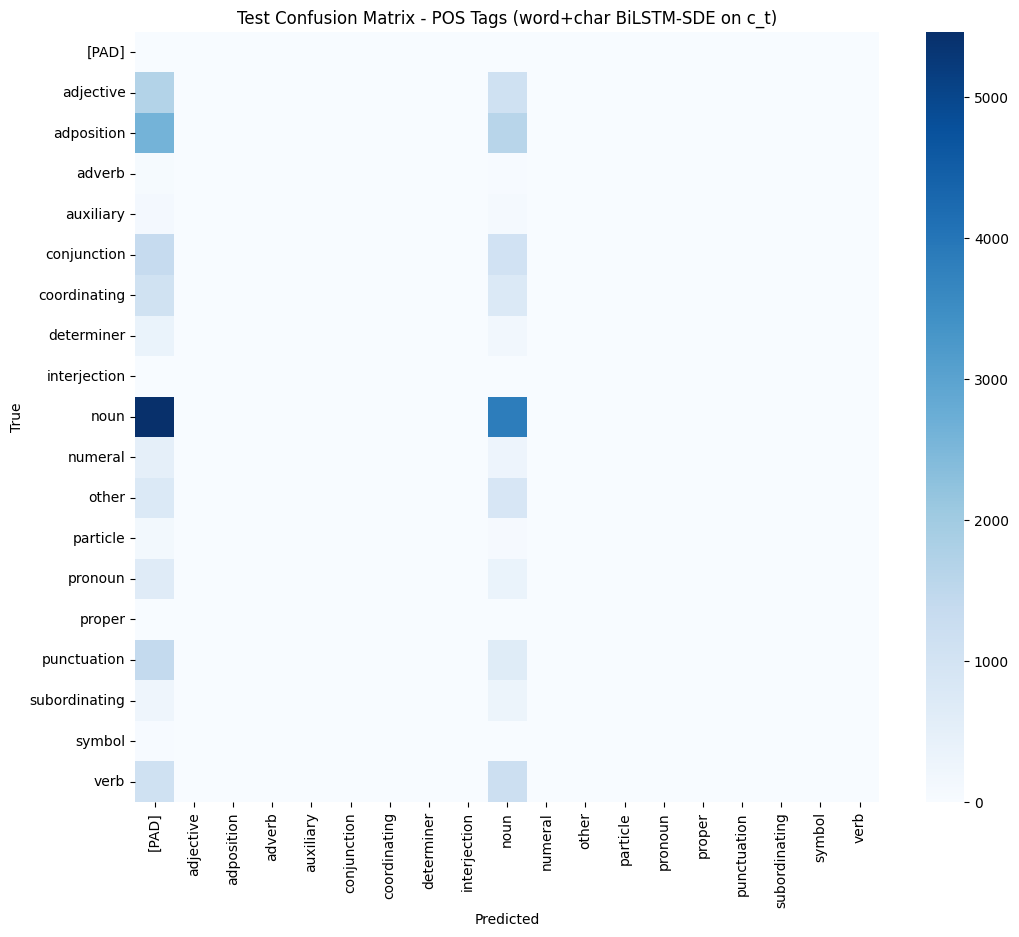

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

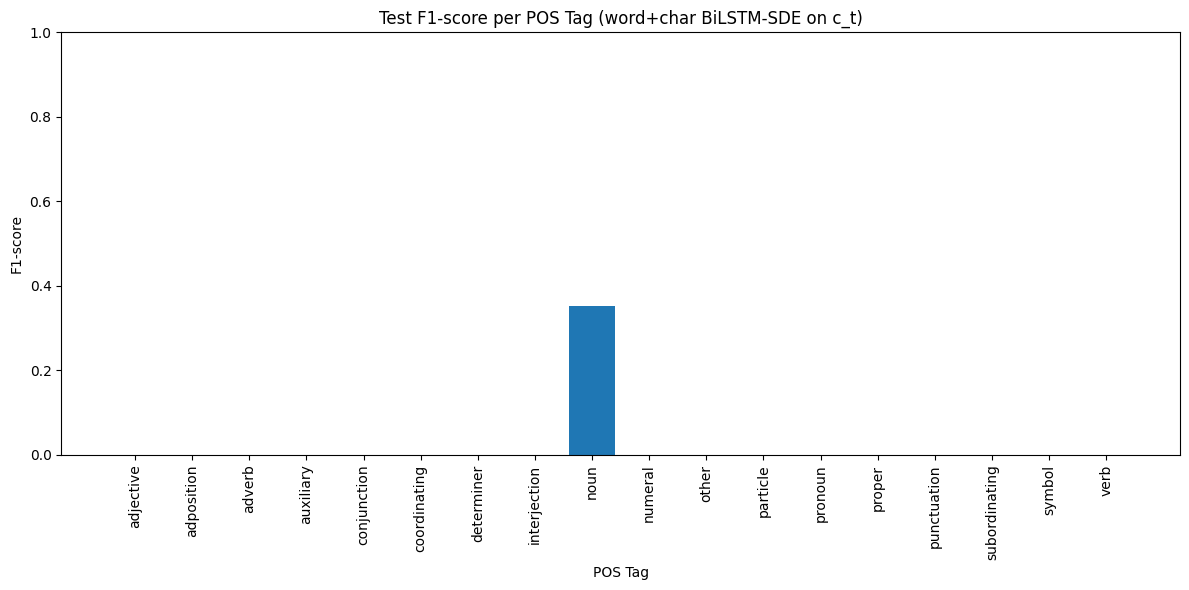

Test Sequence-level accuracy: 0.0


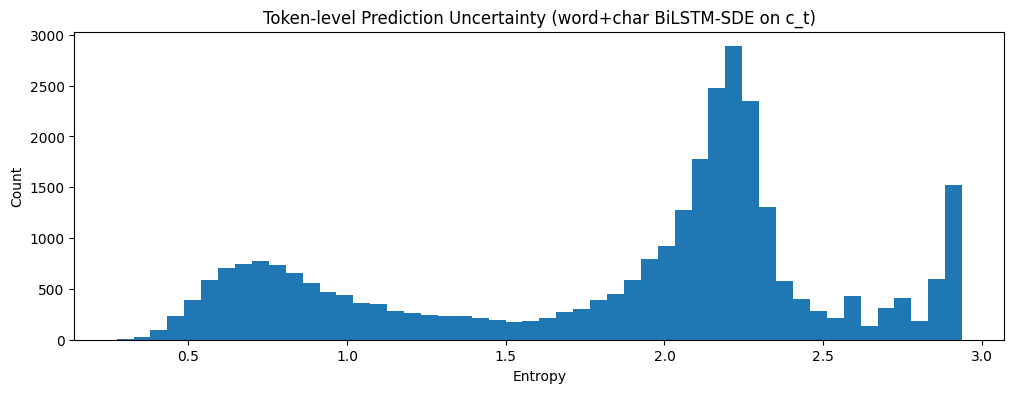

BLEU score (corpus-level): 3.17

Sample 1:
Words:  ['ف', 'قد', 'بلغت', 'جملة', 'صادرات', 'ها', 'حوالي', '2', 'مليار', 'و', '870', 'مليون', 'دولار', '،', 'من', 'ها', '843', 'مليون', 'دولار', 'إلى', 'السوق', 'الملحي', '،', 'و', 'الباقي', 'إلى', 'الأسواق', 'الخارجية', 'ب', 'نسبة', '14', 'عن', 'عام', '2002', '،', 'ل', 'تبلغ', '2', 'مليار', 'و', '28', 'مليون', 'دولار', '،', 'كما', 'ارتفعت', 'واردات', 'المناطق', 'الحرة', 'من', 'دول', 'العالم', 'ـ', 'ب', 'دون', 'مصر', 'ـ', 'ب', 'نسبة', '30', 'ل', 'تصل', 'إلى', 'مليار', 'و', '854', 'مليون', 'دولار', '،', 'مما', 'أدى', 'إلى', 'انخفاض', 'الفائض', 'التجاري', 'ل', 'هٰذه', 'المناطق', 'مع', 'باقي', 'دول', 'العالم', 'ب', 'نحو', '50', 'إلى', '174', 'مليون', 'دولار', 'مقابل', '350', 'مليون', 'دولار', '،', 'في', 'حين', 'انخفضت', 'واردات', 'هذه', 'المناطق']
Gold tags:   ['coordinating', 'conjunction', 'auxiliary', 'verb', 'verb', 'noun', 'noun', 'pronoun', 'adposition', 'numeral', 'other', 'coordinating', 'conjunction', 'numeral', 'numeral', 'noun', 'pun

In [7]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import pickle
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, Dense, Dropout, TimeDistributed,
    GlobalMaxPooling1D, Concatenate, RNN
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from tensorflow.keras.optimizers import Adam

# ========= USER CONFIG ========= #
data_size   = None
max_epochs  = 40
batch_size  = 128
random_state = 42

excel_path = "/kaggle/input/fulltag/padt_pos_4cols_fulltags.xlsx"
pkl_path   = "/kaggle/working/preprocessed_pos_data_padt_word_char_lstm_sde.pkl"

MAX_LEN        = 100   # max words per sentence
MAX_WORD_LEN   = 15    # max chars per word
WORD_EMB_DIM   = 128
CHAR_EMB_DIM   = 50
LSTM_UNITS     = 128
NOISE_STD      = 0.5   # try 0.0, 0.4, 0.8, 1.0
# =============================== #

# ========== DATA PREPROCESS (CACHED) ========== #
if os.path.exists(pkl_path):
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    X_words = data["X_words"]
    X_chars = data["X_chars"]
    y = data["y"]
    sentences = data["sentences"]
    tag_tokenizer = data["tag_tokenizer"]
    word_tokenizer = data["word_tokenizer"]
    char_tokenizer = data["char_tokenizer"]
    print("Loaded preprocessed WORD+CHAR data from pickle.")
else:
    df = pd.read_excel(excel_path)

    sent_cols = ["train_sentence", "dev_sentence", "test_sentence"]
    pos_cols  = ["train_pos_seq",  "dev_pos_seq",  "test_pos_seq"]

    all_sentences, all_tags_seq = [], []
    for s_col, p_col in zip(sent_cols, pos_cols):
        s = df[s_col].fillna("").astype(str).values
        p = df[p_col].fillna("").astype(str).values
        for sent, tags in zip(s, p):
            if sent.strip() == "" or tags.strip() == "":
                continue
            all_sentences.append(sent)
            all_tags_seq.append(tags)

    sentences = np.array(all_sentences)
    tags_seq  = np.array(all_tags_seq)

    if data_size is not None and data_size <= len(sentences):
        sentences = sentences[:data_size]
        tags_seq  = tags_seq[:data_size]

    print("Total sentences:", len(sentences))

    # ---------- 1) WORD tokenizer ----------
    word_tokenizer = Tokenizer(char_level=False, oov_token="[OOV]")
    word_tokenizer.fit_on_texts(sentences)
    word_seqs = word_tokenizer.texts_to_sequences(sentences)
    X_words = pad_sequences(word_seqs, maxlen=MAX_LEN, padding="post", truncating="post")

    # ---------- 2) CHAR tokenizer ----------
    all_words_for_chars = []
    for sent in sentences:
        all_words_for_chars.extend(sent.split())

    char_tokenizer = Tokenizer(char_level=True, oov_token="[OOV_CH]")
    char_tokenizer.fit_on_texts(all_words_for_chars)

    def sentence_to_char_ids(sent):
        words = sent.split()
        words = words[:MAX_LEN] + [""] * max(0, MAX_LEN - len(words))
        char_ids = []
        for w in words:
            chars = list(w)
            ch_seq = char_tokenizer.texts_to_sequences(["".join(chars)])[0]
            ch_seq = ch_seq[:MAX_WORD_LEN]
            ch_seq = ch_seq + [0] * max(0, MAX_WORD_LEN - len(ch_seq))
            char_ids.append(ch_seq)
        return np.array(char_ids, dtype="int32")

    X_chars = np.stack([sentence_to_char_ids(s) for s in sentences])  # (N, max_len, max_word_len)

    # ---------- 3) Tag tokenizer ----------
    tag_tokenizer = Tokenizer()
    tag_tokenizer.fit_on_texts(tags_seq)
    y_seqs = tag_tokenizer.texts_to_sequences(tags_seq)
    y = pad_sequences(y_seqs, maxlen=MAX_LEN, padding="post", truncating="post")

    with open(pkl_path, "wb") as f:
        pickle.dump({
            "X_words": X_words,
            "X_chars": X_chars,
            "y": y,
            "sentences": sentences,
            "tag_tokenizer": tag_tokenizer,
            "word_tokenizer": word_tokenizer,
            "char_tokenizer": char_tokenizer
        }, f)
    print("Saved preprocessed WORD+CHAR data to pickle.")

# ====== SHAPES ====== #
vocab_size_words = len(word_tokenizer.word_index) + 1
vocab_size_chars = len(char_tokenizer.word_index) + 1
tag_count        = len(tag_tokenizer.word_index) + 1
max_len          = X_words.shape[1]
max_word_len     = X_chars.shape[2]

print("vocab_size_words:", vocab_size_words)
print("vocab_size_chars:", vocab_size_chars)
print("tag_count       :", tag_count)
print("max_len(words)  :", max_len)
print("max_word_len    :", max_word_len)

# ====== SPLIT ====== #
Xw_trainval, Xw_test, Xc_trainval, Xc_test, y_trainval, y_test = train_test_split(
    X_words, X_chars, y, test_size=0.1, random_state=random_state
)
Xw_train, Xw_val, Xc_train, Xc_val, y_train, y_val = train_test_split(
    Xw_trainval, Xc_trainval, y_trainval, test_size=0.1111, random_state=random_state
)
print("Train words:", Xw_train.shape, "chars:", Xc_train.shape, "y:", y_train.shape)
print("Val   words:", Xw_val.shape, "chars:", Xc_val.shape, "y:", y_val.shape)
print("Test  words:", Xw_test.shape, "chars:", Xc_test.shape, "y:", y_test.shape)

# ====== LSTM-SDE CELL WITH NOISE ON c_t ====== #
class LSTMSDECellC(tf.keras.layers.Layer):
    def __init__(self, units, noise_std=1.0, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        # states: [h, c]
        self.state_size = [units, units]
        self.output_size = units
        self.noise_std = noise_std

    def build(self, input_shape):
        input_dim = input_shape[-1]

        self.W_x = self.add_weight(
            shape=(input_dim, 4 * self.units),
            initializer="glorot_uniform",
            name="W_x_c",
        )
        self.W_h = self.add_weight(
            shape=(self.units, 4 * self.units),
            initializer="orthogonal",
            name="W_h_c",
        )
        self.b = self.add_weight(
            shape=(4 * self.units,),
            initializer="zeros",
            name="b_c",
        )

        # drift and diffusion for c_t
        self.drift_dense_c = Dense(self.units, name="drift_dense_c")
        self.diff_dense_c = Dense(self.units, name="diff_dense_c")

        super().build(input_shape)

    def call(self, inputs, states, training=None):
        h_tm1, c_tm1 = states  # (batch, units)

        # standard LSTM affine transform
        z = tf.matmul(inputs, self.W_x) + tf.matmul(h_tm1, self.W_h) + self.b
        zi, zf, zc, zo = tf.split(z, num_or_size_splits=4, axis=-1)

        i = tf.sigmoid(zi)
        f = tf.sigmoid(zf)
        o = tf.sigmoid(zo)
        c_hat = tf.tanh(zc)

        # standard LSTM cell state
        c_t = f * c_tm1 + i * c_hat

        # SDE term on c_t
        dt = 1.0
        drift_c = self.drift_dense_c(c_t)
        diffusion_c = self.diff_dense_c(c_t)
        noise_c = tf.random.normal(tf.shape(c_t), mean=0.0, stddev=self.noise_std)

        c_t_sde = c_t + drift_c * dt + diffusion_c * noise_c * tf.sqrt(dt)

        # hidden state from noisy cell state
        h_t = o * tf.tanh(c_t_sde)

        return h_t, [h_t, c_t_sde]

# ====== MODEL: word+char -> BiLSTM-SDE(c_t) -> TimeDistributed ====== #
word_inputs = Input(shape=(max_len,), name="word_input")
word_emb = Embedding(vocab_size_words, WORD_EMB_DIM,
                     mask_zero=False, name="word_embedding")(word_inputs)

char_inputs = Input(shape=(max_len, max_word_len), name="char_input")
char_emb_layer = Embedding(vocab_size_chars, CHAR_EMB_DIM,
                           mask_zero=False, name="char_embedding")
char_emb = TimeDistributed(char_emb_layer, name="td_char_emb")(char_inputs)

char_cnn = TimeDistributed(
    Conv1D(filters=50, kernel_size=3, padding="same", activation="relu"),
    name="td_char_cnn"
)(char_emb)
char_pool = TimeDistributed(GlobalMaxPooling1D(), name="td_char_pool")(char_cnn)

merged = Concatenate(axis=-1, name="word_char_concat")([word_emb, char_pool])

# Bi-directional LSTM-SDE on c_t
lstm_sde_f = RNN(LSTMSDECellC(LSTM_UNITS, noise_std=NOISE_STD),
                 return_sequences=True,
                 go_backwards=False,
                 name="lstm_sde_f")(merged)

lstm_sde_b = RNN(LSTMSDECellC(LSTM_UNITS, noise_std=NOISE_STD),
                 return_sequences=True,
                 go_backwards=True,
                 name="lstm_sde_b")(merged)

bilstm_sde = Concatenate(axis=-1, name="bilstm_sde")([lstm_sde_f, lstm_sde_b])

logits = TimeDistributed(Dense(tag_count, activation="softmax"),
                         name="tag_output")(bilstm_sde)

model = Model(inputs=[word_inputs, char_inputs], outputs=logits)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

# ====== TRAIN ====== #
y_train_targets = np.expand_dims(y_train, -1)
y_val_targets   = np.expand_dims(y_val, -1)

early = EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
checkpoint = ModelCheckpoint("/kaggle/working/best_word_char_bilstm_sde_cell_ct_pos.keras",
                             monitor="val_loss", save_best_only=True)

history = model.fit(
    [Xw_train, Xc_train], y_train_targets,
    batch_size=batch_size,
    epochs=max_epochs,
    validation_data=([Xw_val, Xc_val], y_val_targets),
    callbacks=[early, checkpoint]
)

# ====== EVALUATION ====== #
y_probs = model.predict([Xw_test, Xc_test])
y_pred = np.argmax(y_probs, axis=-1)
y_true = y_test

y_true = np.squeeze(y_true)
y_pred = np.squeeze(y_pred)

mask = (y_true != 0)
y_true_flat = y_true[mask]
y_pred_flat = y_pred[mask]

idx2tag = {v: k for k, v in tag_tokenizer.word_index.items()}
idx2tag[0] = '[PAD]'
y_true_tags = [idx2tag[idx] for idx in y_true_flat]
y_pred_tags = [idx2tag[idx] for idx in y_pred_flat]

print("\nTest Classification Report:")
with open("/kaggle/working/test_classification_report_word_char_bilstm_sde_cell_ct.txt",
          "w", encoding="utf-8") as f:
    f.write(classification_report(y_true_tags, y_pred_tags))
print(classification_report(y_true_tags, y_pred_tags))

labels = np.unique(y_true_tags + y_pred_tags)
cm = confusion_matrix(y_true_tags, y_pred_tags, labels=labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix - POS Tags (word+char BiLSTM-SDE on c_t)")
plt.savefig("/kaggle/working/Test_Confusion_Matrix_word_char_BiLSTM_SDE_ct.png")
plt.show()

report = classification_report(y_true_tags, y_pred_tags, output_dict=True)
f1s = [report[tag]["f1-score"] for tag in labels if tag != "[PAD]"]
plt.figure(figsize=(12, 6))
plt.bar(labels[1:], f1s)
plt.title("Test F1-score per POS Tag (word+char BiLSTM-SDE on c_t)")
plt.xlabel("POS Tag")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("/kaggle/working/Test_F1-score_word_char_BiLSTM_SDE_ct.png")
plt.show()

sequence_correct = (y_true == y_pred).all(axis=1)
print("Test Sequence-level accuracy:", sequence_correct.mean())

def compute_entropy(prob_vec):
    prob_vec = np.clip(prob_vec, 1e-12, 1 - 1e-12)
    return -np.sum(prob_vec * np.log(prob_vec), axis=-1)

entropies = compute_entropy(y_probs)
plt.figure(figsize=(12, 4))
plt.hist(entropies[mask], bins=50)
plt.title("Token-level Prediction Uncertainty (word+char BiLSTM-SDE on c_t)")
plt.xlabel("Entropy")
plt.ylabel("Count")
plt.savefig("/kaggle/working/Test_Token-level_Prediction_Uncertainty_word_char_BiLSTM_SDE_ct.png")
plt.show()

# --- BLEU Evaluation ---
bleu_hyps, bleu_refs = [], []
for i in range(y_true.shape[0]):
    ref_seq = [idx2tag[tag] for tag in y_true[i] if tag != 0]
    hyp_seq = [idx2tag[tag] for tag in y_pred[i] if tag != 0]
    if ref_seq and hyp_seq:
        bleu_refs.append([ref_seq])
        bleu_hyps.append(hyp_seq)
bleu = corpus_bleu(bleu_refs, bleu_hyps, smoothing_function=SmoothingFunction().method4)
print(f"BLEU score (corpus-level): {bleu*100:.2f}")

# --- Sample Print ---
n_samples = 5
idx2word = {v: k for k, v in word_tokenizer.word_index.items()}
idx2word[0] = "[PAD]"

for i in range(n_samples):
    idx = np.random.randint(len(Xw_test))
    words = [idx2word[w] for w in Xw_test[idx] if w != 0]
    true_seq = [idx2tag[tag] for tag in y_true[idx] if tag != 0]
    pred_seq = [idx2tag[tag] for tag in y_pred[idx] if tag != 0]
    print(f"\nSample {i+1}:")
    print("Words: ", words)
    print("Gold tags:  ", true_seq)
    print("Predicted:  ", pred_seq)
    print("-" * 40)


Loaded preprocessed WORD+CHAR data from pickle.
vocab_size_words: 24655
vocab_size_chars: 107
tag_count       : 19
max_len(words)  : 100
max_word_len    : 15
Train words: (6130, 100) chars: (6130, 100, 15) y: (6130, 100)
Val   words: (767, 100) chars: (767, 100, 15) y: (767, 100)
Test  words: (767, 100) chars: (767, 100, 15) y: (767, 100)


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ char_input          │ (None, 100, 15)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_emb         │ (None, 100, 15,   │      5,350 │ char_input[0][0]  │
│ (TimeDistributed)   │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_input          │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_cnn         │ (None, 100, 15,   │      7,550 │ td_char_emb[0][0] │
│ (TimeDistributed)   │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 100, 128)  │  3,155,840 │ word_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_pool        │ (None, 100, 50)   │          0 │ td_char_cnn[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_char_concat    │ (None, 100, 178)  │          0 │ word_embedding[0… │
│ (Concatenate)       │                   │            │ td_char_pool[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_sde_f (RNN)    │ (None, 100, 128)  │    157,184 │ word_char_concat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_sde_b (RNN)    │ (None, 100, 128)  │    157,184 │ word_char_concat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_sde          │ (None, 100, 256)  │          0 │ lstm_sde_f[0][0], │
│ (Concatenate)       │                   │            │ lstm_sde_b[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tag_output          │ (None, 100, 19)   │      4,883 │ bilstm_sde[0][0]  │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,487,991 (13.31 MB)

 Trainable params: 3,487,991 (13.31 MB)

...

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - accuracy: 0.3871 - loss: 2.2086 - val_accuracy: 0.6259 - val_loss: 1.5273
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.6280 - loss: 1.5118 - val_accuracy: 0.6402 - val_loss: 1.4133
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.6309 - loss: 1.4446 - val_accuracy: 0.6417 - val_loss: 1.3963
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.6350 - loss: 1.4117 - val_accuracy: 0.6411 - val_loss: 1.3798
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.6344 - loss: 1.4027 - val_accuracy: 0.6422 - val_loss: 1.3732
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.6310 - loss: 1.4293 - val_accuracy: 0.6325 - val_loss: 1.4185
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.6270 - loss: 1.4440 - val_accuracy: 0.6373 - val_loss: 1.3779
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.5950 - loss: 1.5412 - val_accuracy: 0.5

/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/model_checkpoint.py:264: RuntimeWarning: invalid value encountered in less
  if self.monitor_op(current, self.best):


48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 1.4952e-05 - loss: nan - val_accuracy: 1.3038e-05 - val_loss: nan
Epoch 45/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 1.0745e-05 - loss: nan - val_accuracy: 1.3038e-05 - val_loss: nan
Epoch 46/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 9.2391e-06 - loss: nan - val_accuracy: 1.3038e-05 - val_loss: nan
Epoch 47/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 1.0455e-05 - loss: nan - val_accuracy: 1.3038e-05 - val_loss: nan
Epoch 48/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 1.0393e-05 - loss: nan - val_accuracy: 1.3038e-05 - val_loss: nan
Epoch 49/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 4.9447e-06 - loss: nan - val_accuracy: 1.3038e-05 - val_loss: nan
Epoch 50/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 1.1965e-05 - loss: nan - val_accuracy: 1.3038e-05 - val_loss: nan
24/24 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step

Test Classification Report:


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

               precision    recall  f1-score   support

        [PAD]       0.00      0.00      0.00       0.0
    adjective       0.00      0.00      0.00    2823.0
   adposition       0.00      0.00      0.00    4218.0
       adverb       0.00      0.00      0.00      99.0
    auxiliary       0.00      0.00      0.00     204.0
  conjunction       0.00      0.00      0.00    2427.0
 coordinating       0.00      0.00      0.00    1873.0
   determiner       0.00      0.00      0.00     545.0
 interjection       0.00      0.00      0.00       1.0
         noun       0.00      0.00      0.00    9315.0
      numeral       0.00      0.00      0.00     807.0
        other       0.00      0.00      0.00    1666.0
     particle       0.00      0.00      0.00     216.0
      pronoun       0.00      0.00      0.00    1043.0
       proper       0.00      0.00      0.00      29.0
  punctuation       0.00      0.00      0.00    2057.0
subordinating       0.00      0.00      0.00     557.0
       sy

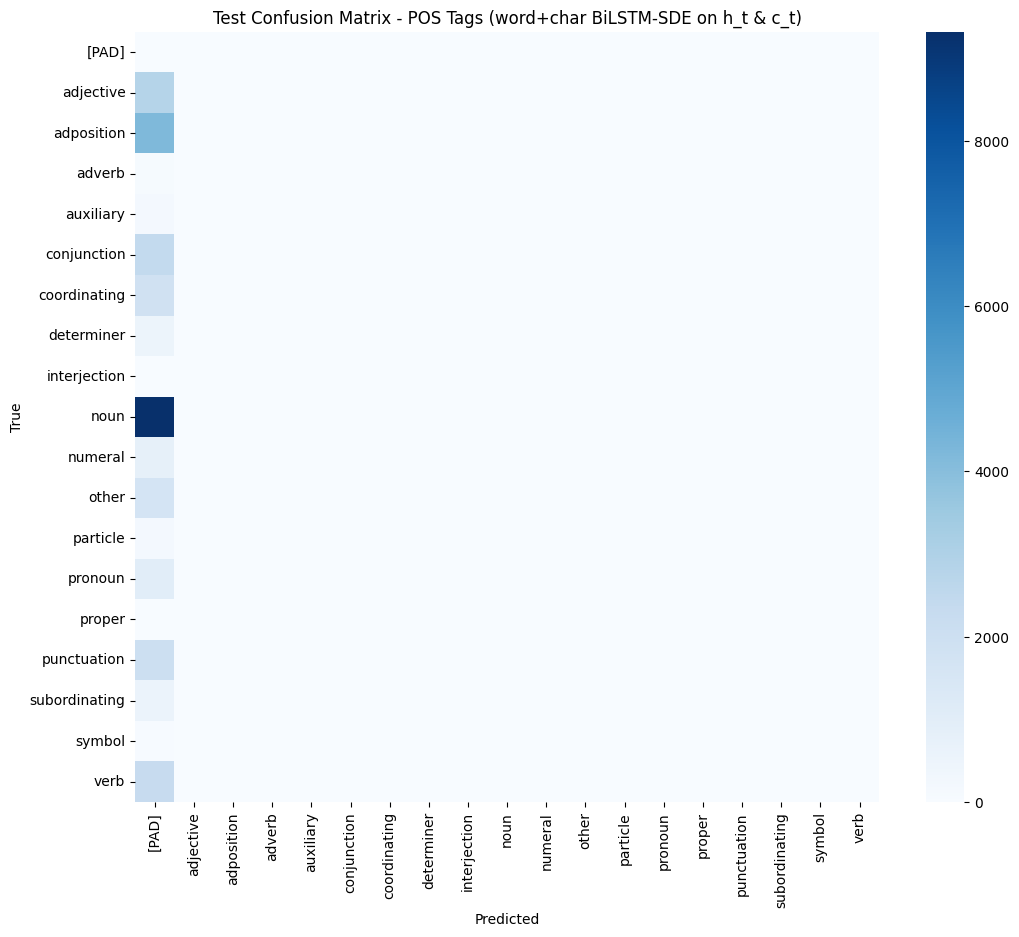

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

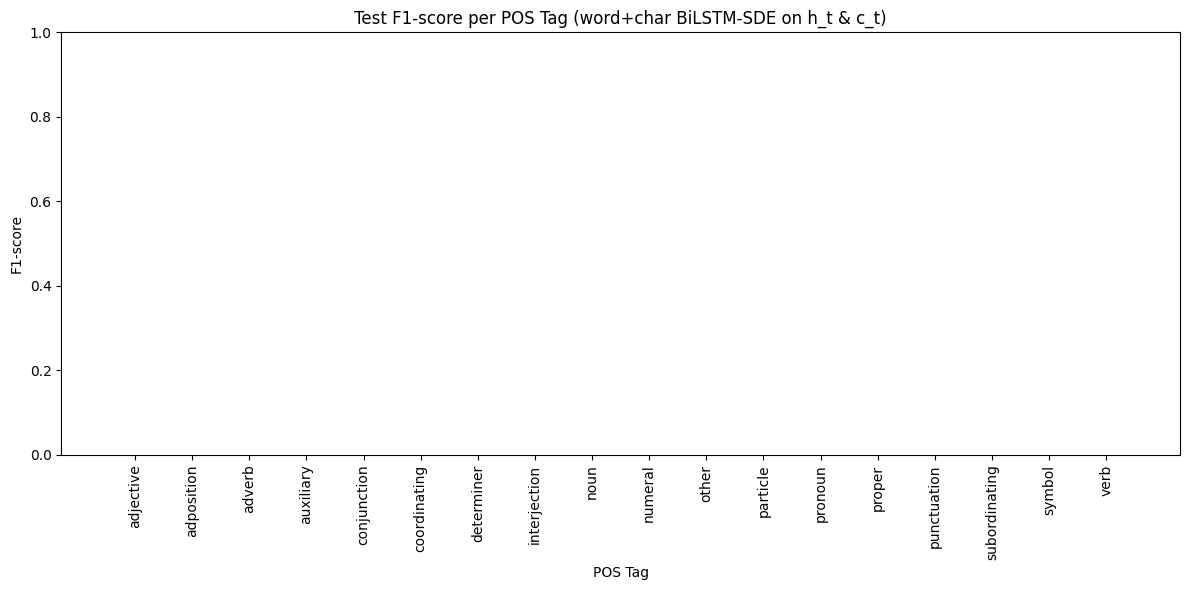

Test Sequence-level accuracy: 0.0


/usr/local/lib/python3.11/dist-packages/matplotlib/axes/_axes.py:6763: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/usr/local/lib/python3.11/dist-packages/matplotlib/axes/_axes.py:6763: RuntimeWarning: invalid value encountered in less
  xmin = min(xmin, np.nanmin(xi))
/usr/local/lib/python3.11/dist-packages/matplotlib/axes/_axes.py:6764: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))
/usr/local/lib/python3.11/dist-packages/matplotlib/axes/_axes.py:6764: RuntimeWarning: invalid value encountered in greater
  xmax = max(xmax, np.nanmax(xi))


ValueError: autodetected range of [nan, nan] is not finite

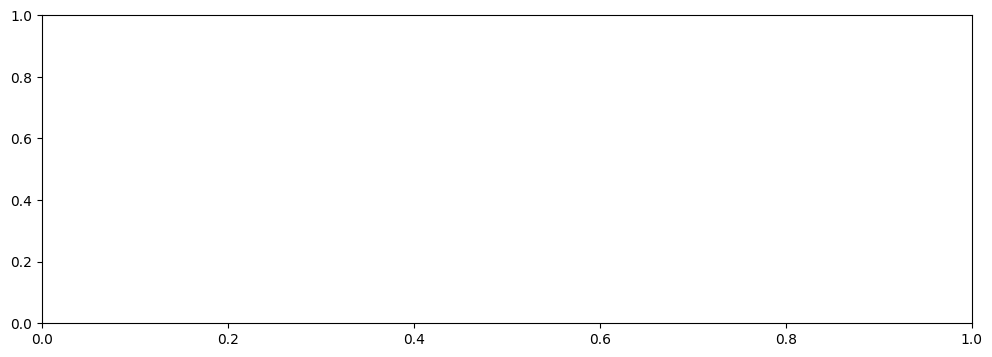

In [11]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import pickle
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, Dense, Dropout, TimeDistributed,
    GlobalMaxPooling1D, Concatenate, RNN
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from tensorflow.keras.optimizers import Adam

# ========= إعدادات المستخدم ========= #
data_size   = None
max_epochs  = 40
batch_size  = 128
random_state = 42

excel_path = "/kaggle/input/fulltag/padt_pos_4cols_fulltags.xlsx"
pkl_path   = "/kaggle/working/preprocessed_pos_data_padt_word_char_lstm_sde.pkl"

MAX_LEN        = 100   # أقصى عدد كلمات في الجملة
MAX_WORD_LEN   = 15    # أقصى عدد حروف في الكلمة
WORD_EMB_DIM   = 128
CHAR_EMB_DIM   = 50
LSTM_UNITS     = 128
NOISE_STD      = 0.5   # جرّب 0.0, 0.4, 0.8, 1.0
# =============================== #

# ========== المعالجة المسبقة (مع كاش) ========== #
if os.path.exists(pkl_path):
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    X_words = data["X_words"]
    X_chars = data["X_chars"]
    y = data["y"]
    sentences = data["sentences"]
    tag_tokenizer = data["tag_tokenizer"]
    word_tokenizer = data["word_tokenizer"]
    char_tokenizer = data["char_tokenizer"]
    print("Loaded preprocessed WORD+CHAR data from pickle.")
else:
    df = pd.read_excel(excel_path)

    sent_cols = ["train_sentence", "dev_sentence", "test_sentence"]
    pos_cols  = ["train_pos_seq",  "dev_pos_seq",  "test_pos_seq"]

    all_sentences, all_tags_seq = [], []
    for s_col, p_col in zip(sent_cols, pos_cols):
        s = df[s_col].fillna("").astype(str).values
        p = df[p_col].fillna("").astype(str).values
        for sent, tags in zip(s, p):
            if sent.strip() == "" or tags.strip() == "":
                continue
            all_sentences.append(sent)
            all_tags_seq.append(tags)

    sentences = np.array(all_sentences)
    tags_seq  = np.array(all_tags_seq)

    if data_size is not None and data_size <= len(sentences):
        sentences = sentences[:data_size]
        tags_seq  = tags_seq[:data_size]

    print("Total sentences:", len(sentences))

    # ---------- 1) توكنايزر الكلمات ----------
    word_tokenizer = Tokenizer(char_level=False, oov_token="[OOV]")
    word_tokenizer.fit_on_texts(sentences)
    word_seqs = word_tokenizer.texts_to_sequences(sentences)
    X_words = pad_sequences(word_seqs, maxlen=MAX_LEN, padding="post", truncating="post")

    # ---------- 2) توكنايزر الحروف ----------
    all_words_for_chars = []
    for sent in sentences:
        all_words_for_chars.extend(sent.split())

    char_tokenizer = Tokenizer(char_level=True, oov_token="[OOV_CH]")
    char_tokenizer.fit_on_texts(all_words_for_chars)

    def sentence_to_char_ids(sent):
        words = sent.split()
        # قص أو إكمال إلى MAX_LEN
        words = words[:MAX_LEN] + [""] * max(0, MAX_LEN - len(words))
        char_ids = []
        for w in words:
            chars = list(w)
            ch_seq = char_tokenizer.texts_to_sequences(["".join(chars)])[0]
            ch_seq = ch_seq[:MAX_WORD_LEN]
            ch_seq = ch_seq + [0] * max(0, MAX_WORD_LEN - len(ch_seq))
            char_ids.append(ch_seq)
        return np.array(char_ids, dtype="int32")

    X_chars = np.stack([sentence_to_char_ids(s) for s in sentences])  # (N, max_len, max_word_len)

    # ---------- 3) توكنايزر الوسوم (POS tags) ----------
    tag_tokenizer = Tokenizer()
    tag_tokenizer.fit_on_texts(tags_seq)
    y_seqs = tag_tokenizer.texts_to_sequences(tags_seq)
    y = pad_sequences(y_seqs, maxlen=MAX_LEN, padding="post", truncating="post")

    with open(pkl_path, "wb") as f:
        pickle.dump({
            "X_words": X_words,
            "X_chars": X_chars,
            "y": y,
            "sentences": sentences,
            "tag_tokenizer": tag_tokenizer,
            "word_tokenizer": word_tokenizer,
            "char_tokenizer": char_tokenizer
        }, f)
    print("Saved preprocessed WORD+CHAR data to pickle.")

# ====== الأشكال ====== #
vocab_size_words = len(word_tokenizer.word_index) + 1
vocab_size_chars = len(char_tokenizer.word_index) + 1
tag_count        = len(tag_tokenizer.word_index) + 1
max_len          = X_words.shape[1]
max_word_len     = X_chars.shape[2]

print("vocab_size_words:", vocab_size_words)
print("vocab_size_chars:", vocab_size_chars)
print("tag_count       :", tag_count)
print("max_len(words)  :", max_len)
print("max_word_len    :", max_word_len)

# ====== التقسيم Train/Val/Test ====== #
Xw_trainval, Xw_test, Xc_trainval, Xc_test, y_trainval, y_test = train_test_split(
    X_words, X_chars, y, test_size=0.1, random_state=random_state
)
Xw_train, Xw_val, Xc_train, Xc_val, y_train, y_val = train_test_split(
    Xw_trainval, Xc_trainval, y_trainval, test_size=0.1111, random_state=random_state
)
print("Train words:", Xw_train.shape, "chars:", Xc_train.shape, "y:", y_train.shape)
print("Val   words:", Xw_val.shape, "chars:", Xc_val.shape, "y:", y_val.shape)
print("Test  words:", Xw_test.shape, "chars:", Xc_test.shape, "y:", y_test.shape)

# ====== خلية LSTM-SDE مع ضوضاء على c_t و h_t معًا ====== #
class LSTMSDECellHC(tf.keras.layers.Layer):
    def __init__(self, units, noise_std=1.0, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        # حالتا الحالة: [h, c]
        self.state_size = [units, units]
        self.output_size = units
        self.noise_std = noise_std

    def build(self, input_shape):
        input_dim = input_shape[-1]

        self.W_x = self.add_weight(
            shape=(input_dim, 4 * self.units),
            initializer="glorot_uniform",
            name="W_x_hc",
        )
        self.W_h = self.add_weight(
            shape=(self.units, 4 * self.units),
            initializer="orthogonal",
            name="W_h_hc",
        )
        self.b = self.add_weight(
            shape=(4 * self.units,),
            initializer="zeros",
            name="b_hc",
        )

        # شبكات drift و diffusion لـ c_t
        self.drift_dense_c = Dense(self.units, name="drift_dense_c")
        self.diff_dense_c = Dense(self.units, name="diff_dense_c")

        # شبكات drift و diffusion لـ h_t
        self.drift_dense_h = Dense(self.units, name="drift_dense_h")
        self.diff_dense_h = Dense(self.units, name="diff_dense_h")

        super().build(input_shape)

    def call(self, inputs, states, training=None):
        h_tm1, c_tm1 = states  # (batch, units)

        # إسقاط LSTM القياسي
        z = tf.matmul(inputs, self.W_x) + tf.matmul(h_tm1, self.W_h) + self.b
        zi, zf, zc, zo = tf.split(z, num_or_size_splits=4, axis=-1)

        i = tf.sigmoid(zi)
        f = tf.sigmoid(zf)
        o = tf.sigmoid(zo)
        c_hat = tf.tanh(zc)

        # تحديث حالة الخلية القياسية
        c_t = f * c_tm1 + i * c_hat

        # ---- SDE على c_t ----
        dt = 1.0
        drift_c = self.drift_dense_c(c_t)
        diffusion_c = self.diff_dense_c(c_t)
        noise_c = tf.random.normal(tf.shape(c_t), mean=0.0, stddev=self.noise_std)

        c_t_sde = c_t + drift_c * dt + diffusion_c * noise_c * tf.sqrt(dt)

        # حساب h_t من c_t_sde
        h_t = o * tf.tanh(c_t_sde)

        # ---- SDE على h_t ----
        drift_h = self.drift_dense_h(h_t)
        diffusion_h = self.diff_dense_h(h_t)
        noise_h = tf.random.normal(tf.shape(h_t), mean=0.0, stddev=self.noise_std)

        h_t_sde = h_t + drift_h * dt + diffusion_h * noise_h * tf.sqrt(dt)

        return h_t_sde, [h_t_sde, c_t_sde]

# ====== النموذج: word+char -> BiLSTM-SDE(h,c) -> TimeDistributed ====== #
word_inputs = Input(shape=(max_len,), name="word_input")
word_emb = Embedding(vocab_size_words, WORD_EMB_DIM,
                     mask_zero=False, name="word_embedding")(word_inputs)

char_inputs = Input(shape=(max_len, max_word_len), name="char_input")
char_emb_layer = Embedding(vocab_size_chars, CHAR_EMB_DIM,
                           mask_zero=False, name="char_embedding")
char_emb = TimeDistributed(char_emb_layer, name="td_char_emb")(char_inputs)

char_cnn = TimeDistributed(
    Conv1D(filters=50, kernel_size=3, padding="same", activation="relu"),
    name="td_char_cnn"
)(char_emb)
char_pool = TimeDistributed(GlobalMaxPooling1D(), name="td_char_pool")(char_cnn)

merged = Concatenate(axis=-1, name="word_char_concat")([word_emb, char_pool])

# BiLSTM-SDE باتجاهين مع الخلية الجديدة
lstm_sde_f = RNN(LSTMSDECellHC(LSTM_UNITS, noise_std=NOISE_STD),
                 return_sequences=True,
                 go_backwards=False,
                 name="lstm_sde_f")(merged)

lstm_sde_b = RNN(LSTMSDECellHC(LSTM_UNITS, noise_std=NOISE_STD),
                 return_sequences=True,
                 go_backwards=True,
                 name="lstm_sde_b")(merged)

bilstm_sde = Concatenate(axis=-1, name="bilstm_sde")([lstm_sde_f, lstm_sde_b])

logits = TimeDistributed(Dense(tag_count, activation="softmax"),
                         name="tag_output")(bilstm_sde)

model = Model(inputs=[word_inputs, char_inputs], outputs=logits)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

# ====== التدريب ====== #
y_train_targets = np.expand_dims(y_train, -1)
y_val_targets   = np.expand_dims(y_val, -1)

early = EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
checkpoint = ModelCheckpoint("/kaggle/working/best_word_char_bilstm_sde_cell_hc_pos.keras",
                             monitor="val_loss", save_best_only=True)

history = model.fit(
    [Xw_train, Xc_train], y_train_targets,
    batch_size=batch_size,
    epochs=max_epochs,
    validation_data=([Xw_val, Xc_val], y_val_targets),
    callbacks=[early, checkpoint]
)

# ====== التقييم ====== #
y_probs = model.predict([Xw_test, Xc_test])
y_pred = np.argmax(y_probs, axis=-1)
y_true = y_test

y_true = np.squeeze(y_true)
y_pred = np.squeeze(y_pred)

mask = (y_true != 0)
y_true_flat = y_true[mask]
y_pred_flat = y_pred[mask]

idx2tag = {v: k for k, v in tag_tokenizer.word_index.items()}
idx2tag[0] = '[PAD]'
y_true_tags = [idx2tag[idx] for idx in y_true_flat]
y_pred_tags = [idx2tag[idx] for idx in y_pred_flat]

print("\nTest Classification Report:")
with open("/kaggle/working/test_classification_report_word_char_bilstm_sde_cell_hc.txt",
          "w", encoding="utf-8") as f:
    f.write(classification_report(y_true_tags, y_pred_tags))
print(classification_report(y_true_tags, y_pred_tags))

labels = np.unique(y_true_tags + y_pred_tags)
cm = confusion_matrix(y_true_tags, y_pred_tags, labels=labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix - POS Tags (word+char BiLSTM-SDE on h_t & c_t)")
plt.savefig("/kaggle/working/Test_Confusion_Matrix_word_char_BiLSTM_SDE_hc.png")
plt.show()

report = classification_report(y_true_tags, y_pred_tags, output_dict=True)
f1s = [report[tag]["f1-score"] for tag in labels if tag != "[PAD]"]
plt.figure(figsize=(12, 6))
plt.bar(labels[1:], f1s)
plt.title("Test F1-score per POS Tag (word+char BiLSTM-SDE on h_t & c_t)")
plt.xlabel("POS Tag")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("/kaggle/working/Test_F1-score_word_char_BiLSTM_SDE_hc.png")
plt.show()

sequence_correct = (y_true == y_pred).all(axis=1)
print("Test Sequence-level accuracy:", sequence_correct.mean())

def compute_entropy(prob_vec):
    prob_vec = np.clip(prob_vec, 1e-12, 1 - 1e-12)
    return -np.sum(prob_vec * np.log(prob_vec), axis=-1)

entropies = compute_entropy(y_probs)
plt.figure(figsize=(12, 4))
plt.hist(entropies[mask], bins=50)
plt.title("Token-level Prediction Uncertainty (word+char BiLSTM-SDE on h_t & c_t)")
plt.xlabel("Entropy")
plt.ylabel("Count")
plt.savefig("/kaggle/working/Test_Token-level_Prediction_Uncertainty_word_char_BiLSTM_SDE_hc.png")
plt.show()

# --- تقييم BLEU ---
bleu_hyps, bleu_refs = [], []
for i in range(y_true.shape[0]):
    ref_seq = [idx2tag[tag] for tag in y_true[i] if tag != 0]
    hyp_seq = [idx2tag[tag] for tag in y_pred[i] if tag != 0]
    if ref_seq and hyp_seq:
        bleu_refs.append([ref_seq])
        bleu_hyps.append(hyp_seq)
bleu = corpus_bleu(bleu_refs, bleu_hyps, smoothing_function=SmoothingFunction().method4)
print(f"BLEU score (corpus-level): {bleu*100:.2f}")

# --- طباعة عينات ---
n_samples = 5
idx2word = {v: k for k, v in word_tokenizer.word_index.items()}
idx2word[0] = "[PAD]"

for i in range(n_samples):
    idx = np.random.randint(len(Xw_test))
    words = [idx2word[w] for w in Xw_test[idx] if w != 0]
    true_seq = [idx2tag[tag] for tag in y_true[idx] if tag != 0]
    pred_seq = [idx2tag[tag] for tag in y_pred[idx] if tag != 0]
    print(f"\nSample {i+1}:")
    print("Words: ", words)
    print("Gold tags:  ", true_seq)
    print("Predicted:  ", pred_seq)
    print("-" * 40)


Total sentences: 7664
Saved preprocessed WORD+CHAR data to pickle.
vocab_size_words: 24655
vocab_size_chars: 107
tag_count       : 19
max_len(words)  : 100
max_word_len    : 15
Train words: (6130, 100) chars: (6130, 100, 15) y: (6130, 100)
Val   words: (767, 100) chars: (767, 100, 15) y: (767, 100)
Test  words: (767, 100) chars: (767, 100, 15) y: (767, 100)


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ char_input          │ (None, 100, 15)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_emb         │ (None, 100, 15,   │      5,350 │ char_input[0][0]  │
│ (TimeDistributed)   │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_input          │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_cnn         │ (None, 100, 15,   │      7,550 │ td_char_emb[0][0] │
│ (TimeDistributed)   │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 100, 128)  │  3,155,840 │ word_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_pool        │ (None, 100, 50)   │          0 │ td_char_cnn[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_char_concat    │ (None, 100, 178)  │          0 │ word_embedding[0… │
│ (Concatenate)       │                   │            │ td_char_pool[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_sde_f_ar1      │ (None, 100, 128)  │    157,184 │ word_char_concat… │
│ (RNN)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_sde_b_ar1      │ (None, 100, 128)  │    157,184 │ word_char_concat… │
│ (RNN)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_sde_ar1      │ (None, 100, 256)  │          0 │ lstm_sde_f_ar1[0… │
│ (Concatenate)       │                   │            │ lstm_sde_b_ar1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tag_output          │ (None, 100, 19)   │      4,883 │ bilstm_sde_ar1[0… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,487,991 (13.31 MB)

 Trainable params: 3,487,991 (13.31 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.6227 - loss: 1.4052 - val_accuracy: 0.7301 - val_loss: 0.8707
Epoch 2/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.7299 - loss: 0.8670 - val_accuracy: 0.7467 - val_loss: 0.7697
Epoch 3/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.7412 - loss: 0.7776 - val_accuracy: 0.7629 - val_loss: 0.6808
Epoch 4/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.7635 - loss: 0.6833 - val_accuracy: 0.7846 - val_loss: 0.6146
Epoch 5/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.7841 - loss: 0.6127 - val_accuracy: 0.7986 - val_loss: 0.5745
Epoch 6/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.8001 - loss: 0.5628 - val_accuracy: 0.8120 - val_loss: 0.5307
Epoch 7/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.8182 - loss: 0.5137 - val_accuracy: 0.8268 - val_loss: 0.4916
Epoch 8/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.8345 - loss: 0.4663 - val_accuracy: 0.8313 - v

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

               precision    recall  f1-score   support

        [PAD]       0.00      0.00      0.00         0
    adjective       0.65      0.53      0.59      2823
   adposition       0.69      0.62      0.65      4218
       adverb       1.00      0.01      0.02        99
    auxiliary       0.73      0.42      0.53       204
  conjunction       0.64      0.72      0.68      2427
 coordinating       0.71      0.65      0.67      1873
   determiner       0.55      0.45      0.50       545
 interjection       0.00      0.00      0.00         1
         noun       0.64      0.77      0.70      9315
      numeral       0.63      0.56      0.59       807
        other       0.59      0.46      0.52      1666
     particle       0.54      0.29      0.38       216
      pronoun       0.57      0.52      0.54      1043
       proper       0.00      0.00      0.00        29
  punctuation       0.65      0.67      0.66      2057
subordinating       0.83      0.68      0.75       557
       sy

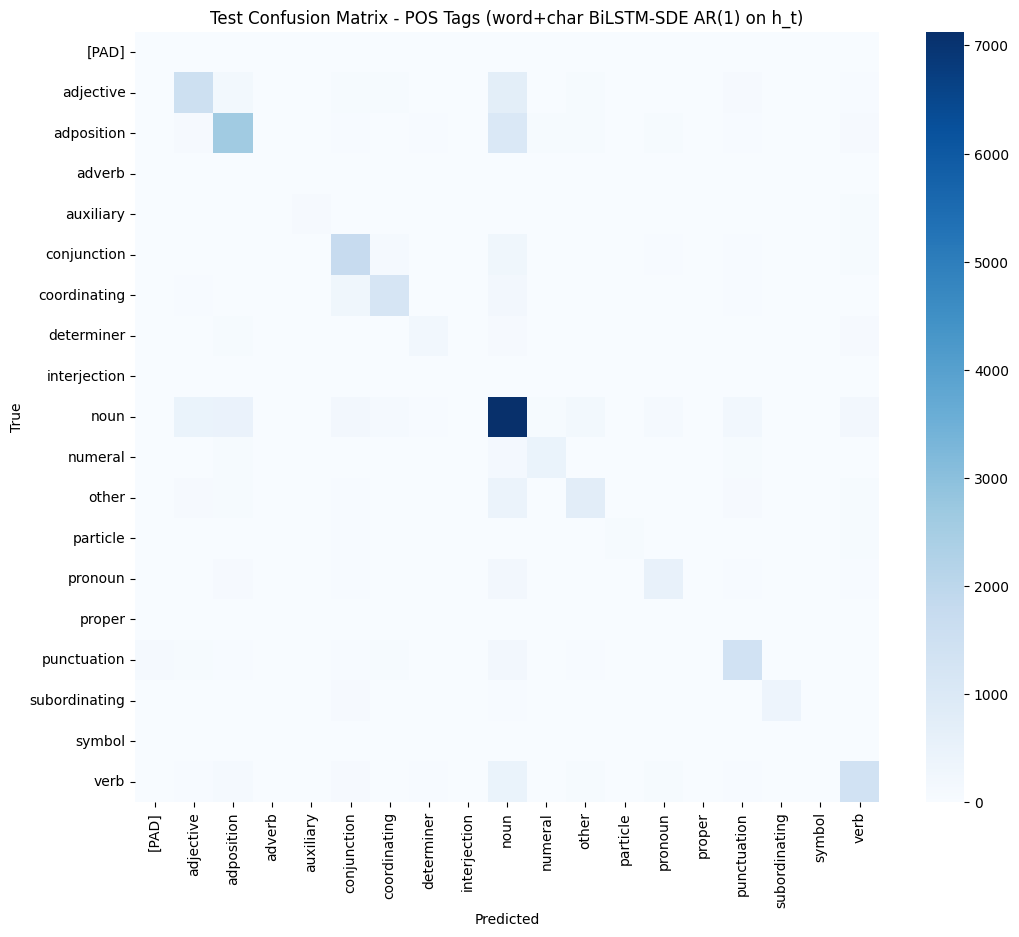

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

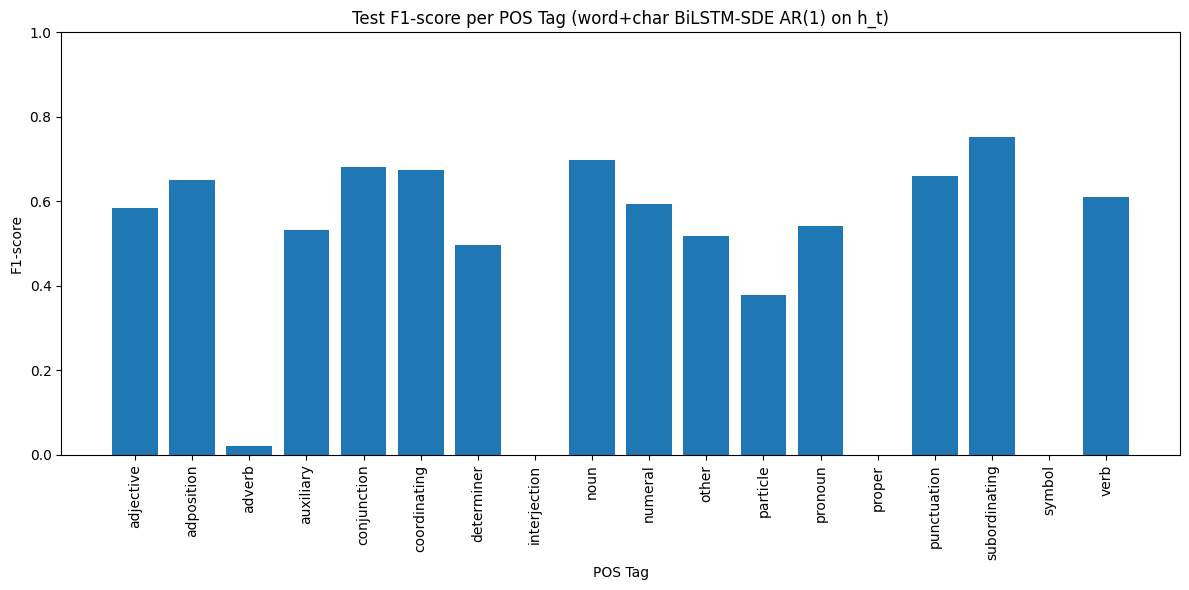

Test Sequence-level accuracy: 0.09256844850065189


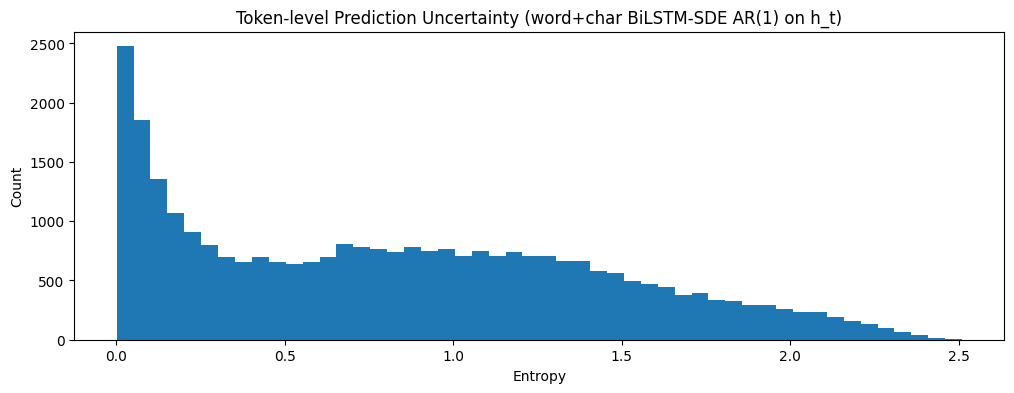

BLEU score (corpus-level): 55.62

Sample 1:
Words:  ['و', 'يتضمن', 'جدول', 'أعمال', 'الوفد', 'التجاري', 'استعراض', 'الإجراءات', 'التي', 'تم', 'اتخاذ', 'ها', 'ل', 'تأسيس', 'شركتين', 'مشتركتين', 'ب', 'رأسمال', '650', 'مليون', 'ريال', '200', 'مليون', 'دولار', 'تتعلق', 'إحدى', 'هما', 'ب', 'النقل', 'الجوي', 'و', 'البري', 'و', 'البحري', 'و', 'تنفيذ', 'رحلات', 'السياحة', 'السعودية', 'الوافدة', 'و', 'العمرة', 'و', 'الحج', 'و', 'يبلغ', 'رأسمال', 'ها', 'المقترح', '500', 'مليون', 'ريال', '3', '133', 'مليون', 'دولار', 'و', 'أخرى', 'ب', 'رأسمال', '250', 'مليون', 'ريال', '7', '66', 'مليون', 'دولار', 'و', 'تتخصص', 'في', 'الترويج', 'ل', 'المقاصد', 'السياحية', 'في', 'كل', 'من', 'مصر', 'و', 'السعودية', 'و', 'تنظيم', 'برامج', 'سياحية', 'مشتركة', 'و', 'تلقى', 'الضوء', 'على', 'المقاصد', 'السياحية', 'التي', 'تنفرد', 'ب', 'ها', 'البلدان', 'ك', 'السياحة', 'العلاجية', 'و']
Gold tags:   ['coordinating', 'conjunction', 'verb', 'noun', 'noun', 'noun', 'adjective', 'noun', 'noun', 'determiner', 'verb', 'noun', 'pr

In [9]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import pickle
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, Dense, Dropout, TimeDistributed,
    GlobalMaxPooling1D, Concatenate, RNN
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from tensorflow.keras.optimizers import Adam

# ========= USER CONFIG ========= #
data_size   = None
max_epochs  = 40
batch_size  = 128
random_state = 42

excel_path = "/kaggle/input/fulltag/padt_pos_4cols_fulltags.xlsx"
pkl_path   = "/kaggle/working/preprocessed_pos_data_padt_word_char_lstm_sde_ar1.pkl"

MAX_LEN        = 100
MAX_WORD_LEN   = 15
WORD_EMB_DIM   = 128
CHAR_EMB_DIM   = 50
LSTM_UNITS     = 128
NOISE_STD      = 0.5   # std للضوضاء الابتدائية ε_t
AR_RHO         = 0.5   # معامل AR(1): جرّب 0.3, 0.5, 0.8
# =============================== #

# ========== DATA PREPROCESS (CACHED) ========== #
if os.path.exists(pkl_path):
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    X_words = data["X_words"]
    X_chars = data["X_chars"]
    y = data["y"]
    sentences = data["sentences"]
    tag_tokenizer = data["tag_tokenizer"]
    word_tokenizer = data["word_tokenizer"]
    char_tokenizer = data["char_tokenizer"]
    print("Loaded preprocessed WORD+CHAR data from pickle.")
else:
    df = pd.read_excel(excel_path)

    sent_cols = ["train_sentence", "dev_sentence", "test_sentence"]
    pos_cols  = ["train_pos_seq",  "dev_pos_seq",  "test_pos_seq"]

    all_sentences, all_tags_seq = [], []
    for s_col, p_col in zip(sent_cols, pos_cols):
        s = df[s_col].fillna("").astype(str).values
        p = df[p_col].fillna("").astype(str).values
        for sent, tags in zip(s, p):
            if sent.strip() == "" or tags.strip() == "":
                continue
            all_sentences.append(sent)
            all_tags_seq.append(tags)

    sentences = np.array(all_sentences)
    tags_seq  = np.array(all_tags_seq)

    if data_size is not None and data_size <= len(sentences):
        sentences = sentences[:data_size]
        tags_seq  = tags_seq[:data_size]

    print("Total sentences:", len(sentences))

    # WORD tokenizer
    word_tokenizer = Tokenizer(char_level=False, oov_token="[OOV]")
    word_tokenizer.fit_on_texts(sentences)
    word_seqs = word_tokenizer.texts_to_sequences(sentences)
    X_words = pad_sequences(word_seqs, maxlen=MAX_LEN, padding="post", truncating="post")

    # CHAR tokenizer
    all_words_for_chars = []
    for sent in sentences:
        all_words_for_chars.extend(sent.split())

    char_tokenizer = Tokenizer(char_level=True, oov_token="[OOV_CH]")
    char_tokenizer.fit_on_texts(all_words_for_chars)

    def sentence_to_char_ids(sent):
        words = sent.split()
        words = words[:MAX_LEN] + [""] * max(0, MAX_LEN - len(words))
        char_ids = []
        for w in words:
            chars = list(w)
            ch_seq = char_tokenizer.texts_to_sequences(["".join(chars)])[0]
            ch_seq = ch_seq[:MAX_WORD_LEN]
            ch_seq = ch_seq + [0] * max(0, MAX_WORD_LEN - len(ch_seq))
            char_ids.append(ch_seq)
        return np.array(char_ids, dtype="int32")

    X_chars = np.stack([sentence_to_char_ids(s) for s in sentences])

    # Tag tokenizer
    tag_tokenizer = Tokenizer()
    tag_tokenizer.fit_on_texts(tags_seq)
    y_seqs = tag_tokenizer.texts_to_sequences(tags_seq)
    y = pad_sequences(y_seqs, maxlen=MAX_LEN, padding="post", truncating="post")

    with open(pkl_path, "wb") as f:
        pickle.dump({
            "X_words": X_words,
            "X_chars": X_chars,
            "y": y,
            "sentences": sentences,
            "tag_tokenizer": tag_tokenizer,
            "word_tokenizer": word_tokenizer,
            "char_tokenizer": char_tokenizer
        }, f)
    print("Saved preprocessed WORD+CHAR data to pickle.")

# ====== SHAPES ====== #
vocab_size_words = len(word_tokenizer.word_index) + 1
vocab_size_chars = len(char_tokenizer.word_index) + 1
tag_count        = len(tag_tokenizer.word_index) + 1
max_len          = X_words.shape[1]
max_word_len     = X_chars.shape[2]

print("vocab_size_words:", vocab_size_words)
print("vocab_size_chars:", vocab_size_chars)
print("tag_count       :", tag_count)
print("max_len(words)  :", max_len)
print("max_word_len    :", max_word_len)

# ====== SPLIT ====== #
Xw_trainval, Xw_test, Xc_trainval, Xc_test, y_trainval, y_test = train_test_split(
    X_words, X_chars, y, test_size=0.1, random_state=random_state
)
Xw_train, Xw_val, Xc_train, Xc_val, y_train, y_val = train_test_split(
    Xw_trainval, Xc_trainval, y_trainval, test_size=0.1111, random_state=random_state
)
print("Train words:", Xw_train.shape, "chars:", Xc_train.shape, "y:", y_train.shape)
print("Val   words:", Xw_val.shape, "chars:", Xc_val.shape, "y:", y_val.shape)
print("Test  words:", Xw_test.shape, "chars:", Xc_test.shape, "y:", y_test.shape)

# ====== LSTM-SDE CELL WITH AR(1) NOISE ON h_t ====== #
class LSTMSDECellH_AR1(tf.keras.layers.Layer):
    def __init__(self, units, noise_std=1.0, ar_rho=0.8, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        # now 3 states: h, c, z (ضوضاء AR(1) السابقة)
        self.state_size = [units, units, units]
        self.output_size = units
        self.noise_std = noise_std
        self.ar_rho = ar_rho

    def build(self, input_shape):
        input_dim = input_shape[-1]

        self.W_x = self.add_weight(
            shape=(input_dim, 4 * self.units),
            initializer="glorot_uniform",
            name="W_x_h_ar1",
        )
        self.W_h = self.add_weight(
            shape=(self.units, 4 * self.units),
            initializer="orthogonal",
            name="W_h_h_ar1",
        )
        self.b = self.add_weight(
            shape=(4 * self.units,),
            initializer="zeros",
            name="b_h_ar1",
        )

        self.drift_dense_h = Dense(self.units, name="drift_dense_h_ar1")
        self.diff_dense_h  = Dense(self.units, name="diff_dense_h_ar1")

        super().build(input_shape)

    def call(self, inputs, states, training=None):
        # h_tm1: الحالة المخفية السابقة
        # c_tm1: حالة الخلية السابقة
        # z_tm1: ضوضاء AR(1) السابقة
        h_tm1, c_tm1, z_tm1 = states

        # LSTM القياسي
        z = tf.matmul(inputs, self.W_x) + tf.matmul(h_tm1, self.W_h) + self.b
        zi, zf, zc, zo = tf.split(z, num_or_size_splits=4, axis=-1)

        i = tf.sigmoid(zi)
        f = tf.sigmoid(zf)
        o = tf.sigmoid(zo)
        c_hat = tf.tanh(zc)

        c_t = f * c_tm1 + i * c_hat
        h_t = o * tf.tanh(c_t)

        # ===== ضوضاء AR(1) على h_t =====
        # ε_t ~ N(0, sigma^2)
        eps_t = tf.random.normal(tf.shape(h_t), mean=0.0, stddev=self.noise_std)
        # z_t = ρ * z_{t-1} + ε_t
        z_t = self.ar_rho * z_tm1 + eps_t

        dt = 1.0
        drift_h = self.drift_dense_h(h_t)
        diffusion_h = self.diff_dense_h(h_t)

        # استخدم z_t بدل noise مستقل
        h_t_sde = h_t + drift_h * dt + diffusion_h * z_t * tf.sqrt(dt)

        # الحالة الجديدة: [h_t_sde, c_t, z_t]
        return h_t_sde, [h_t_sde, c_t, z_t]

# ====== MODEL: word+char -> BiLSTM-SDE(AR1 on h_t) -> TimeDistributed ====== #
word_inputs = Input(shape=(max_len,), name="word_input")
word_emb = Embedding(vocab_size_words, WORD_EMB_DIM,
                     mask_zero=False, name="word_embedding")(word_inputs)

char_inputs = Input(shape=(max_len, max_word_len), name="char_input")
char_emb_layer = Embedding(vocab_size_chars, CHAR_EMB_DIM,
                           mask_zero=False, name="char_embedding")
char_emb = TimeDistributed(char_emb_layer, name="td_char_emb")(char_inputs)

char_cnn = TimeDistributed(
    Conv1D(filters=50, kernel_size=3, padding="same", activation="relu"),
    name="td_char_cnn"
)(char_emb)
char_pool = TimeDistributed(GlobalMaxPooling1D(), name="td_char_pool")(char_cnn)

merged = Concatenate(axis=-1, name="word_char_concat")([word_emb, char_pool])

# خلية AR(1) في الاتجاهين
cell_f = LSTMSDECellH_AR1(LSTM_UNITS, noise_std=NOISE_STD, ar_rho=AR_RHO)
cell_b = LSTMSDECellH_AR1(LSTM_UNITS, noise_std=NOISE_STD, ar_rho=AR_RHO)

lstm_sde_f = RNN(cell_f,
                 return_sequences=True,
                 go_backwards=False,
                 name="lstm_sde_f_ar1")(merged)

lstm_sde_b = RNN(cell_b,
                 return_sequences=True,
                 go_backwards=True,
                 name="lstm_sde_b_ar1")(merged)

bilstm_sde = Concatenate(axis=-1, name="bilstm_sde_ar1")([lstm_sde_f, lstm_sde_b])

logits = TimeDistributed(Dense(tag_count, activation="softmax"),
                         name="tag_output")(bilstm_sde)

model = Model(inputs=[word_inputs, char_inputs], outputs=logits)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

# ====== TRAIN ====== #
y_train_targets = np.expand_dims(y_train, -1)
y_val_targets   = np.expand_dims(y_val, -1)

early = EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
checkpoint = ModelCheckpoint("/kaggle/working/best_word_char_bilstm_sde_ar1_pos.keras",
                             monitor="val_loss", save_best_only=True)

history = model.fit(
    [Xw_train, Xc_train], y_train_targets,
    batch_size=batch_size,
    epochs=max_epochs,
    validation_data=([Xw_val, Xc_val], y_val_targets),
    callbacks=[early, checkpoint]
)

# ====== EVALUATION ====== #
y_probs = model.predict([Xw_test, Xc_test])
y_pred = np.argmax(y_probs, axis=-1)
y_true = y_test

y_true = np.squeeze(y_true)
y_pred = np.squeeze(y_pred)

mask = (y_true != 0)
y_true_flat = y_true[mask]
y_pred_flat = y_pred[mask]

idx2tag = {v: k for k, v in tag_tokenizer.word_index.items()}
idx2tag[0] = '[PAD]'
y_true_tags = [idx2tag[idx] for idx in y_true_flat]
y_pred_tags = [idx2tag[idx] for idx in y_pred_flat]

print("\nTest Classification Report:")
with open("/kaggle/working/test_classification_report_word_char_bilstm_sde_ar1.txt",
          "w", encoding="utf-8") as f:
    f.write(classification_report(y_true_tags, y_pred_tags))
print(classification_report(y_true_tags, y_pred_tags))

labels = np.unique(y_true_tags + y_pred_tags)
cm = confusion_matrix(y_true_tags, y_pred_tags, labels=labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix - POS Tags (word+char BiLSTM-SDE AR(1) on h_t)")
plt.savefig("/kaggle/working/Test_Confusion_Matrix_word_char_BiLSTM_SDE_AR1.png")
plt.show()

report = classification_report(y_true_tags, y_pred_tags, output_dict=True)
f1s = [report[tag]["f1-score"] for tag in labels if tag != "[PAD]"]
plt.figure(figsize=(12, 6))
plt.bar(labels[1:], f1s)
plt.title("Test F1-score per POS Tag (word+char BiLSTM-SDE AR(1) on h_t)")
plt.xlabel("POS Tag")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("/kaggle/working/Test_F1-score_word_char_BiLSTM_SDE_AR1.png")
plt.show()

sequence_correct = (y_true == y_pred).all(axis=1)
print("Test Sequence-level accuracy:", sequence_correct.mean())

def compute_entropy(prob_vec):
    prob_vec = np.clip(prob_vec, 1e-12, 1 - 1e-12)
    return -np.sum(prob_vec * np.log(prob_vec), axis=-1)

entropies = compute_entropy(y_probs)
plt.figure(figsize=(12, 4))
plt.hist(entropies[mask], bins=50)
plt.title("Token-level Prediction Uncertainty (word+char BiLSTM-SDE AR(1) on h_t)")
plt.xlabel("Entropy")
plt.ylabel("Count")
plt.savefig("/kaggle/working/Test_Token-level_Prediction_Uncertainty_word_char_BiLSTM_SDE_AR1.png")
plt.show()

# --- BLEU Evaluation ---
bleu_hyps, bleu_refs = [], []
for i in range(y_true.shape[0]):
    ref_seq = [idx2tag[tag] for tag in y_true[i] if tag != 0]
    hyp_seq = [idx2tag[tag] for tag in y_pred[i] if tag != 0]
    if ref_seq and hyp_seq:
        bleu_refs.append([ref_seq])
        bleu_hyps.append(hyp_seq)
bleu = corpus_bleu(bleu_refs, bleu_hyps, smoothing_function=SmoothingFunction().method4)
print(f"BLEU score (corpus-level): {bleu*100:.2f}")

# --- Sample Print ---
n_samples = 5
idx2word = {v: k for k, v in word_tokenizer.word_index.items()}
idx2word[0] = "[PAD]"

for i in range(n_samples):
    idx = np.random.randint(len(Xw_test))
    words = [idx2word[w] for w in Xw_test[idx] if w != 0]
    true_seq = [idx2tag[tag] for tag in y_true[idx] if tag != 0]
    pred_seq = [idx2tag[tag] for tag in y_pred[idx] if tag != 0]
    print(f"\nSample {i+1}:")
    print("Words: ", words)
    print("Gold tags:  ", true_seq)
    print("Predicted:  ", pred_seq)
    print("-" * 40)


Loaded preprocessed WORD+CHAR data from pickle.
vocab_size_words: 24655
vocab_size_chars: 107
tag_count       : 19
max_len(words)  : 100
max_word_len    : 15
Train words: (6130, 100) chars: (6130, 100, 15) y: (6130, 100)
Val   words: (767, 100) chars: (767, 100, 15) y: (767, 100)
Test  words: (767, 100) chars: (767, 100, 15) y: (767, 100)


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ char_input          │ (None, 100, 15)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_emb         │ (None, 100, 15,   │      5,350 │ char_input[0][0]  │
│ (TimeDistributed)   │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_input          │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_cnn         │ (None, 100, 15,   │      7,550 │ td_char_emb[0][0] │
│ (TimeDistributed)   │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 100, 128)  │  3,155,840 │ word_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_pool        │ (None, 100, 50)   │          0 │ td_char_cnn[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_char_concat    │ (None, 100, 178)  │          0 │ word_embedding[0… │
│ (Concatenate)       │                   │            │ td_char_pool[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_sde_f_ar1      │ (None, 100, 128)  │    157,184 │ word_char_concat… │
│ (RNN)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_sde_b_ar1      │ (None, 100, 128)  │    157,184 │ word_char_concat… │
│ (RNN)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_sde_ar1      │ (None, 100, 256)  │          0 │ lstm_sde_f_ar1[0… │
│ (Concatenate)       │                   │            │ lstm_sde_b_ar1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tag_output          │ (None, 100, 19)   │      4,883 │ bilstm_sde_ar1[0… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,487,991 (13.31 MB)

 Trainable params: 3,487,991 (13.31 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.6171 - loss: 1.4631 - val_accuracy: 0.7278 - val_loss: 0.8649
Epoch 2/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.7282 - loss: 0.8663 - val_accuracy: 0.7450 - val_loss: 0.7716
Epoch 3/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.7397 - loss: 0.7854 - val_accuracy: 0.7655 - val_loss: 0.6779
Epoch 4/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.7642 - loss: 0.6840 - val_accuracy: 0.7844 - val_loss: 0.6194
Epoch 5/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.7857 - loss: 0.6140 - val_accuracy: 0.7981 - val_loss: 0.5786
Epoch 6/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.8023 - loss: 0.5655 - val_accuracy: 0.8146 - val_loss: 0.5342
Epoch 7/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.8243 - loss: 0.5028 - val_accuracy: 0.8280 - val_loss: 0.4934
Epoch 8/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.8377 - loss: 0.4610 - val_accuracy: 0.8380 - v

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

               precision    recall  f1-score   support

        [PAD]       0.00      0.00      0.00         0
    adjective       0.63      0.61      0.62      2823
   adposition       0.72      0.73      0.73      4218
       adverb       0.60      0.39      0.48        99
    auxiliary       0.52      0.52      0.52       204
  conjunction       0.75      0.73      0.74      2427
 coordinating       0.75      0.71      0.73      1873
   determiner       0.61      0.54      0.58       545
 interjection       0.00      0.00      0.00         1
         noun       0.72      0.76      0.74      9315
      numeral       0.69      0.65      0.67       807
        other       0.55      0.49      0.52      1666
     particle       0.53      0.47      0.50       216
      pronoun       0.65      0.61      0.63      1043
       proper       0.35      0.21      0.26        29
  punctuation       0.77      0.77      0.77      2057
subordinating       0.74      0.74      0.74       557
       sy

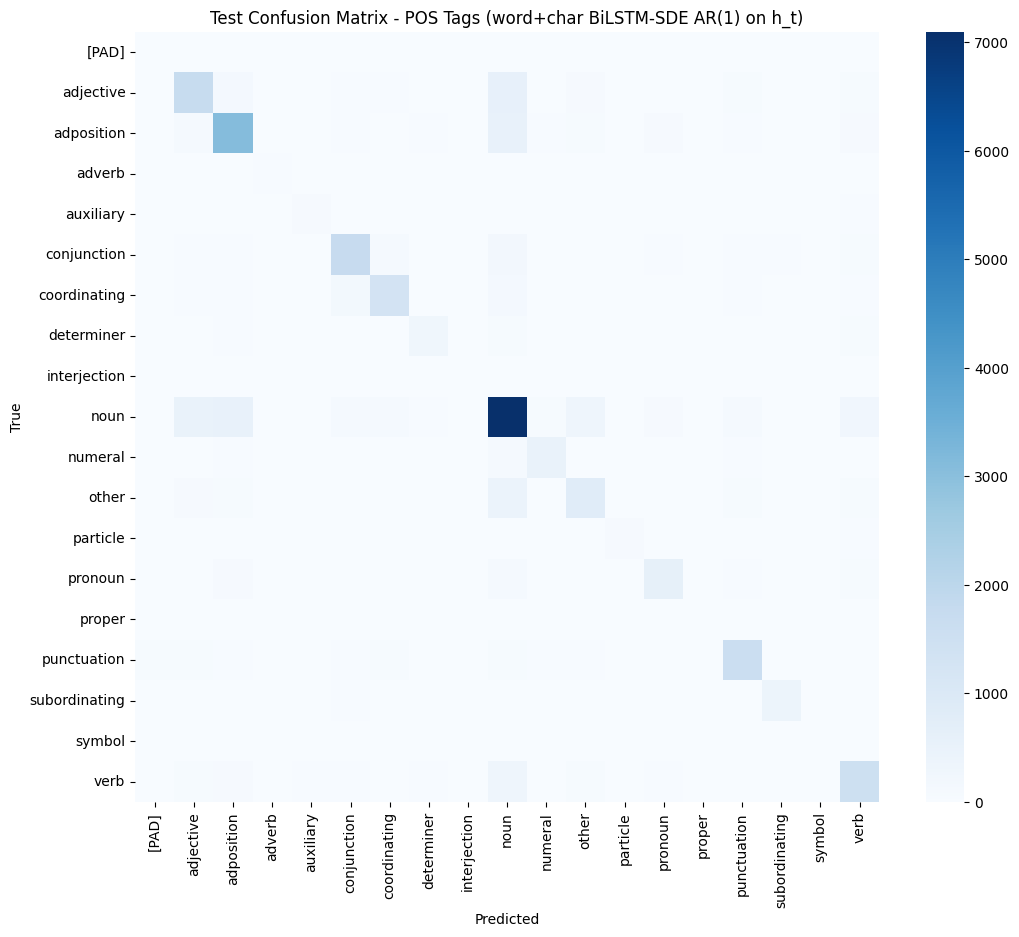

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

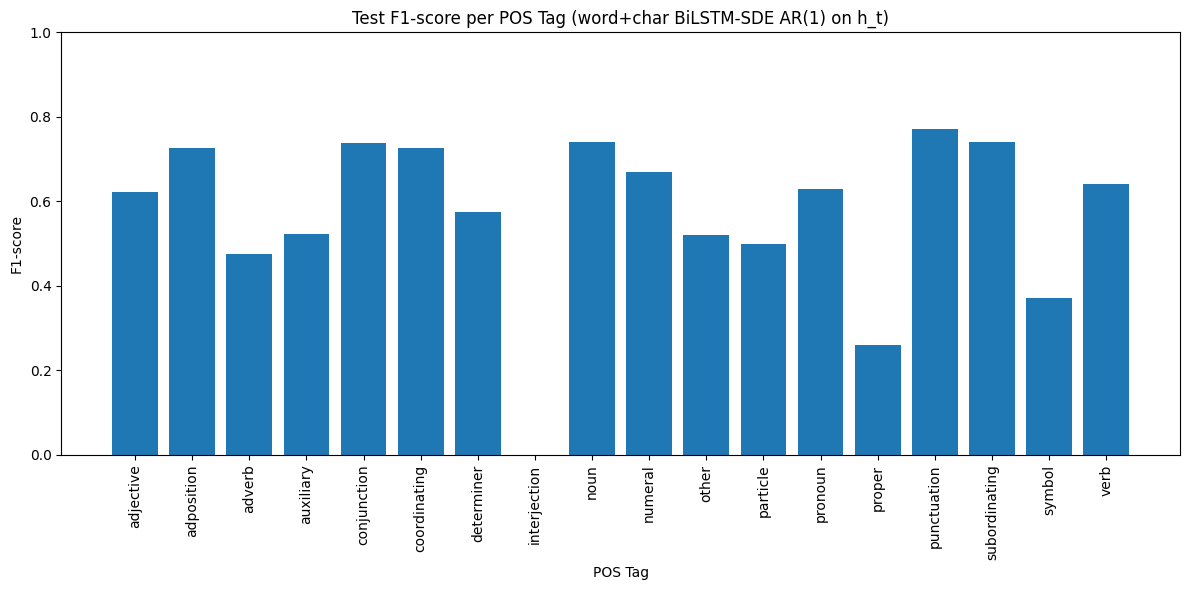

Test Sequence-level accuracy: 0.11603650586701435


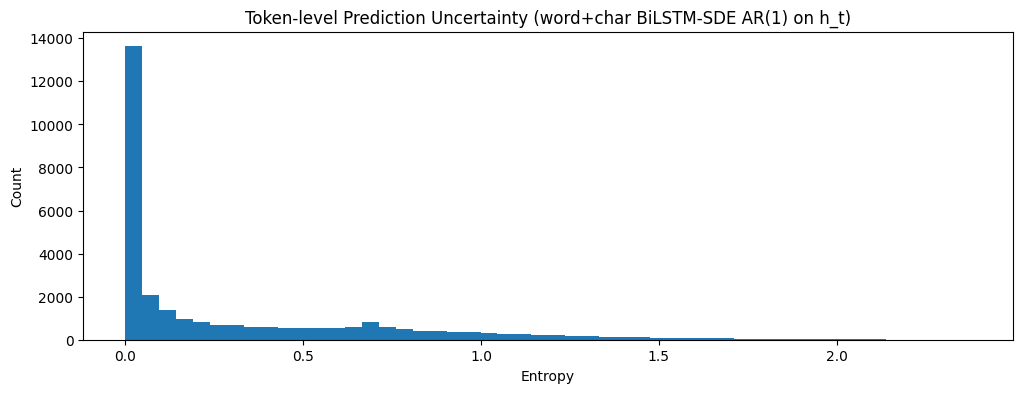

BLEU score (corpus-level): 64.39

Sample 1:
Words:  ['و', 'زاد', 'الحديث', 'عن', 'خلافة', 'الابن', 'ل', 'والد', 'ه', 'بعدما', 'استحدثت', 'أمانة', 'السياسات', 'في', 'المؤتمر', 'الثاني', 'ل', 'الحزب', 'الوطني', 'الحاكم', 'العام', 'الماضي', 'و', 'تولى', 'جمال', 'رئاسة', 'ها']
Gold tags:   ['coordinating', 'conjunction', 'verb', 'noun', 'adposition', 'noun', 'noun', 'adposition', 'noun', 'pronoun', 'coordinating', 'conjunction', 'verb', 'noun', 'noun', 'adposition', 'noun', 'adjective', 'adposition', 'noun', 'adjective', 'adjective', 'noun', 'adjective', 'coordinating', 'conjunction', 'verb', 'noun', 'noun', 'pronoun', 'punctuation']
Predicted:   ['coordinating', 'conjunction', 'verb', 'noun', 'adposition', 'noun', 'noun', 'adposition', 'noun', 'pronoun', 'coordinating', 'conjunction', 'verb', 'noun', 'noun', 'adposition', 'noun', 'adjective', 'adposition', 'noun', 'adjective', 'adjective', 'adjective', 'adjective', 'coordinating', 'conjunction', 'verb', 'other', 'noun', 'pronoun', 'punctu

In [10]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import pickle
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, Dense, Dropout, TimeDistributed,
    GlobalMaxPooling1D, Concatenate, RNN
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from tensorflow.keras.optimizers import Adam

# ========= USER CONFIG ========= #
data_size   = None
max_epochs  = 40
batch_size  = 128
random_state = 42

excel_path = "/kaggle/input/fulltag/padt_pos_4cols_fulltags.xlsx"
pkl_path   = "/kaggle/working/preprocessed_pos_data_padt_word_char_lstm_sde_ar1.pkl"

MAX_LEN        = 100
MAX_WORD_LEN   = 15
WORD_EMB_DIM   = 128
CHAR_EMB_DIM   = 50
LSTM_UNITS     = 128
NOISE_STD      = 0.5   # std للضوضاء الابتدائية ε_t
AR_RHO         = 0.8   # معامل AR(1)
# =============================== #

# ========== DATA PREPROCESS (CACHED) ========== #
if os.path.exists(pkl_path):
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    X_words = data["X_words"]
    X_chars = data["X_chars"]
    y = data["y"]
    sentences = data["sentences"]
    tag_tokenizer = data["tag_tokenizer"]
    word_tokenizer = data["word_tokenizer"]
    char_tokenizer = data["char_tokenizer"]
    print("Loaded preprocessed WORD+CHAR data from pickle.")
else:
    df = pd.read_excel(excel_path)

    sent_cols = ["train_sentence", "dev_sentence", "test_sentence"]
    pos_cols  = ["train_pos_seq",  "dev_pos_seq",  "test_pos_seq"]

    all_sentences, all_tags_seq = [], []
    for s_col, p_col in zip(sent_cols, pos_cols):
        s = df[s_col].fillna("").astype(str).values
        p = df[p_col].fillna("").astype(str).values
        for sent, tags in zip(s, p):
            if sent.strip() == "" or tags.strip() == "":
                continue
            all_sentences.append(sent)
            all_tags_seq.append(tags)

    sentences = np.array(all_sentences)
    tags_seq  = np.array(all_tags_seq)

    if data_size is not None and data_size <= len(sentences):
        sentences = sentences[:data_size]
        tags_seq  = tags_seq[:data_size]

    print("Total sentences:", len(sentences))

    # WORD tokenizer
    word_tokenizer = Tokenizer(char_level=False, oov_token="[OOV]")
    word_tokenizer.fit_on_texts(sentences)
    word_seqs = word_tokenizer.texts_to_sequences(sentences)
    X_words = pad_sequences(word_seqs, maxlen=MAX_LEN, padding="post", truncating="post")

    # CHAR tokenizer
    all_words_for_chars = []
    for sent in sentences:
        all_words_for_chars.extend(sent.split())

    char_tokenizer = Tokenizer(char_level=True, oov_token="[OOV_CH]")
    char_tokenizer.fit_on_texts(all_words_for_chars)

    def sentence_to_char_ids(sent):
        words = sent.split()
        words = words[:MAX_LEN] + [""] * max(0, MAX_LEN - len(words))
        char_ids = []
        for w in words:
            chars = list(w)
            ch_seq = char_tokenizer.texts_to_sequences(["".join(chars)])[0]
            ch_seq = ch_seq[:MAX_WORD_LEN]
            ch_seq = ch_seq + [0] * max(0, MAX_WORD_LEN - len(ch_seq))
            char_ids.append(ch_seq)
        return np.array(char_ids, dtype="int32")

    X_chars = np.stack([sentence_to_char_ids(s) for s in sentences])

    # Tag tokenizer
    tag_tokenizer = Tokenizer()
    tag_tokenizer.fit_on_texts(tags_seq)
    y_seqs = tag_tokenizer.texts_to_sequences(tags_seq)
    y = pad_sequences(y_seqs, maxlen=MAX_LEN, padding="post", truncating="post")

    with open(pkl_path, "wb") as f:
        pickle.dump({
            "X_words": X_words,
            "X_chars": X_chars,
            "y": y,
            "sentences": sentences,
            "tag_tokenizer": tag_tokenizer,
            "word_tokenizer": word_tokenizer,
            "char_tokenizer": char_tokenizer
        }, f)
    print("Saved preprocessed WORD+CHAR data to pickle.")

# ====== SHAPES ====== #
vocab_size_words = len(word_tokenizer.word_index) + 1
vocab_size_chars = len(char_tokenizer.word_index) + 1
tag_count        = len(tag_tokenizer.word_index) + 1
max_len          = X_words.shape[1]
max_word_len     = X_chars.shape[2]

print("vocab_size_words:", vocab_size_words)
print("vocab_size_chars:", vocab_size_chars)
print("tag_count       :", tag_count)
print("max_len(words)  :", max_len)
print("max_word_len    :", max_word_len)

# ====== SPLIT ====== #
Xw_trainval, Xw_test, Xc_trainval, Xc_test, y_trainval, y_test = train_test_split(
    X_words, X_chars, y, test_size=0.1, random_state=random_state
)
Xw_train, Xw_val, Xc_train, Xc_val, y_train, y_val = train_test_split(
    Xw_trainval, Xc_trainval, y_trainval, test_size=0.1111, random_state=random_state
)
print("Train words:", Xw_train.shape, "chars:", Xc_train.shape, "y:", y_train.shape)
print("Val   words:", Xw_val.shape, "chars:", Xc_val.shape, "y:", y_val.shape)
print("Test  words:", Xw_test.shape, "chars:", Xc_test.shape, "y:", y_test.shape)

# ====== LSTM-SDE CELL WITH AR(1) NOISE ON h_t ====== #
class LSTMSDECellH_AR1(tf.keras.layers.Layer):
    def __init__(self, units, noise_std=1.0, ar_rho=0.8, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        # 3 حالات: h, c, z (ضوضاء AR(1) السابقة)
        self.state_size = [units, units, units]
        self.output_size = units
        self.noise_std = noise_std
        self.ar_rho = ar_rho

    def build(self, input_shape):
        input_dim = input_shape[-1]

        self.W_x = self.add_weight(
            shape=(input_dim, 4 * self.units),
            initializer="glorot_uniform",
            name="W_x_h_ar1",
        )
        self.W_h = self.add_weight(
            shape=(self.units, 4 * self.units),
            initializer="orthogonal",
            name="W_h_h_ar1",
        )
        self.b = self.add_weight(
            shape=(4 * self.units,),
            initializer="zeros",
            name="b_h_ar1",
        )

        self.drift_dense_h = Dense(self.units, name="drift_dense_h_ar1")
        self.diff_dense_h  = Dense(self.units, name="diff_dense_h_ar1")

        super().build(input_shape)

    def call(self, inputs, states, training=None):
        h_tm1, c_tm1, z_tm1 = states

        # LSTM القياسي
        z = tf.matmul(inputs, self.W_x) + tf.matmul(h_tm1, self.W_h) + self.b
        zi, zf, zc, zo = tf.split(z, num_or_size_splits=4, axis=-1)

        i = tf.sigmoid(zi)
        f = tf.sigmoid(zf)
        o = tf.sigmoid(zo)
        c_hat = tf.tanh(zc)

        c_t = f * c_tm1 + i * c_hat
        h_t = o * tf.tanh(c_t)

        # ضوضاء AR(1) على h_t
        eps_t = tf.random.normal(tf.shape(h_t), mean=0.0, stddev=self.noise_std)
        z_t = self.ar_rho * z_tm1 + eps_t

        dt = 1.0
        drift_h = self.drift_dense_h(h_t)
        diffusion_h = self.diff_dense_h(h_t)

        h_t_sde = h_t + drift_h * dt + diffusion_h * z_t * tf.sqrt(dt)

        return h_t_sde, [h_t_sde, c_t, z_t]

# ====== MODEL: word+char -> BiLSTM-SDE(AR1 on h_t) -> TimeDistributed ====== #
word_inputs = Input(shape=(max_len,), name="word_input")
word_emb = Embedding(vocab_size_words, WORD_EMB_DIM,
                     mask_zero=False, name="word_embedding")(word_inputs)

char_inputs = Input(shape=(max_len, max_word_len), name="char_input")
char_emb_layer = Embedding(vocab_size_chars, CHAR_EMB_DIM,
                           mask_zero=False, name="char_embedding")
char_emb = TimeDistributed(char_emb_layer, name="td_char_emb")(char_inputs)

char_cnn = TimeDistributed(
    Conv1D(filters=50, kernel_size=3, padding="same", activation="relu"),
    name="td_char_cnn"
)(char_emb)
char_pool = TimeDistributed(GlobalMaxPooling1D(), name="td_char_pool")(char_cnn)

merged = Concatenate(axis=-1, name="word_char_concat")([word_emb, char_pool])

cell_f = LSTMSDECellH_AR1(LSTM_UNITS, noise_std=NOISE_STD, ar_rho=AR_RHO)
cell_b = LSTMSDECellH_AR1(LSTM_UNITS, noise_std=NOISE_STD, ar_rho=AR_RHO)

lstm_sde_f = RNN(cell_f,
                 return_sequences=True,
                 go_backwards=False,
                 name="lstm_sde_f_ar1")(merged)

lstm_sde_b = RNN(cell_b,
                 return_sequences=True,
                 go_backwards=True,
                 name="lstm_sde_b_ar1")(merged)

bilstm_sde = Concatenate(axis=-1, name="bilstm_sde_ar1")([lstm_sde_f, lstm_sde_b])

logits = TimeDistributed(Dense(tag_count, activation="softmax"),
                         name="tag_output")(bilstm_sde)

model = Model(inputs=[word_inputs, char_inputs], outputs=logits)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

# ====== TRAIN (بدون EarlyStopping) ====== #
y_train_targets = np.expand_dims(y_train, -1)
y_val_targets   = np.expand_dims(y_val, -1)

checkpoint = ModelCheckpoint(
    "/kaggle/working/best_word_char_bilstm_sde_ar1_pos.keras",
    monitor="val_loss",
    save_best_only=True
)

history = model.fit(
    [Xw_train, Xc_train], y_train_targets,
    batch_size=batch_size,
    epochs=max_epochs,
    validation_data=([Xw_val, Xc_val], y_val_targets),
    callbacks=[checkpoint]
)

# ====== EVALUATION ====== #
y_probs = model.predict([Xw_test, Xc_test])
y_pred = np.argmax(y_probs, axis=-1)
y_true = y_test

y_true = np.squeeze(y_true)
y_pred = np.squeeze(y_pred)

mask = (y_true != 0)
y_true_flat = y_true[mask]
y_pred_flat = y_pred[mask]

idx2tag = {v: k for k, v in tag_tokenizer.word_index.items()}
idx2tag[0] = '[PAD]'
y_true_tags = [idx2tag[idx] for idx in y_true_flat]
y_pred_tags = [idx2tag[idx] for idx in y_pred_flat]

print("\nTest Classification Report:")
with open("/kaggle/working/test_classification_report_word_char_bilstm_sde_ar1.txt",
          "w", encoding="utf-8") as f:
    f.write(classification_report(y_true_tags, y_pred_tags))
print(classification_report(y_true_tags, y_pred_tags))

labels = np.unique(y_true_tags + y_pred_tags)
cm = confusion_matrix(y_true_tags, y_pred_tags, labels=labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix - POS Tags (word+char BiLSTM-SDE AR(1) on h_t)")
plt.savefig("/kaggle/working/Test_Confusion_Matrix_word_char_BiLSTM_SDE_AR1.png")
plt.show()

report = classification_report(y_true_tags, y_pred_tags, output_dict=True)
f1s = [report[tag]["f1-score"] for tag in labels if tag != "[PAD]"]
plt.figure(figsize=(12, 6))
plt.bar(labels[1:], f1s)
plt.title("Test F1-score per POS Tag (word+char BiLSTM-SDE AR(1) on h_t)")
plt.xlabel("POS Tag")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("/kaggle/working/Test_F1-score_word_char_BiLSTM_SDE_AR1.png")
plt.show()

sequence_correct = (y_true == y_pred).all(axis=1)
print("Test Sequence-level accuracy:", sequence_correct.mean())

def compute_entropy(prob_vec):
    prob_vec = np.clip(prob_vec, 1e-12, 1 - 1e-12)
    return -np.sum(prob_vec * np.log(prob_vec), axis=-1)

entropies = compute_entropy(y_probs)
plt.figure(figsize=(12, 4))
plt.hist(entropies[mask], bins=50)
plt.title("Token-level Prediction Uncertainty (word+char BiLSTM-SDE AR(1) on h_t)")
plt.xlabel("Entropy")
plt.ylabel("Count")
plt.savefig("/kaggle/working/Test_Token-level_Prediction_Uncertainty_word_char_BiLSTM_SDE_AR1.png")
plt.show()

# --- BLEU Evaluation ---
bleu_hyps, bleu_refs = [], []
for i in range(y_true.shape[0]):
    ref_seq = [idx2tag[tag] for tag in y_true[i] if tag != 0]
    hyp_seq = [idx2tag[tag] for tag in y_pred[i] if tag != 0]
    if ref_seq and hyp_seq:
        bleu_refs.append([ref_seq])
        bleu_hyps.append(hyp_seq)
bleu = corpus_bleu(bleu_refs, bleu_hyps, smoothing_function=SmoothingFunction().method4)
print(f"BLEU score (corpus-level): {bleu*100:.2f}")

# --- Sample Print ---
n_samples = 5
idx2word = {v: k for k, v in word_tokenizer.word_index.items()}
idx2word[0] = "[PAD]"

for i in range(n_samples):
    idx = np.random.randint(len(Xw_test))
    words = [idx2word[w] for w in Xw_test[idx] if w != 0]
    true_seq = [idx2tag[tag] for tag in y_true[idx] if tag != 0]
    pred_seq = [idx2tag[tag] for tag in y_pred[idx] if tag != 0]
    print(f"\nSample {i+1}:")
    print("Words: ", words)
    print("Gold tags:  ", true_seq)
    print("Predicted:  ", pred_seq)
    print("-" * 40)


In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import pickle
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, Dense, Dropout, TimeDistributed,
    GlobalMaxPooling1D, Concatenate, RNN
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from tensorflow.keras.optimizers import Adam

# ========= USER CONFIG ========= #
data_size   = None
max_epochs  = 40
batch_size  = 128
random_state = 42

excel_path = "/kaggle/input/fulltag/padt_pos_4cols_fulltags.xlsx"
pkl_path   = "/kaggle/working/preprocessed_pos_data_padt_word_char_lstm_sde_ar1.pkl"

MAX_LEN        = 100
MAX_WORD_LEN   = 15
WORD_EMB_DIM   = 128
CHAR_EMB_DIM   = 50
LSTM_UNITS     = 128
NOISE_STD      = 0.5   # std للضوضاء الابتدائية ε_t
AR_RHO         = 0.8   # معامل AR(1)
# =============================== #

# ========== DATA PREPROCESS (CACHED) ========== #
if os.path.exists(pkl_path):
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    X_words = data["X_words"]
    X_chars = data["X_chars"]
    y = data["y"]
    sentences = data["sentences"]
    tag_tokenizer = data["tag_tokenizer"]
    word_tokenizer = data["word_tokenizer"]
    char_tokenizer = data["char_tokenizer"]
    print("Loaded preprocessed WORD+CHAR data from pickle.")
else:
    df = pd.read_excel(excel_path)

    sent_cols = ["train_sentence", "dev_sentence", "test_sentence"]
    pos_cols  = ["train_pos_seq",  "dev_pos_seq",  "test_pos_seq"]

    all_sentences, all_tags_seq = [], []
    for s_col, p_col in zip(sent_cols, pos_cols):
        s = df[s_col].fillna("").astype(str).values
        p = df[p_col].fillna("").astype(str).values
        for sent, tags in zip(s, p):
            if sent.strip() == "" or tags.strip() == "":
                continue
            all_sentences.append(sent)
            all_tags_seq.append(tags)

    sentences = np.array(all_sentences)
    tags_seq  = np.array(all_tags_seq)

    if data_size is not None and data_size <= len(sentences):
        sentences = sentences[:data_size]
        tags_seq  = tags_seq[:data_size]

    print("Total sentences:", len(sentences))

    # WORD tokenizer
    word_tokenizer = Tokenizer(char_level=False, oov_token="[OOV]")
    word_tokenizer.fit_on_texts(sentences)
    word_seqs = word_tokenizer.texts_to_sequences(sentences)
    X_words = pad_sequences(word_seqs, maxlen=MAX_LEN, padding="post", truncating="post")

    # CHAR tokenizer
    all_words_for_chars = []
    for sent in sentences:
        all_words_for_chars.extend(sent.split())

    char_tokenizer = Tokenizer(char_level=True, oov_token="[OOV_CH]")
    char_tokenizer.fit_on_texts(all_words_for_chars)

    def sentence_to_char_ids(sent):
        words = sent.split()
        words = words[:MAX_LEN] + [""] * max(0, MAX_LEN - len(words))
        char_ids = []
        for w in words:
            chars = list(w)
            ch_seq = char_tokenizer.texts_to_sequences(["".join(chars)])[0]
            ch_seq = ch_seq[:MAX_WORD_LEN]
            ch_seq = ch_seq + [0] * max(0, MAX_WORD_LEN - len(ch_seq))
            char_ids.append(ch_seq)
        return np.array(char_ids, dtype="int32")

    X_chars = np.stack([sentence_to_char_ids(s) for s in sentences])

    # Tag tokenizer
    tag_tokenizer = Tokenizer()
    tag_tokenizer.fit_on_texts(tags_seq)
    y_seqs = tag_tokenizer.texts_to_sequences(tags_seq)
    y = pad_sequences(y_seqs, maxlen=MAX_LEN, padding="post", truncating="post")

    with open(pkl_path, "wb") as f:
        pickle.dump({
            "X_words": X_words,
            "X_chars": X_chars,
            "y": y,
            "sentences": sentences,
            "tag_tokenizer": tag_tokenizer,
            "word_tokenizer": word_tokenizer,
            "char_tokenizer": char_tokenizer
        }, f)
    print("Saved preprocessed WORD+CHAR data to pickle.")

# ====== SHAPES ====== #
vocab_size_words = len(word_tokenizer.word_index) + 1
vocab_size_chars = len(char_tokenizer.word_index) + 1
tag_count        = len(tag_tokenizer.word_index) + 1
max_len          = X_words.shape[1]
max_word_len     = X_chars.shape[2]

print("vocab_size_words:", vocab_size_words)
print("vocab_size_chars:", vocab_size_chars)
print("tag_count       :", tag_count)
print("max_len(words)  :", max_len)
print("max_word_len    :", max_word_len)

# ====== SPLIT ====== #
Xw_trainval, Xw_test, Xc_trainval, Xc_test, y_trainval, y_test = train_test_split(
    X_words, X_chars, y, test_size=0.1, random_state=random_state
)
Xw_train, Xw_val, Xc_train, Xc_val, y_train, y_val = train_test_split(
    Xw_trainval, Xc_trainval, y_trainval, test_size=0.1111, random_state=random_state
)
print("Train words:", Xw_train.shape, "chars:", Xc_train.shape, "y:", y_train.shape)
print("Val   words:", Xw_val.shape, "chars:", Xc_val.shape, "y:", y_val.shape)
print("Test  words:", Xw_test.shape, "chars:", Xc_test.shape, "y:", y_test.shape)

# ====== LSTM-SDE CELL WITH AR(1) NOISE ON h_t ====== #
class LSTMSDECellH_AR1(tf.keras.layers.Layer):
    def __init__(self, units, noise_std=1.0, ar_rho=0.8, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        # 3 حالات: h, c, z (ضوضاء AR(1) السابقة)
        self.state_size = [units, units, units]
        self.output_size = units
        self.noise_std = noise_std
        self.ar_rho = ar_rho

    def build(self, input_shape):
        input_dim = input_shape[-1]

        self.W_x = self.add_weight(
            shape=(input_dim, 4 * self.units),
            initializer="glorot_uniform",
            name="W_x_h_ar1",
        )
        self.W_h = self.add_weight(
            shape=(self.units, 4 * self.units),
            initializer="orthogonal",
            name="W_h_h_ar1",
        )
        self.b = self.add_weight(
            shape=(4 * self.units,),
            initializer="zeros",
            name="b_h_ar1",
        )

        self.drift_dense_h = Dense(self.units, name="drift_dense_h_ar1")
        self.diff_dense_h  = Dense(self.units, name="diff_dense_h_ar1")

        super().build(input_shape)

    def call(self, inputs, states, training=None):
        h_tm1, c_tm1, z_tm1 = states

        # LSTM القياسي
        z = tf.matmul(inputs, self.W_x) + tf.matmul(h_tm1, self.W_h) + self.b
        zi, zf, zc, zo = tf.split(z, num_or_size_splits=4, axis=-1)

        i = tf.sigmoid(zi)
        f = tf.sigmoid(zf)
        o = tf.sigmoid(zo)
        c_hat = tf.tanh(zc)

        c_t = f * c_tm1 + i * c_hat
        h_t = o * tf.tanh(c_t)

        # ضوضاء AR(1) على h_t
        eps_t = tf.random.normal(tf.shape(h_t), mean=0.0, stddev=self.noise_std)
        z_t = self.ar_rho * z_tm1 + eps_t

        dt = 1.0
        drift_h = self.drift_dense_h(h_t)
        diffusion_h = self.diff_dense_h(h_t)

        h_t_sde = h_t + drift_h * dt + diffusion_h * z_t * tf.sqrt(dt)

        return h_t_sde, [h_t_sde, c_t, z_t]

# ====== MODEL: word+char -> BiLSTM-SDE(AR1 on h_t) -> TimeDistributed ====== #
word_inputs = Input(shape=(max_len,), name="word_input")
word_emb = Embedding(vocab_size_words, WORD_EMB_DIM,
                     mask_zero=False, name="word_embedding")(word_inputs)

char_inputs = Input(shape=(max_len, max_word_len), name="char_input")
char_emb_layer = Embedding(vocab_size_chars, CHAR_EMB_DIM,
                           mask_zero=False, name="char_embedding")
char_emb = TimeDistributed(char_emb_layer, name="td_char_emb")(char_inputs)

char_cnn = TimeDistributed(
    Conv1D(filters=50, kernel_size=3, padding="same", activation="relu"),
    name="td_char_cnn"
)(char_emb)
char_pool = TimeDistributed(GlobalMaxPooling1D(), name="td_char_pool")(char_cnn)

merged = Concatenate(axis=-1, name="word_char_concat")([word_emb, char_pool])

cell_f = LSTMSDECellH_AR1(LSTM_UNITS, noise_std=NOISE_STD, ar_rho=AR_RHO)
cell_b = LSTMSDECellH_AR1(LSTM_UNITS, noise_std=NOISE_STD, ar_rho=AR_RHO)

lstm_sde_f = RNN(cell_f,
                 return_sequences=True,
                 go_backwards=False,
                 name="lstm_sde_f_ar1")(merged)

lstm_sde_b = RNN(cell_b,
                 return_sequences=True,
                 go_backwards=True,
                 name="lstm_sde_b_ar1")(merged)

bilstm_sde = Concatenate(axis=-1, name="bilstm_sde_ar1")([lstm_sde_f, lstm_sde_b])

logits = TimeDistributed(Dense(tag_count, activation="softmax"),
                         name="tag_output")(bilstm_sde)

model = Model(inputs=[word_inputs, char_inputs], outputs=logits)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

# ====== TRAIN ====== #
y_train_targets = np.expand_dims(y_train, -1)
y_val_targets   = np.expand_dims(y_val, -1)

checkpoint = ModelCheckpoint(
    "/kaggle/working/best_word_char_bilstm_sde_ar1_pos.keras",
    monitor="val_loss",
    save_best_only=True
)

history = model.fit(
    [Xw_train, Xc_train], y_train_targets,
    batch_size=batch_size,
    epochs=max_epochs,
    validation_data=([Xw_val, Xc_val], y_val_targets),
    callbacks=[checkpoint]
)

# ====== TRAINING CURVES (اختياري للورقة) ====== #
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss (BiLSTM-SDE AR(1))")
plt.tight_layout()
plt.savefig("/kaggle/working/loss_curves_bilstm_sde_ar1.png")
plt.close()

plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy (BiLSTM-SDE AR(1))")
plt.tight_layout()
plt.savefig("/kaggle/working/accuracy_curves_bilstm_sde_ar1.png")
plt.close()

# ====== EVALUATION ====== #
print("\nLoading best checkpoint for evaluation...")
model.load_weights("/kaggle/working/best_word_char_bilstm_sde_ar1_pos.keras")

y_probs = model.predict([Xw_test, Xc_test])
y_pred = np.argmax(y_probs, axis=-1)
y_true = y_test

y_true = np.squeeze(y_true)
y_pred = np.squeeze(y_pred)

# قناع لاستبعاد PAD
mask = (y_true != 0)
y_true_flat = y_true[mask]
y_pred_flat = y_pred[mask]

idx2tag = {v: k for k, v in tag_tokenizer.word_index.items()}
idx2tag[0] = '[PAD]'
y_true_tags = [idx2tag[idx] for idx in y_true_flat]
y_pred_tags = [idx2tag[idx] for idx in y_pred_flat]

print("\n=== Test Classification Report (no PAD) ===")
cls_report_str = classification_report(y_true_tags, y_pred_tags)
print(cls_report_str)
with open("/kaggle/working/test_classification_report_word_char_bilstm_sde_ar1.txt",
          "w", encoding="utf-8") as f:
    f.write(cls_report_str)

# === METRICS SUMMARY (للورقة) === #
# Token-level accuracy (no PAD)
token_accuracy = accuracy_score(y_true_flat, y_pred_flat)
# Macro F1 و Weighted F1
macro_f1   = f1_score(y_true_flat, y_pred_flat, average="macro")
weighted_f1 = f1_score(y_true_flat, y_pred_flat, average="weighted")

print("\n=== METRICS SUMMARY (token-level, no PAD) ===")
print(f"Token-level accuracy : {token_accuracy:.4f}")
print(f"Macro F1-score       : {macro_f1:.4f}")
print(f"Weighted F1-score    : {weighted_f1:.4f}")

# Per-tag F1
labels_unique = np.unique(y_true_flat)
tag_names = [idx2tag[i] for i in labels_unique]
per_tag_f1 = f1_score(y_true_flat, y_pred_flat, average=None, labels=labels_unique)
print("\nPer-tag F1-scores:")
for t, s in zip(tag_names, per_tag_f1):
    print(f"{t:15s}: {s:.4f}")

# ====== CONFUSION MATRIX ====== #
labels = np.unique(y_true_tags + y_pred_tags)
cm = confusion_matrix(y_true_tags, y_pred_tags, labels=labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix - POS Tags (word+char BiLSTM-SDE AR(1) on h_t)")
plt.tight_layout()
plt.savefig("/kaggle/working/Test_Confusion_Matrix_word_char_BiLSTM_SDE_AR1.png")
plt.close()

# ====== F1 PER TAG BARPLOT ====== #
report = classification_report(y_true_tags, y_pred_tags, output_dict=True)
f1s = [report[tag]["f1-score"] for tag in labels if tag != "[PAD]"]
plt.figure(figsize=(12, 6))
plt.bar(labels[1:], f1s)
plt.title("Test F1-score per POS Tag (word+char BiLSTM-SDE AR(1) on h_t)")
plt.xlabel("POS Tag")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("/kaggle/working/Test_F1-score_word_char_BiLSTM_SDE_AR1.png")
plt.close()

# ====== SEQUENCE-LEVEL ACCURACY ====== #
sequence_correct = (y_true == y_pred).all(axis=1)
seq_accuracy = sequence_correct.mean()
print(f"\nSequence-level accuracy (exact sentence tagging): {seq_accuracy:.4f}")

# ====== ENTROPY / UNCERTAINTY ====== #
def compute_entropy(prob_vec):
    prob_vec = np.clip(prob_vec, 1e-12, 1 - 1e-12)
    return -np.sum(prob_vec * np.log(prob_vec), axis=-1)

entropies = compute_entropy(y_probs)
plt.figure(figsize=(12, 4))
plt.hist(entropies[mask], bins=50)
plt.title("Token-level Prediction Uncertainty (word+char BiLSTM-SDE AR(1) on h_t)")
plt.xlabel("Entropy")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("/kaggle/working/Test_Token-level_Prediction_Uncertainty_word_char_BiLSTM_SDE_AR1.png")
plt.close()

# ====== BLEU Evaluation ====== #
bleu_hyps, bleu_refs = [], []
for i in range(y_true.shape[0]):
    ref_seq = [idx2tag[tag] for tag in y_true[i] if tag != 0]
    hyp_seq = [idx2tag[tag] for tag in y_pred[i] if tag != 0]
    if ref_seq and hyp_seq:
        bleu_refs.append([ref_seq])
        bleu_hyps.append(hyp_seq)
bleu = corpus_bleu(bleu_refs, bleu_hyps, smoothing_function=SmoothingFunction().method4)
print(f"\nCorpus-level BLEU score (POS sequences): {bleu*100:.2f}")

# ====== SAMPLE PRINTS ====== #
n_samples = 5
idx2word = {v: k for k, v in word_tokenizer.word_index.items()}
idx2word[0] = "[PAD]"

print("\n=== Sample Predictions (for qualitative analysis) ===")
for i in range(n_samples):
    idx = np.random.randint(len(Xw_test))
    words = [idx2word[w] for w in Xw_test[idx] if w != 0]
    true_seq = [idx2tag[tag] for tag in y_true[idx] if tag != 0]
    pred_seq = [idx2tag[tag] for tag in y_pred[idx] if tag != 0]
    print(f"\nSample {i+1}:")
    print("Words:      ", " ".join(words))
    print("Gold tags:  ", " ".join(true_seq))
    print("Predicted:  ", " ".join(pred_seq))
    print("-" * 60)


2025-11-29 13:20:39.725744: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764422439.960124      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764422440.030231      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Total sentences: 7664
Saved preprocessed WORD+CHAR data to pickle.
vocab_size_words: 24655
vocab_size_chars: 107
tag_count       : 19
max_len(words)  : 100
max_word_len    : 15
Train words: (6130, 100) chars: (6130, 100, 15) y: (6130, 100)
Val   words: (767, 100) chars: (767, 100, 15) y: (767, 100)
Test  words: (767, 100) chars: (767, 100, 15) y: (767, 100)


I0000 00:00:1764422459.629325      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ char_input          │ (None, 100, 15)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_emb         │ (None, 100, 15,   │      5,350 │ char_input[0][0]  │
│ (TimeDistributed)   │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_input          │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_cnn         │ (None, 100, 15,   │      7,550 │ td_char_emb[0][0] │
│ (TimeDistributed)   │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 100, 128)  │  3,155,840 │ word_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_pool        │ (None, 100, 50)   │          0 │ td_char_cnn[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_char_concat    │ (None, 100, 178)  │          0 │ word_embedding[0… │
│ (Concatenate)       │                   │            │ td_char_pool[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_sde_f_ar1      │ (None, 100, 128)  │    157,184 │ word_char_concat… │
│ (RNN)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_sde_b_ar1      │ (None, 100, 128)  │    157,184 │ word_char_concat… │
│ (RNN)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_sde_ar1      │ (None, 100, 256)  │          0 │ lstm_sde_f_ar1[0… │
│ (Concatenate)       │                   │            │ lstm_sde_b_ar1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tag_output          │ (None, 100, 19)   │      4,883 │ bilstm_sde_ar1[0… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

...

48/48 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.6184 - loss: 1.4355 - val_accuracy: 0.7327 - val_loss: 0.8695
Epoch 2/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.7263 - loss: 0.8765 - val_accuracy: 0.7474 - val_loss: 0.7748
Epoch 3/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.7452 - loss: 0.7704 - val_accuracy: 0.7583 - val_loss: 0.7062
Epoch 4/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.7564 - loss: 0.7101 - val_accuracy: 0.7777 - val_loss: 0.6396
Epoch 5/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.7803 - loss: 0.6312 - val_accuracy: 0.7941 - val_loss: 0.5926
Epoch 6/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.8008 - loss: 0.5669 - val_accuracy: 0.8130 - val_loss: 0.5359
Epoch 7/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.8168 - loss: 0.5221 - val_accuracy: 0.8267 - val_loss: 0.4936
Epoch 8/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.8341 - loss: 0.4720 - val_accuracy: 0.8385 - val_loss: 0.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

               precision    recall  f1-score   support

        [PAD]       0.00      0.00      0.00         0
    adjective       0.65      0.60      0.62      2823
   adposition       0.71      0.67      0.69      4218
       adverb       0.80      0.20      0.32        99
    auxiliary       0.69      0.50      0.58       204
  conjunction       0.68      0.73      0.70      2427
 coordinating       0.72      0.70      0.71      1873
   determiner       0.62      0.49      0.55       545
 interjection       0.00      0.00      0.00         1
         noun       0.68      0.78      0.73      9315
      numeral       0.62      0.61      0.61       807
        other       0.64      0.49      0.55      1666
     particle       0.69      0.38      0.49       216
      pronoun       0.61      0.56      0.58      1043
       proper       1.00      0.07      0.13        29
  punctuation       0.73      0.72      0.73      2057
subordinating       0.75      0.74      0.75       557
       sy

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.


Sequence-level accuracy (exact sentence tagging): 0.1278

Corpus-level BLEU score (POS sequences): 60.78

=== Sample Predictions (for qualitative analysis) ===

Sample 1:
Words:       و أضاف أن شركة المقاولون العرب بدأت هي الأخرى في تنفيذ محطة ل خلط الخرسانة على مساحة 562 ألف متر مربع ، و أن ه تمت خصخصة قطعة أرض مساحة ها 572 ألف متر مربع ل هيئة قناة السويس ل إقامة مشروع علي ها ل تموين السفن
Gold tags:   coordinating conjunction verb subordinating conjunction noun punctuation noun adjective punctuation verb pronoun adjective adposition noun noun adposition noun noun adposition noun numeral numeral noun adjective punctuation coordinating conjunction subordinating conjunction pronoun verb noun noun noun noun pronoun numeral numeral noun adjective adposition noun noun noun adposition noun noun adposition pronoun adposition noun noun punctuation
Predicted:   coordinating conjunction verb subordinating conjunction noun punctuation noun adjective punctuation verb adposition adposition adposi

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os
import pickle
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, Dense, Dropout, TimeDistributed,
    GlobalMaxPooling1D, Concatenate, RNN
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from tensorflow.keras.optimizers import Adam

# ========= USER CONFIG ========= #
data_size   = None
max_epochs  = 40
batch_size  = 128
random_state = 42

excel_path = "/kaggle/input/fulltag/padt_pos_4cols_fulltags.xlsx"
pkl_path   = "/kaggle/working/preprocessed_pos_data_padt_word_char_lstm_sde_ar1.pkl"

MAX_LEN        = 100
MAX_WORD_LEN   = 15
WORD_EMB_DIM   = 128
CHAR_EMB_DIM   = 50
LSTM_UNITS     = 128
NOISE_STD      = 0.5   # std للضوضاء الابتدائية ε_t
AR_RHO         = 0.8   # معامل AR(1)
# =============================== #

# ========== DATA PREPROCESS (CACHED) ========== #
if os.path.exists(pkl_path):
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    X_words = data["X_words"]
    X_chars = data["X_chars"]
    y = data["y"]
    sentences = data["sentences"]
    tag_tokenizer = data["tag_tokenizer"]
    word_tokenizer = data["word_tokenizer"]
    char_tokenizer = data["char_tokenizer"]
    print("Loaded preprocessed WORD+CHAR data from pickle.")
else:
    df = pd.read_excel(excel_path)

    sent_cols = ["train_sentence", "dev_sentence", "test_sentence"]
    pos_cols  = ["train_pos_seq",  "dev_pos_seq",  "test_pos_seq"]

    all_sentences, all_tags_seq = [], []
    for s_col, p_col in zip(sent_cols, pos_cols):
        s = df[s_col].fillna("").astype(str).values
        p = df[p_col].fillna("").astype(str).values
        for sent, tags in zip(s, p):
            if sent.strip() == "" or tags.strip() == "":
                continue
            all_sentences.append(sent)
            all_tags_seq.append(tags)

    sentences = np.array(all_sentences)
    tags_seq  = np.array(all_tags_seq)

    if data_size is not None and data_size <= len(sentences):
        sentences = sentences[:data_size]
        tags_seq  = tags_seq[:data_size]

    print("Total sentences:", len(sentences))

    # WORD tokenizer
    word_tokenizer = Tokenizer(char_level=False, oov_token="[OOV]")
    word_tokenizer.fit_on_texts(sentences)
    word_seqs = word_tokenizer.texts_to_sequences(sentences)
    X_words = pad_sequences(word_seqs, maxlen=MAX_LEN, padding="post", truncating="post")

    # CHAR tokenizer
    all_words_for_chars = []
    for sent in sentences:
        all_words_for_chars.extend(sent.split())

    char_tokenizer = Tokenizer(char_level=True, oov_token="[OOV_CH]")
    char_tokenizer.fit_on_texts(all_words_for_chars)

    def sentence_to_char_ids(sent):
        words = sent.split()
        words = words[:MAX_LEN] + [""] * max(0, MAX_LEN - len(words))
        char_ids = []
        for w in words:
            chars = list(w)
            ch_seq = char_tokenizer.texts_to_sequences(["".join(chars)])[0]
            ch_seq = ch_seq[:MAX_WORD_LEN]
            ch_seq = ch_seq + [0] * max(0, MAX_WORD_LEN - len(ch_seq))
            char_ids.append(ch_seq)
        return np.array(char_ids, dtype="int32")

    X_chars = np.stack([sentence_to_char_ids(s) for s in sentences])

    # Tag tokenizer
    tag_tokenizer = Tokenizer()
    tag_tokenizer.fit_on_texts(tags_seq)
    y_seqs = tag_tokenizer.texts_to_sequences(tags_seq)
    y = pad_sequences(y_seqs, maxlen=MAX_LEN, padding="post", truncating="post")

    with open(pkl_path, "wb") as f:
        pickle.dump({
            "X_words": X_words,
            "X_chars": X_chars,
            "y": y,
            "sentences": sentences,
            "tag_tokenizer": tag_tokenizer,
            "word_tokenizer": word_tokenizer,
            "char_tokenizer": char_tokenizer
        }, f)
    print("Saved preprocessed WORD+CHAR data to pickle.")

# ====== SHAPES ====== #
vocab_size_words = len(word_tokenizer.word_index) + 1
vocab_size_chars = len(char_tokenizer.word_index) + 1
tag_count        = len(tag_tokenizer.word_index) + 1
max_len          = X_words.shape[1]
max_word_len     = X_chars.shape[2]

print("vocab_size_words:", vocab_size_words)
print("vocab_size_chars:", vocab_size_chars)
print("tag_count       :", tag_count)
print("max_len(words)  :", max_len)
print("max_word_len    :", max_word_len)

# ====== SPLIT ====== #
Xw_trainval, Xw_test, Xc_trainval, Xc_test, y_trainval, y_test = train_test_split(
    X_words, X_chars, y, test_size=0.1, random_state=random_state
)
Xw_train, Xw_val, Xc_train, Xc_val, y_train, y_val = train_test_split(
    Xw_trainval, Xc_trainval, y_trainval, test_size=0.1111, random_state=random_state
)
print("Train words:", Xw_train.shape, "chars:", Xc_train.shape, "y:", y_train.shape)
print("Val   words:", Xw_val.shape, "chars:", Xc_val.shape, "y:", y_val.shape)
print("Test  words:", Xw_test.shape, "chars:", Xc_test.shape, "y:", y_test.shape)

# ====== LSTM-SDE CELL WITH AR(1) NOISE ON h_t ====== #
class LSTMSDECellH_AR1(tf.keras.layers.Layer):
    def __init__(self, units, noise_std=1.0, ar_rho=0.8, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        # 3 حالات: h, c, z (ضوضاء AR(1) السابقة)
        self.state_size = [units, units, units]
        self.output_size = units
        self.noise_std = noise_std
        self.ar_rho = ar_rho

    def build(self, input_shape):
        input_dim = input_shape[-1]

        self.W_x = self.add_weight(
            shape=(input_dim, 4 * self.units),
            initializer="glorot_uniform",
            name="W_x_h_ar1",
        )
        self.W_h = self.add_weight(
            shape=(self.units, 4 * self.units),
            initializer="orthogonal",
            name="W_h_h_ar1",
        )
        self.b = self.add_weight(
            shape=(4 * self.units,),
            initializer="zeros",
            name="b_h_ar1",
        )

        self.drift_dense_h = Dense(self.units, name="drift_dense_h_ar1")
        self.diff_dense_h  = Dense(self.units, name="diff_dense_h_ar1")

        super().build(input_shape)

    def call(self, inputs, states, training=None):
        h_tm1, c_tm1, z_tm1 = states

        # LSTM القياسي
        z = tf.matmul(inputs, self.W_x) + tf.matmul(h_tm1, self.W_h) + self.b
        zi, zf, zc, zo = tf.split(z, num_or_size_splits=4, axis=-1)

        i = tf.sigmoid(zi)
        f = tf.sigmoid(zf)
        o = tf.sigmoid(zo)
        c_hat = tf.tanh(zc)

        c_t = f * c_tm1 + i * c_hat
        h_t = o * tf.tanh(c_t)

        # ضوضاء AR(1) على h_t
        eps_t = tf.random.normal(tf.shape(h_t), mean=0.0, stddev=self.noise_std)
        z_t = self.ar_rho * z_tm1 + eps_t

        dt = 1.0
        drift_h = self.drift_dense_h(h_t)
        diffusion_h = self.diff_dense_h(h_t)

        h_t_sde = h_t + drift_h * dt + diffusion_h * z_t * tf.sqrt(dt)

        return h_t_sde, [h_t_sde, c_t, z_t]

# ====== MODEL: word+char -> BiLSTM-SDE(AR1 on h_t) -> TimeDistributed ====== #
word_inputs = Input(shape=(max_len,), name="word_input")
word_emb = Embedding(vocab_size_words, WORD_EMB_DIM,
                     mask_zero=False, name="word_embedding")(word_inputs)

char_inputs = Input(shape=(max_len, max_word_len), name="char_input")
char_emb_layer = Embedding(vocab_size_chars, CHAR_EMB_DIM,
                           mask_zero=False, name="char_embedding")
char_emb = TimeDistributed(char_emb_layer, name="td_char_emb")(char_inputs)

char_cnn = TimeDistributed(
    Conv1D(filters=50, kernel_size=3, padding="same", activation="relu"),
    name="td_char_cnn"
)(char_emb)
char_pool = TimeDistributed(GlobalMaxPooling1D(), name="td_char_pool")(char_cnn)

merged = Concatenate(axis=-1, name="word_char_concat")([word_emb, char_pool])

cell_f = LSTMSDECellH_AR1(LSTM_UNITS, noise_std=NOISE_STD, ar_rho=AR_RHO)
cell_b = LSTMSDECellH_AR1(LSTM_UNITS, noise_std=NOISE_STD, ar_rho=AR_RHO)

lstm_sde_f = RNN(cell_f,
                 return_sequences=True,
                 go_backwards=False,
                 name="lstm_sde_f_ar1")(merged)

lstm_sde_b = RNN(cell_b,
                 return_sequences=True,
                 go_backwards=True,
                 name="lstm_sde_b_ar1")(merged)

bilstm_sde = Concatenate(axis=-1, name="bilstm_sde_ar1")([lstm_sde_f, lstm_sde_b])

logits = TimeDistributed(Dense(tag_count, activation="softmax"),
                         name="tag_output")(bilstm_sde)

model = Model(inputs=[word_inputs, char_inputs], outputs=logits)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

# ====== TRAIN ====== #
y_train_targets = np.expand_dims(y_train, -1)
y_val_targets   = np.expand_dims(y_val, -1)

checkpoint = ModelCheckpoint(
    "/kaggle/working/best_word_char_bilstm_sde_ar1_pos.keras",
    monitor="val_loss",
    save_best_only=True
)

history = model.fit(
    [Xw_train, Xc_train], y_train_targets,
    batch_size=batch_size,
    epochs=max_epochs,
    validation_data=([Xw_val, Xc_val], y_val_targets),
    callbacks=[checkpoint]
)

# ====== TRAINING CURVES ====== #
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss (BiLSTM-SDE AR(1))")
plt.tight_layout()
plt.savefig("/kaggle/working/loss_curves_bilstm_sde_ar1.png")
plt.close()

plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy (BiLSTM-SDE AR(1))")
plt.tight_layout()
plt.savefig("/kaggle/working/accuracy_curves_bilstm_sde_ar1.png")
plt.close()

# ====== EVALUATION ====== #
print("\nLoading best checkpoint for evaluation...")
model.load_weights("/kaggle/working/best_word_char_bilstm_sde_ar1_pos.keras")

y_probs = model.predict([Xw_test, Xc_test])
y_pred = np.argmax(y_probs, axis=-1)
y_true = y_test

y_true = np.squeeze(y_true)
y_pred = np.squeeze(y_pred)

mask = (y_true != 0)
y_true_flat = y_true[mask]
y_pred_flat = y_pred[mask]

idx2tag = {v: k for k, v in tag_tokenizer.word_index.items()}
idx2tag[0] = '[PAD]'
y_true_tags = [idx2tag[idx] for idx in y_true_flat]
y_pred_tags = [idx2tag[idx] for idx in y_pred_flat]

print("\n=== Test Classification Report (no PAD) ===")
cls_report_str = classification_report(y_true_tags, y_pred_tags)
print(cls_report_str)
with open("/kaggle/working/test_classification_report_word_char_bilstm_sde_ar1.txt",
          "w", encoding="utf-8") as f:
    f.write(cls_report_str)

# ====== METRICS SUMMARY ====== #
token_accuracy = accuracy_score(y_true_flat, y_pred_flat)
macro_f1   = f1_score(y_true_flat, y_pred_flat, average="macro")
weighted_f1 = f1_score(y_true_flat, y_pred_flat, average="weighted")

print("\n=== METRICS SUMMARY (token-level, no PAD) ===")
print(f"Token-level accuracy : {token_accuracy:.4f}")
print(f"Macro F1-score       : {macro_f1:.4f}")
print(f"Weighted F1-score    : {weighted_f1:.4f}")

# ====== CONFUSION MATRIX FIGURE ====== #
labels = np.unique(y_true_tags + y_pred_tags)
cm = confusion_matrix(y_true_tags, y_pred_tags, labels=labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix - POS Tags (word+char BiLSTM-SDE AR(1) on h_t)")
plt.tight_layout()
plt.savefig("/kaggle/working/Test_Confusion_Matrix_word_char_BiLSTM_SDE_AR1.png")
plt.close()

# ====== F1 PER TAG BARPLOT ====== #
report = classification_report(y_true_tags, y_pred_tags, output_dict=True)
f1s = [report[tag]["f1-score"] for tag in labels if tag != "[PAD]"]
plt.figure(figsize=(12, 6))
plt.bar(labels[1:], f1s)
plt.title("Test F1-score per POS Tag (word+char BiLSTM-SDE AR(1) on h_t)")
plt.xlabel("POS Tag")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("/kaggle/working/Test_F1-score_word_char_BiLSTM_SDE_AR1.png")
plt.close()

# ====== SEQUENCE-LEVEL ACCURACY ====== #
sequence_correct = (y_true == y_pred).all(axis=1)
seq_accuracy = sequence_correct.mean()
print(f"\nSequence-level accuracy (exact sentence tagging): {seq_accuracy:.4f}")

# ====== ENTROPY / UNCERTAINTY HISTOGRAM ====== #
def compute_entropy(prob_vec):
    prob_vec = np.clip(prob_vec, 1e-12, 1 - 1e-12)
    return -np.sum(prob_vec * np.log(prob_vec), axis=-1)

entropies = compute_entropy(y_probs)
plt.figure(figsize=(12, 4))
plt.hist(entropies[mask], bins=50)
plt.title("Token-level Prediction Uncertainty (word+char BiLSTM-SDE AR(1) on h_t)")
plt.xlabel("Entropy")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("/kaggle/working/Test_Token-level_Prediction_Uncertainty_word_char_BiLSTM_SDE_AR1.png")
plt.close()

# ====== BLEU Evaluation ====== #
bleu_hyps, bleu_refs = [], []
for i in range(y_true.shape[0]):
    ref_seq = [idx2tag[tag] for tag in y_true[i] if tag != 0]
    hyp_seq = [idx2tag[tag] for tag in y_pred[i] if tag != 0]
    if ref_seq and hyp_seq:
        bleu_refs.append([ref_seq])
        bleu_hyps.append(hyp_seq)
bleu = corpus_bleu(bleu_refs, bleu_hyps, smoothing_function=SmoothingFunction().method4)
print(f"\nCorpus-level BLEU score (POS sequences): {bleu*100:.2f}")

# ====== SAMPLE PRINTS ====== #
n_samples = 5
idx2word = {v: k for k, v in word_tokenizer.word_index.items()}
idx2word[0] = "[PAD]"

print("\n=== Sample Predictions (for qualitative analysis) ===")
for i in range(n_samples):
    idx = np.random.randint(len(Xw_test))
    words = [idx2word[w] for w in Xw_test[idx] if w != 0]
    true_seq = [idx2tag[tag] for tag in y_true[idx] if tag != 0]
    pred_seq = [idx2tag[tag] for tag in y_pred[idx] if tag != 0]
    print(f"\nSample {i+1}:")
    print("Words:      ", " ".join(words))
    print("Gold tags:  ", " ".join(true_seq))
    print("Predicted:  ", " ".join(pred_seq))
    print("-" * 60)


2025-11-29 14:19:42.782323: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764425982.999250      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764425983.057625      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Total sentences: 7664
Saved preprocessed WORD+CHAR data to pickle.
vocab_size_words: 24655
vocab_size_chars: 107
tag_count       : 19
max_len(words)  : 100
max_word_len    : 15
Train words: (6130, 100) chars: (6130, 100, 15) y: (6130, 100)
Val   words: (767, 100) chars: (767, 100, 15) y: (767, 100)
Test  words: (767, 100) chars: (767, 100, 15) y: (767, 100)


I0000 00:00:1764426000.631164      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ char_input          │ (None, 100, 15)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_emb         │ (None, 100, 15,   │      5,350 │ char_input[0][0]  │
│ (TimeDistributed)   │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_input          │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_cnn         │ (None, 100, 15,   │      7,550 │ td_char_emb[0][0] │
│ (TimeDistributed)   │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 100, 128)  │  3,155,840 │ word_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_char_pool        │ (None, 100, 50)   │          0 │ td_char_cnn[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_char_concat    │ (None, 100, 178)  │          0 │ word_embedding[0… │
│ (Concatenate)       │                   │            │ td_char_pool[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_sde_f_ar1      │ (None, 100, 128)  │    157,184 │ word_char_concat… │
│ (RNN)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_sde_b_ar1      │ (None, 100, 128)  │    157,184 │ word_char_concat… │
│ (RNN)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_sde_ar1      │ (None, 100, 256)  │          0 │ lstm_sde_f_ar1[0… │
│ (Concatenate)       │                   │            │ lstm_sde_b_ar1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tag_output          │ (None, 100, 19)   │      4,883 │ bilstm_sde_ar1[0… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

...

48/48 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.6120 - loss: 1.4723 - val_accuracy: 0.7337 - val_loss: 0.8621
Epoch 2/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.7267 - loss: 0.8765 - val_accuracy: 0.7464 - val_loss: 0.7782
Epoch 3/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.7413 - loss: 0.7923 - val_accuracy: 0.7614 - val_loss: 0.7024
Epoch 4/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.7540 - loss: 0.7213 - val_accuracy: 0.7750 - val_loss: 0.6425
Epoch 5/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.7753 - loss: 0.6445 - val_accuracy: 0.7813 - val_loss: 0.6202
Epoch 6/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.7882 - loss: 0.6012 - val_accuracy: 0.7952 - val_loss: 0.6039
Epoch 7/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.8101 - loss: 0.5404 - val_accuracy: 0.8164 - val_loss: 0.5242
Epoch 8/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.8289 - loss: 0.4856 - val_accuracy: 0.8325 - val_loss: 0.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

               precision    recall  f1-score   support

        [PAD]       0.00      0.00      0.00         0
    adjective       0.68      0.56      0.61      2823
   adposition       0.64      0.66      0.65      4218
       adverb       0.80      0.08      0.15        99
    auxiliary       0.63      0.41      0.50       204
  conjunction       0.67      0.71      0.69      2427
 coordinating       0.67      0.68      0.68      1873
   determiner       0.54      0.49      0.51       545
 interjection       0.00      0.00      0.00         1
         noun       0.68      0.76      0.71      9315
      numeral       0.58      0.59      0.58       807
        other       0.61      0.45      0.52      1666
     particle       0.57      0.31      0.40       216
      pronoun       0.53      0.55      0.54      1043
       proper       0.00      0.00      0.00        29
  punctuation       0.75      0.70      0.73      2057
subordinating       0.76      0.71      0.73       557
       sy

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.


Sequence-level accuracy (exact sentence tagging): 0.1069

Corpus-level BLEU score (POS sequences): 56.69

=== Sample Predictions (for qualitative analysis) ===

Sample 1:
Words:       بيان ل عشائر بني تميم يرفض مبايعة حازم السهيل
Gold tags:   noun adposition noun other other verb other other other
Predicted:   noun adposition noun other other noun noun other other
------------------------------------------------------------

Sample 2:
Words:       و نقلت الصحيفة عن مسؤولين إسرائيليين قول هم إن المخطط س يبدأ تنفيذ ه بداية العام 2004 ، موضحين أن ه يتم الآن العمل على تغيير ملكية هذه الأراضي التي تعتبر ها إسرائيل أملاك غائبين خاضعة ل سلطة حارس أملاك الغائبين الإسرائيلي رغم حضور أصحاب ها الأصليين و وجود هم قرب ها ، و من ثم تحويل ها إلى سلطة التطوير في إدارة أراضي إسرائيل تمهيداً ل بدء أعمال البناء في ها
Gold tags:   coordinating conjunction verb noun adposition noun adjective noun pronoun subordinating conjunction noun auxiliary verb verb noun pronoun noun noun numeral punctuation adjectiv